# This notebook is a major part of the LASSO updraft width resolution sensitivity paper
## It makes the following plots:
- Joint distributions of updraft diameter vs. cell diameter, ETH, updraft top height
- Cell depth MLR predictor importances by cell diameter (determines narrow vs. wide cell diameter thresholds)
- Violin/split violin for max cell diameter, max ETH, max reflectivity, max updraft top for narrow vs. wide cells
- Correlograms between cell properties and environmental predictors
- MLR predictor contributions to r<sup>2</sup>
- Standardized coefficients for MLR predictors
- Joint histograms of MLR predicted vs. WRF max ETH and max updraft top

In [1]:
import os, sys
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from matplotlib.font_manager import FontProperties
import pandas as pd
from scipy.stats import linregress
from sklearn.neighbors import KernelDensity
import warnings

import seaborn as sns
import scipy.stats as st
from scipy.stats import pearsonr, spearmanr, linregress
import pingouin as pg

In [2]:
xr.__version__

'2024.2.0'

## Load Pre-filtered Combined Datasets

This notebook loads the pre-filtered combined datasets generated by the `filter_and_save_combined_tracks.py` script, which combines and filters cell tracking data from multiple LASSO case dates.

In [3]:
# Configuration
# Figure output directory
# figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell/'
# figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_test/'
figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/'
os.makedirs(figdir, exist_ok=True)

# Input directory for pre-filtered combined datasets
input_dir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/cell_stats_combined'

# Time resolution [minutes]
time_res = 5.0

# Domain 4 boundaries (used for filtering)
lon_range = [-65., -63.3]
lat_range = [-33., -30.8]
lifetime_range = [15, 1000]  # [minutes]

# Time for representative environment
# time_env = -1

In [4]:
# Load pre-filtered datasets directly into memory (avoid Dask for faster operations)
print("Loading pre-filtered combined datasets into memory...")

# Load D2 (2.5 km domain) - load() loads into memory immediately
file_d2 = f'{input_dir}/stats_combined_filtered_d2.nc'
print(f"Loading: {file_d2}")
# Drop 'height' dimension as it's not needed for this analysis
dsnms_d2 = xr.open_dataset(file_d2).drop_dims('height').load()  # .load() brings all data into memory
ntracks_nms_d2 = dsnms_d2.sizes['tracks']
print(f"  D2 filtered tracks: {ntracks_nms_d2}")

# Load D3 domain
file_d3 = f'{input_dir}/stats_combined_filtered_d3_5min_2.5km.nc'
print(f"Loading: {file_d3}")
# Drop 'height' dimension as it's not needed for this analysis
dsnms_d3 = xr.open_dataset(file_d3).drop_dims('height').load()
ntracks_nms_d3 = dsnms_d3.sizes['tracks']
print(f"  D3 filtered tracks: {ntracks_nms_d3}")

# Load D4 domain
file_d4 = f'{input_dir}/stats_combined_filtered_d4_5min_2.5km.nc'
print(f"Loading: {file_d4}")
# Drop 'height' dimension as it's not needed for this analysis
dsnms_d4 = xr.open_dataset(file_d4).drop_dims('height').load()
ntracks_nms_d4 = dsnms_d4.sizes['tracks']
print(f"  D4 filtered tracks: {ntracks_nms_d4}")

print("\nAll datasets loaded into memory successfully!")
print(f"Total filtered tracks: {ntracks_nms_d2 + ntracks_nms_d3 + ntracks_nms_d4}")

# Display memory usage
mem_d2 = sum(var.nbytes for var in dsnms_d2.variables.values()) / 1e9
mem_d3 = sum(var.nbytes for var in dsnms_d3.variables.values()) / 1e9
mem_d4 = sum(var.nbytes for var in dsnms_d4.variables.values()) / 1e9
print(f"\nMemory usage:")
print(f"  D2: {mem_d2:.2f} GB")
print(f"  D3: {mem_d3:.2f} GB")
print(f"  D4: {mem_d4:.2f} GB")
print(f"  Total: {mem_d2 + mem_d3 + mem_d4:.2f} GB")

Loading pre-filtered combined datasets into memory...
Loading: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/cell_stats_combined/stats_combined_filtered_d2.nc
  D2 filtered tracks: 646
Loading: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/cell_stats_combined/stats_combined_filtered_d3_5min_2.5km.nc
  D3 filtered tracks: 830
Loading: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/cell_stats_combined/stats_combined_filtered_d4_5min_2.5km.nc
  D4 filtered tracks: 968

All datasets loaded into memory successfully!
Total filtered tracks: 2444

Memory usage:
  D2: 0.50 GB
  D3: 0.64 GB
  D4: 0.74 GB
  Total: 1.88 GB


In [5]:
# Extract common variables from datasets
# Time coordinate [minutes]
xtime = dsnms_d2.times * time_res

# Modify the first two times (pre-CI) time values (unit: minutes)
# This is hardcoded specific to the average environments files where the extracted time frequencies are 15 min
# Refer to config files: config_lasso_wrf*.yml
# - minutes_prior: 30
# - freq_prior: 15
# xtime.isel(times=slice(0,3))[:] = [-30., -15., 0.]

# Height coordinates
# height = dsnms_d2.height  # Environmental variables height
height_core = dsnms_d2.z  # Updraft variables height

# Time window for CI
time_window = (dsnms_d2.attrs['time_start'], dsnms_d2.attrs['time_end'])

print(f"Time coordinate (xtime): {xtime.min().values} to {xtime.max().values} minutes")
print(f"Time window for CI: {time_window} minutes")
# print(f"Height levels (environment): {len(height)} levels")
print(f"Height levels (core): {len(height_core)} levels")

Time coordinate (xtime): 0.0 to 995.0 minutes
Time window for CI: (0, 60) minutes
Height levels (core): 40 levels


In [6]:
# Display dataset dimensions and summary
print("D2 Dataset:")
print(dsnms_d2)
print("\nD3 Dataset:")
print(dsnms_d3)
print("\nD4 Dataset:")
print(dsnms_d4)

D2 Dataset:
<xarray.Dataset> Size: 496MB
Dimensions:                  (tracks: 646, times: 200, z: 40)
Coordinates:
  * tracks                   (tracks) int64 5kB 0 1 2 5 ... 1222 1224 1226 1227
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
    core                     int64 8B 0
Data variables: (12/182)
    lwp_p95                  (tracks) float32 3kB 0.03795 0.008525 ... 0.3191
    lwp_avg                  (tracks) float32 3kB 0.006353 0.003228 ... 0.05141
    rainrate_avg             (tracks) float32 3kB 0.0 0.0 ... 0.02924 5.385e-05
    rainrate_p95             (tracks) float32 3kB 0.0 0.0 ... 0.2102 0.0003584
    lwp_frac                 (tracks) float32 3kB 0.01235 0.01235 ... 0.1481
    cell_frac                (tracks) float32 3kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ...                       ...
    end_merge_tracknumber    (tracks) float64 5kB nan 32.0 nan ... nan nan n

## Check number of merge after time_window tracks

In [7]:
# Tracks where merging occurs after the time_window
lifetime_merge_after_d2 = dsnms_d2.track_duration.where(~np.isnan(dsnms_d2.end_merge_cloudnumber), drop=True) * time_res
minlifetime_merge_after_d2 = lifetime_merge_after_d2.min().values
ntracks_merge_after_d2 = (lifetime_merge_after_d2).sizes['tracks']
print(f'D2 merge after time_window tracks: {ntracks_merge_after_d2}, min lifetime: {minlifetime_merge_after_d2} min')

# Tracks where merging occurs after the time_window
lifetime_merge_after_d3 = dsnms_d3.track_duration.where(~np.isnan(dsnms_d3.end_merge_cloudnumber), drop=True) * time_res
minlifetime_merge_after_d3 = lifetime_merge_after_d3.min().values
ntracks_merge_after_d3 = (lifetime_merge_after_d3).sizes['tracks']
print(f'D3 merge after time_window tracks: {ntracks_merge_after_d3}, min lifetime: {minlifetime_merge_after_d3} min')

# Tracks where merging occurs after the time_window
lifetime_merge_after_d4 = dsnms_d4.track_duration.where(~np.isnan(dsnms_d4.end_merge_cloudnumber), drop=True) * time_res
minlifetime_merge_after_d4 = lifetime_merge_after_d4.min().values
ntracks_merge_after_d4 = (lifetime_merge_after_d4).sizes['tracks']
print(f'D4 merge after time_window tracks: {ntracks_merge_after_d4}, min lifetime: {minlifetime_merge_after_d4} min')

D2 merge after time_window tracks: 83, min lifetime: 65.0 min
D3 merge after time_window tracks: 82, min lifetime: 65.0 min
D4 merge after time_window tracks: 77, min lifetime: 65.0 min


## Subset cell area/ETH stats to **CI time window** and get their CI-period max values

In [8]:
# Get some constents common for all Datasets
ntimes = dsnms_d2.sizes['times']
nz = dsnms_d2.sizes['z']
time_coord = dsnms_d2.times
xtime = time_coord * time_res  # [min]

In [9]:
# Find time coordinate index of the time_window
tidx_start = np.abs(xtime - np.min(time_window)).argmin().item()
tidx_end = np.abs(xtime - np.max(time_window)).argmin().item()
tidx_start, tidx_end

(0, 12)

In [10]:
# Subset DataSet to CI time_window
dsCI_d2 = dsnms_d2.isel(times=slice(tidx_start, tidx_end))
dsCI_d3 = dsnms_d3.isel(times=slice(tidx_start, tidx_end))
dsCI_d4 = dsnms_d4.isel(times=slice(tidx_start, tidx_end))

# Cell max reflectivity
maxdbz_d2 = dsCI_d2['max_dbz'].load()
maxdbz_d3 = dsCI_d3['max_dbz'].load()
maxdbz_d4 = dsCI_d4['max_dbz'].load()
# Cell ETH
maxETH_10dbz_d2 = dsCI_d2['maxETH_10dbz'].load()
maxETH_10dbz_d3 = dsCI_d3['maxETH_10dbz'].load()
maxETH_10dbz_d4 = dsCI_d4['maxETH_10dbz'].load()
# Cell diameter
cellarea_d2 = dsCI_d2['cell_area'].load()
cellarea_d3 = dsCI_d3['cell_area'].load()
cellarea_d4 = dsCI_d4['cell_area'].load()
celldiam_d2 = 2 * np.sqrt(cellarea_d2 / np.pi)
celldiam_d3 = 2 * np.sqrt(cellarea_d3 / np.pi)
celldiam_d4 = 2 * np.sqrt(cellarea_d4 / np.pi)
# Max updraft top height
trackmaxWtop_d2 = dsCI_d2.Wtop.max(dim='times')
trackmaxWtop_d3 = dsCI_d3.Wtop.max(dim='times')
trackmaxWtop_d4 = dsCI_d4.Wtop.max(dim='times')
# Calculate max W diameter (Warea_max has no times dimension)
maxWdiam_d2 = 2*np.sqrt(dsCI_d2.Warea_max/np.pi)
maxWdiam_d3 = 2*np.sqrt(dsCI_d3.Warea_max/np.pi)
maxWdiam_d4 = 2*np.sqrt(dsCI_d4.Warea_max/np.pi)

## Functions to compute statistical significance

In [11]:
def pearsonr_pvalues(df):
    # Create an empty DataFrame with the same columns and indices as 'df'
    p = pd.DataFrame(index=df.columns, columns=df.columns)
    
    # Iterate over each pair of columns
    for r in df.columns:
        for c in df.columns:
            # Filter rows where both columns have non-null values
            tmp = df[df[r].notnull() & df[c].notnull()]
            # Find non-NaN values for both
            mask = np.logical_and(~np.isnan(tmp[r]), ~np.isnan(tmp[c]))
            if not tmp.empty:
                # Calculate Pearson correlation and p-value, then assign the p-value
                correlation, p_value = pearsonr(tmp[r][mask], tmp[c][mask])
                p.loc[r, c] = round(p_value, 4)
    
    return p

In [12]:
def spearmanr_pvalues(df):
    # Create an empty DataFrame with the same columns and indices as 'df'
    p = pd.DataFrame(index=df.columns, columns=df.columns)
    
    # Iterate over each pair of columns
    for r in df.columns:
        for c in df.columns:
            # Filter rows where both columns have non-null values
            tmp = df[df[r].notnull() & df[c].notnull()]
            if not tmp.empty:
                # Calculate Spearman correlation and p-value, then assign the p-value
                correlation, p_value = spearmanr(tmp[r], tmp[c])
                p.loc[r, c] = round(p_value, 4)
    
    return p

In [13]:
# Get preCI MU LNB
MULNB_d2 = ((dsnms_d2.EL_height_mu)/1000)
MULNB_d3 = ((dsnms_d3.EL_height_mu)/1000)
MULNB_d4 = ((dsnms_d4.EL_height_mu)/1000)

## Get **CI-max** cell values

In [14]:
trackmaxETH_10dbz_d2 = maxETH_10dbz_d2.max(dim='times')
trackmaxCellDiam_d2 = celldiam_d2.max(dim='times')
trackmaxdbz_d2 = maxdbz_d2.max(dim='times')

trackmaxETH_10dbz_d3 = maxETH_10dbz_d3.max(dim='times')
trackmaxCellDiam_d3 = celldiam_d3.max(dim='times')
trackmaxdbz_d3 = maxdbz_d3.max(dim='times')

trackmaxETH_10dbz_d4 = maxETH_10dbz_d4.max(dim='times')
trackmaxCellDiam_d4 = celldiam_d4.max(dim='times')
trackmaxdbz_d4 = maxdbz_d4.max(dim='times')

## Add CI-period variables to DataSet

In [15]:
# D2
dsnms_d2['CImaxCellDiam'] = trackmaxCellDiam_d2
dsnms_d2['CImaxETH_10dbz'] = trackmaxETH_10dbz_d2
dsnms_d2['CImaxdbz'] = trackmaxdbz_d2
dsnms_d2['CImaxWDiam'] = maxWdiam_d2
dsnms_d2['CImaxWTop'] = trackmaxWtop_d2

# D3
dsnms_d3['CImaxCellDiam'] = trackmaxCellDiam_d3
dsnms_d3['CImaxETH_10dbz'] = trackmaxETH_10dbz_d3
dsnms_d3['CImaxdbz'] = trackmaxdbz_d3
dsnms_d3['CImaxWDiam'] = maxWdiam_d3
dsnms_d3['CImaxWTop'] = trackmaxWtop_d3

# D4
dsnms_d4['CImaxCellDiam'] = trackmaxCellDiam_d4
dsnms_d4['CImaxETH_10dbz'] = trackmaxETH_10dbz_d4
dsnms_d4['CImaxdbz'] = trackmaxdbz_d4
dsnms_d4['CImaxWDiam'] = maxWdiam_d4
dsnms_d4['CImaxWTop'] = trackmaxWtop_d4

## Function to plot MxN panel linear regression 

In [16]:
def mxn_regplot(nrow, ncol, dfs, x_name, y_name, bins_hist=None, bin_range=None, cmaps=None, cbar_labels=None, kde_levels=None, kde_colors=None, 
                wspace=None, hspace=None, reg_xbins=None, plot1to1=False, xticks=None, yticks=None,
                xlims=None, ylims=None, xlabels=None, ylabels=None, titles=None, fontsize=None, figsize=None, figname=None, dpi=None):
    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    
    scatter_kws = {'s':16, 'color':'k'}
    line_kws = {'color':'r', 'linewidth':4}
    
    fig = plt.figure(figsize=figsize, dpi=dpi)
    # Set up panels (nrow x ncol)
    h_ratios = list(np.repeat(1,nrow))
    w_ratios = list(np.repeat(1,ncol))
    wspace = wspace
    hspace = hspace
    gs = gridspec.GridSpec(nrow, ncol, figure=fig, height_ratios=h_ratios, width_ratios=w_ratios, wspace=wspace, hspace=hspace)
    
    # Loop over rows and columns
    for row in range(nrow):
        for col in range(ncol):
            # Check if variable is None
            df = dfs[row][col]
            if (df is not None):
                # Setup two columns (left: plot, right: colorbar)
                gss = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[row,col], height_ratios=[1], width_ratios=[1,0.02], wspace=0.02, hspace=0.)
                ax = plt.subplot(gss[0])
                # Colorbar
                cax = plt.subplot(gss[1])
                # Heatmap
                sns.histplot(x=x_name[row][col], y=y_name[row][col], data=df, bins=bins_hist[row][col],
                             binrange=bin_range[row][col], pthresh=.1, cmap=cmaps[row][col], 
                             cbar=True, cbar_kws={'label':cbar_labels[row][col]}, cbar_ax=cax, ax=ax, )
                # KDE
                sns.kdeplot(x=x_name[row][col], y=y_name[row][col], data=df, levels=kde_levels[row][col], color=kde_colors[row][col], linewidths=1, ax=ax)
                # Linear regression
                mask = ~np.isnan(df[x_name[row][col]]) & ~np.isnan(df[y_name[row][col]])
                linfit = linregress(x=df[x_name[row][col]][mask], y=df[y_name[row][col]][mask])
                # yfit line values (bin_range is a pair of tuples for x & y axis, take [0] for x-axis)
                xfit = np.linspace(min(bin_range[row][col][0]), max(bin_range[row][col][0]), 100)
                yfit = linfit[0] * xfit + linfit[1]
                # yfit_label = f"Corr: {linfit[2]:.02f}, p: {linfit[3]:.02f}"
                # yfit_label = f"Corr: {linfit[2]:.02f}"
                yfit_label = f"y={linfit[0]:.1f}x+{linfit[1]:.1f} (r={linfit[2]:.02f})"
                ax.plot(xfit, yfit, color=line_kws['color'], lw=line_kws['linewidth'], label=yfit_label, zorder=10)
                # Regression plot
                sns.regplot(x=x_name[row][col], y=y_name[row][col], data=df,
                            # y_jitter=0.4,
                            x_estimator=np.nanmean, x_bins=reg_xbins[row][col], truncate=True,
                            ci=95, x_ci='ci',
                            scatter_kws=scatter_kws, line_kws=line_kws, fit_reg=True, ax=ax)
                ax.legend()
                # Axes, labels
                if xlims is not None: ax.set_xlim(min(xlims[row][col]),max(xlims[row][col]))
                if ylims is not None: ax.set_ylim(min(ylims[row][col]),max(ylims[row][col]))
                if xticks is not None: ax.set_xticks(xticks[row][col])
                if yticks is not None: ax.set_yticks(yticks[row][col])
                ax.grid(ls='--')
                ax.set_title(titles[row][col], loc='left')
                ax.set_xlabel(xlabels[row][col])
                ax.set_ylabel(ylabels[row][col])
                # Plot 1-to-1 line
                if plot1to1: ax.plot((xlims[row][col][0],xlims[row][col][1]),(ylims[row][col][0],ylims[row][col][1]), color='k')
                
    fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='w')
    return fig

In [17]:
names = ['Max Updraft Diameter', 'Max Updraft Top Height', 'Max 10dBZ ETH', 'Max Cell Diameter']
df_d2 = pd.DataFrame(columns = names)
# df_d2['Max Updraft Diameter'] = 2*np.sqrt(dsnms_d2.Warea_max.values/np.pi)
df_d2['Max Updraft Diameter'] = maxWdiam_d2.values
df_d2['Max Updraft Top Height'] = trackmaxWtop_d2.values
df_d2['Max 10dBZ ETH'] = trackmaxETH_10dbz_d2.values
df_d2['Max Cell Diameter'] = trackmaxCellDiam_d2.values
df_d2['Max Updraft Top Height'] = trackmaxWtop_d2.values

df_d3 = pd.DataFrame(columns = names)
# df_d3['Max Updraft Diameter'] = 2*np.sqrt(dsnms_d3.Warea_max.values/np.pi)
df_d3['Max Updraft Diameter'] = maxWdiam_d3.values
df_d3['Max Updraft Top Height'] = trackmaxWtop_d3.values
df_d3['Max 10dBZ ETH'] = trackmaxETH_10dbz_d3.values
df_d3['Max Cell Diameter'] = trackmaxCellDiam_d3.values
df_d3['Max Updraft Top Height'] = trackmaxWtop_d3.values

df_d4 = pd.DataFrame(columns = names)
# df_d4['Max Updraft Diameter'] = 2*np.sqrt(dsnms_d4.Warea_max.values/np.pi)
df_d4['Max Updraft Diameter'] = maxWdiam_d4.values
df_d4['Max Updraft Top Height'] = trackmaxWtop_d4.values
df_d4['Max 10dBZ ETH'] = trackmaxETH_10dbz_d4.values
df_d4['Max Cell Diameter'] = trackmaxCellDiam_d4.values
df_d4['Max Updraft Top Height'] = trackmaxWtop_d4.values

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/regplot_MaxWDiam_MaxCellDiam_MaxETH10dBZ_d2_d3_d4.png


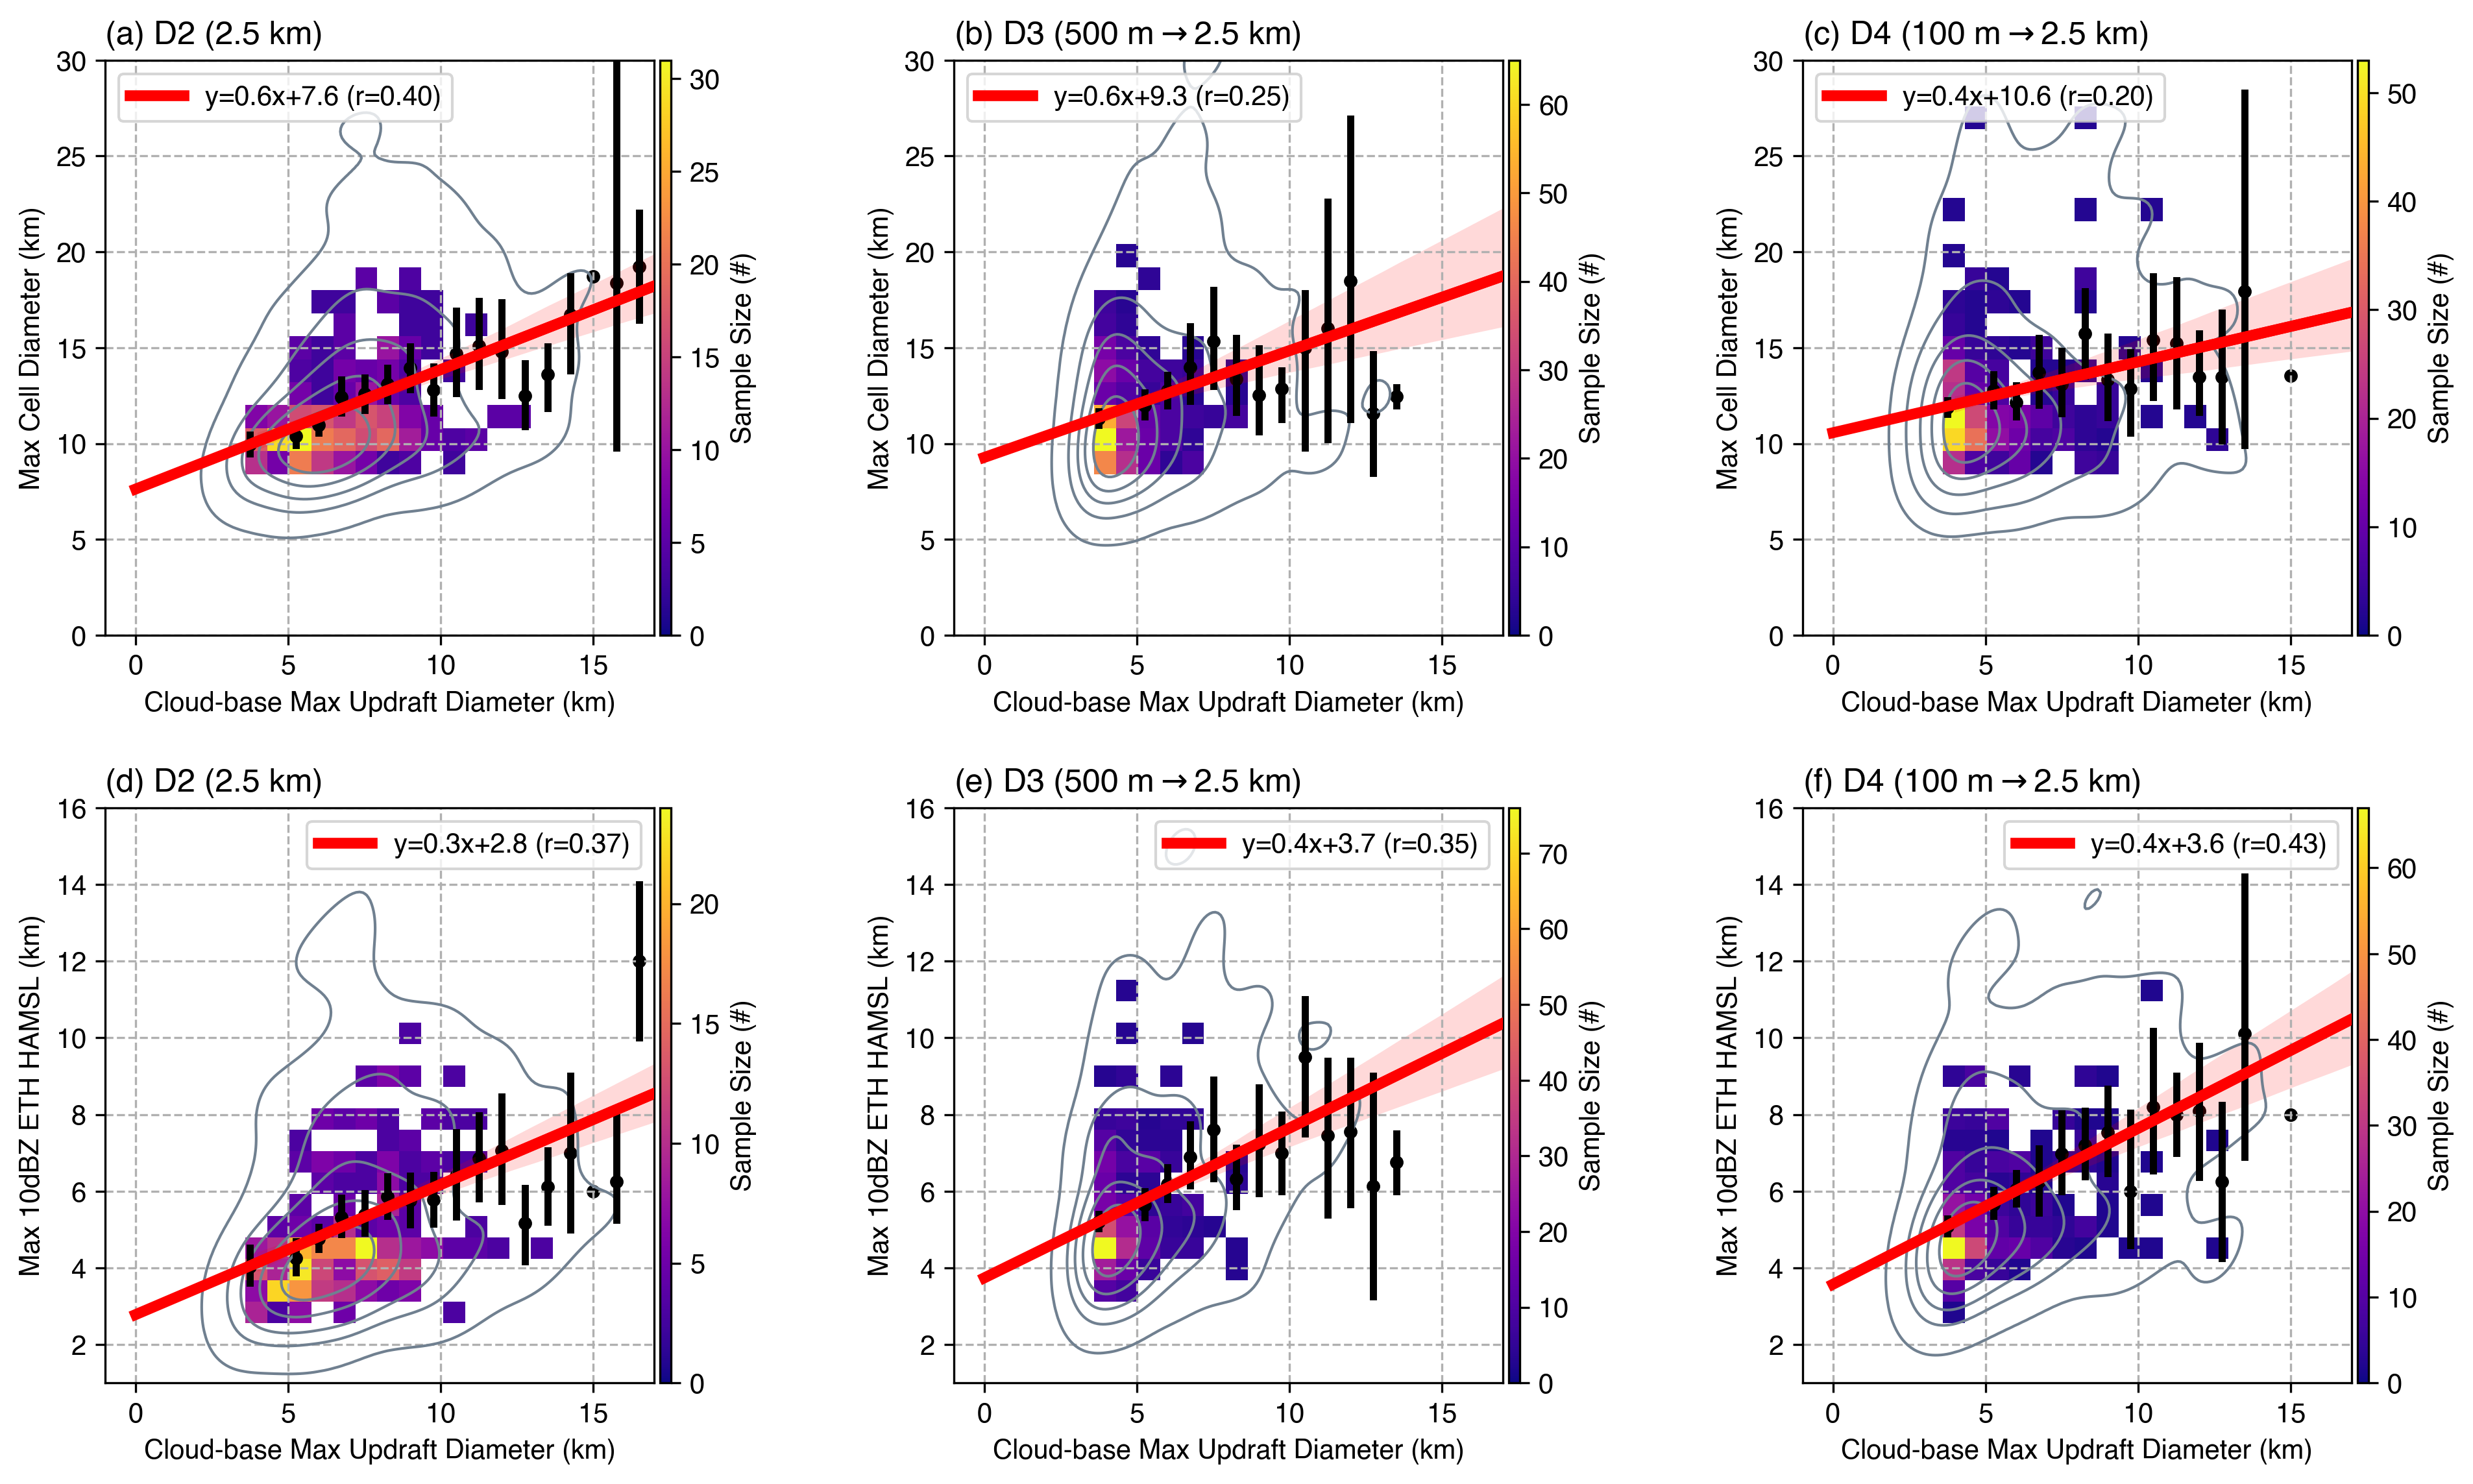

In [18]:
dfs = [[df_d2, df_d3, df_d4],[df_d2, df_d3, df_d4]]
nrow = len(dfs)
ncol = len(dfs[0])
x_name = [['Max Updraft Diameter']*ncol, ['Max Updraft Diameter']*ncol]
y_name = [['Max Cell Diameter']*ncol, ['Max 10dBZ ETH']*ncol]

# Histogram
x_bins1 = 25
x_bins2 = 25
x_bins3 = 25
bins_hist = [[x_bins1, x_bins2, x_bins3],[x_bins1, x_bins2, x_bins3]]
bin_range1 = ((0,18),(0,30))
bin_range2 = ((0,18),(0,30))
bin_range3 = ((0,18),(0,30))
# bin_range2 = ((0,10),(0,30))
# bin_range3 = ((0,10),(0,30))
bin_range4 = ((0,18),(2,16))
bin_range5 = ((0,18),(2,16))
bin_range6 = ((0,18),(2,16))
# bin_range5 = ((0,10),(2,16))
# bin_range6 = ((0,10),(2,16))
bin_range = [[bin_range1, bin_range2, bin_range3], [bin_range4, bin_range5, bin_range6]]
cmaps = [['plasma']*ncol, ['plasma']*ncol]
cbar_labels = [['Sample Size (#)']*ncol, ['Sample Size (#)']*ncol]
# KDE
kde_levels = [[6]*ncol, [6]*ncol]
kde_colors = [["slategrey"]*ncol, ["slategrey"]*ncol]
# Regression plot
reg_xbins1 = np.linspace(min(bin_range1[0]), max(bin_range1[0]), x_bins1)
reg_xbins2 = np.linspace(min(bin_range2[0]), max(bin_range2[0]), x_bins2)
reg_xbins3 = np.linspace(min(bin_range3[0]), max(bin_range3[0]), x_bins3)
reg_xbins4 = np.linspace(min(bin_range4[0]), max(bin_range4[0]), x_bins1)
reg_xbins5 = np.linspace(min(bin_range5[0]), max(bin_range5[0]), x_bins2)
reg_xbins6 = np.linspace(min(bin_range6[0]), max(bin_range6[0]), x_bins3)
reg_xbins = [[reg_xbins1, reg_xbins2, reg_xbins3], [reg_xbins4, reg_xbins5, reg_xbins6]]
# Axes, labels
# xlims = [[(-1,17),(-0.1,8),(-0.1,8)], [(-1,17),(-0.1,8),(-0.1,8)]]
xlims = [[(-1,17),(-1,17),(-1,17)], [(-1,17),(-1,17),(-1,17)]]
ylims = [[(0,30),(0,30),(0,30)], [(1,16)]*ncol]
xlabels = [['Cloud-base Max Updraft Diameter (km)']*ncol, ['Cloud-base Max Updraft Diameter (km)']*ncol]
ylabels = [['Max Cell Diameter (km)']*ncol, ['Max 10dBZ ETH HAMSL (km)']*ncol]
titles = [['(a) D2 (2.5 km)', r'(b) D3 (500 m$\rightarrow$2.5 km)', r'(c) D4 (100 m$\rightarrow$2.5 km)'], 
          ['(d) D2 (2.5 km)', r'(e) D3 (500 m$\rightarrow$2.5 km)', r'(f) D4 (100 m$\rightarrow$2.5 km)']]

# Figure
fontsize = 12
figsize = (15,9)
figname = f'{figdir}regplot_MaxWDiam_MaxCellDiam_MaxETH10dBZ_d2_d3_d4.png'
wspace = 0.5
hspace = 0.3
dpi = 300
print(figname)
fig = mxn_regplot(nrow, ncol, dfs, x_name, y_name, bins_hist=bins_hist, bin_range=bin_range, cmaps=cmaps, cbar_labels=cbar_labels, kde_levels=kde_levels, kde_colors=kde_colors, 
                  wspace=wspace, hspace=hspace, reg_xbins=reg_xbins,
                  xlims=xlims, ylims=ylims, xlabels=xlabels, ylabels=ylabels, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/regplot_MaxWTop_MaxETH10dBZ_MaxWDiam_d2_d3_d4.png


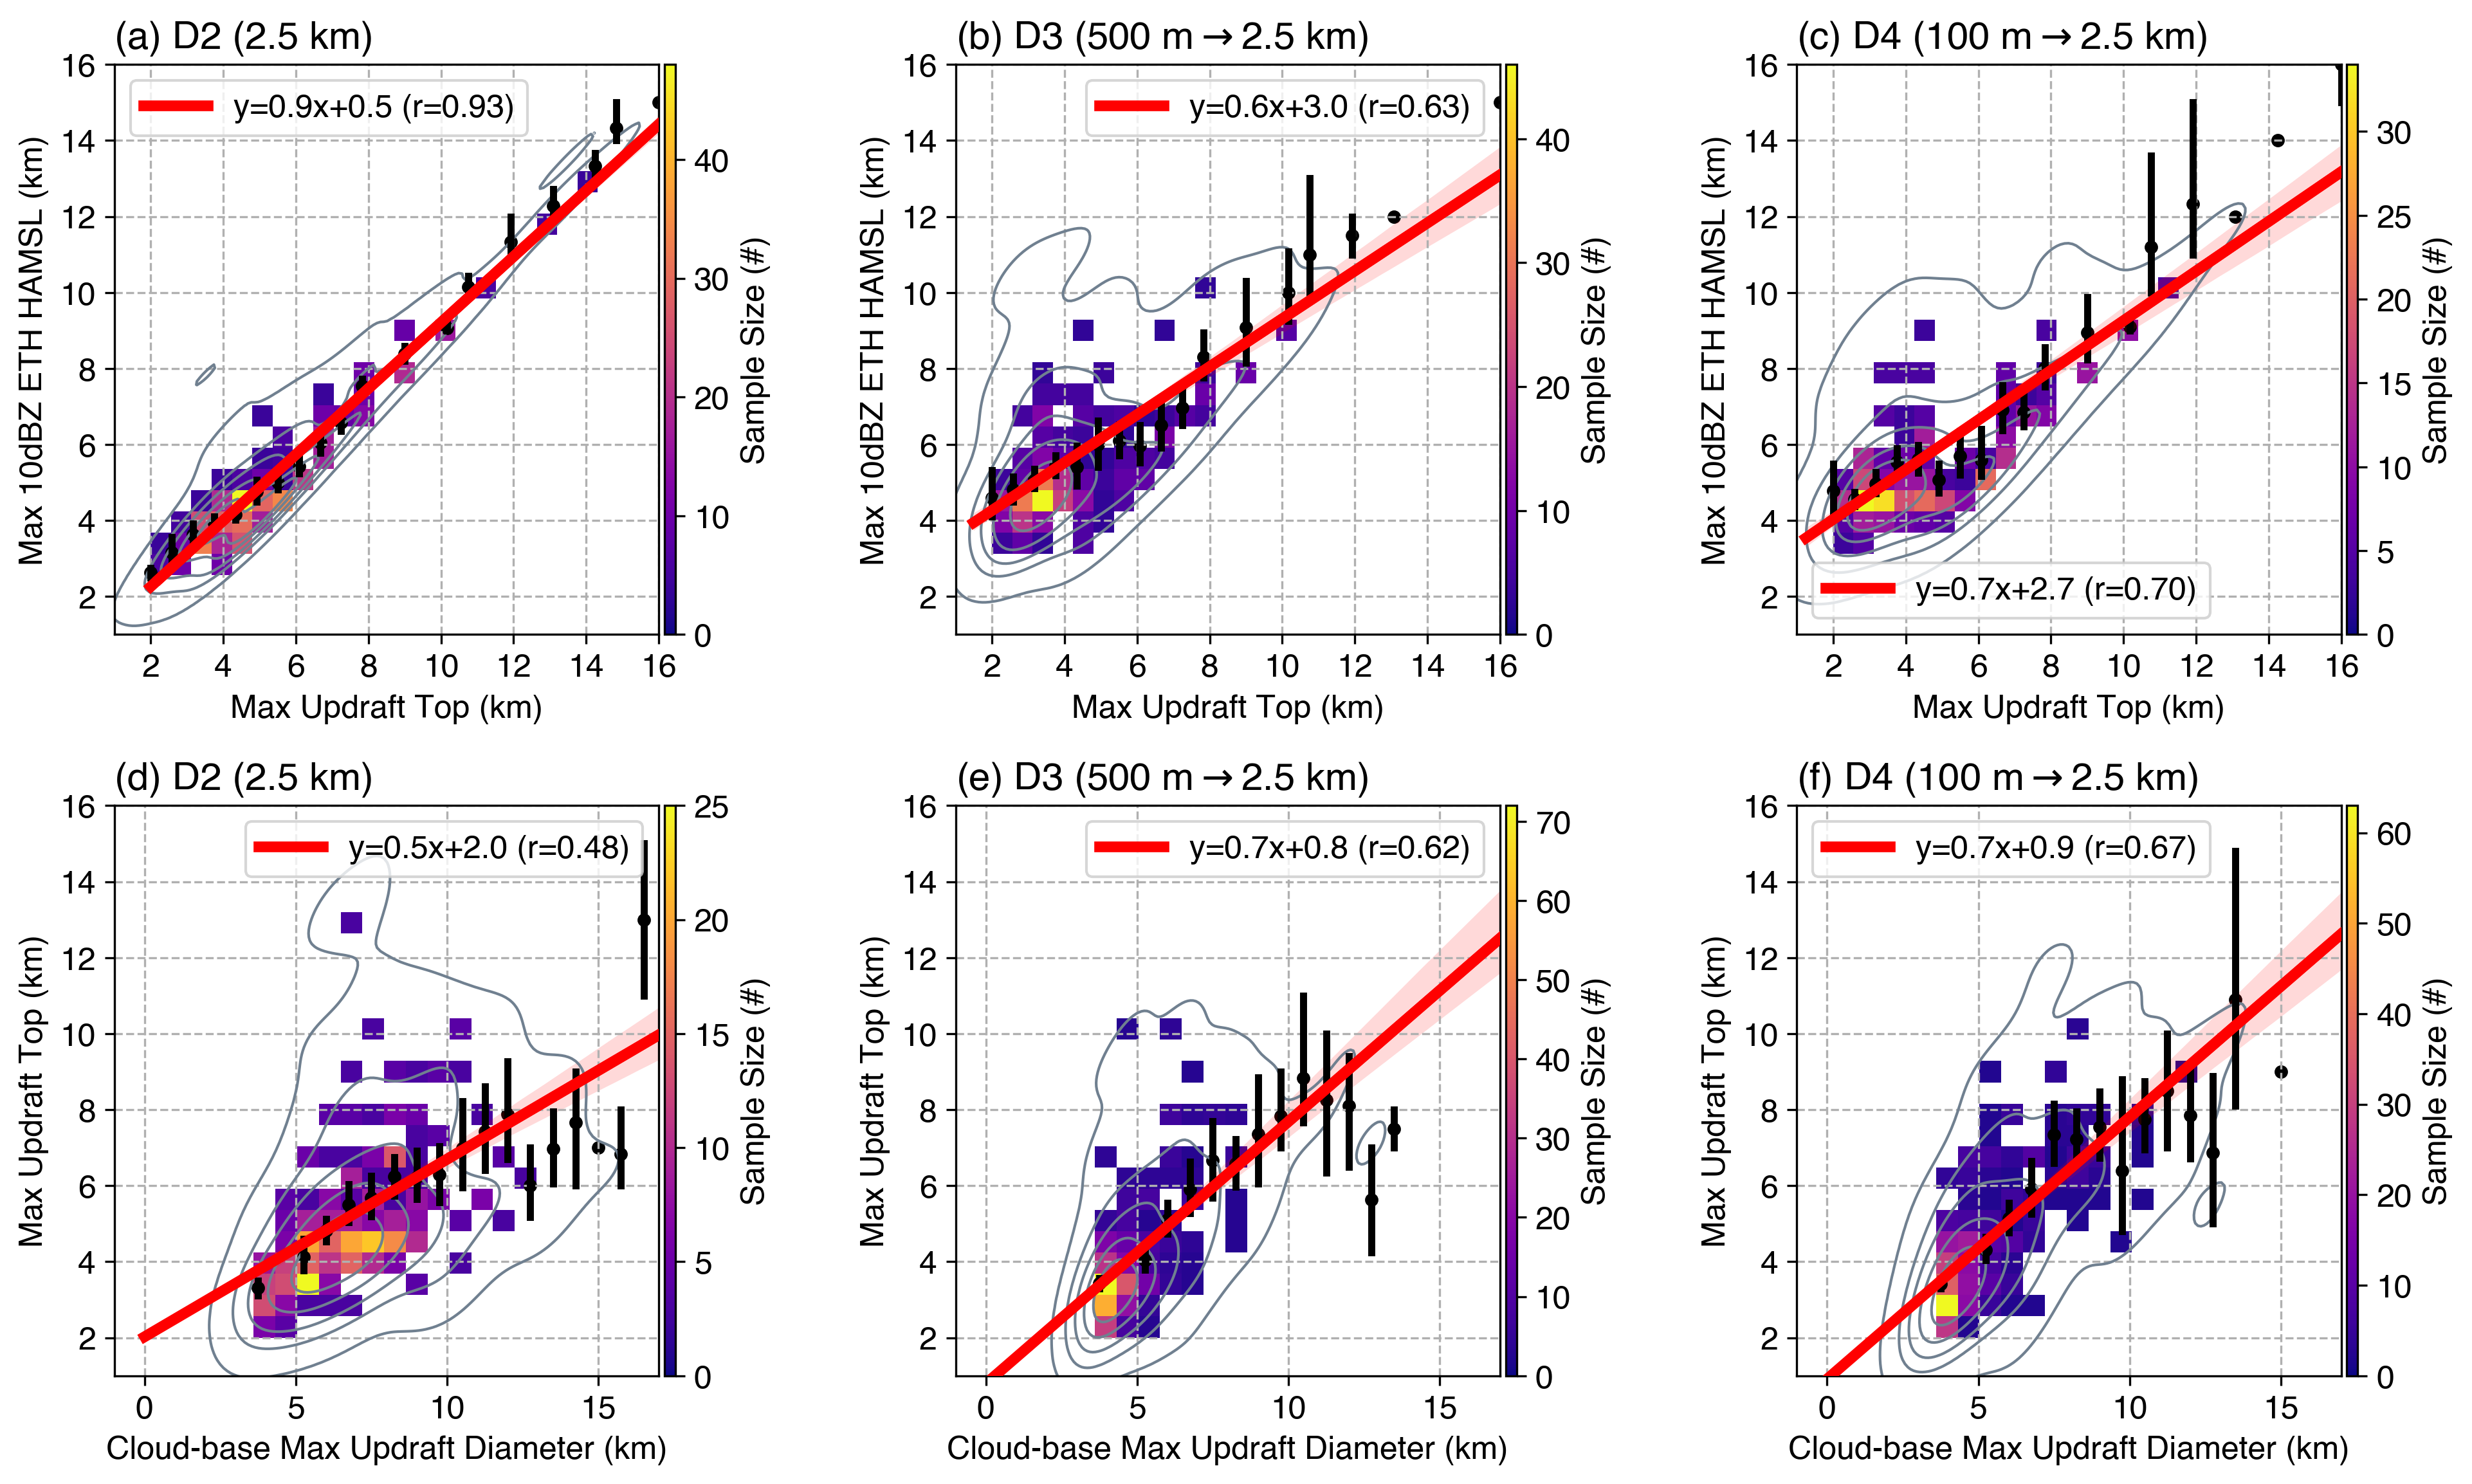

In [19]:
dfs = [[df_d2, df_d3, df_d4],[df_d2, df_d3, df_d4]]
nrow = len(dfs)
ncol = len(dfs[0])
x_name = [['Max Updraft Top Height']*ncol, ['Max Updraft Diameter']*ncol]
y_name = [['Max 10dBZ ETH']*ncol, ['Max Updraft Top Height']*ncol]

# Histogram
x_bins1 = 25
x_bins2 = 25
x_bins3 = 25
bins_hist = [[x_bins1, x_bins2, x_bins3],[x_bins1, x_bins2, x_bins3]]
bin_range1 = ((2,16),(2,16))
bin_range2 = ((2,16),(2,16))
bin_range3 = ((2,16),(2,16))
bin_range4 = ((0,18),(2,16))
bin_range5 = ((0,18),(2,16))
bin_range6 = ((0,18),(2,16))
# bin_range5 = ((0,10),(2,16))
# bin_range6 = ((0,10),(2,16))
bin_range = [[bin_range1, bin_range2, bin_range3], [bin_range4, bin_range5, bin_range6]]
cmaps = [['plasma']*ncol, ['plasma']*ncol]
cbar_labels = [['Sample Size (#)']*ncol, ['Sample Size (#)']*ncol]
# KDE
kde_levels = [[6]*ncol, [6]*ncol]
kde_colors = [["slategrey"]*ncol, ["slategrey"]*ncol]
# Regression plot
reg_xbins1 = np.linspace(min(bin_range1[0]), max(bin_range1[0]), x_bins1)
reg_xbins2 = np.linspace(min(bin_range2[0]), max(bin_range2[0]), x_bins2)
reg_xbins3 = np.linspace(min(bin_range3[0]), max(bin_range3[0]), x_bins3)
reg_xbins4 = np.linspace(min(bin_range4[0]), max(bin_range4[0]), x_bins1)
reg_xbins5 = np.linspace(min(bin_range5[0]), max(bin_range5[0]), x_bins2)
reg_xbins6 = np.linspace(min(bin_range6[0]), max(bin_range6[0]), x_bins3)
reg_xbins = [[reg_xbins1, reg_xbins2, reg_xbins3], [reg_xbins4, reg_xbins5, reg_xbins6]]
# Axes, labels
# xlims = [[(1,16)]*ncol, [(-1,17),(-0.1,8),(-0.1,8)]]
xlims = [[(1,16)]*ncol, [(-1,17),(-1,17),(-1,17)]]
ylims = [[(1,16)]*ncol, [(1,16)]*ncol]
# xticks = [[np.arange(2,16.1,2)]*ncol, [np.arange(0,15.1,5),np.arange(0,8.1,2),np.arange(0,8.1,2)]]
xticks = [[np.arange(2,16.1,2)]*ncol, [np.arange(0,15.1,5),np.arange(0,15.1,5),np.arange(0,15.1,5)]]
yticks = [[np.arange(2,16.1,2)]*ncol, [np.arange(2,16.1,2)]*ncol]
xlabels = [['Max Updraft Top (km)']*ncol, ['Cloud-base Max Updraft Diameter (km)']*ncol]
ylabels = [['Max 10dBZ ETH HAMSL (km)']*ncol, ['Max Updraft Top (km)']*ncol]
titles = [['(a) D2 (2.5 km)', r'(b) D3 (500 m$\rightarrow$2.5 km)', r'(c) D4 (100 m$\rightarrow$2.5 km)'], 
          ['(d) D2 (2.5 km)', r'(e) D3 (500 m$\rightarrow$2.5 km)', r'(f) D4 (100 m$\rightarrow$2.5 km)']]

# Figure
fontsize = 12
figsize = (15,9)
figname = f'{figdir}regplot_MaxWTop_MaxETH10dBZ_MaxWDiam_d2_d3_d4.png'
wspace = 0.5
hspace = 0.3
dpi = 300
print(figname)
fig = mxn_regplot(nrow, ncol, dfs, x_name, y_name, bins_hist=bins_hist, bin_range=bin_range, cmaps=cmaps, cbar_labels=cbar_labels, kde_levels=kde_levels, kde_colors=kde_colors, 
                  wspace=wspace, hspace=hspace, reg_xbins=reg_xbins, xticks=xticks, yticks=yticks,
                  xlims=xlims, ylims=ylims, xlabels=xlabels, ylabels=ylabels, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)

## Filter Wbase_LCL_diff & Wtop_slope criteria

In [20]:
def filter_LNB_Wbase(ds, MULNB_thresh, max_Wbase_LCL_dist):
    track_idx = (((ds.EL_height_mu/1000) > MULNB_thresh) & (ds.Wbase_LCL_diff <= max_Wbase_LCL_dist)).compute()
    # ds_out = ds.where(ds, drop=True)
    ds_out = ds.sel(tracks=track_idx)
    return ds_out

In [21]:
# MU LNB threshold, cells must have LNB > this to be retained in the subsequent analysis
MULNB_thresh = 6.0  # [km]
# Threshold for max distance between updraft base and LCL height [km]
max_Wbase_LCL_dist = 2.0  # [km]
# Threshold for updraft top fit line slope
min_Wtop_slope = 0

dsfilt_d2 = filter_LNB_Wbase(dsnms_d2, MULNB_thresh, max_Wbase_LCL_dist)

dsfilt_d3 = filter_LNB_Wbase(dsnms_d3, MULNB_thresh, max_Wbase_LCL_dist)

dsfilt_d4 = filter_LNB_Wbase(dsnms_d4, MULNB_thresh, max_Wbase_LCL_dist)

ntracks_filt_d2 = dsfilt_d2.sizes['tracks']
ntracks_filt_d3 = dsfilt_d3.sizes['tracks']
ntracks_filt_d4 = dsfilt_d4.sizes['tracks']

print(f'D2 filtered tracks: {ntracks_filt_d2} ({100*ntracks_filt_d2/ntracks_nms_d2:.0f}% of non-merge-split tracks)')
print(f'D3 filtered tracks: {ntracks_filt_d3} ({100*ntracks_filt_d3/ntracks_nms_d3:.0f}% of non-merge-split tracks)')
print(f'D4 filtered tracks: {ntracks_filt_d4} ({100*ntracks_filt_d4/ntracks_nms_d4:.0f}% of non-merge-split tracks)')

D2 filtered tracks: 615 (95% of non-merge-split tracks)
D3 filtered tracks: 542 (65% of non-merge-split tracks)
D4 filtered tracks: 516 (53% of non-merge-split tracks)


In [22]:
def standardize_var(var):
    # var_out = np.array((var - np.nanmean(var))/np.nanstd(var))
    var_out = (var - np.nanmean(var)) / np.nanstd(var)
    return var_out

In [23]:
# Variable names to include in the Pandas Data Frame
names = ['Max 10dBZ ETH', 'Max W Top', 'Max W Diameter', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', '600 hPa RH', '0-3 km BWD']
predictor_names = ['Max W Diameter', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', '600 hPa RH', '0-3 km BWD']

# names = ['Max 10dBZ ETH', 'Max W Top', 'Max W Diameter', '$\sqrt{2*(ACBL\ CAPE)}$', 'MU LCL Height', '600 hPa RH', '0-3 km BWD']
# predictor_names = ['Max W Diameter', '$\sqrt{2*(ACBL\ CAPE)}$', 'MU LCL Height', '600 hPa RH', '0-3 km BWD']

In [24]:
def mlr_bydiam(ds, bin_edges, predictor_names, predictant_name='Max 10dBZ ETH'):
   
    nbins = len(bin_edges)-1
    npredictors = len(predictor_names)
    # Make arrays to store MLR information
    coef = np.zeros([nbins,npredictors])
    relimp = np.zeros([nbins,npredictors])
    pval = np.zeros([nbins,npredictors])

    # Loop over bins
    for k in range(nbins):
        # Find track indices for cell diameters within the bin
        diam_ind = np.where(np.logical_and(ds.CImaxCellDiam >= bin_edges[k], ds.CImaxCellDiam < bin_edges[k+1]))[0]
        # Make Pandas DataFrame
        df = pd.DataFrame(columns = names)
        df['Max 10dBZ ETH'] = standardize_var(ds.CImaxETH_10dbz.isel(tracks=diam_ind).values)
        df['Max W Top'] = standardize_var(ds.CImaxWTop.isel(tracks=diam_ind).values)
        df['Max W Diameter'] = standardize_var(ds.CImaxWDiam.isel(tracks=diam_ind).values)
        df['$\sqrt{2*MUCAPE}$'] = standardize_var(np.sqrt(2*ds.pCAPE_mu.isel(tracks=diam_ind).values))
        # df['$\sqrt{2*(ACBL\ CAPE)}$'] = standardize_var(np.sqrt(2*ds.pCAPEacbl_mu.isel(tracks=diam_ind).values))
        df['MU LCL Height'] = standardize_var(ds.LCL_height_mu.isel(tracks=diam_ind).values)
        df['600 hPa RH'] = standardize_var(ds.rh_600mb.isel(tracks=diam_ind).values)
        # df['0-6 km BWD'] = standardize_var(ds.shear_mag_bulk_0to6km.isel(tracks=diam_ind).values)
        df['0-3 km BWD'] = standardize_var(ds.shear_mag_bulk_0to3km.isel(tracks=diam_ind).values)

        # Get predictors & predictant arrays
        X = df[predictor_names].to_numpy()
        Y = df[predictant_name].to_numpy()
        # Run MLR
        mlr_result = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
        # Save outputs
        coef[k,:] = mlr_result['coef'][1:]
        relimp[k,:] = mlr_result['relimp_perc'][1:]
        pval[k,:] = mlr_result['pval'][1:]

    return coef, relimp, pval

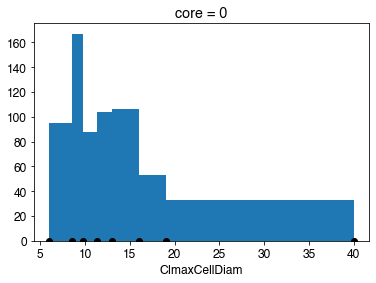

In [25]:
bin_edges_d2 = np.array([6,8.5,9.8,11.3,13,16,19,40])

_bin_edges_d2 = np.array([(edge, 0) for edge in bin_edges_d2])

dsnms_d2['CImaxCellDiam'].plot.hist(bins=bin_edges_d2)
plt.scatter(_bin_edges_d2[:,0], _bin_edges_d2[:,1], color='k')

8


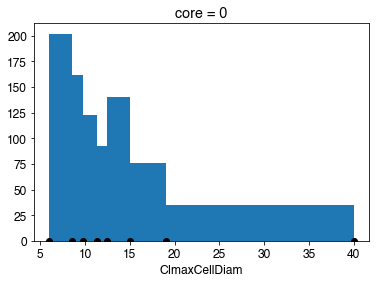

In [26]:
# bin_edges_d3 = np.array([3.9,4.8,6,7.2,9,11.5,15,30])
# bin_edges_d3 = np.array([6,8.5,9.8,11.3,13,16,19,40])
bin_edges_d3 = np.array([6,8.5,9.8,11.3,12.5,15,19,40])
print(len(bin_edges_d3))

# _bin_edges_d3 = np.array([(edge, 0) for edge in bin_edges_d3])

# # Calculate the bin edges based on quantiles
# quantiles = np.linspace(0, 1, 8)
# bin_edges_d3 = np.percentile(trackmaxCellDiam_d3, quantiles * 100)

_bin_edges_d3 = np.array([(edge, 0) for edge in bin_edges_d3])

dsnms_d3['CImaxCellDiam'].plot.hist(bins=bin_edges_d3)
plt.scatter(_bin_edges_d3[:,0], _bin_edges_d3[:,1], color='k')

8


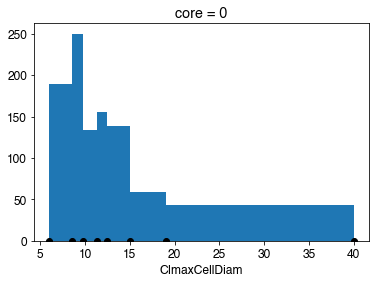

In [27]:
# bin_edges_d4 = np.array([3.9,4.6,5,6,7.5,9,12,30])
# bin_edges_d4 = np.array([3.9,4.8,6,7.2,9,11.5,15,30])
# bin_edges_d4 = np.array([6,8.5,9.8,11.3,13,16,19,40])
bin_edges_d4 = np.array([6,8.5,9.8,11.3,12.5,15,19,40])
print(len(bin_edges_d4))

# _bin_edges_d4 = np.array([(edge, 0) for edge in bin_edges_d4])

# # Calculate the bin edges based on quantiles
# quantiles = np.linspace(0, 1, 8)
# bin_edges_d4 = np.percentile(trackmaxCellDiam_d4, quantiles * 100)

_bin_edges_d4 = np.array([(edge, 0) for edge in bin_edges_d4])

dsnms_d4['CImaxCellDiam'].plot.hist(bins=bin_edges_d4)
plt.scatter(_bin_edges_d4[:,0], _bin_edges_d4[:,1], color='k')

In [28]:
predictant_name = 'Max 10dBZ ETH'

ETH_coef_d2, ETH_relimp_d2, ETH_pval_d2 = mlr_bydiam(dsfilt_d2, bin_edges_d2, predictor_names, predictant_name=predictant_name)

ETH_coef_d3, ETH_relimp_d3, ETH_pval_d3 = mlr_bydiam(dsfilt_d3, bin_edges_d3, predictor_names, predictant_name=predictant_name)

ETH_coef_d4, ETH_relimp_d4, ETH_pval_d4 = mlr_bydiam(dsfilt_d4, bin_edges_d4, predictor_names, predictant_name=predictant_name)

In [29]:
predictant_name = 'Max W Top'

WTop_coef_d2, WTop_relimp_d2, WTop_pval_d2 = mlr_bydiam(dsfilt_d2, bin_edges_d2, predictor_names, predictant_name=predictant_name)

WTop_coef_d3, WTop_relimp_d3, WTop_pval_d3 = mlr_bydiam(dsfilt_d3, bin_edges_d3, predictor_names, predictant_name=predictant_name)

WTop_coef_d4, WTop_relimp_d4, WTop_pval_d4 = mlr_bydiam(dsfilt_d4, bin_edges_d4, predictor_names, predictant_name=predictant_name)

## Function to plot predictor importance by cell diameter bins

In [30]:
def heatmap_MxN(nrow, ncol, data_arr, xedges, yedges, predictor_names, xedges_threshs=None, narrow_threshs=None, wide_threshs=None,
                wspace=None, hspace=None, cmap=None, vmin=None, vmax=None, cblabels=None, cbticks=None,
                xlims=None, ylims=None, xlabels=None, ylabels=None, suptitle=None,
                titles=None, fontsize=None, figsize=None, figname=None, dpi=None, hist_data=None):

    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'

    fig = plt.figure(figsize=figsize, dpi=dpi)

    # Setup 3 rows (top: histograms, middle: heatmaps, bottom: colorbar) if hist_data provided
    if hist_data is not None:
        gs0 = gridspec.GridSpec(3, 1, figure=fig, height_ratios=[0.3, 1, 0.03], width_ratios=[1], hspace=hspace)
        # Histogram row
        gs_hist = gridspec.GridSpecFromSubplotSpec(1, ncol, subplot_spec=gs0[0], wspace=wspace)
        # Heatmap row  
        gs_main = gs0[1]
    else:
        # Original 2-row layout if no histogram data
        gs0 = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1, 0.03], width_ratios=[1], hspace=hspace)
        gs_main = gs0[0]
    
    # Colorbar
    cax = plt.subplot(gs0[-1])
    
    # Set up panels (nrow x ncol)
    h_ratios = list(np.repeat(1,nrow))
    w_ratios = list(np.repeat(1,ncol))
    wspace = wspace
    hspace = hspace
    gs = gridspec.GridSpecFromSubplotSpec(nrow, ncol, subplot_spec=gs_main, height_ratios=h_ratios, width_ratios=w_ratios, wspace=wspace, hspace=hspace)
    
    # Create histograms if data provided
    if hist_data is not None:
        for pp in range(ncol):
            ax_hist = plt.subplot(gs_hist[pp])
            # Plot histogram using the provided data and bin edges
            ax_hist.hist(hist_data[pp], bins=xedges[pp], edgecolor='black', alpha=0.7, color='lightblue')
            if (pp == 0): ax_hist.set_ylabel('Sample Size')
            ax_hist.grid(True, ls=':', alpha=0.5)
            # Remove x-axis labels for histogram (will be shown on heatmap below)
            ax_hist.set_xticklabels([])
            ax_hist.set_xlim(np.min(xedges[pp]), np.max(xedges[pp]))
            # Add vertical lines for thresholds if provided
            if narrow_threshs is not None:
                ax_hist.axvline(x=narrow_threshs[pp], ls='-', lw=2, color='red', alpha=0.7)
            if wide_threshs is not None:
                ax_hist.axvline(x=wide_threshs[pp], ls='--', lw=2, color='red', alpha=0.7)
    
    # Loop over rows and columns for heatmaps
    for pp in range(nrow*ncol):
        idata = data_arr[pp]
        X = xedges[pp]
        Y = yedges[pp]
        if (pp == 0):
            yticklabels = predictor_names
        else:
            yticklabels = ['']*len(predictor_names)          
        
        ax = plt.subplot(gs[pp])
        pcm = ax.pcolormesh(X, Y, idata, vmin=vmin, vmax=vmax, cmap=cmap)
        if xedges_threshs is not None:
            ax.axvline(x=xedges_threshs[pp], ls='--', lw=2, color='w')
        if narrow_threshs is not None:
            ax.axvline(x=narrow_threshs[pp], ls='-', lw=2, color='w')
        if wide_threshs is not None:
            ax.axvline(x=wide_threshs[pp], ls='--', lw=2, color='w')
        yticks = Y[:-1] + np.diff(Y)*0.5
        ax.set_yticks(yticks, labels=yticklabels, rotation=45)
        ax.set_xlabel(xlabels[pp])
        ax.set_ylabel(ylabels[pp])
        ax.set_title(titles[pp], loc='left')
    
    # Colorbar
    cbar = plt.colorbar(pcm, cax=cax, label=cblabels, ticks=cbticks, orientation='horizontal', extend='both')
    # Suptitle
    fig.suptitle(suptitle, weight='bold', y=0.93, fontsize=fontsize*1.5)
    
    fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='w')
    return fig

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/MaxETH_Predictor_Importances_byCellMaxDiameter.png


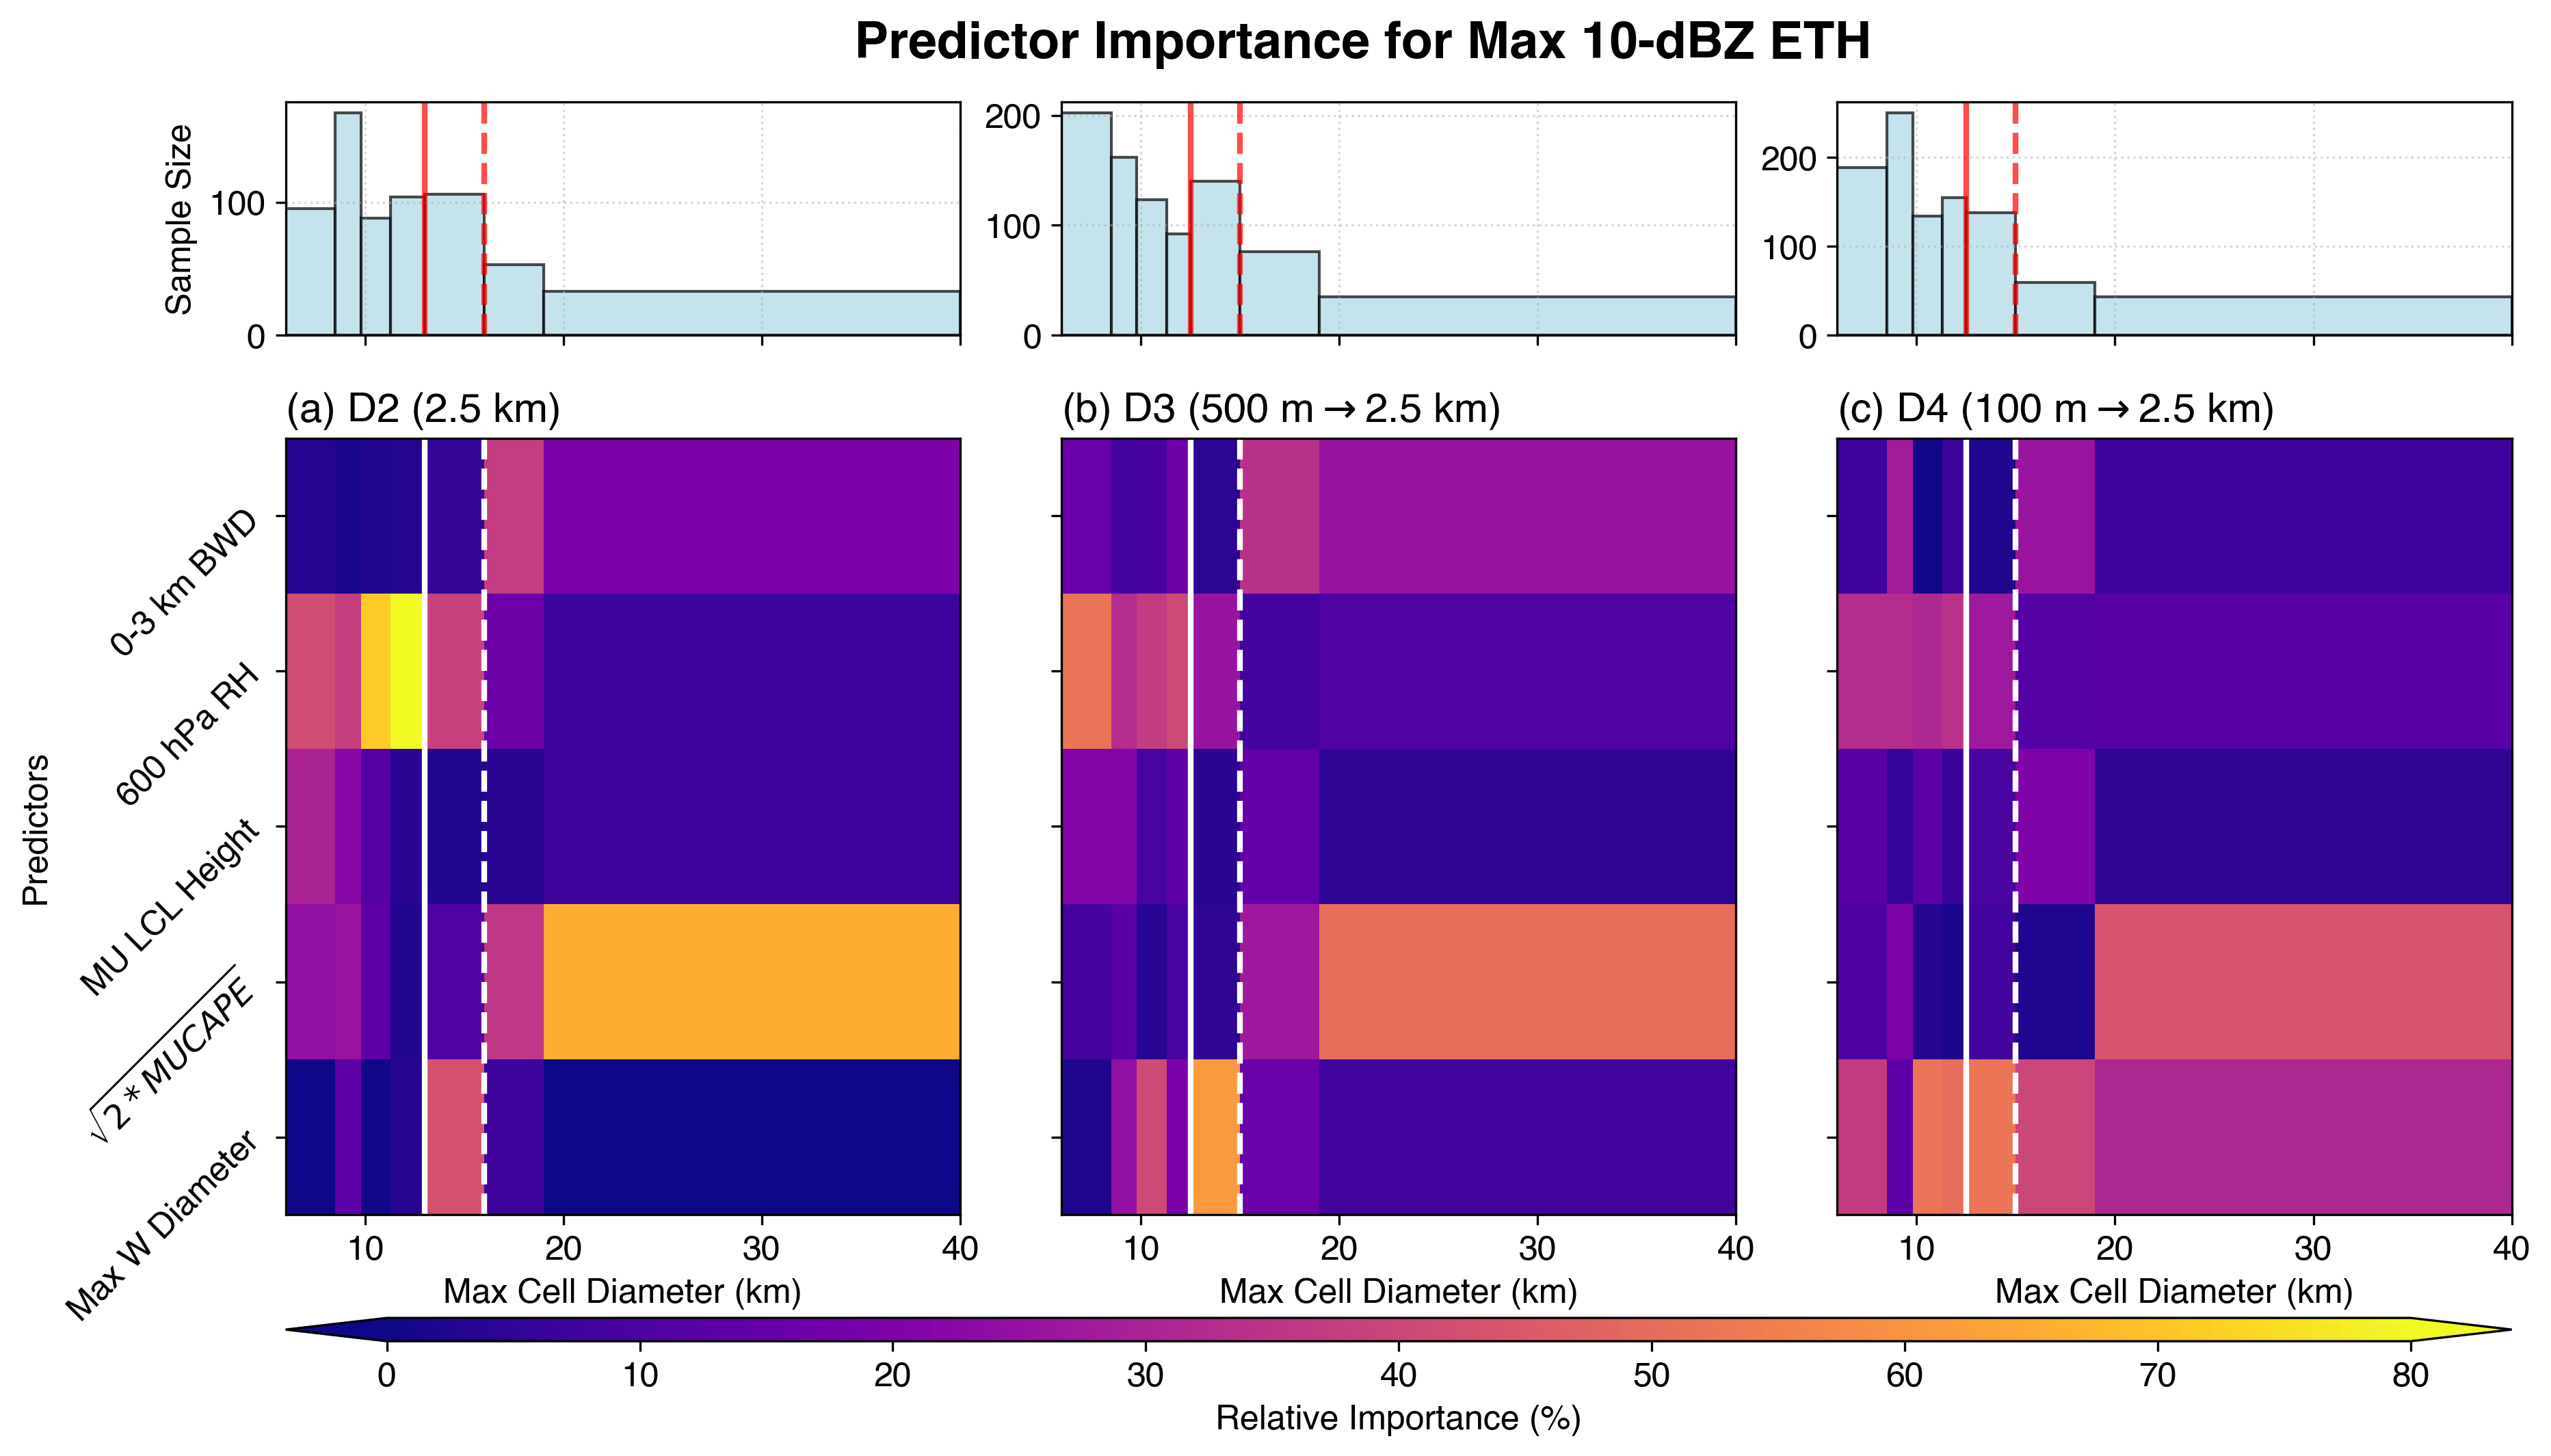

In [31]:
nrow = 1
ncol = 3
data_arr = [ETH_relimp_d2.T, ETH_relimp_d3.T, ETH_relimp_d4.T]
xedges = [bin_edges_d2, bin_edges_d3, bin_edges_d4]
yedge = np.arange(len(predictor_names)+1)
yedges = [yedge]*ncol
# Pick bin edge thresholds
narrow_thresh_d2 = bin_edges_d2[-4]
narrow_thresh_d3 = bin_edges_d3[-4]
narrow_thresh_d4 = bin_edges_d4[-4]
narrow_threshs = [narrow_thresh_d2, narrow_thresh_d3, narrow_thresh_d4]
wide_thresh_d2 = bin_edges_d2[-3]
# wide_thresh_d3 = bin_edges_d3[-3]
# wide_thresh_d4 = bin_edges_d4[-3]
wide_thresh_d3 = bin_edges_d3[-3]
wide_thresh_d4 = bin_edges_d4[-3]
wide_threshs = [wide_thresh_d2, wide_thresh_d3, wide_thresh_d4]
# Histogram data for sample size distribution
hist_data = [dsnms_d2['CImaxCellDiam'], dsnms_d3['CImaxCellDiam'], dsnms_d4['CImaxCellDiam']]

cmap = 'plasma'
vmin, vmax = 0, 80
cblabels = 'Relative Importance (%)' 
cbticks = np.arange(vmin, vmax+1, 10)
xlabels = ['Max Cell Diameter (km)']*ncol
ylabels = ['Predictors', '', '']
suptitle = 'Predictor Importance for Max 10-dBZ ETH'
titles = ['(a) D2 (2.5 km)', r'(b) D3 (500 m$\rightarrow$2.5 km)', r'(c) D4 (100 m$\rightarrow$2.5 km)']
fontsize = 12
figsize = (14,8)  # Increased height to accommodate histogram row
wspace = 0.15
hspace = 0.3
dpi = 300
figname = f"{figdir}MaxETH_Predictor_Importances_byCellMaxDiameter.png"
print(figname)
fig = heatmap_MxN(nrow, ncol, data_arr, xedges, yedges, predictor_names, narrow_threshs=narrow_threshs, wide_threshs=wide_threshs,
                  cmap=cmap, vmin=vmin, vmax=vmax, cblabels=cblabels, cbticks=cbticks,
                  xlabels=xlabels, ylabels=ylabels, titles=titles, suptitle=suptitle,
                  wspace=wspace, hspace=hspace, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi, hist_data=hist_data)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/MaxWTop_Predictor_Importances_byCellMaxDiameter.png


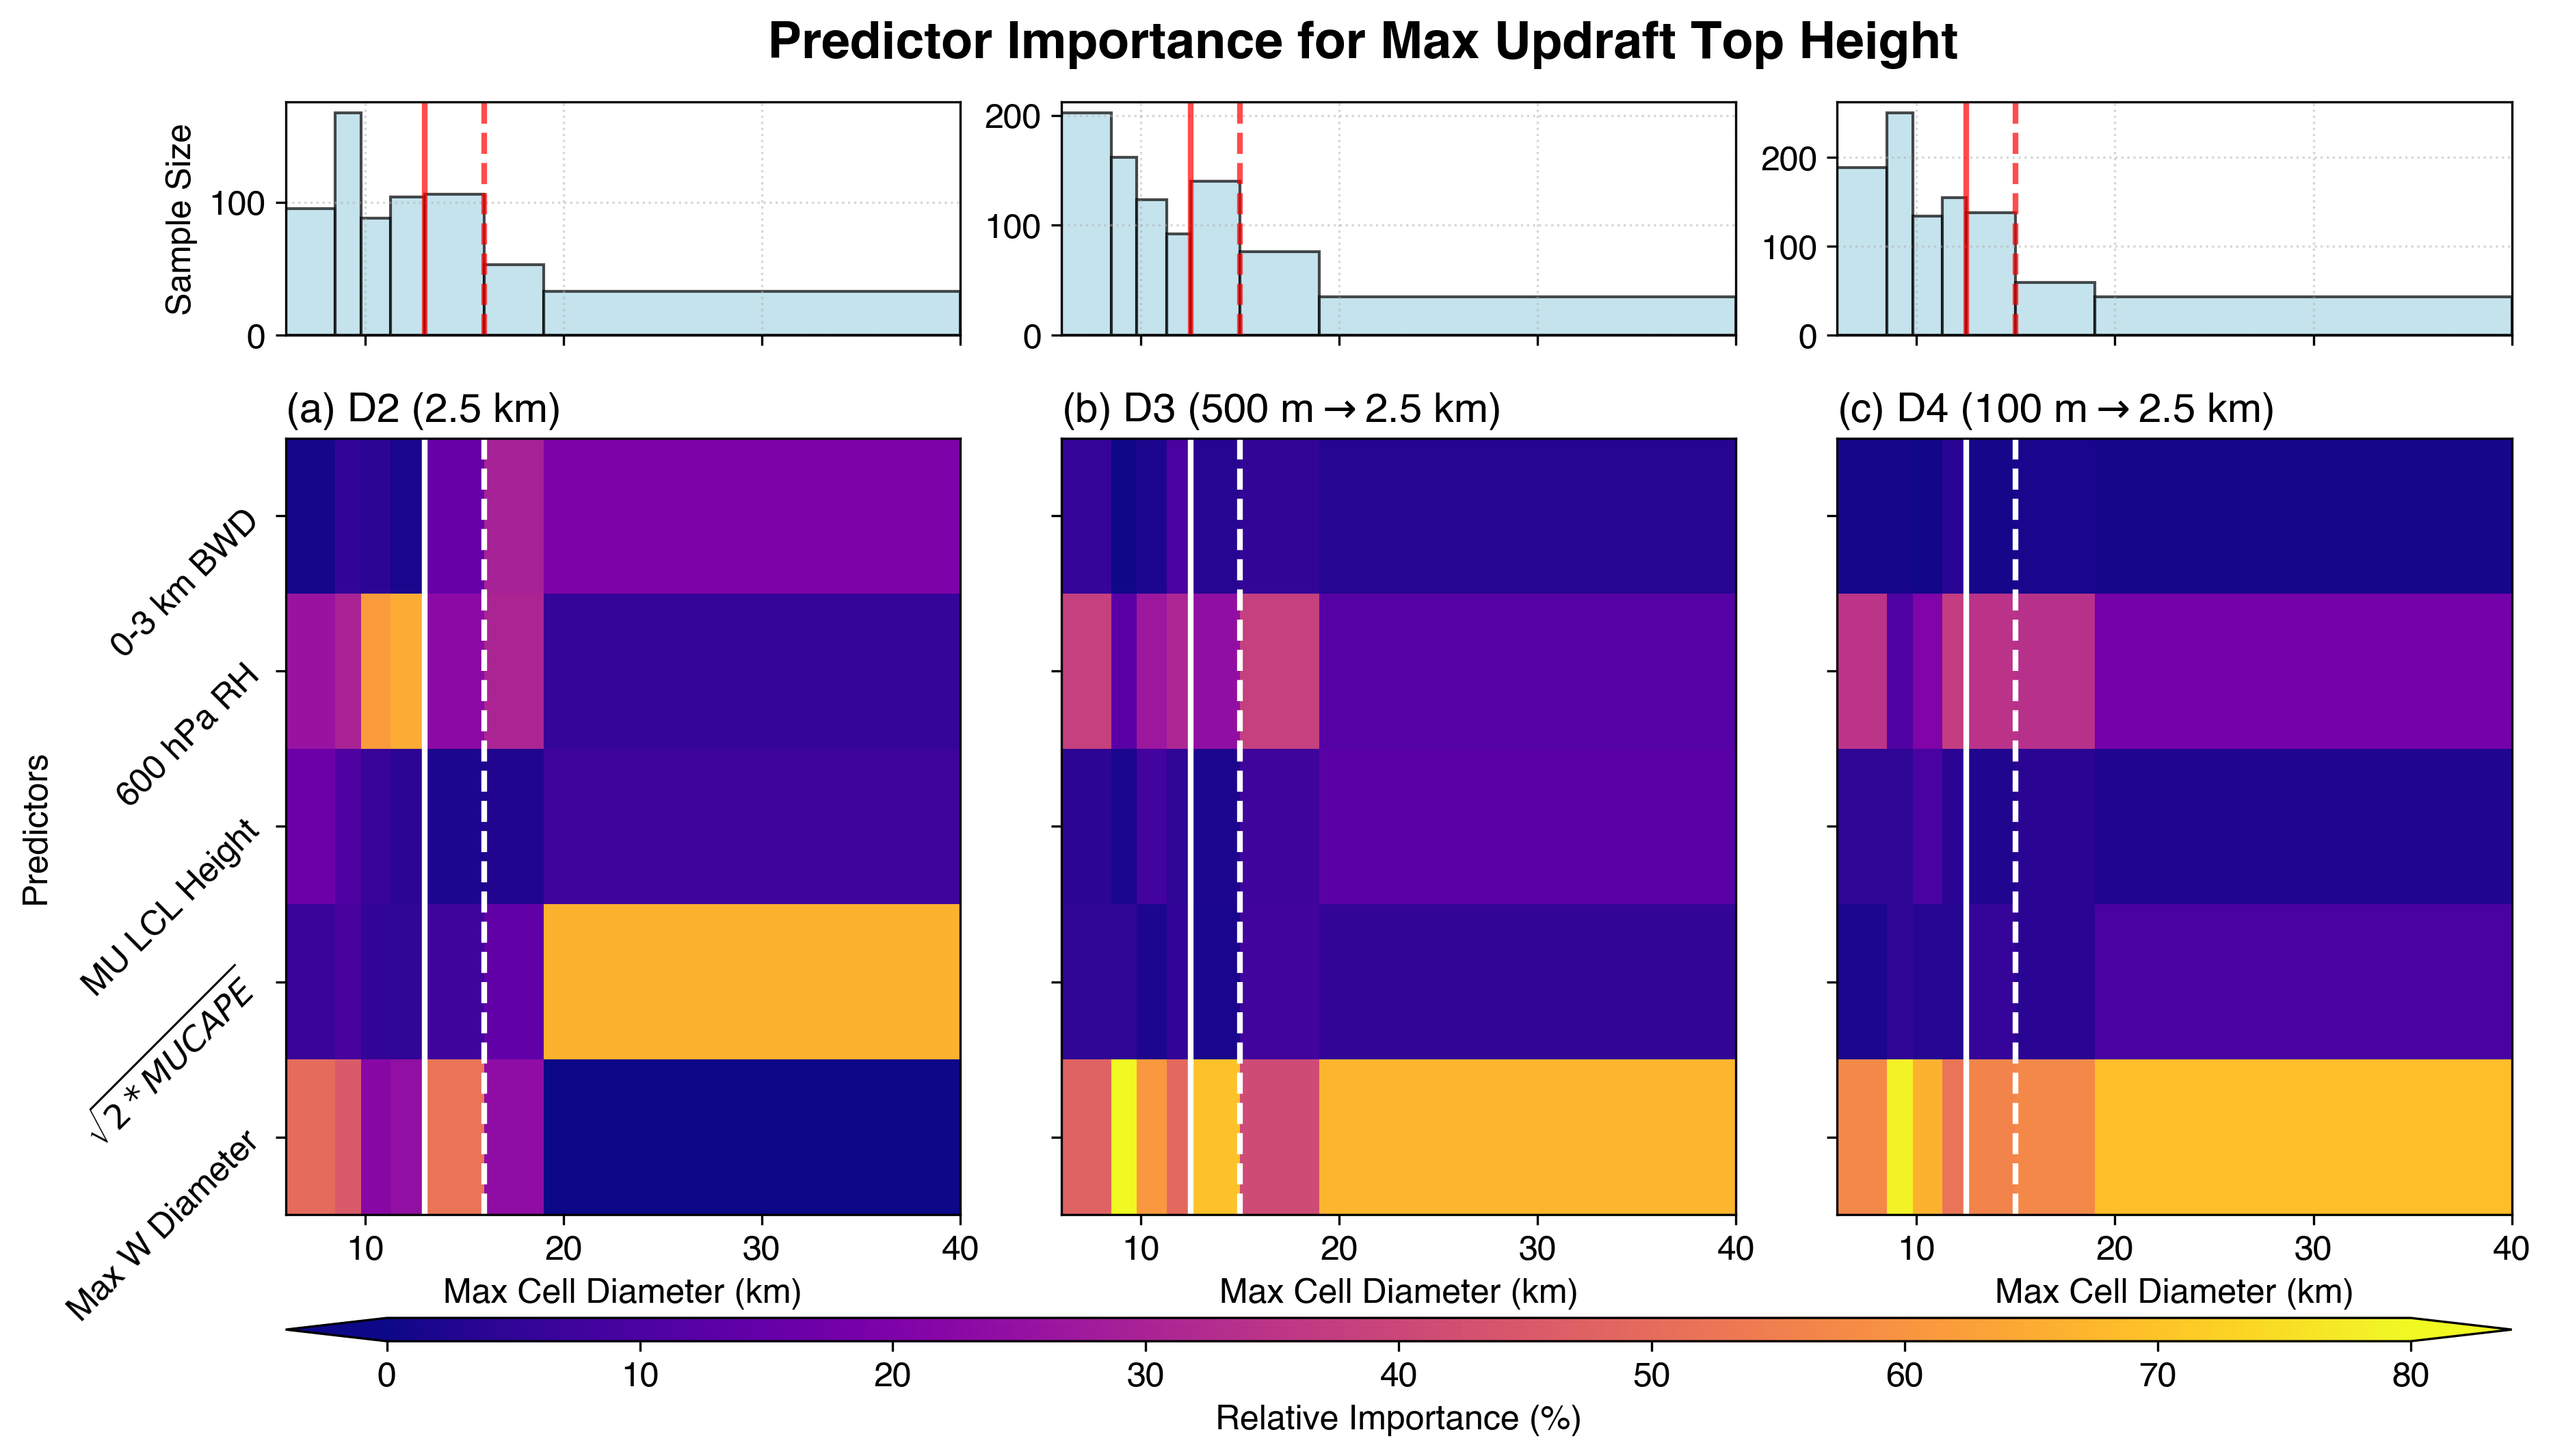

In [32]:
nrow = 1
ncol = 3
data_arr = [WTop_relimp_d2.T, WTop_relimp_d3.T, WTop_relimp_d4.T]
xedges = [bin_edges_d2, bin_edges_d3, bin_edges_d4]
yedge = np.arange(len(predictor_names)+1)
yedges = [yedge]*ncol
# Pick bin edge thresholds
narrow_thresh_d2 = bin_edges_d2[-4]
narrow_thresh_d3 = bin_edges_d3[-4]
narrow_thresh_d4 = bin_edges_d4[-4]
narrow_threshs = [narrow_thresh_d2, narrow_thresh_d3, narrow_thresh_d4]
wide_thresh_d2 = bin_edges_d2[-3]
wide_thresh_d3 = bin_edges_d3[-3]
wide_thresh_d4 = bin_edges_d4[-3]
# wide_thresh_d3 = bin_edges_d3[-3]
# wide_thresh_d4 = bin_edges_d4[-3]
wide_threshs = [wide_thresh_d2, wide_thresh_d3, wide_thresh_d4]
# Histogram data for sample size distribution
hist_data = [dsnms_d2['CImaxCellDiam'], dsnms_d3['CImaxCellDiam'], dsnms_d4['CImaxCellDiam']]

cmap = 'plasma'
vmin, vmax = 0, 80
cblabels = 'Relative Importance (%)' 
cbticks = np.arange(vmin, vmax+1, 10)
xlabels = ['Max Cell Diameter (km)']*ncol
ylabels = ['Predictors', '', '']
suptitle = 'Predictor Importance for Max Updraft Top Height' 
titles = ['(a) D2 (2.5 km)', r'(b) D3 (500 m$\rightarrow$2.5 km)', r'(c) D4 (100 m$\rightarrow$2.5 km)']
fontsize = 12
figsize = (14,8)  # Increased height to accommodate histogram row
wspace = 0.15
hspace = 0.3
dpi = 300
figname = f"{figdir}MaxWTop_Predictor_Importances_byCellMaxDiameter.png"
print(figname)
fig = heatmap_MxN(nrow, ncol, data_arr, xedges, yedges, predictor_names, narrow_threshs=narrow_threshs, wide_threshs=wide_threshs,
                  cmap=cmap, vmin=vmin, vmax=vmax, cblabels=cblabels, cbticks=cbticks,
                  xlabels=xlabels, ylabels=ylabels, titles=titles, suptitle=suptitle,
                  wspace=wspace, hspace=hspace, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi, hist_data=hist_data)

## Plot cell diameter & ETH PDF with narrow & wide cell cutoffs

## Function to plot nrow x ncol of violin plot

In [33]:
def plot_mxn_violin(nrow, ncol, da, qnt1=None, qnt2=None, qnt_values=None, qnt_labels=None, text1=None, text2=None,
                    samplesize=None, ypos_sample=None, wspace=None, hspace=None,
                    ylabels=None, ylims=None, titles=None, fontsize=None, figsize=None, figname=None):

    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    
    # fig, axes = plt.subplots(nrow, ncol, figsize=figsize, dpi=100)
    fig = plt.figure(figsize=figsize, dpi=dpi)
    # Set up panels (nrow x ncol)
    h_ratios = list(np.repeat(1,nrow))
    w_ratios = list(np.repeat(1,ncol))
    wspace = wspace
    hspace = hspace
    gs = gridspec.GridSpec(nrow, ncol, figure=fig, height_ratios=h_ratios, width_ratios=w_ratios, wspace=wspace, hspace=hspace)

    lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
    name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}
    qnt_colors = {'d2':'deepskyblue', 'd3':'springgreen', 'd4':'violet'}
    lw_qnt = 2
    palette = list(lcolors.values())    
    lw_kde = 2
    size_avg = 60
    color_avg = 'red'
    color_med = 'white'
    xlabels = list(name_map.values())
    leg_fontsize = fontsize
       
    for row in range(nrow):
        for col in range(ncol):
            # ax = axes[row][col]
            gss = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=gs[row,col])
            ax = plt.subplot(gss[0])
            violin_data = da[row][col]
            qnt1_data = qnt1[row][col]
            qnt2_data = qnt2[row][col]
            qnt1_2 = qnt1_data[0]
            qnt1_3 = qnt1_data[1]
            qnt1_4 = qnt1_data[2]
            qnt2_2 = qnt2_data[0]
            qnt2_3 = qnt2_data[1]
            qnt2_4 = qnt2_data[2]

            # Calculate means and medians
            avg2 = np.nanmean(violin_data[0])
            avg3 = np.nanmean(violin_data[1])
            avg4 = np.nanmean(violin_data[2])
            med2 = np.nanmedian(violin_data[0])
            med3 = np.nanmedian(violin_data[1])
            med4 = np.nanmedian(violin_data[2])
            # Violin plot
            vp = sns.violinplot(data=violin_data, ax=ax, palette=palette, linewidth=lw_kde)
            # Plot median value as line
            ax.hlines(med2, -0.1, 0.1, lw=2, color=color_med, zorder=4)
            ax.hlines(med3, 0.9, 1.1, lw=2, color=color_med, zorder=4)
            ax.hlines(med4, 1.9, 2.1, lw=2, color=color_med, zorder=4)
            # Plot mean value as circle
            ax.scatter(0, avg2, color=color_avg, s=size_avg, zorder=3)
            ax.scatter(1, avg3, color=color_avg, s=size_avg, zorder=3)
            ax.scatter(2, avg4, color=color_avg, s=size_avg, zorder=3)
            # Plot quantile lines
            if col == 0:
                ax.hlines(qnt1_2, -0.4, 0.4, lw=lw_qnt, color=qnt_colors['d2'], zorder=5)
                ax.hlines(qnt1_3, 0.6, 1.4, lw=lw_qnt, color=qnt_colors['d3'], zorder=5)
                ax.hlines(qnt1_4, 1.6, 2.4, lw=lw_qnt, color=qnt_colors['d4'], zorder=5)
            
                ax.hlines(qnt2_2, -0.4, 0.4, lw=lw_qnt, color=qnt_colors['d2'], ls='--', zorder=5)
                ax.hlines(qnt2_3, 0.6, 1.4, lw=lw_qnt, color=qnt_colors['d3'], ls='--', zorder=5)
                ax.hlines(qnt2_4, 1.6, 2.4, lw=lw_qnt, color=qnt_colors['d4'], ls='--', zorder=5)
                
                ax.text(0.4, qnt1_2-0.15, text1[row][col][0], color=qnt_colors['d2'], va='top', ha='center', fontsize=leg_fontsize*0.7)
                ax.text(1.4, qnt1_3-0.15, text1[row][col][1], color=qnt_colors['d3'], va='top', ha='center', fontsize=leg_fontsize*0.7)
                ax.text(2.4, qnt1_4-0.15, text1[row][col][2], color=qnt_colors['d4'], va='top', ha='center', fontsize=leg_fontsize*0.7)
                
                ax.text(0.4, qnt2_2+0.1, text2[row][col][0], color=qnt_colors['d2'], va='bottom', ha='center', fontsize=leg_fontsize*0.7)
                ax.text(1.4, qnt2_3+0.1, text2[row][col][1], color=qnt_colors['d3'], va='bottom', ha='center', fontsize=leg_fontsize*0.7)
                ax.text(2.4, qnt2_4+0.1, text2[row][col][2], color=qnt_colors['d4'], va='bottom', ha='center', fontsize=leg_fontsize*0.7)
                
#                 ax.text(0.4, qnt1_2-0.15, f'{qnt1_2:.2f} km', color=qnt_colors['d2'], va='top', ha='center', fontsize=leg_fontsize*0.7)
#                 ax.text(1.4, qnt1_3-0.15, f'{qnt1_3:.2f} km', color=qnt_colors['d3'], va='top', ha='center', fontsize=leg_fontsize*0.7)
#                 ax.text(2.4, qnt1_4-0.15, f'{qnt1_4:.2f} km', color=qnt_colors['d4'], va='top', ha='center', fontsize=leg_fontsize*0.7)
                
#                 ax.text(0.4, qnt2_2+0.1, f'{qnt2_2:.2f} km', color=qnt_colors['d2'], va='bottom', ha='center', fontsize=leg_fontsize*0.7)
#                 ax.text(1.4, qnt2_3+0.1, f'{qnt2_3:.2f} km', color=qnt_colors['d3'], va='bottom', ha='center', fontsize=leg_fontsize*0.7)
#                 ax.text(2.4, qnt2_4+0.1, f'{qnt2_4:.2f} km', color=qnt_colors['d4'], va='bottom', ha='center', fontsize=leg_fontsize*0.7)
            # Set plots
            ax.set_xticklabels(xlabels)
            ax.set_ylabel(ylabels[row][col])
            ax.set_title(titles[row][col], loc='left')
            ax.grid(ls=':', axis='y')
            if ylims is not None: ax.set_ylim(ylims[row][col][0], ylims[row][col][1])
            if samplesize is not None:
                if (col == 0):
                    ax.text(0.05, ypos_sample[row], samplesize['d2'], color=lcolors['d2'], va='top', fontsize=leg_fontsize*0.7)
                    ax.text(1.05, ypos_sample[row], samplesize['d3'], color=lcolors['d3'], va='top', fontsize=leg_fontsize*0.7)
                    ax.text(2.05, ypos_sample[row], samplesize['d4'], color=lcolors['d4'], va='top', fontsize=leg_fontsize*0.7)
            # # Legend
            # if (col == 0):
            #     qnt_lab = qnt_labels[row][col]
            #     legend_handles = [mpl.lines.Line2D([0], [0], color='k', ls='-', lw=lw_qnt, label=f'{qnt_lab[0]} ({qnt_values[0]:.2f})'),
            #                       mpl.lines.Line2D([0], [0], color='k', ls='--',  lw=lw_qnt, label=f'{qnt_lab[1]} ({qnt_values[1]:.2f})'),]
            #     legend = ax.legend(handles=legend_handles, handlelength=None, handletextpad=None, loc='best', fontsize=leg_fontsize, labelcolor='linecolor', ncol=3)
            #     ax.add_artist(legend)
            
    # fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

In [34]:
def find_closest_percentile(data, target_value, precision=100):
    """
    Find the closest percentile to a target value in a given data array, excluding NaN values.
    
    Parameters:
        data (array-like): The array of values.
        target_value (float): The value to find the closest percentile for.
        precision (int): Number of quantiles (e.g., 1000 for 0.1% precision).
        
    Returns:
        closest_percentile (float): The closest percentile to the target value.
        closest_quantile_value (float): The quantile value at that percentile.
    """
    # Exclude NaN values
    data = data[~np.isnan(data)]
    
    # Define the quantiles with the specified precision
    quantiles = np.linspace(0, 1, precision + 1)
    
    # Calculate quantile values
    quantile_values = np.quantile(data, quantiles)
    
    # Find the closest quantile
    closest_quantile_index = np.argmin(np.abs(quantile_values - target_value))
    closest_percentile = quantiles[closest_quantile_index] * 100  # convert to percentile
    closest_quantile_value = quantile_values[closest_quantile_index]
    
    return closest_percentile, closest_quantile_value

In [35]:
narrow_qt_d2, narrow_qt_thresh_d2 = find_closest_percentile(dsfilt_d2.CImaxCellDiam.data, narrow_thresh_d2, precision=20)
narrow_qt_d3, narrow_qt_thresh_d3 = find_closest_percentile(dsfilt_d3.CImaxCellDiam.data, narrow_thresh_d3, precision=20)
narrow_qt_d4, narrow_qt_thresh_d4 = find_closest_percentile(dsfilt_d4.CImaxCellDiam.data, narrow_thresh_d4, precision=20)
print(f'D2 narrow cell diameter thresh: {narrow_thresh_d2} km, closest percentile: {narrow_qt_d2:.0f}, percentile value: {narrow_qt_thresh_d2:.2f} km')
print(f'D3 narrow cell diameter thresh: {narrow_thresh_d3} km, closest percentile: {narrow_qt_d3:.0f}, percentile value: {narrow_qt_thresh_d3:.2f} km')
print(f'D4 narrow cell diameter thresh: {narrow_thresh_d4} km, closest percentile: {narrow_qt_d4:.0f}, percentile value: {narrow_qt_thresh_d4:.2f} km')

D2 narrow cell diameter thresh: 13.0 km, closest percentile: 65, percentile value: 12.62 km
D3 narrow cell diameter thresh: 12.5 km, closest percentile: 65, percentile value: 12.93 km
D4 narrow cell diameter thresh: 12.5 km, closest percentile: 65, percentile value: 12.93 km


In [36]:
wide_qt_d2, wide_qt_thresh_d2 = find_closest_percentile(dsfilt_d2.CImaxCellDiam.data, wide_thresh_d2, precision=20)
wide_qt_d3, wide_qt_thresh_d3 = find_closest_percentile(dsfilt_d3.CImaxCellDiam.data, wide_thresh_d3, precision=20)
wide_qt_d4, wide_qt_thresh_d4 = find_closest_percentile(dsfilt_d4.CImaxCellDiam.data, wide_thresh_d4, precision=20)
print(f'D2 wide cell diameter thresh: {wide_thresh_d2} km, closest percentile: {wide_qt_d2:.0f}, percentile value: {wide_qt_thresh_d2:.2f} km')
print(f'D3 wide cell diameter thresh: {wide_thresh_d3} km, closest percentile: {wide_qt_d3:.0f}, percentile value: {wide_qt_thresh_d3:.2f} km')
print(f'D4 wide cell diameter thresh: {wide_thresh_d4} km, closest percentile: {wide_qt_d4:.0f}, percentile value: {wide_qt_thresh_d4:.2f} km')

D2 wide cell diameter thresh: 16.0 km, closest percentile: 85, percentile value: 15.71 km
D3 wide cell diameter thresh: 15.0 km, closest percentile: 85, percentile value: 15.45 km
D4 wide cell diameter thresh: 15.0 km, closest percentile: 80, percentile value: 14.66 km


/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/Violin_NarrowWide_maxDiameter_maxETH10dBZ_maxWTop_d2_d3_d4.png


/tmp/ipykernel_266963/4150381781.py:87: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_266963/4150381781.py:87: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_266963/4150381781.py:87: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)


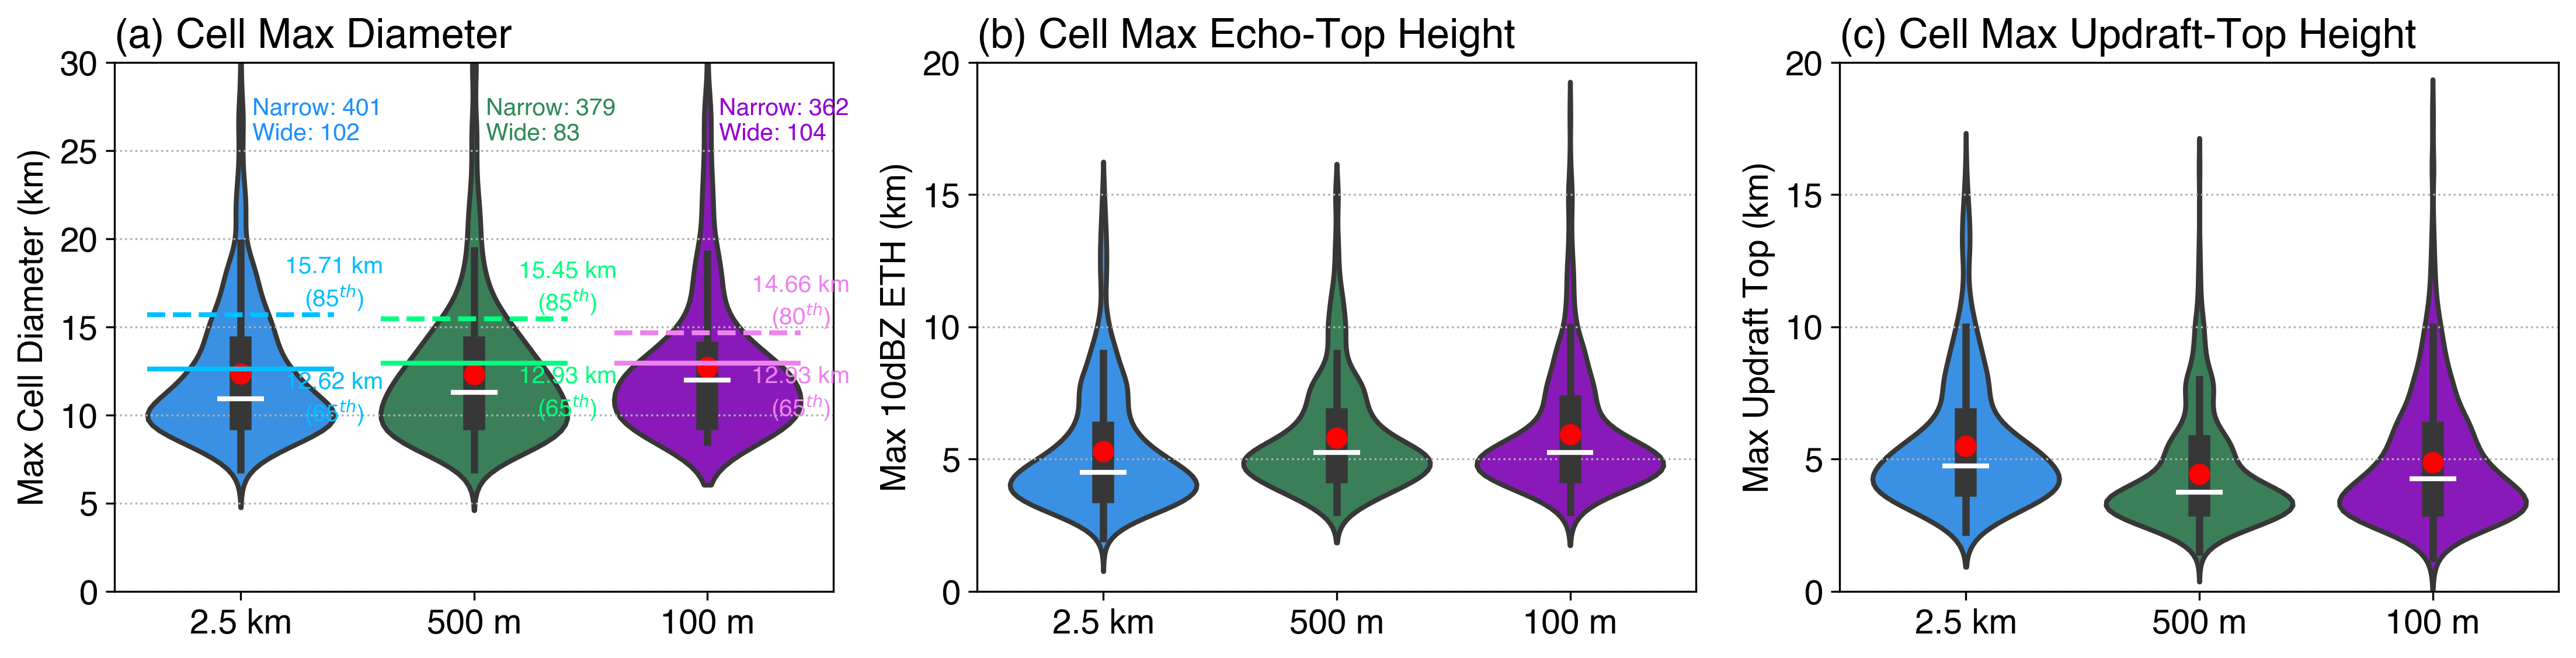

In [37]:
data_arr = [
    [[dsfilt_d2.CImaxCellDiam.data, dsfilt_d3.CImaxCellDiam.data, dsfilt_d4.CImaxCellDiam.data],
     [dsfilt_d2.CImaxETH_10dbz.data, dsfilt_d3.CImaxETH_10dbz.data, dsfilt_d4.CImaxETH_10dbz.data],
     [dsfilt_d2.CImaxWTop.data, dsfilt_d3.CImaxWTop.data, dsfilt_d4.CImaxWTop.data],]
]

qnt_narrow = [
    [[narrow_qt_thresh_d2, narrow_qt_thresh_d3, narrow_qt_thresh_d4],
     [None,None,None],
     [None,None,None],]
]
qnt_wide = [
    [[wide_qt_thresh_d2, wide_qt_thresh_d3, wide_qt_thresh_d4],
    [None,None,None],
    [None,None,None],]
]
texts_narrow = [
    [[f"{narrow_qt_thresh_d2:.2f} km\n({narrow_qt_d2:.0f}$^{{th}}$)", 
      f"{narrow_qt_thresh_d3:.2f} km\n({narrow_qt_d3:.0f}$^{{th}}$)", 
      f"{narrow_qt_thresh_d4:.2f} km\n({narrow_qt_d4:.0f}$^{{th}}$)"],
     [None,None,None],
     [None,None,None],]
]
texts_wide = [
    [[f"{wide_qt_thresh_d2:.2f} km\n({wide_qt_d2:.0f}$^{{th}}$)", 
      f"{wide_qt_thresh_d3:.2f} km\n({wide_qt_d3:.0f}$^{{th}}$)", 
      f"{wide_qt_thresh_d4:.2f} km\n({wide_qt_d4:.0f}$^{{th}}$)"],
     [None,None,None],
     [None,None,None],]
]

ntracks_narrow_d2 = np.count_nonzero((dsfilt_d2.CImaxCellDiam <= narrow_qt_thresh_d2).values)
ntracks_narrow_d3 = np.count_nonzero((dsfilt_d3.CImaxCellDiam <= narrow_qt_thresh_d3).values)
ntracks_narrow_d4 = np.count_nonzero((dsfilt_d4.CImaxCellDiam <= narrow_qt_thresh_d4).values)
ntracks_wide_d2 = np.count_nonzero((dsfilt_d2.CImaxCellDiam >= wide_qt_thresh_d2).values)
ntracks_wide_d3 = np.count_nonzero((dsfilt_d3.CImaxCellDiam >= wide_qt_thresh_d3).values)
ntracks_wide_d4 = np.count_nonzero((dsfilt_d4.CImaxCellDiam >= wide_qt_thresh_d4).values)
samplesize = {
    'd2': f"Narrow: {ntracks_narrow_d2}\nWide: {ntracks_wide_d2}",
    'd3': f"Narrow: {ntracks_narrow_d3}\nWide: {ntracks_wide_d3}",
    'd4': f"Narrow: {ntracks_narrow_d4}\nWide: {ntracks_wide_d4}",
}
ypos_sample = [28]
titles = [['(a) Cell Max Diameter','(b) Cell Max Echo-Top Height','(c) Cell Max Updraft-Top Height']]
ylabels = [['Max Cell Diameter (km)', 'Max 10dBZ ETH (km)', 'Max Updraft Top (km)']]
ylims = [[(0,30), (0,20), (0,20)]]
xlabels = None
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
fontsize = 14
figsize = (18, 4)
figname = f'{figdir}Violin_NarrowWide_maxDiameter_maxETH10dBZ_maxWTop_d2_d3_d4.png'
print(figname)
fig = plot_mxn_violin(nrow, ncol, data_arr, qnt1=qnt_narrow, qnt2=qnt_wide, text1=texts_narrow, text2=texts_wide,
                      samplesize=samplesize, ypos_sample=ypos_sample,
                      ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

## Separate narrow vs. wide cell DataSets

In [38]:
# # Define narrow vs. wide thresholds
# narrow_diam_d2 = maxCellDiam_pts_d2.sel(quantile=narrow_qt).item()
# wide_diam_d2 = maxCellDiam_pts_d2.sel(quantile=wide_qt).item()
# print(f'Narrow diameter threshold (D2): {narrow_diam_d2:.02f} km')
# print(f'Wide diameter threshold (D2): {wide_diam_d2:.02f} km')

# Define narrow vs. wide thresholds
narrow_diam_d2 = narrow_qt_thresh_d2
wide_diam_d2 = wide_qt_thresh_d2
print(f'Narrow diameter threshold (D2): {narrow_diam_d2:.02f} km')
print(f'Wide diameter threshold (D2): {wide_diam_d2:.02f} km')

# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
narrow_tracks_d2 = ((trackmaxCellDiam_d2 < narrow_diam_d2) & (MULNB_d2 > MULNB_thresh) \
                    & (dsnms_d2.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# wide_tracks_d2 = ((trackmaxCellDiam_d2 >= wide_diam_d2) & (MULNB_d2 > MULNB_thresh)).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d2 = ((trackmaxCellDiam_d2 >= wide_diam_d2) & (MULNB_d2 > MULNB_thresh) \
                  & (dsnms_d2.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d2.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                 ).compute()
# Subset DataSets
ds_narrow_d2 = dsnms_d2.where(narrow_tracks_d2, drop=True)
ds_wide_d2 = dsnms_d2.where(wide_tracks_d2, drop=True)
ntracks_narrow_d2 = ds_narrow_d2.sizes['tracks']
ntracks_wide_d2 = ds_wide_d2.sizes['tracks']
print(f'Number of narrow cells (D2): {ntracks_narrow_d2}')
print(f'Number of wide cells (D2): {ntracks_wide_d2}')

# # Get cell track lifetime: track_duration x time_resolution [min]
# narrow_track_lifetime_d2 = ds_narrow_d2.track_duration * time_res
# wide_track_lifetime_d2 = ds_wide_d2.track_duration * time_res
# # Lifetime-max reflectivity
# narrow_maxdbz_d2 = ds_narrow_d2.max_dbz.max(dim='times')
# wide_maxdbz_d2 = ds_wide_d2.max_dbz.max(dim='times')
# # Lifetime-max 10dBZ ETH
# narrow_maxETH10dbz_d2 = ds_narrow_d2.maxETH_10dbz.max(dim='times')
# wide_maxETH10dbz_d2 = ds_wide_d2.maxETH_10dbz.max(dim='times')
# # Lifetime-max diameter
# narrow_maxdiam_d2 = 2 * np.sqrt(ds_narrow_d2.cell_area.max(dim='times') / np.pi)
# wide_maxdiam_d2 = 2 * np.sqrt(ds_wide_d2.cell_area.max(dim='times') / np.pi)

# CI-window lifetime (count number of time a cell exists in the CI window)
narrow_track_lifetime_d2 = (ds_narrow_d2.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
wide_track_lifetime_d2 = (ds_wide_d2.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
# CI-max reflectivity
narrow_maxdbz_d2 = ds_narrow_d2.isel(times=slice(tidx_start, tidx_end)).max_dbz.max(dim='times')
wide_maxdbz_d2 = ds_wide_d2.isel(times=slice(tidx_start, tidx_end)).max_dbz.max(dim='times')
# CI-max 10dBZ ETH
narrow_maxETH10dbz_d2 = ds_narrow_d2.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times')
wide_maxETH10dbz_d2 = ds_wide_d2.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times')
# CI-max Wtop
narrow_maxWtop_d2 = ds_narrow_d2.isel(times=slice(tidx_start, tidx_end)).Wtop.max(dim='times')
wide_maxWtop_d2 = ds_wide_d2.isel(times=slice(tidx_start, tidx_end)).Wtop.max(dim='times')
# CI-max diameter
narrow_maxdiam_d2 = 2 * np.sqrt(ds_narrow_d2.isel(times=slice(tidx_start, tidx_end)).cell_area.max(dim='times') / np.pi)
wide_maxdiam_d2 = 2 * np.sqrt(ds_wide_d2.isel(times=slice(tidx_start, tidx_end)).cell_area.max(dim='times') / np.pi)
# CI-window cloud-base updraft diameter
narrow_medWdiam_d2 = 2 * np.sqrt(ds_narrow_d2.Warea_median / np.pi)
wide_medWdiam_d2 = 2 * np.sqrt(ds_wide_d2.Warea_median / np.pi)
narrow_maxWdiam_d2 = 2 * np.sqrt(ds_narrow_d2.Warea_max / np.pi)
wide_maxWdiam_d2 = 2 * np.sqrt(ds_wide_d2.Warea_max / np.pi)
# CI-window cloud-base updraft speed
narrow_maxWspeed_d2 = ds_narrow_d2.Wspeed_max
wide_maxWspeed_d2 = ds_wide_d2.Wspeed_max

Narrow diameter threshold (D2): 12.62 km
Wide diameter threshold (D2): 15.71 km
Number of narrow cells (D2): 398
Number of wide cells (D2): 99


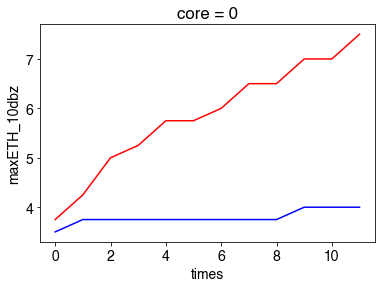

In [39]:
ds_narrow_d2.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.median(dim='tracks').plot(color='b')
ds_wide_d2.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.median(dim='tracks').plot(color='r')

(array([ 0.,  0.,  0.,  0.,  8., 12., 12., 11., 10., 13., 10.,  5.,  3.,
         6.,  5.,  3.,  1.,  0.,  0.]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19]),
 <BarContainer object of 19 artists>)

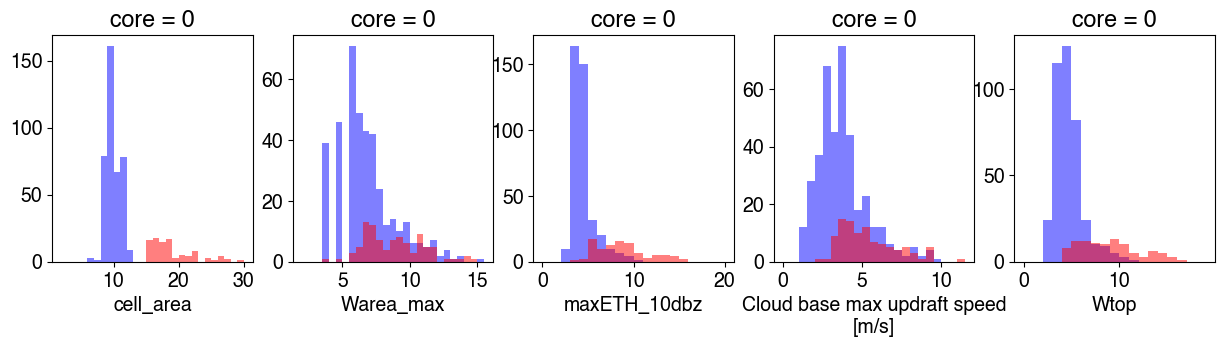

In [40]:
fig, axes = plt.subplots(1, 5, figsize=(15,3), dpi=100)
ax0 = axes[0]
bins = np.arange(2, 31, 1)
narrow_maxdiam_d2.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax0)
wide_maxdiam_d2.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax0)
ax1 = axes[1]
bins = np.arange(2, 16, 0.5)
narrow_maxWdiam_d2.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax1)
wide_maxWdiam_d2.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax1)
ax2 = axes[2]
bins = np.arange(0, 21, 1)
narrow_maxETH10dbz_d2.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax2)
wide_maxETH10dbz_d2.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax2)
ax3 = axes[3]
bins = np.arange(0, 12, 0.5)
narrow_maxWspeed_d2.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax3)
wide_maxWspeed_d2.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax3)
ax4 = axes[4]
bins = np.arange(0, 20, 1)
narrow_maxWtop_d2.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax4)
wide_maxWtop_d2.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax4)

In [41]:
# # Define narrow vs. wide thresholds
# narrow_diam_d3 = maxCellDiam_pts_d3.sel(quantile=narrow_qt).item()
# wide_diam_d3 = maxCellDiam_pts_d3.sel(quantile=wide_qt).item()
# print(f'Narrow diameter threshold (D3): {narrow_diam_d3:.02f} km')
# print(f'Wide diameter threshold (D3): {wide_diam_d3:.02f} km')

# Define narrow vs. wide thresholds
narrow_diam_d3 = narrow_qt_thresh_d3
wide_diam_d3 = wide_qt_thresh_d3
print(f'Narrow diameter threshold (D3): {narrow_diam_d3:.02f} km')
print(f'Wide diameter threshold (D3): {wide_diam_d3:.02f} km')

# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
narrow_tracks_d3 = ((trackmaxCellDiam_d3 < narrow_diam_d3) & (MULNB_d3 > MULNB_thresh) \
                    & (dsnms_d3.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# wide_tracks_d3 = ((trackmaxCellDiam_d3 >= wide_diam_d3) & (MULNB_d3 > MULNB_thresh)).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d3 = ((trackmaxCellDiam_d3 >= wide_diam_d3) & (MULNB_d3 > MULNB_thresh) \
                  & (dsnms_d3.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d3.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                 ).compute()
# Subset DataSets
ds_narrow_d3 = dsnms_d3.where(narrow_tracks_d3, drop=True)
ds_wide_d3 = dsnms_d3.where(wide_tracks_d3, drop=True)
ntracks_narrow_d3 = ds_narrow_d3.sizes['tracks']
ntracks_wide_d3 = ds_wide_d3.sizes['tracks']
print(f'Number of narrow cells (D3): {ntracks_narrow_d3}')
print(f'Number of wide cells (D3): {ntracks_wide_d3}')

# # Get cell track lifetime: track_duration x time_resolution [min]
# narrow_track_lifetime_d3 = ds_narrow_d3.track_duration * time_res
# wide_track_lifetime_d3 = ds_wide_d3.track_duration * time_res
# # Lifetime-max reflectivity
# narrow_maxdbz_d3 = ds_narrow_d3.max_dbz.max(dim='times')
# wide_maxdbz_d3 = ds_wide_d3.max_dbz.max(dim='times')
# # Lifetime-max 10dBZ ETH
# narrow_maxETH10dbz_d3 = ds_narrow_d3.maxETH_10dbz.max(dim='times')
# wide_maxETH10dbz_d3 = ds_wide_d3.maxETH_10dbz.max(dim='times')
# # Lifetime-max diameter
# narrow_maxdiam_d3 = 2 * np.sqrt(ds_narrow_d3.cell_area.max(dim='times') / np.pi)
# wide_maxdiam_d3 = 2 * np.sqrt(ds_wide_d3.cell_area.max(dim='times') / np.pi)

# CI-window lifetime (count number of time a cell exists in the CI window)
narrow_track_lifetime_d3 = (ds_narrow_d3.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
wide_track_lifetime_d3 = (ds_wide_d3.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
# CI-max reflectivity
narrow_maxdbz_d3 = ds_narrow_d3.isel(times=slice(tidx_start, tidx_end)).max_dbz.max(dim='times')
wide_maxdbz_d3 = ds_wide_d3.isel(times=slice(tidx_start, tidx_end)).max_dbz.max(dim='times')
# CI-max 10dBZ ETH
narrow_maxETH10dbz_d3 = ds_narrow_d3.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times')
wide_maxETH10dbz_d3 = ds_wide_d3.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times')
# CI-max Wtop
narrow_maxWtop_d3 = ds_narrow_d3.isel(times=slice(tidx_start, tidx_end)).Wtop.max(dim='times')
wide_maxWtop_d3 = ds_wide_d3.isel(times=slice(tidx_start, tidx_end)).Wtop.max(dim='times')
# CI-max diameter
narrow_maxdiam_d3 = 2 * np.sqrt(ds_narrow_d3.isel(times=slice(tidx_start, tidx_end)).cell_area.max(dim='times') / np.pi)
wide_maxdiam_d3 = 2 * np.sqrt(ds_wide_d3.isel(times=slice(tidx_start, tidx_end)).cell_area.max(dim='times') / np.pi)
# CI-window cloud-base updraft diameter
narrow_medWdiam_d3 = 2 * np.sqrt(ds_narrow_d3.Warea_median / np.pi)
wide_medWdiam_d3 = 2 * np.sqrt(ds_wide_d3.Warea_median / np.pi)
narrow_maxWdiam_d3 = 2 * np.sqrt(ds_narrow_d3.Warea_max / np.pi)
wide_maxWdiam_d3 = 2 * np.sqrt(ds_wide_d3.Warea_max / np.pi)
# CI-window cloud-base updraft speed
narrow_maxWspeed_d3 = ds_narrow_d3.Wspeed_max
wide_maxWspeed_d3 = ds_wide_d3.Wspeed_max

Narrow diameter threshold (D3): 12.93 km
Wide diameter threshold (D3): 15.45 km
Number of narrow cells (D3): 349
Number of wide cells (D3): 54


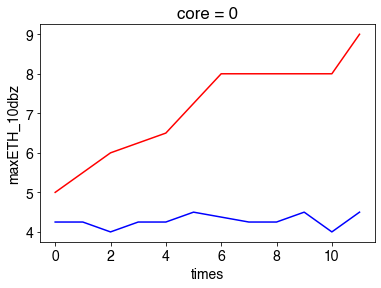

In [42]:
ds_narrow_d3.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.median(dim='tracks').plot(color='b')
ds_wide_d3.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.median(dim='tracks').plot(color='r')

(array([0., 0., 1., 8., 5., 7., 5., 5., 8., 5., 5., 2., 2., 0., 0., 0., 1.,
        0., 0.]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19]),
 <BarContainer object of 19 artists>)

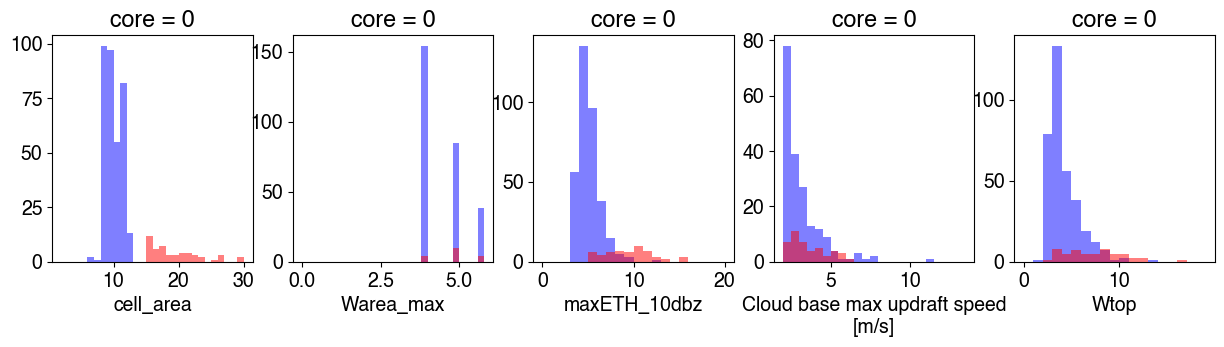

In [43]:
fig, axes = plt.subplots(1, 5, figsize=(15,3), dpi=100)
ax0 = axes[0]
bins = np.arange(2, 31, 1)
narrow_maxdiam_d3.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax0)
wide_maxdiam_d3.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax0)
ax1 = axes[1]
bins = np.arange(0, 6, 0.2)
narrow_maxWdiam_d3.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax1)
wide_maxWdiam_d3.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax1)
ax2 = axes[2]
bins = np.arange(0, 21, 1)
narrow_maxETH10dbz_d3.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax2)
wide_maxETH10dbz_d3.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax2)
ax3 = axes[3]
bins = np.arange(2, 14, 0.5)
narrow_maxWspeed_d3.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax3)
wide_maxWspeed_d3.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax3)
ax4 = axes[4]
bins = np.arange(0, 20, 1)
narrow_maxWtop_d3.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax4)
wide_maxWtop_d3.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax4)

In [44]:
# # Define narrow vs. wide thresholds
# narrow_diam_d4 = maxCellDiam_pts_d4.sel(quantile=narrow_qt).item()
# wide_diam_d4 = maxCellDiam_pts_d4.sel(quantile=wide_qt).item()
# print(f'Narrow diameter threshold (D4): {narrow_diam_d4:.02f} km')
# print(f'Wide diameter threshold (D4): {wide_diam_d4:.02f} km')

# Define narrow vs. wide thresholds
narrow_diam_d4 = narrow_qt_thresh_d4
wide_diam_d4 = wide_qt_thresh_d4
print(f'Narrow diameter threshold (D4): {narrow_diam_d4:.02f} km')
print(f'Wide diameter threshold (D4): {wide_diam_d4:.02f} km')

# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
narrow_tracks_d4 = ((trackmaxCellDiam_d4 < narrow_diam_d4) & (MULNB_d4 > MULNB_thresh) \
                   & (dsnms_d4.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# wide_tracks_d4 = ((trackmaxCellDiam_d4 >= wide_diam_d4) & (MULNB_d4 > MULNB_thresh)).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d4 = ((trackmaxCellDiam_d4 >= wide_diam_d4) & (MULNB_d4 > MULNB_thresh) \
                  & (dsnms_d4.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d4.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                 ).compute()
# Subset DataSets
ds_narrow_d4 = dsnms_d4.where(narrow_tracks_d4, drop=True)
ds_wide_d4 = dsnms_d4.where(wide_tracks_d4, drop=True)
ntracks_narrow_d4 = ds_narrow_d4.sizes['tracks']
ntracks_wide_d4 = ds_wide_d4.sizes['tracks']
print(f'Number of narrow cells (D4): {ntracks_narrow_d4}')
print(f'Number of wide cells (D4): {ntracks_wide_d4}')

# # Get cell track lifetime: track_duration x time_resolution [min]
# narrow_track_lifetime_d4 = ds_narrow_d4.track_duration * time_res
# wide_track_lifetime_d4 = ds_wide_d4.track_duration * time_res
# # Lifetime-max reflectivity
# narrow_maxdbz_d4 = ds_narrow_d4.max_dbz.max(dim='times')
# wide_maxdbz_d4 = ds_wide_d4.max_dbz.max(dim='times')
# # Lifetime-max 10dBZ ETH
# narrow_maxETH10dbz_d4 = ds_narrow_d4.maxETH_10dbz.max(dim='times')
# wide_maxETH10dbz_d4 = ds_wide_d4.maxETH_10dbz.max(dim='times')
# # Lifetime-max diameter
# narrow_maxdiam_d4 = 2 * np.sqrt(ds_narrow_d4.cell_area.max(dim='times') / np.pi)
# wide_maxdiam_d4 = 2 * np.sqrt(ds_wide_d4.cell_area.max(dim='times') / np.pi)
# CI-window lifetime (count number of time a cell exists in the CI window)
narrow_track_lifetime_d4 = (ds_narrow_d4.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
wide_track_lifetime_d4 = (ds_wide_d4.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
# CI-max reflectivity
narrow_maxdbz_d4 = ds_narrow_d4.isel(times=slice(tidx_start, tidx_end)).max_dbz.max(dim='times')
wide_maxdbz_d4 = ds_wide_d4.isel(times=slice(tidx_start, tidx_end)).max_dbz.max(dim='times')
# CI-max 10dBZ ETH
narrow_maxETH10dbz_d4 = ds_narrow_d4.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times')
wide_maxETH10dbz_d4 = ds_wide_d4.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times')
# CI-max Wtop
narrow_maxWtop_d4 = ds_narrow_d4.isel(times=slice(tidx_start, tidx_end)).Wtop.max(dim='times')
wide_maxWtop_d4 = ds_wide_d4.isel(times=slice(tidx_start, tidx_end)).Wtop.max(dim='times')
# CI-max diameter
narrow_maxdiam_d4 = 2 * np.sqrt(ds_narrow_d4.isel(times=slice(tidx_start, tidx_end)).cell_area.max(dim='times') / np.pi)
wide_maxdiam_d4 = 2 * np.sqrt(ds_wide_d4.isel(times=slice(tidx_start, tidx_end)).cell_area.max(dim='times') / np.pi)
# CI-window cloud-base updraft diameter
narrow_medWdiam_d4 = 2 * np.sqrt(ds_narrow_d4.Warea_median / np.pi)
wide_medWdiam_d4 = 2 * np.sqrt(ds_wide_d4.Warea_median / np.pi)
narrow_maxWdiam_d4 = 2 * np.sqrt(ds_narrow_d4.Warea_max / np.pi)
wide_maxWdiam_d4 = 2 * np.sqrt(ds_wide_d4.Warea_max / np.pi)
# CI-window cloud-base updraft speed
narrow_maxWspeed_d4 = ds_narrow_d4.Wspeed_max
wide_maxWspeed_d4 = ds_wide_d4.Wspeed_max

Narrow diameter threshold (D4): 12.93 km
Wide diameter threshold (D4): 14.66 km
Number of narrow cells (D4): 329
Number of wide cells (D4): 79


## Create Pandas DataFrame in long format for split violin plots

In [45]:
def make_df(var_n_d2, var_n_d3, var_n_d4, var_w_d2, var_w_d3, var_w_d4, varname):
    var_d2 = np.hstack((var_n_d2.values, var_w_d2.values))
    CellType_d2 = np.hstack((np.full(len(var_n_d2), 'Narrow'), np.full(len(var_w_d2), 'Wide')))

    var_d3 = np.hstack((var_n_d3.values, var_w_d3.values))
    CellType_d3 = np.hstack((np.full(len(var_n_d3), 'Narrow'), np.full(len(var_w_d3), 'Wide')))

    var_d4 = np.hstack((var_n_d4.values, var_w_d4.values))
    CellType_d4 = np.hstack((np.full(len(var_n_d4), 'Narrow'), np.full(len(var_w_d4), 'Wide')))

    # Create a DataFrame for each dataset
    df2 = pd.DataFrame({varname: var_d2, 'Cell Type': CellType_d2, 'WRF': '2.5 km'})
    df3 = pd.DataFrame({varname: var_d3, 'Cell Type': CellType_d3, 'WRF': '500 m'})
    df4 = pd.DataFrame({varname: var_d4, 'Cell Type': CellType_d4, 'WRF': '100 m'})

    # Concatenate the DataFrames into one long DataFrame
    df = pd.concat([df2, df3, df4], ignore_index=True)
    return df

In [46]:
df_maxETH10dbz = make_df(narrow_maxETH10dbz_d2, narrow_maxETH10dbz_d3, narrow_maxETH10dbz_d4, 
                         wide_maxETH10dbz_d2, wide_maxETH10dbz_d3, wide_maxETH10dbz_d4, 'Max 10dBZ ETH (km)')

df_maxWtop = make_df(narrow_maxWtop_d2, narrow_maxWtop_d3, narrow_maxWtop_d4, 
                     wide_maxWtop_d2, wide_maxWtop_d3, wide_maxWtop_d4, 'Max Updraft Top (km)')

df_maxdbz = make_df(narrow_maxdbz_d2, narrow_maxdbz_d3, narrow_maxdbz_d4, 
                     wide_maxdbz_d2, wide_maxdbz_d3, wide_maxdbz_d4, 'Max Reflectivity (dBZ)')

### Function to plot 1 violin and 2 split violin plots

In [47]:
def plot_combined_violin(nrow, ncol, violin_data, split_data, qnt1=None, qnt2=None, text1=None, text2=None,
                        x_names=None, y_names=None, hue=None, sigtest=None, sig_markersize=None,
                        samplesize=None, ypos_sample=None, wspace=None, hspace=None, gap=.15, box_width=.1,
                        ylabels=None, ylims=None, titles=None, fontsize=None, figsize=None, figname=None, dpi=300):
    """
    Combined function to plot violin plots (column 1) and split violin plots (columns 2-3).
    
    Args:
        violin_data: list of lists
            Data for regular violin plots (column 1).
        split_data: list of lists  
            Data for split violin plots (columns 2-3).
        qnt1, qnt2: quantile data for violin plots
        text1, text2: text labels for quantile lines
        x_names, y_names: column names for split violin plots
        hue: hue variable for split violin plots
        sigtest: significance test results
        sig_markersize: marker size for significance indicators
        Other parameters: similar to original functions
    """
    
    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    
    fig = plt.figure(figsize=figsize, dpi=100)    
    # Set up panels (nrow x ncol)
    h_ratios = list(np.repeat(1, nrow))
    w_ratios = list(np.repeat(1, ncol))
    gs = gridspec.GridSpec(nrow, ncol, figure=fig, height_ratios=h_ratios, width_ratios=w_ratios, wspace=wspace, hspace=hspace)
    
    # Color definitions
    lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
    name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}
    # name_map = {'d2':r'2.5 km', 'd3':r'500 m$\rightarrow$2.5 km', 'd4':r'100 m$\rightarrow$2.5 km'}
    qnt_colors = {'d2':'deepskyblue', 'd3':'springgreen', 'd4':'violet'}
    
    # Violin plot settings
    palette = list(lcolors.values())
    lw_qnt = 2
    lw_kde = 2
    size_avg = 60
    annotation_scale = 0.85
    color_avg = 'red'
    color_med = 'white'
    xlabels = list(name_map.values())
    leg_fontsize = fontsize
    
    # Split violin plot settings - use same colors as violin plots
    custom_palette = {'Narrow': 'orange', 'Wide': 'springgreen'}
       
    for row in range(nrow):
        for col in range(ncol):
            ax = plt.subplot(gs[row, col])
            
            if (col == 0) and (row == 0):  # Row 1 & Column 1: Regular violin plot
                data = violin_data[row][col]
                qnt1_data = qnt1[row][col] if qnt1 is not None else None
                qnt2_data = qnt2[row][col] if qnt2 is not None else None
                
                if qnt1_data is not None and qnt2_data is not None:
                    qnt1_2, qnt1_3, qnt1_4 = qnt1_data[0], qnt1_data[1], qnt1_data[2]
                    qnt2_2, qnt2_3, qnt2_4 = qnt2_data[0], qnt2_data[1], qnt2_data[2]

                # Calculate means and medians
                avg2 = np.nanmean(data[0])
                avg3 = np.nanmean(data[1])
                avg4 = np.nanmean(data[2])
                med2 = np.nanmedian(data[0])
                med3 = np.nanmedian(data[1])
                med4 = np.nanmedian(data[2])
                
                # Violin plot
                vp = sns.violinplot(data=data, ax=ax, palette=palette, linewidth=lw_kde)
                
                # Plot median value as line
                ax.hlines(med2, -0.1, 0.1, lw=2, color=color_med, zorder=4)
                ax.hlines(med3, 0.9, 1.1, lw=2, color=color_med, zorder=4)
                ax.hlines(med4, 1.9, 2.1, lw=2, color=color_med, zorder=4)
                
                # Plot mean value as circle
                ax.scatter(0, avg2, color=color_avg, s=size_avg, zorder=3)
                ax.scatter(1, avg3, color=color_avg, s=size_avg, zorder=3)
                ax.scatter(2, avg4, color=color_avg, s=size_avg, zorder=3)
                
                # Plot quantile lines
                if qnt1_data is not None and qnt2_data is not None:
                    ax.hlines(qnt1_2, -0.4, 0.4, lw=lw_qnt, color=qnt_colors['d2'], zorder=5)
                    ax.hlines(qnt1_3, 0.6, 1.4, lw=lw_qnt, color=qnt_colors['d3'], zorder=5)
                    ax.hlines(qnt1_4, 1.6, 2.4, lw=lw_qnt, color=qnt_colors['d4'], zorder=5)
                
                    ax.hlines(qnt2_2, -0.4, 0.4, lw=lw_qnt, color=qnt_colors['d2'], ls='--', zorder=5)
                    ax.hlines(qnt2_3, 0.6, 1.4, lw=lw_qnt, color=qnt_colors['d3'], ls='--', zorder=5)
                    ax.hlines(qnt2_4, 1.6, 2.4, lw=lw_qnt, color=qnt_colors['d4'], ls='--', zorder=5)
                    
                    if text1 is not None and text2 is not None:
                        ax.text(0.4, qnt1_2-0.25, text1[row][col][0], color=qnt_colors['d2'], va='top', ha='center', fontsize=leg_fontsize*annotation_scale, weight='bold')
                        ax.text(1.4, qnt1_3-0.25, text1[row][col][1], color=qnt_colors['d3'], va='top', ha='center', fontsize=leg_fontsize*annotation_scale, weight='bold')
                        ax.text(2.4, qnt1_4-0.25, text1[row][col][2], color=qnt_colors['d4'], va='top', ha='center', fontsize=leg_fontsize*annotation_scale, weight='bold')
                        
                        ax.text(0.4, qnt2_2+0.1, text2[row][col][0], color=qnt_colors['d2'], va='bottom', ha='center', fontsize=leg_fontsize*annotation_scale, weight='bold')
                        ax.text(1.4, qnt2_3+0.1, text2[row][col][1], color=qnt_colors['d3'], va='bottom', ha='center', fontsize=leg_fontsize*annotation_scale, weight='bold')
                        ax.text(2.4, qnt2_4+0.1, text2[row][col][2], color=qnt_colors['d4'], va='bottom', ha='center', fontsize=leg_fontsize*annotation_scale, weight='bold')
                
                # Set plots
                ax.set_xticklabels(xlabels)
                ax.grid(ls=':', axis='y')
                
                if samplesize is not None and ypos_sample is not None:
                    ax.text(0.05, ypos_sample[row], samplesize['d2'], color=lcolors['d2'], va='top', fontsize=leg_fontsize*annotation_scale, weight='bold')
                    ax.text(1.05, ypos_sample[row], samplesize['d3'], color=lcolors['d3'], va='top', fontsize=leg_fontsize*annotation_scale, weight='bold')
                    ax.text(2.05, ypos_sample[row], samplesize['d4'], color=lcolors['d4'], va='top', fontsize=leg_fontsize*annotation_scale, weight='bold')
                    
            else:  # Columns 2-3: Split violin plots
                # Determine the correct index for split_data
                if row == 0 and col == 1:
                    data_idx = (0, 1)  # First row, second column
                elif row == 1 and col == 0:
                    data_idx = (1, 0)  # Second row, first column
                elif row == 1 and col == 1:
                    data_idx = (1, 1)  # Second row, second column

                # data = split_data[row][col-1]  # Adjust index since split_data has 2 columns
                data = split_data[data_idx[0]][data_idx[1]]
                
                # Violin plot (skip box plot: inner=None)
                vp = sns.violinplot(x=x_names[row][col], y=y_names[row][col], hue=hue, data=data, 
                                   split=True, gap=gap, palette=custom_palette, inner=None, ax=ax)
                
                # Overlay the box plot with custom properties
                sns.boxplot(x=x_names[row][col], y=y_names[row][col], hue=hue, data=data, 
                           width=box_width, showcaps=False, showfliers=False,
                           boxprops={'facecolor':'k', 'edgecolor':'k'}, 
                           whiskerprops={'linewidth':2, 'color':'black'},
                           capprops={'visible': False},
                           medianprops={'color':'white', 'linewidth':2},
                           dodge=True, ax=ax)
                               
                # Add significance test below each x-axis label
                if sigtest is not None:
                    for i, label in enumerate(ax.get_xticks()):
                        ax.text(i, -0.1, sigtest[row][i], ha='center', va='top', fontsize=sig_markersize, color='r', transform=ax.get_xaxis_transform())
                
                # Remove the legend created by the boxplot, keep only for first split violin plot
                handles, labels = ax.get_legend_handles_labels()
                if (row == 0) & (col == 1):  # First split violin plot
                    ax.legend(handles[:2], labels[:2], title='', 
                             loc='lower right', bbox_to_anchor=(1, 0.85), ncol=2)
                else:
                    ax.legend([],[], frameon=False)
                
                # Set xlabel
                ax.set_xlabel('')
                ax.grid(ls=':', axis='y')
            
            # Common settings for all plots
            if ylabels is not None:
                ax.set_ylabel(ylabels[row][col])
            if ylims is not None:
                ax.set_ylim(ylims[row][col][0], ylims[row][col][1])
            if titles is not None:
                ax.set_title(titles[row][col], loc='left')

    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/ViolinSplit_NarrowWide_2x2_maxDiameter_maxETH10dBZ_maxdBZ_maxWTop_d2_d3_d4.png


/tmp/ipykernel_266963/1813001065.py:105: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)


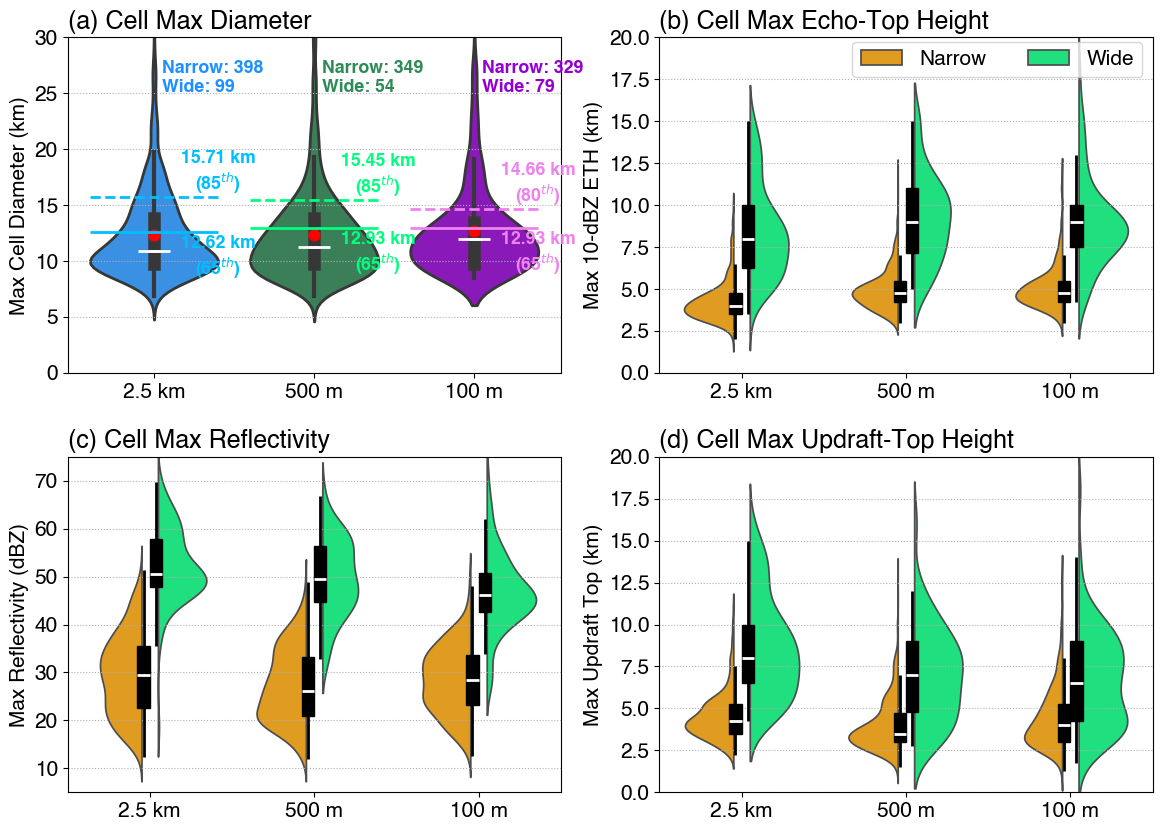

In [48]:
# Example usage combining both types of plots
violin_data_arr = [
    [[dsfilt_d2.CImaxCellDiam.data, dsfilt_d3.CImaxCellDiam.data, dsfilt_d4.CImaxCellDiam.data], None],  # Row 0: violin data, None for split violin
    [None, None]  # Row 1: both will be split violins, so None for both
]

split_data_arr = [
    [None, df_maxETH10dbz],  # Row 0: None for violin, df_maxETH10dbz for split violin
    [df_maxdbz, df_maxWtop]  # Row 1: both split violins
]

qnt_narrow = [
    [[narrow_qt_thresh_d2, narrow_qt_thresh_d3, narrow_qt_thresh_d4], None],  # Row 0
    [None, None]  # Row 1
]

qnt_wide = [
    [[wide_qt_thresh_d2, wide_qt_thresh_d3, wide_qt_thresh_d4], None],  # Row 0
    [None, None]  # Row 1
]

texts_narrow = [
    [[f"{narrow_qt_thresh_d2:.2f} km\n({narrow_qt_d2:.0f}$^{{th}}$)", 
      f"{narrow_qt_thresh_d3:.2f} km\n({narrow_qt_d3:.0f}$^{{th}}$)", 
      f"{narrow_qt_thresh_d4:.2f} km\n({narrow_qt_d4:.0f}$^{{th}}$)"], None],  # Row 0
    [None, None]  # Row 1
]

texts_wide = [
    [[f"{wide_qt_thresh_d2:.2f} km\n({wide_qt_d2:.0f}$^{{th}}$)", 
      f"{wide_qt_thresh_d3:.2f} km\n({wide_qt_d3:.0f}$^{{th}}$)", 
      f"{wide_qt_thresh_d4:.2f} km\n({wide_qt_d4:.0f}$^{{th}}$)"], None],  # Row 0
    [None, None]  # Row 1
]

# Significance test data (example)
sigtest = None

samplesize = {
    'd2': f"Narrow: {ntracks_narrow_d2}\nWide: {ntracks_wide_d2}",
    'd3': f"Narrow: {ntracks_narrow_d3}\nWide: {ntracks_wide_d3}",
    'd4': f"Narrow: {ntracks_narrow_d4}\nWide: {ntracks_wide_d4}",
}

nrow = 2
ncol = 2
x_names = [
    [None, 'WRF'],  # Row 0: None for violin plot, 'WRF' for split violin
    ['WRF', 'WRF']  # Row 1: both split violins use 'WRF'
]
y_names = [
    [None, 'Max 10dBZ ETH (km)'],  # Row 0
    ['Max Reflectivity (dBZ)', 'Max Updraft Top (km)']
]
hue = 'Cell Type'
titles = [
    ['(a) Cell Max Diameter', '(b) Cell Max Echo-Top Height'], 
    ['(c) Cell Max Reflectivity', '(d) Cell Max Updraft-Top Height']
]
ylabels = [
    ['Max Cell Diameter (km)', 'Max 10-dBZ ETH (km)'], 
    ['Max Reflectivity (dBZ)', 'Max Updraft Top (km)']
]
ylims = [
    [(0,30), (0,20)], 
    [(5,75), (0,20)],
]
ypos_sample = [28, 60]  # Adjust y position for sample size text for each row
gap = .25
box_width = 0.15
sig_markersize = 14
fontsize = 15
figsize = (14, 10)  # Make it taller for 2 rows
hspace = 0.25
figname = f'{figdir}ViolinSplit_NarrowWide_2x2_maxDiameter_maxETH10dBZ_maxdBZ_maxWTop_d2_d3_d4.png'
print(figname)

fig = plot_combined_violin(nrow, ncol, violin_data_arr, split_data_arr, 
                          qnt1=qnt_narrow, qnt2=qnt_wide, text1=texts_narrow, text2=texts_wide,
                          x_names=x_names, y_names=y_names, hue=hue, sigtest=sigtest, sig_markersize=sig_markersize,
                          samplesize=samplesize, ypos_sample=ypos_sample, gap=gap, box_width=box_width, hspace=hspace,
                          ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

## Plot cell counts diurnal cycle

(array([ 0.,  0.,  0.,  1.,  5.,  8.,  9., 12., 12., 20., 11., 13.,  6.,
         2.,  0.]),
 array([ 9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19., 20., 21.,
        22., 23., 24.]),
 <BarContainer object of 15 artists>)

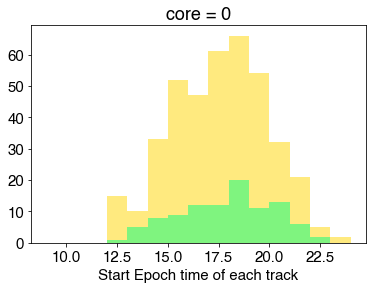

In [49]:
# Hour bins
# hour_bins = np.arange(12,24.1,1)
hour_bins = np.arange(9,24.1,1)
# Bin center
hour_bins_c = hour_bins[0:-1] + np.diff(hour_bins)/2

# Get histogram of track start hours for narrow vs. wide cells
ds_narrow_d2.start_basetime.dt.hour.plot.hist(bins=hour_bins, color='gold', alpha=0.5)
ds_wide_d2.start_basetime.dt.hour.plot.hist(bins=hour_bins, color='springgreen', alpha=0.5)

In [50]:
# Get histogram of track start hours for narrow vs. wide cells, -3 converts UTC to LT
shour_hist_narrow_d2, bins = np.histogram(ds_narrow_d2.start_basetime.dt.hour.data-3, bins=hour_bins)
shour_hist_wide_d2, bins = np.histogram(ds_wide_d2.start_basetime.dt.hour.data-3, bins=hour_bins)

shour_hist_narrow_d3, bins = np.histogram(ds_narrow_d3.start_basetime.dt.hour.data-3, bins=hour_bins)
shour_hist_wide_d3, bins = np.histogram(ds_wide_d3.start_basetime.dt.hour.data-3, bins=hour_bins)

shour_hist_narrow_d4, bins = np.histogram(ds_narrow_d4.start_basetime.dt.hour.data-3, bins=hour_bins)
shour_hist_wide_d4, bins = np.histogram(ds_wide_d4.start_basetime.dt.hour.data-3, bins=hour_bins)

### Function to plot bar plots

In [51]:
def plot_mxn_barplot(nrow, ncol, bins, da, width=None, text1=None, text2=None,
                     wspace=None, hspace=None, xlims=None, ylims=None, show_legend=None,
                     xlabels=None, ylabels=None, titles=None, fontsize=None, figsize=None, figname=None):

    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    
    fig = plt.figure(figsize=figsize, dpi=dpi)
    # Set up panels (nrow x ncol)
    h_ratios = list(np.repeat(1,nrow))
    w_ratios = list(np.repeat(1,ncol))
    wspace = wspace
    hspace = hspace
    gs = gridspec.GridSpec(nrow, ncol, figure=fig, height_ratios=h_ratios, width_ratios=w_ratios, wspace=wspace, hspace=hspace)

    name_map = {'d2':'2.5 km', 'd3':r'500 m$\rightarrow$2.5 km', 'd4':r'100 m$\rightarrow$2.5 km'}
    bar_colors = {'Narrow': 'orange', 'Wide': 'springgreen'}
    leg_fontsize = fontsize  
       
    for row in range(nrow):
        for col in range(ncol):
            # ax = axes[row][col]
            gss = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=gs[row,col])
            ax = plt.subplot(gss[0])
            bar_data = da[row][col]       

            bottom = np.zeros(len(bins))
            # Loop over each item in the dictionary to plot
            for boolean, b_data in bar_data.items():
                # print(boolean)
                p = ax.bar(hour_bins_c, b_data, width, label=boolean, bottom=bottom, color=bar_colors[boolean])
                bottom += b_data
            
            ax.grid(axis='y', ls=':')
            if (show_legend is not None): 
                if (show_legend[row][col]): ax.legend(loc="upper right")
            if (ylims is not None): ax.set_ylim(ylims[row][col][0], ylims[row][col][1])
            if (xlims is not None): ax.set_xlim(xlims[row][col][0], xlims[row][col][1])
            if (ylabels is not None): ax.set_ylabel(ylabels[row][col])
            if (xlabels is not None): ax.set_xlabel(xlabels[row][col])
            if (titles is not None): ax.set_title(titles[row][col], loc='left')
            
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/Diurnal_CellNumber_narrow_wide_d2_d3_d4.png


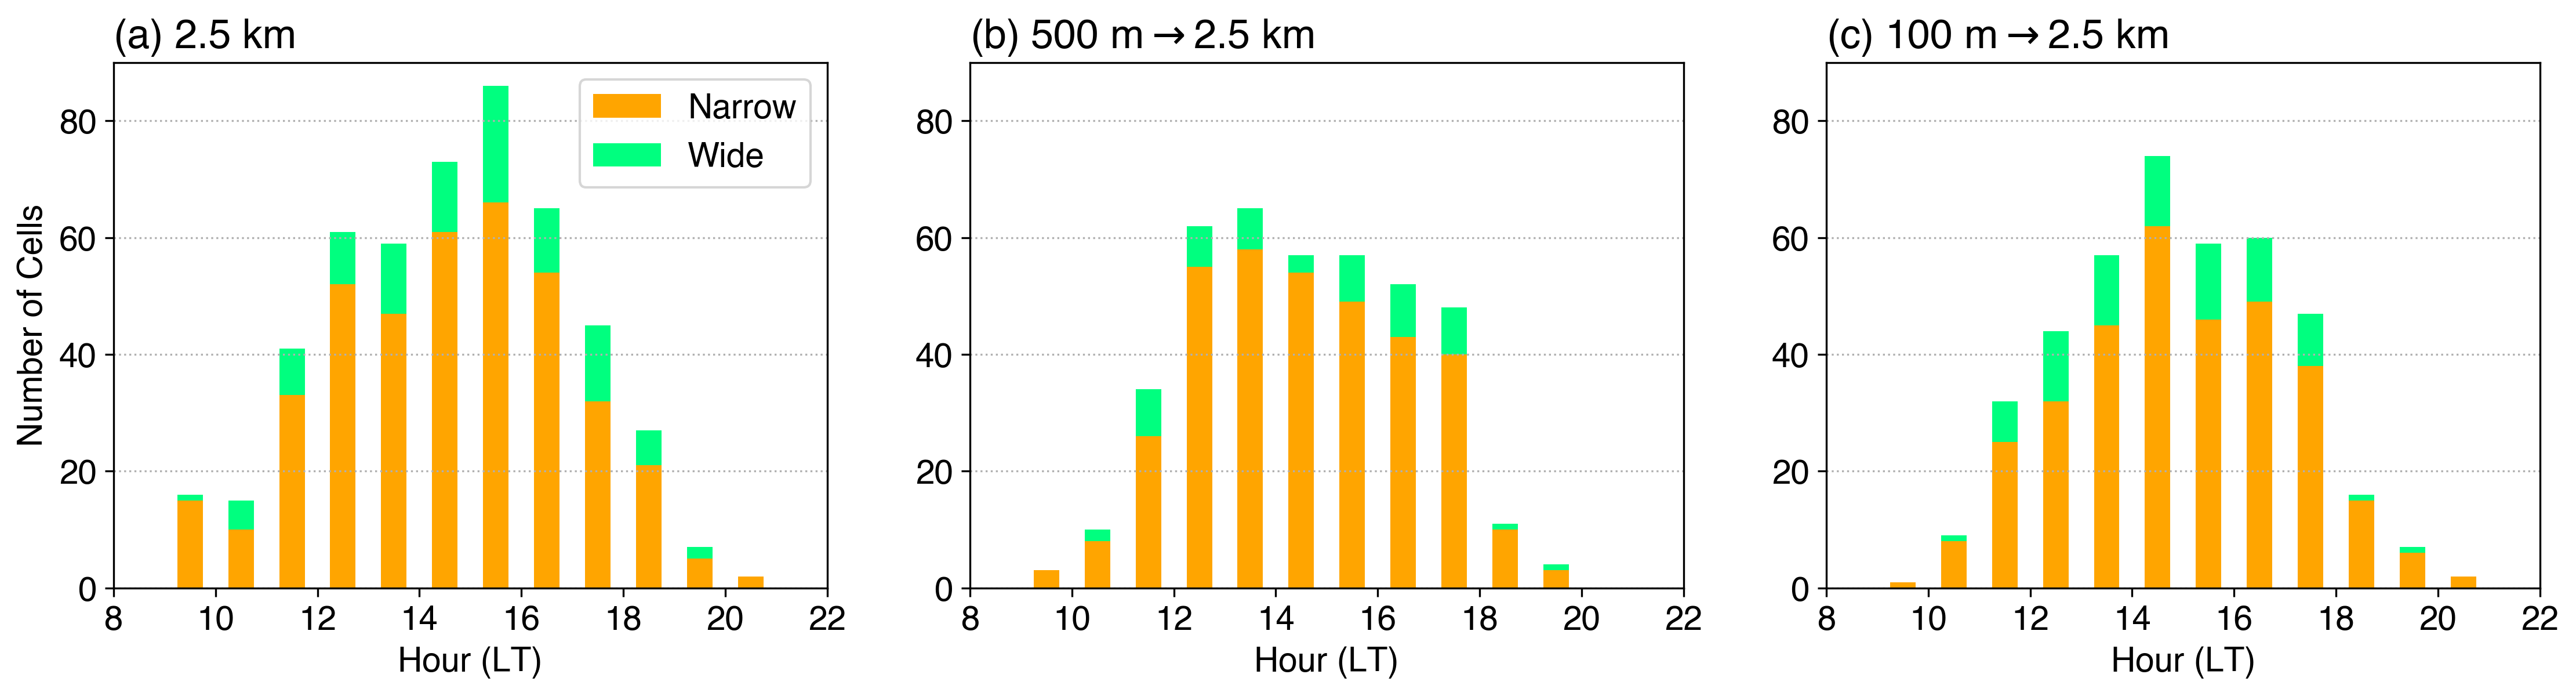

In [52]:
bar_data_d2 = {
    'Narrow': shour_hist_narrow_d2,
    'Wide': shour_hist_wide_d2,
}
bar_data_d3 = {
    'Narrow': shour_hist_narrow_d3,
    'Wide': shour_hist_wide_d3,
}
bar_data_d4 = {
    'Narrow': shour_hist_narrow_d4,
    'Wide': shour_hist_wide_d4,
}
data_arr = [[bar_data_d2, bar_data_d3, bar_data_d4]]
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0

width = 0.5
titles = [['(a) 2.5 km', r'(b) 500 m$\rightarrow$2.5 km', r'(c) 100 m$\rightarrow$2.5 km']]
ylabels = [['Number of Cells', '', '']]
xlims = [[(8,22)]*ncol]
# ylims = [[(0,90), (0,200), (0,200)]]
ylims = [[(0,90), (0,90), (0,90)]]
xlabels = [['Hour (LT)']*ncol]
show_legend = [[True, False, False]]
fontsize = 14
figsize = (18, 4)
figname = f'{figdir}Diurnal_CellNumber_narrow_wide_d2_d3_d4.png'
print(figname)

fig = plot_mxn_barplot(nrow, ncol, hour_bins_c, data_arr, width=width, xlims=xlims, ylims=ylims, fontsize=fontsize, xlabels=xlabels, ylabels=ylabels, titles=titles,
                       show_legend=show_legend, figsize=figsize, figname=figname)

## Get environmental parameters for narrow vs. wide cells

In [53]:
# Narrow cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
narrow_pELmu_d2 = ds_narrow_d2.pEL_height_mu.load()/1000
narrow_pCAPEmu_d2 = ds_narrow_d2.pCAPE_mu.load()
narrow_pCAPEacbl_d2 = ds_narrow_d2.pCAPEacbl_ml.load()
narrow_pCINmu_d2 = ds_narrow_d2.pCIN_mu.load()
narrow_LCLz_d2 = ds_narrow_d2.LCL_height_mu.load()/1000
narrow_LCLt_d2 = ds_narrow_d2.LCL_temp_mu.load()
narrow_pLFCz_d2 = ds_narrow_d2.pLFC_height_mu.load()/1000
# Moisture
narrow_RHacbl_d2 = ds_narrow_d2.RH_mean_ACBL.load()
narrow_RH600mb_d2 = ds_narrow_d2.rh_600mb.load()
narrow_RH500mb_d2 = ds_narrow_d2.rh_500mb.load()
# narrow_RH5km_d2 = ds_narrow_d2.rh_5000masl.load()
narrow_RHlfc1500_d2 = ds_narrow_d2.rh_at_pmuLFCplus1500m.load()
narrow_PW_d2 = ds_narrow_d2.PW.load()
narrow_Q850mb_d2 = ds_narrow_d2.rvap_850mb.load()
# narrow_Q3km_d2 = ds_narrow_d2.rvap_3000masl.load()
# Wind shear
narrow_BWSacbl_d2 = ds_narrow_d2.shear_mag_bulk_ACBL_mu.load()
narrow_BWS03km_d2 = ds_narrow_d2.shear_mag_bulk_0to3km.load()
narrow_BWS06km_d2 = ds_narrow_d2.shear_mag_bulk_0to6km.load()

# Wide cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
wide_pELmu_d2 = ds_wide_d2.pEL_height_mu.load()/1000
wide_pCAPEmu_d2 = ds_wide_d2.pCAPE_mu.load()
wide_pCAPEacbl_d2 = ds_wide_d2.pCAPEacbl_ml.load()
wide_pCINmu_d2 = ds_wide_d2.pCIN_mu.load()
wide_LCLz_d2 = ds_wide_d2.LCL_height_mu.load()/1000
wide_LCLt_d2 = ds_wide_d2.LCL_temp_mu.load()
wide_pLFCz_d2 = ds_wide_d2.pLFC_height_mu.load()/1000
# Moisture
wide_RHacbl_d2 = ds_wide_d2.RH_mean_ACBL.load()
wide_RH600mb_d2 = ds_wide_d2.rh_600mb.load()
wide_RH500mb_d2 = ds_wide_d2.rh_500mb.load()
# wide_RH5km_d2 = ds_wide_d2.rh_5000masl.load()
wide_RHlfc1500_d2 = ds_wide_d2.rh_at_pmuLFCplus1500m.load()
wide_PW_d2 = ds_wide_d2.PW.load()
wide_Q850mb_d2 = ds_wide_d2.rvap_850mb.load()
# wide_Q3km_d2 = ds_wide_d2.rvap_3000masl.load()
# Wind shear
wide_BWSacbl_d2 = ds_wide_d2.shear_mag_bulk_ACBL_mu.load()
wide_BWS03km_d2 = ds_wide_d2.shear_mag_bulk_0to3km.load()
wide_BWS06km_d2 = ds_wide_d2.shear_mag_bulk_0to6km.load()

In [54]:
# Narrow cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
narrow_pELmu_d3 = ds_narrow_d3.pEL_height_mu.load()/1000
narrow_pCAPEmu_d3 = ds_narrow_d3.pCAPE_mu.load()
narrow_pCAPEacbl_d3 = ds_narrow_d3.pCAPEacbl_ml.load()
narrow_pCINmu_d3 = ds_narrow_d3.pCIN_mu.load()
narrow_LCLz_d3 = ds_narrow_d3.LCL_height_mu.load()/1000
narrow_LCLt_d3 = ds_narrow_d3.LCL_temp_mu.load()
narrow_pLFCz_d3 = ds_narrow_d3.pLFC_height_mu.load()/1000
# Moisture
narrow_RHacbl_d3 = ds_narrow_d3.RH_mean_ACBL.load()
narrow_RH600mb_d3 = ds_narrow_d3.rh_600mb.load()
narrow_RH500mb_d3 = ds_narrow_d3.rh_500mb.load()
# narrow_RH5km_d3 = ds_narrow_d3.rh_5000masl.load()
narrow_RHlfc1500_d3 = ds_narrow_d3.rh_at_pmuLFCplus1500m.load()
narrow_PW_d3 = ds_narrow_d3.PW.load()
narrow_Q850mb_d3 = ds_narrow_d3.rvap_850mb.load()
# narrow_Q3km_d3 = ds_narrow_d3.rvap_3000masl.load()
# Wind shear
narrow_BWSacbl_d3 = ds_narrow_d3.shear_mag_bulk_ACBL_mu.load()
narrow_BWS03km_d3 = ds_narrow_d3.shear_mag_bulk_0to3km.load()
narrow_BWS06km_d3 = ds_narrow_d3.shear_mag_bulk_0to6km.load()

# Wide cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
wide_pELmu_d3 = ds_wide_d3.pEL_height_mu.load()/1000
wide_pCAPEmu_d3 = ds_wide_d3.pCAPE_mu.load()
wide_pCAPEacbl_d3 = ds_wide_d3.pCAPEacbl_ml.load()
wide_pCINmu_d3 = ds_wide_d3.pCIN_mu.load()
wide_LCLz_d3 = ds_wide_d3.LCL_height_mu.load()/1000
wide_LCLt_d3 = ds_wide_d3.LCL_temp_mu.load()
wide_pLFCz_d3 = ds_wide_d3.pLFC_height_mu.load()/1000
# Moisture
wide_RHacbl_d3 = ds_wide_d3.RH_mean_ACBL.load()
wide_RH600mb_d3 = ds_wide_d3.rh_600mb.load()
wide_RH500mb_d3 = ds_wide_d3.rh_500mb.load()
# wide_RH5km_d3 = ds_wide_d3.rh_5000masl.load()
wide_RHlfc1500_d3 = ds_wide_d3.rh_at_pmuLFCplus1500m.load()
wide_PW_d3 = ds_wide_d3.PW.load()
wide_Q850mb_d3 = ds_wide_d3.rvap_850mb.load()
# wide_Q3km_d3 = ds_wide_d3.rvap_3000masl.load()
# Wind shear
wide_BWSacbl_d3 = ds_wide_d3.shear_mag_bulk_ACBL_mu.load()
wide_BWS03km_d3 = ds_wide_d3.shear_mag_bulk_0to3km.load()
wide_BWS06km_d3 = ds_wide_d3.shear_mag_bulk_0to6km.load()

In [55]:
# Narrow cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
narrow_pELmu_d4 = ds_narrow_d4.pEL_height_mu.load()/1000
narrow_pCAPEmu_d4 = ds_narrow_d4.pCAPE_mu.load()
narrow_pCAPEacbl_d4 = ds_narrow_d4.pCAPEacbl_ml.load()
narrow_pCINmu_d4 = ds_narrow_d4.pCIN_mu.load()
narrow_LCLz_d4 = ds_narrow_d4.LCL_height_mu.load()/1000
narrow_LCLt_d4 = ds_narrow_d4.LCL_temp_mu.load()
narrow_pLFCz_d4 = ds_narrow_d4.pLFC_height_mu.load()/1000
# Moisture
narrow_RHacbl_d4 = ds_narrow_d4.RH_mean_ACBL.load()
narrow_RH600mb_d4 = ds_narrow_d4.rh_600mb.load()
narrow_RH500mb_d4 = ds_narrow_d4.rh_500mb.load()
# narrow_RH5km_d4 = ds_narrow_d4.rh_5000masl.load()
narrow_RHlfc1500_d4 = ds_narrow_d4.rh_at_pmuLFCplus1500m.load()
narrow_PW_d4 = ds_narrow_d4.PW.load()
narrow_Q850mb_d4 = ds_narrow_d4.rvap_850mb.load()
# narrow_Q3km_d4 = ds_narrow_d4.rvap_3000masl.load()
# Wind shear
narrow_BWSacbl_d4 = ds_narrow_d4.shear_mag_bulk_ACBL_mu.load()
narrow_BWS03km_d4 = ds_narrow_d4.shear_mag_bulk_0to3km.load()
narrow_BWS06km_d4 = ds_narrow_d4.shear_mag_bulk_0to6km.load()

# Wide cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
wide_pELmu_d4 = ds_wide_d4.pEL_height_mu.load()/1000
wide_pCAPEmu_d4 = ds_wide_d4.pCAPE_mu.load()
wide_pCAPEacbl_d4 = ds_wide_d4.pCAPEacbl_ml.load()
wide_pCINmu_d4 = ds_wide_d4.pCIN_mu.load()
wide_LCLz_d4 = ds_wide_d4.LCL_height_mu.load()/1000
wide_LCLt_d4 = ds_wide_d4.LCL_temp_mu.load()
wide_pLFCz_d4 = ds_wide_d4.pLFC_height_mu.load()/1000
# Moisture
wide_RHacbl_d4 = ds_wide_d4.RH_mean_ACBL.load()
wide_RH600mb_d4 = ds_wide_d4.rh_600mb.load()
wide_RH500mb_d4 = ds_wide_d4.rh_500mb.load()
# wide_RH5km_d4 = ds_wide_d4.rh_5000masl.load()
wide_RHlfc1500_d4 = ds_wide_d4.rh_at_pmuLFCplus1500m.load()
wide_PW_d4 = ds_wide_d4.PW.load()
wide_Q850mb_d4 = ds_wide_d4.rvap_850mb.load()
# wide_Q3km_d4 = ds_wide_d4.rvap_3000masl.load()
# Wind shear
wide_BWSacbl_d4 = ds_wide_d4.shear_mag_bulk_ACBL_mu.load()
wide_BWS03km_d4 = ds_wide_d4.shear_mag_bulk_0to3km.load()
wide_BWS06km_d4 = ds_wide_d4.shear_mag_bulk_0to6km.load()

(array([ 0.,  0.,  0.,  3.,  7.,  5., 12.,  7.,  3.,  3.,  6., 11.,  3.,
         4.,  2.,  4.,  2.,  2.,  0.,  1.,  3.,  0.,  1.,  0.,  0.,  0.,
         0.,  0.,  0.]),
 array([0.5 , 0.75, 1.  , 1.25, 1.5 , 1.75, 2.  , 2.25, 2.5 , 2.75, 3.  ,
        3.25, 3.5 , 3.75, 4.  , 4.25, 4.5 , 4.75, 5.  , 5.25, 5.5 , 5.75,
        6.  , 6.25, 6.5 , 6.75, 7.  , 7.25, 7.5 , 7.75]),
 <BarContainer object of 29 artists>)

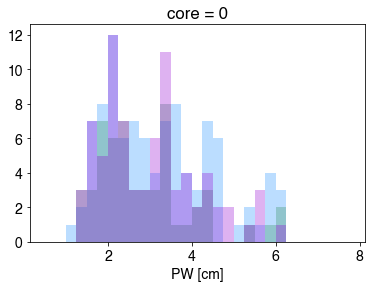

In [56]:
# narrow_RHlfc1500_d4.plot.hist(alpha=0.5)
# wide_RHlfc1500_d4.plot.hist(alpha=0.5)
# narrow_RH5km_d4.plot.hist(alpha=0.5)
# wide_RH5km_d4.plot.hist(alpha=0.5)


lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
bins = np.arange(0.5, 8.0, 0.25)
wide_PW_d2.plot.hist(bins=bins, color=lcolors['d2'], alpha=0.3)
wide_PW_d3.plot.hist(bins=bins, color=lcolors['d3'], alpha=0.3)
wide_PW_d4.plot.hist(bins=bins, color=lcolors['d4'], alpha=0.3)
# wide_PW_d2.where(wide_PW_d2 > 0).plot.hist(bins=bins, color=lcolors['d2'], alpha=0.3)
# wide_PW_d3.where(wide_PW_d3 > 0).plot.hist(bins=bins, color=lcolors['d3'], alpha=0.3)
# wide_PW_d4.where(wide_PW_d4 > 0).plot.hist(bins=bins, color=lcolors['d4'], alpha=0.3)

## Make Pandas Data Frame for Correlograms

In [57]:
# Variable names to include in the Pandas Data Frame
names = [
    'Max 10dBZ ETH', 
    'Max W Top', 
    'Max dBZ', 
    'Lifetime', 
    'Max Diameter', 
    'Max W Diameter', 
    'Max W Speed',
    'MU LNB', 
    '$\sqrt{2*MUCAPE}$', 
    '$\sqrt{2*(ACBL\ CAPE)}$', 
    # '$\sqrt{2*MUCIN}$', 
    'MU LCL Height', 
    'MU LFC Height', 
    # 'MU LCL Temp', 
    '850 hPa Qv', 
    'TCWV', 
    # '500 hPa RH', 
    '600 hPa RH', 
    'ACBL RH', 
    'LFC+1.5km RH',
    'ACBL BWD', 
    '0-3 km BWD', 
    '0-6 km BWD',
]

### Narrow cells

In [58]:
# Create Pandas Data Frames with variables for narrow cells
df_narrow_d2 = pd.DataFrame(columns = names)

df_narrow_d2['Max 10dBZ ETH'] = narrow_maxETH10dbz_d2.data
df_narrow_d2['Max W Top'] = narrow_maxWtop_d2.data
df_narrow_d2['Max dBZ'] = narrow_maxdbz_d2.data
df_narrow_d2['Lifetime'] = narrow_track_lifetime_d2.data
df_narrow_d2['Max Diameter'] = narrow_maxdiam_d2.data
df_narrow_d2['Max W Diameter'] = narrow_maxWdiam_d2.data
df_narrow_d2['Max W Speed'] = narrow_maxWspeed_d2.data
df_narrow_d2['MU LNB'] = narrow_pELmu_d2.data
df_narrow_d2['$\sqrt{2*MUCAPE}$'] = np.sqrt(2*narrow_pCAPEmu_d2.data)
df_narrow_d2['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*narrow_pCAPEacbl_d2.data)
# df_narrow_d2['$\sqrt{2*MUCIN}$'] = np.sqrt(2*narrow_pCINmu_d2.data)
df_narrow_d2['MU LCL Height'] = narrow_LCLz_d2.data
df_narrow_d2['MU LFC Height'] = narrow_pLFCz_d2.data
# df_narrow_d2['MU LCL Temp'] = narrow_LCLt_d2.data
df_narrow_d2['TCWV'] = narrow_PW_d2.data
df_narrow_d2['850 hPa Qv'] = narrow_Q850mb_d2.data
# df_narrow_d2['3 km Qv'] = narrow_Q3km_d2.data
# df_narrow_d2['5km RH'] = narrow_RH5km_d2.data
# df_narrow_d2['500 hPa RH'] = narrow_RH500mb_d2.data
df_narrow_d2['600 hPa RH'] = narrow_RH600mb_d2.data
df_narrow_d2['ACBL RH'] = narrow_RHacbl_d2.data
df_narrow_d2['LFC+1.5km RH'] = narrow_RHlfc1500_d2.data
df_narrow_d2['ACBL BWD'] = narrow_BWSacbl_d2.data
df_narrow_d2['0-3 km BWD'] = narrow_BWS03km_d2.data
df_narrow_d2['0-6 km BWD'] = narrow_BWS06km_d2.data

/tmp/ipykernel_266963/3000141319.py:13: RuntimeWarning: invalid value encountered in sqrt
  df_narrow_d2['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*narrow_pCAPEacbl_d2.data)


In [59]:
# Create Pandas Data Frames with variables for narrow cells
df_narrow_d3 = pd.DataFrame(columns = names)

df_narrow_d3['Max 10dBZ ETH'] = narrow_maxETH10dbz_d3.data
df_narrow_d3['Max W Top'] = narrow_maxWtop_d3.data
df_narrow_d3['Max dBZ'] = narrow_maxdbz_d3.data
df_narrow_d3['Lifetime'] = narrow_track_lifetime_d3.data
df_narrow_d3['Max Diameter'] = narrow_maxdiam_d3.data
df_narrow_d3['Max W Diameter'] = narrow_maxWdiam_d3.data
df_narrow_d3['Max W Speed'] = narrow_maxWspeed_d3.data
df_narrow_d3['MU LNB'] = narrow_pELmu_d3.data
df_narrow_d3['$\sqrt{2*MUCAPE}$'] = np.sqrt(2*narrow_pCAPEmu_d3.data)
df_narrow_d3['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*narrow_pCAPEacbl_d3.data)
# df_narrow_d3['$\sqrt{2*MUCIN}$'] = np.sqrt(2*narrow_pCINmu_d3.data)
df_narrow_d3['MU LCL Height'] = narrow_LCLz_d3.data
df_narrow_d3['MU LFC Height'] = narrow_pLFCz_d3.data
# df_narrow_d3['MU LCL Temp'] = narrow_LCLt_d3.data
df_narrow_d3['TCWV'] = narrow_PW_d3.data
df_narrow_d3['850 hPa Qv'] = narrow_Q850mb_d3.data
# df_narrow_d3['3 km Qv'] = narrow_Q3km_d3.data
# df_narrow_d3['5km RH'] = narrow_RH5km_d3.data
# df_narrow_d3['500 hPa RH'] = narrow_RH500mb_d3.data
df_narrow_d3['600 hPa RH'] = narrow_RH600mb_d3.data
df_narrow_d3['ACBL RH'] = narrow_RHacbl_d3.data
df_narrow_d3['LFC+1.5km RH'] = narrow_RHlfc1500_d3.data
df_narrow_d3['ACBL BWD'] = narrow_BWSacbl_d3.data
df_narrow_d3['0-3 km BWD'] = narrow_BWS03km_d3.data
df_narrow_d3['0-6 km BWD'] = narrow_BWS06km_d3.data

/tmp/ipykernel_266963/614351874.py:13: RuntimeWarning: invalid value encountered in sqrt
  df_narrow_d3['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*narrow_pCAPEacbl_d3.data)


In [60]:
# Create Pandas Data Frames with variables for narrow cells
df_narrow_d4 = pd.DataFrame(columns = names)

df_narrow_d4['Max 10dBZ ETH'] = narrow_maxETH10dbz_d4.data
df_narrow_d4['Max W Top'] = narrow_maxWtop_d4.data
df_narrow_d4['Max dBZ'] = narrow_maxdbz_d4.data
df_narrow_d4['Lifetime'] = narrow_track_lifetime_d4.data
df_narrow_d4['Max Diameter'] = narrow_maxdiam_d4.data
df_narrow_d4['Max W Diameter'] = narrow_maxWdiam_d4.data
df_narrow_d4['Max W Speed'] = narrow_maxWspeed_d4.data
df_narrow_d4['MU LNB'] = narrow_pELmu_d4.data
df_narrow_d4['$\sqrt{2*MUCAPE}$'] = np.sqrt(2*narrow_pCAPEmu_d4.data)
df_narrow_d4['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*narrow_pCAPEacbl_d4.data)
# df_narrow_d4['$\sqrt{2*MUCIN}$'] = np.sqrt(2*narrow_pCINmu_d4.data)
df_narrow_d4['MU LCL Height'] = narrow_LCLz_d4.data
df_narrow_d4['MU LFC Height'] = narrow_pLFCz_d4.data
# df_narrow_d4['MU LCL Temp'] = narrow_LCLt_d4.data
df_narrow_d4['TCWV'] = narrow_PW_d4.data
df_narrow_d4['850 hPa Qv'] = narrow_Q850mb_d4.data
# df_narrow_d4['5km RH'] = narrow_RH5km_d4.data
# df_narrow_d4['3 km Qv'] = narrow_Q3km_d4.data
# df_narrow_d4['500 hPa RH'] = narrow_RH500mb_d4.data
df_narrow_d4['600 hPa RH'] = narrow_RH600mb_d4.data
df_narrow_d4['ACBL RH'] = narrow_RHacbl_d4.data
df_narrow_d4['LFC+1.5km RH'] = narrow_RHlfc1500_d4.data
df_narrow_d4['ACBL BWD'] = narrow_BWSacbl_d4.data
df_narrow_d4['0-3 km BWD'] = narrow_BWS03km_d4.data
df_narrow_d4['0-6 km BWD'] = narrow_BWS06km_d4.data

/tmp/ipykernel_266963/2277705084.py:13: RuntimeWarning: invalid value encountered in sqrt
  df_narrow_d4['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*narrow_pCAPEacbl_d4.data)


### Wide cells

In [61]:
# Create Pandas Data Frames with variables for wide cells
df_wide_d2 = pd.DataFrame(columns = names)

df_wide_d2['Max 10dBZ ETH'] = wide_maxETH10dbz_d2.data
df_wide_d2['Max W Top'] = wide_maxWtop_d2.data
df_wide_d2['Max dBZ'] = wide_maxdbz_d2.data
df_wide_d2['Lifetime'] = wide_track_lifetime_d2.data
df_wide_d2['Max Diameter'] = wide_maxdiam_d2.data
df_wide_d2['Max W Diameter'] = wide_maxWdiam_d2.data
df_wide_d2['Max W Speed'] = wide_maxWspeed_d2.data
df_wide_d2['MU LNB'] = wide_pELmu_d2.data
df_wide_d2['$\sqrt{2*MUCAPE}$'] = np.sqrt(2*wide_pCAPEmu_d2.data)
df_wide_d2['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*wide_pCAPEacbl_d2.data)
# df_wide_d2['$\sqrt{2*MUCIN}$'] = np.sqrt(2*wide_pCINmu_d2.data)
df_wide_d2['MU LCL Height'] = wide_LCLz_d2.data
df_wide_d2['MU LFC Height'] = wide_pLFCz_d2.data
# df_wide_d2['MU LCL Temp'] = wide_LCLt_d2.data
df_wide_d2['TCWV'] = wide_PW_d2.data
df_wide_d2['850 hPa Qv'] = wide_Q850mb_d2.data
# df_wide_d2['3 km Qv'] = wide_Q3km_d2.data
# df_wide_d2['5km RH'] = wide_RH5km_d2.data
# df_wide_d2['500 hPa RH'] = wide_RH500mb_d2.data
df_wide_d2['600 hPa RH'] = wide_RH600mb_d2.data
df_wide_d2['ACBL RH'] = wide_RHacbl_d2.data
df_wide_d2['LFC+1.5km RH'] = wide_RHlfc1500_d2.data
df_wide_d2['ACBL BWD'] = wide_BWSacbl_d2.data
df_wide_d2['0-3 km BWD'] = wide_BWS03km_d2.data
df_wide_d2['0-6 km BWD'] = wide_BWS06km_d2.data

/tmp/ipykernel_266963/1084892537.py:13: RuntimeWarning: invalid value encountered in sqrt
  df_wide_d2['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*wide_pCAPEacbl_d2.data)


In [62]:
# Create Pandas Data Frames with variables for wide cells
df_wide_d3 = pd.DataFrame(columns = names)

df_wide_d3['Max 10dBZ ETH'] = wide_maxETH10dbz_d3.data
df_wide_d3['Max W Top'] = wide_maxWtop_d3.data
df_wide_d3['Max dBZ'] = wide_maxdbz_d3.data
df_wide_d3['Lifetime'] = wide_track_lifetime_d3.data
df_wide_d3['Max Diameter'] = wide_maxdiam_d3.data
df_wide_d3['Max W Diameter'] = wide_maxWdiam_d3.data
df_wide_d3['Max W Speed'] = wide_maxWspeed_d3.data
df_wide_d3['MU LNB'] = wide_pELmu_d3.data
df_wide_d3['$\sqrt{2*MUCAPE}$'] = np.sqrt(2*wide_pCAPEmu_d3.data)
df_wide_d3['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*wide_pCAPEacbl_d3.data)
# df_wide_d3['$\sqrt{2*MUCIN}$'] = np.sqrt(2*wide_pCINmu_d3.data)
df_wide_d3['MU LCL Height'] = wide_LCLz_d3.data
df_wide_d3['MU LFC Height'] = wide_pLFCz_d3.data
# df_wide_d3['MU LCL Temp'] = wide_LCLt_d3.data
df_wide_d3['TCWV'] = wide_PW_d3.data
df_wide_d3['850 hPa Qv'] = wide_Q850mb_d3.data
# df_wide_d3['3 km Qv'] = wide_Q3km_d3.data
# df_wide_d3['5km RH'] = wide_RH5km_d3.data
# df_wide_d3['500 hPa RH'] = wide_RH500mb_d3.data
df_wide_d3['600 hPa RH'] = wide_RH600mb_d3.data
df_wide_d3['ACBL RH'] = wide_RHacbl_d3.data
df_wide_d3['LFC+1.5km RH'] = wide_RHlfc1500_d3.data
df_wide_d3['ACBL BWD'] = wide_BWSacbl_d3.data
df_wide_d3['0-3 km BWD'] = wide_BWS03km_d3.data
df_wide_d3['0-6 km BWD'] = wide_BWS06km_d3.data

In [63]:
# Create Pandas Data Frames with variables for wide cells
df_wide_d4 = pd.DataFrame(columns = names)

df_wide_d4['Max 10dBZ ETH'] = wide_maxETH10dbz_d4.data
df_wide_d4['Max W Top'] = wide_maxWtop_d4.data
df_wide_d4['Max dBZ'] = wide_maxdbz_d4.data
df_wide_d4['Lifetime'] = wide_track_lifetime_d4.data
df_wide_d4['Max Diameter'] = wide_maxdiam_d4.data
df_wide_d4['Max W Diameter'] = wide_maxWdiam_d4.data
df_wide_d4['Max W Speed'] = wide_maxWspeed_d4.data
df_wide_d4['MU LNB'] = wide_pELmu_d4.data
df_wide_d4['$\sqrt{2*MUCAPE}$'] = np.sqrt(2*wide_pCAPEmu_d4.data)
df_wide_d4['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*wide_pCAPEacbl_d4.data)
# df_wide_d4['$\sqrt{2*MUCIN}$'] = np.sqrt(2*wide_pCINmu_d4.data)
df_wide_d4['MU LCL Height'] = wide_LCLz_d4.data
df_wide_d4['MU LFC Height'] = wide_pLFCz_d4.data
# df_wide_d4['MU LCL Temp'] = wide_LCLt_d4.data
df_wide_d4['TCWV'] = wide_PW_d4.data
df_wide_d4['850 hPa Qv'] = wide_Q850mb_d4.data
# df_wide_d4['3 km Qv'] = wide_Q3km_d4.data
# df_wide_d4['5km RH'] = wide_RH5km_d4.data
# df_wide_d4['500 hPa RH'] = wide_RH500mb_d4.data
df_wide_d4['600 hPa RH'] = wide_RH600mb_d4.data
df_wide_d4['ACBL RH'] = wide_RHacbl_d4.data
df_wide_d4['LFC+1.5km RH'] = wide_RHlfc1500_d4.data
df_wide_d4['ACBL BWD'] = wide_BWSacbl_d4.data
df_wide_d4['0-3 km BWD'] = wide_BWS03km_d4.data
df_wide_d4['0-6 km BWD'] = wide_BWS06km_d4.data

In [64]:
# compute correlations between all pandas data frame variables
corr_df_narrow_pearson_d2 = df_narrow_d2.corr(method='pearson')
corr_df_narrow_spearman_d2 = df_narrow_d2.corr(method='spearman')

corr_df_wide_pearson_d2 = df_wide_d2.corr(method='pearson')
corr_df_wide_spearman_d2 = df_wide_d2.corr(method='spearman')

# Compute significance of correlations
p_df_narrow_spearman_d2 = spearmanr_pvalues(df_narrow_d2)
p_df_narrow_pearson_d2 = pearsonr_pvalues(df_narrow_d2)

p_df_wide_spearman_d2 = spearmanr_pvalues(df_wide_d2)
p_df_wide_pearson_d2 = pearsonr_pvalues(df_wide_d2)

In [65]:
#compute correlations between all pandas data frame variables
corr_df_narrow_pearson_d3 = df_narrow_d3.corr(method='pearson')
corr_df_narrow_spearman_d3 = df_narrow_d3.corr(method='spearman')

corr_df_wide_pearson_d3 = df_wide_d3.corr(method='pearson')
corr_df_wide_spearman_d3 = df_wide_d3.corr(method='spearman')

# Compute significance of correlations
p_df_narrow_spearman_d3 = spearmanr_pvalues(df_narrow_d3)
p_df_narrow_pearson_d3 = pearsonr_pvalues(df_narrow_d3)

p_df_wide_spearman_d3 = spearmanr_pvalues(df_wide_d3)
p_df_wide_pearson_d3 = pearsonr_pvalues(df_wide_d3)

In [66]:
#compute correlations between all pandas data frame variables
corr_df_narrow_pearson_d4 = df_narrow_d4.corr(method='pearson')
corr_df_narrow_spearman_d4 = df_narrow_d4.corr(method='spearman')

corr_df_wide_pearson_d4 = df_wide_d4.corr(method='pearson')
corr_df_wide_spearman_d4 = df_wide_d4.corr(method='spearman')

# Compute significance of correlations
p_df_narrow_spearman_d4 = spearmanr_pvalues(df_narrow_d4)
p_df_narrow_pearson_d4 = pearsonr_pvalues(df_narrow_d4)

p_df_wide_spearman_d4 = spearmanr_pvalues(df_wide_d4)
p_df_wide_pearson_d4 = pearsonr_pvalues(df_wide_d4)

## Custome correlogram plotting function

In [67]:
def custom_correlogram(corr_df, p_df, var_groups, group_colors, group_names, 
                      figsize=(12, 12), figname=None,
                      title='Correlogram', alpha_nonsig=0.5,
                      cmap='coolwarm', vmin=-1, vmax=1, p_thresh=0.05,
                      fontsize=12, title_fontsize=20, title_pos=0.9, 
                      cbar_label='Correlation Coefficient', border_columns=None):
    """
    Create a custom correlogram with grouped variables and significance visualization.
    
    Parameters:
    -----------
    corr_df : pandas.DataFrame
        Correlation matrix
    p_df : pandas.DataFrame  
        P-value matrix
    var_groups : list of lists
        Groups of variable names, e.g., [['var1', 'var2'], ['var3', 'var4']]
    group_colors : list
        Colors for each group, e.g., ['blue', 'red', 'green']
    group_names : list
        Names for each group, e.g., ['Group 1', 'Group 2']
    figsize : tuple
        Figure size
    figname: string
        Figure name
    title : str
        Plot title
    alpha_nonsig : float
        Alpha value for non-significant correlations
    cmap : str
        Colormap name
    vmin, vmax : float
        Color scale limits
    p_thresh : float
        P-value threshold for significance
    fontsize : int
        Base font size
    title_fontsize : int
        Title font size
    cbar_label: string
        Title for colorbar.
    border_columns : int, optional
        Number of columns to surround with a black border
        
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    mpl.rcParams['font.family'] = 'Helvetica'
    
    # Set up the figure with white background
    fig = plt.figure(figsize=figsize, facecolor='white')
    
    # Create gridspec with left margin for group names
    # [left margin for group names, main plot, gap, colorbar]
    gs = gridspec.GridSpec(1, 4, figure=fig, width_ratios=[0.25, 1, 0.01, 0.05], wspace=0.05, hspace=0)
    
    # Main plot axis (skip the left margin)
    ax = fig.add_subplot(gs[0, 1])
    ax.set_facecolor('white')
    
    # Colorbar axis
    cax = fig.add_subplot(gs[0, 3])
    
    # Create colormap
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap_obj = cm.get_cmap(cmap)
    
    # Get the size of the correlation matrix
    n_vars = len(corr_df)
    
    # Create variable to group mapping
    var_to_group = {}
    var_to_color = {}
    for i, group in enumerate(var_groups):
        for var in group:
            var_to_group[var] = i
            var_to_color[var] = group_colors[i]
    
    # Plot the heatmap manually
    for i in range(n_vars):
        for j in range(n_vars):
            if i <= j:  # Upper triangle (including diagonal)
                continue
                
            # Get correlation and p-value
            corr_val = corr_df.iloc[i, j]
            p_val = p_df.iloc[i, j]
            
            # Skip if correlation or p-value is NaN
            if pd.isna(corr_val) or pd.isna(p_val):
                continue
                
            # Determine color and alpha based on significance
            color = cmap_obj(norm(corr_val))
            alpha = 1.0 if p_val < p_thresh else alpha_nonsig
            text_color = 'black' if p_val < p_thresh else 'gray'
            
            # Plot the cell
            rect = patches.Rectangle((j, n_vars-1-i), 1, 1, facecolor=color, alpha=alpha, edgecolor='white', linewidth=0.5)
            ax.add_patch(rect)
            
            # Add correlation text
            ax.text(j + 0.5, n_vars-1-i + 0.5, f'{corr_val:.2f}', ha='center', va='center', color=text_color, 
                   fontsize=fontsize*0.7, weight='normal')
    
    # Set up the basic plot properties
    ax.set_xlim(0, n_vars)
    ax.set_ylim(0, n_vars)
    ax.set_aspect('equal')
    
    # Set ticks and labels with colors
    var_names = corr_df.columns.tolist()
    
    # X-axis labels (bottom)
    ax.set_xticks(np.arange(n_vars) + 0.5)
    ax.set_xticklabels(var_names, rotation=45, ha='right', fontsize=fontsize-1)
    
    # Color x-axis labels
    for i, (tick_label, var_name) in enumerate(zip(ax.get_xticklabels(), var_names)):
        if var_name in var_to_color:
            tick_label.set_color(var_to_color[var_name])
    
    # Y-axis labels (left side) - reversed order for correct positioning
    reversed_var_names = var_names[::-1]
    ax.set_yticks(np.arange(n_vars) + 0.5)
    ax.set_yticklabels(reversed_var_names, fontsize=fontsize-1)
    
    # Color y-axis labels
    for i, (tick_label, var_name) in enumerate(zip(ax.get_yticklabels(), reversed_var_names)):
        if var_name in var_to_color:
            tick_label.set_color(var_to_color[var_name])
    
    # Add horizontal lines to separate groups
    y_positions = []
    current_pos = 0
    
    for group in var_groups:
        current_pos += len(group)
        if current_pos < n_vars:  # Don't add line after last group
            y_pos = n_vars - current_pos
            # ax.axhline(y=y_pos, color='black', linewidth=3, alpha=1)
            ax.axhline(y=y_pos, color='black', linewidth=5, alpha=1, xmax=(n_vars - y_pos - 1)/n_vars)
            y_positions.append(y_pos)
    
    # Add group labels in the left margin using axis coordinates for proper positioning
    current_pos = 0
    for i, (group, group_name, color) in enumerate(zip(var_groups, group_names, group_colors)):
        group_size = len(group)
        # Calculate the middle position of the group in data coordinates
        group_start = n_vars - current_pos
        group_end = n_vars - (current_pos + group_size)
        group_middle = (group_start + group_end) / 2
        
        # Convert to axis coordinates (0 to 1 range)
        y_axis_coord = group_middle / n_vars
        
        # Add group label in the left margin using axis coordinates
        ax.text(-0.3, y_axis_coord, group_name, 
                ha='center', va='center', fontsize=fontsize*1.2, 
                weight='bold', color=color, rotation=0,
                transform=ax.transAxes)
        
        current_pos += group_size
    
    # Set title
    fig.suptitle(title, fontsize=title_fontsize, weight='bold', y=title_pos)
    # ax.set_title(title, fontsize=title_fontsize, weight='bold')

    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # NOW create the colorbar - after all axis modifications are complete
    # Force a draw to finalize the main axis positioning
    fig.canvas.draw()
    
    # Get the actual position of the main axis after all modifications
    main_pos = ax.get_position()
    
    # Set the colorbar axis to match the main axis vertical extent
    cbar_pos = cax.get_position()
    cax.set_position([cbar_pos.x0, main_pos.y0, cbar_pos.width, main_pos.height])
    
    # Create the colorbar
    cbar = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap_obj), cax=cax)
    cbar.set_label(cbar_label, fontsize=fontsize)

    # Add border around specified columns AFTER everything else is set up
    if border_columns is not None and border_columns > 0:
        border_columns = min(border_columns, n_vars)  # Don't exceed total columns
        border_rect = patches.Rectangle((0.0, 0.0), border_columns, n_vars, linewidth=3, edgecolor='black', 
                                      facecolor='none', zorder=100, clip_on=False)
        ax.add_patch(border_rect)
    
    # Save the figure
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    print(f"Saved: {figname}")

    return fig, ax

In [68]:
# Set up variable groups for customed colors and dividers

# Define variable groups (adjust these based on your actual variables)
var_groups = [
    ['Max 10dBZ ETH', 'Max W Top', 'Max dBZ', 'Lifetime', 'Max Diameter'],  # Cell Properties
    ['Max W Diameter', 'Max W Speed'],  # Updraft Properties  
    ['MU LNB', '$\\sqrt{2*MUCAPE}$', '$\\sqrt{2*(ACBL\\ CAPE)}$'],  # Stability
    ['MU LCL Height', 'MU LFC Height'],  # Low Level Thermodynamics
    ['850 hPa Qv', 'TCWV', '600 hPa RH', 'ACBL RH', 'LFC+1.5km RH'],  # Moisture
    ['ACBL BWD', '0-3 km BWD', '0-6 km BWD']  # Dynamics
]

# Define colors for each group
group_colors = ['k', 'darkblue', 'red', 'orange', 'green', 'purple']

# Define group names
group_names = ['Cell\nProperties', 'Updraft\nProperties', 'Stability',
                'Low Level\nThermodynamics', 'Moisture', 'Dynamics']

## D2 correlogram

Saved: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/correlogram_widecells_pearson_sig_custom_d2.png


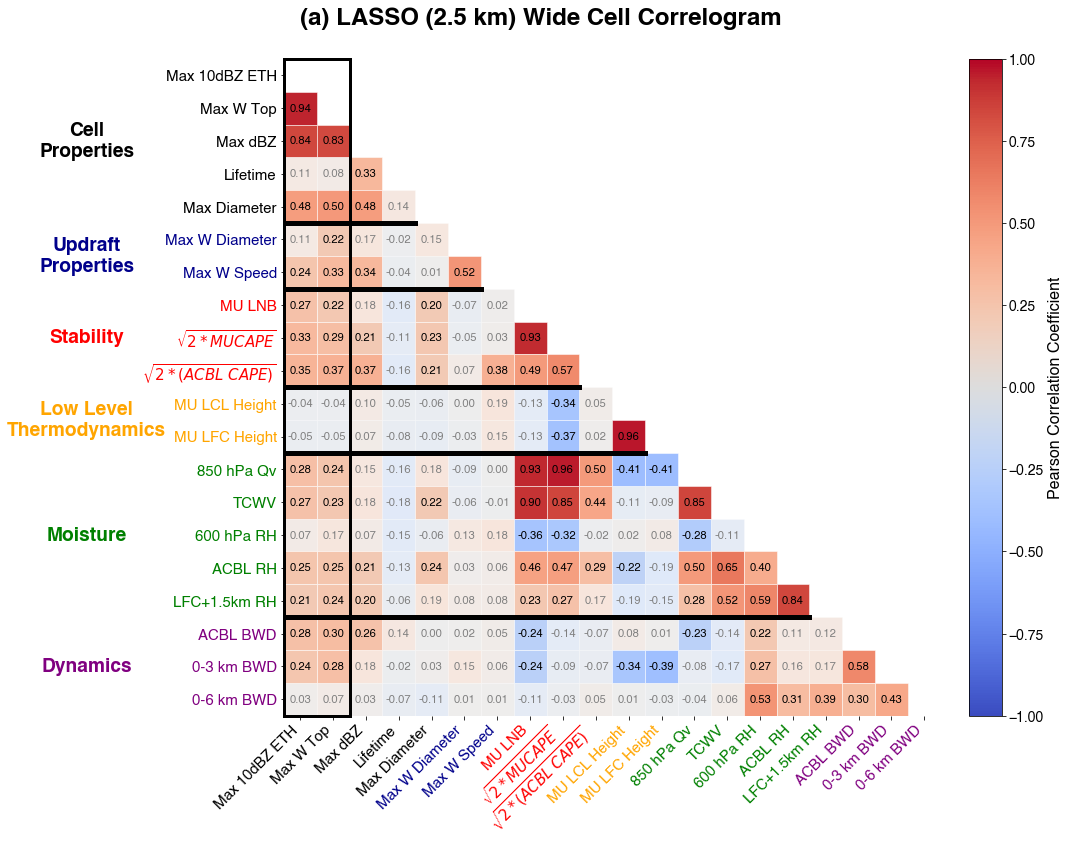

In [69]:
title = '(a) LASSO (2.5 km) Wide Cell Correlogram'
figname = f'{figdir}correlogram_widecells_pearson_sig_custom_d2.png'
cbar_label = 'Pearson Correlation Coefficient'

# Create the custom correlogram
fig, ax = custom_correlogram(
    corr_df_wide_pearson_d2, 
    p_df_wide_pearson_d2,
    var_groups=var_groups,
    group_colors=group_colors,
    group_names=group_names,
    title=title,
    figname=figname,
    figsize=(16, 14),
    fontsize=16,
    title_fontsize=24,
    title_pos=0.88,
    border_columns=2,
    cbar_label=cbar_label,
)

Saved: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/correlogram_narrowcells_pearson_sig_custom_d2.png


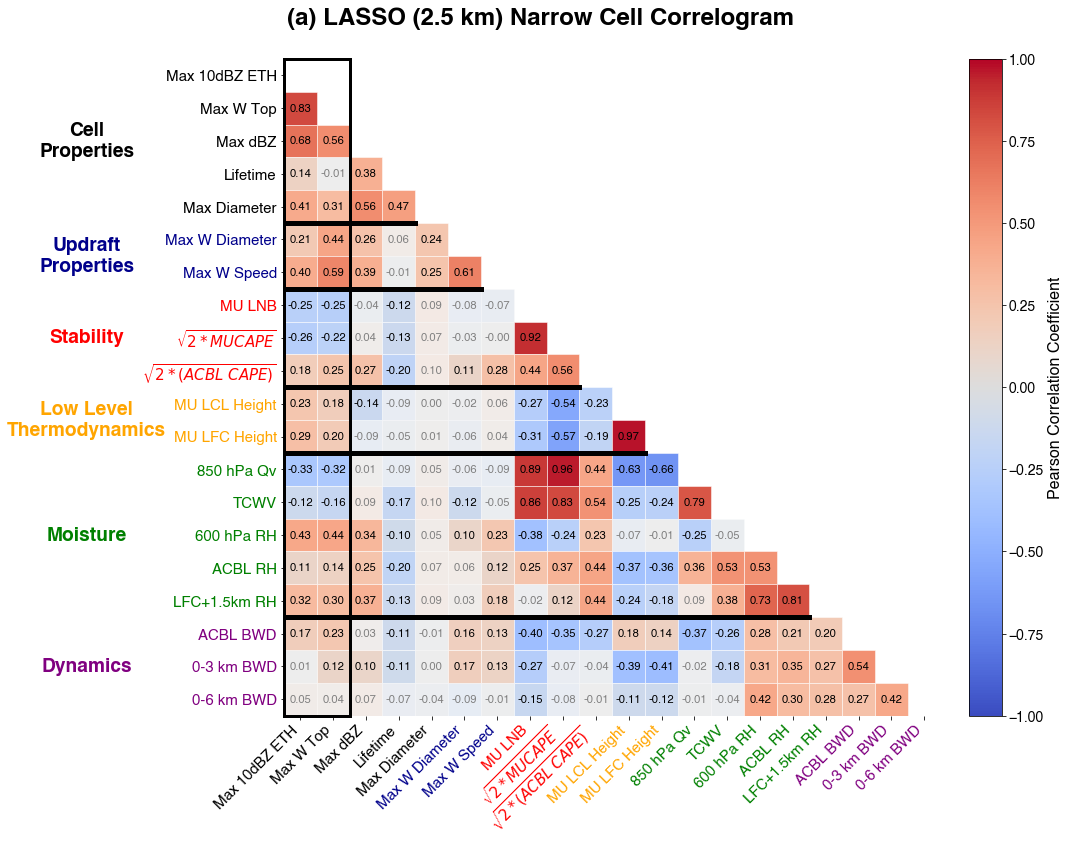

In [70]:
title = '(a) LASSO (2.5 km) Narrow Cell Correlogram'
figname = f'{figdir}correlogram_narrowcells_pearson_sig_custom_d2.png'
cbar_label = 'Pearson Correlation Coefficient'

# Create the custom correlogram
fig, ax = custom_correlogram(
    corr_df_narrow_pearson_d2, 
    p_df_narrow_pearson_d2,
    var_groups=var_groups,
    group_colors=group_colors,
    group_names=group_names,
    title=title,
    figname=figname,
    figsize=(16, 14),
    fontsize=16,
    title_fontsize=24,
    title_pos=0.88,
    border_columns=2,
    cbar_label=cbar_label,
)

## D3 correlogram

Saved: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/correlogram_narrowells_pearson_sig_custom_d3.png


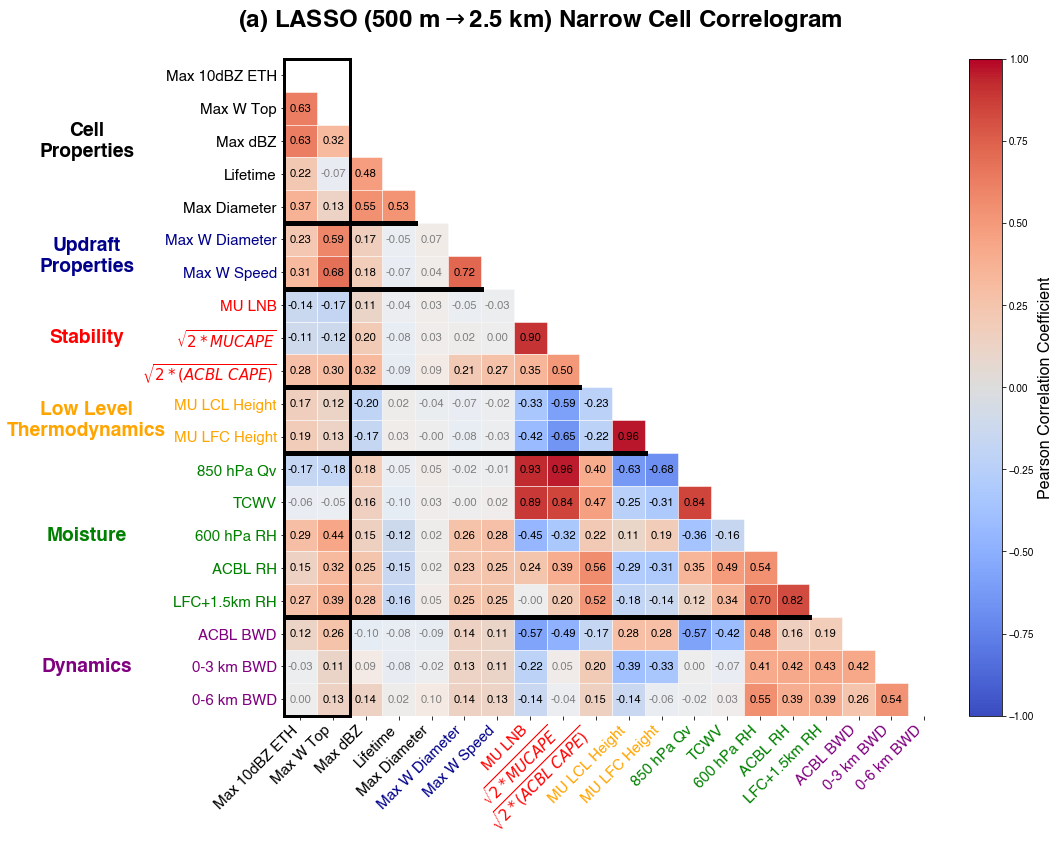

In [140]:
title = r'(a) LASSO (500 m$\rightarrow$2.5 km) Narrow Cell Correlogram'
figname = f'{figdir}correlogram_narrowells_pearson_sig_custom_d3.png'
cbar_label = 'Pearson Correlation Coefficient'

# Create the custom correlogram
fig, ax = custom_correlogram(
    corr_df_narrow_pearson_d3, 
    p_df_narrow_pearson_d3,
    var_groups=var_groups,
    group_colors=group_colors,
    group_names=group_names,
    title=title,
    figname=figname,
    figsize=(16, 14),
    fontsize=16,
    title_fontsize=24,
    title_pos=0.88,
    border_columns=2,
    cbar_label=cbar_label,
)

Saved: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/correlogram_widecells_pearson_sig_custom_d3.png


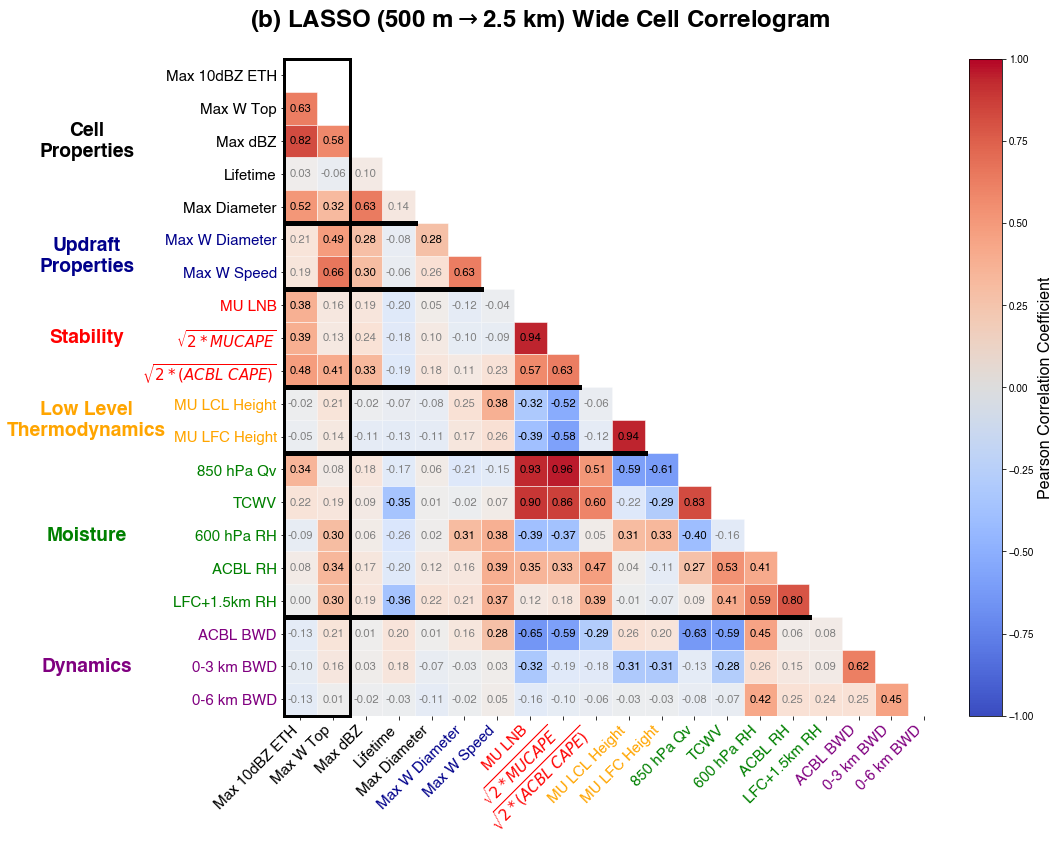

In [141]:
title = r'(b) LASSO (500 m$\rightarrow$2.5 km) Wide Cell Correlogram'
figname = f'{figdir}correlogram_widecells_pearson_sig_custom_d3.png'
cbar_label = 'Pearson Correlation Coefficient'

# Create the custom correlogram
fig, ax = custom_correlogram(
    corr_df_wide_pearson_d3, 
    p_df_wide_pearson_d3,
    var_groups=var_groups,
    group_colors=group_colors,
    group_names=group_names,
    title=title,
    figname=figname,
    figsize=(16, 14),
    fontsize=16,
    title_fontsize=24,
    title_pos=0.88,
    border_columns=2,
    cbar_label=cbar_label,
)

## D4 correlogram

Saved: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/correlogram_narrowells_pearson_sig_custom_d4.png


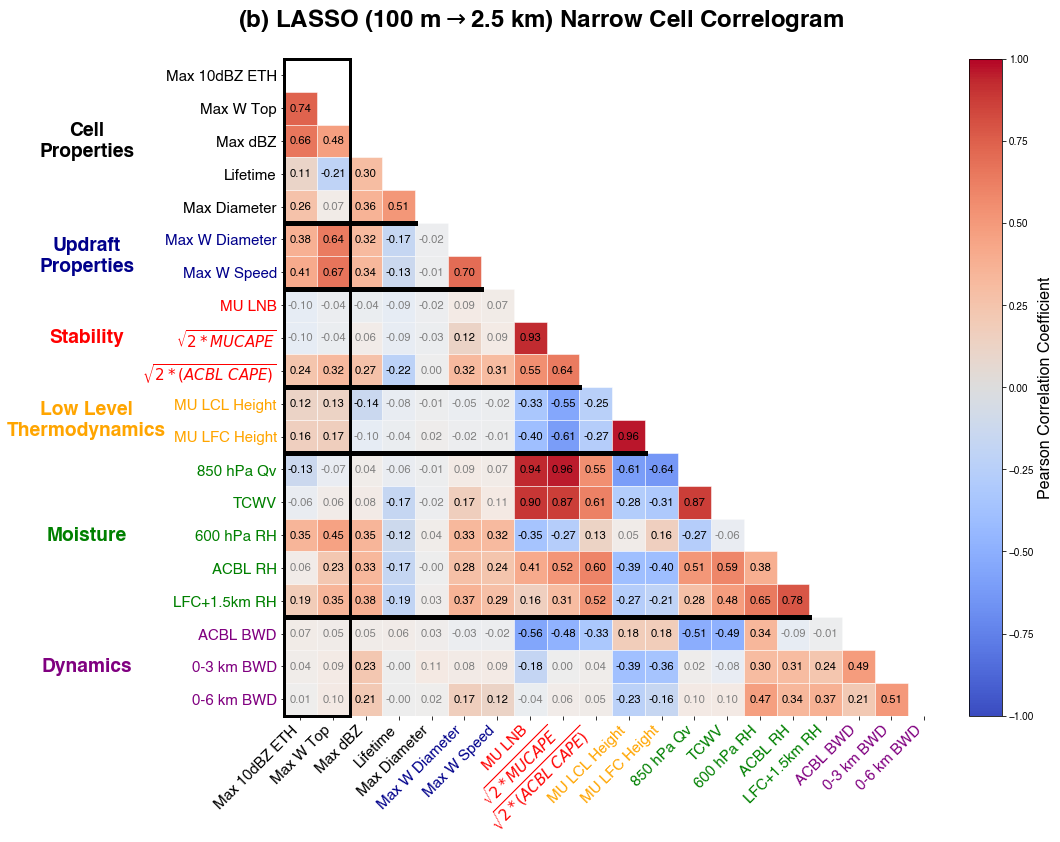

In [142]:
title = r'(b) LASSO (100 m$\rightarrow$2.5 km) Narrow Cell Correlogram'
figname = f'{figdir}correlogram_narrowells_pearson_sig_custom_d4.png'
cbar_label = 'Pearson Correlation Coefficient'

# Create the custom correlogram
fig, ax = custom_correlogram(
    corr_df_narrow_pearson_d4, 
    p_df_narrow_pearson_d4,
    var_groups=var_groups,
    group_colors=group_colors,
    group_names=group_names,
    title=title,
    figname=figname,
    figsize=(16, 14),
    fontsize=16,
    title_fontsize=24,
    title_pos=0.88,
    border_columns=2,
    cbar_label=cbar_label,
)

Saved: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/correlogram_widecells_pearson_sig_custom_d4.png


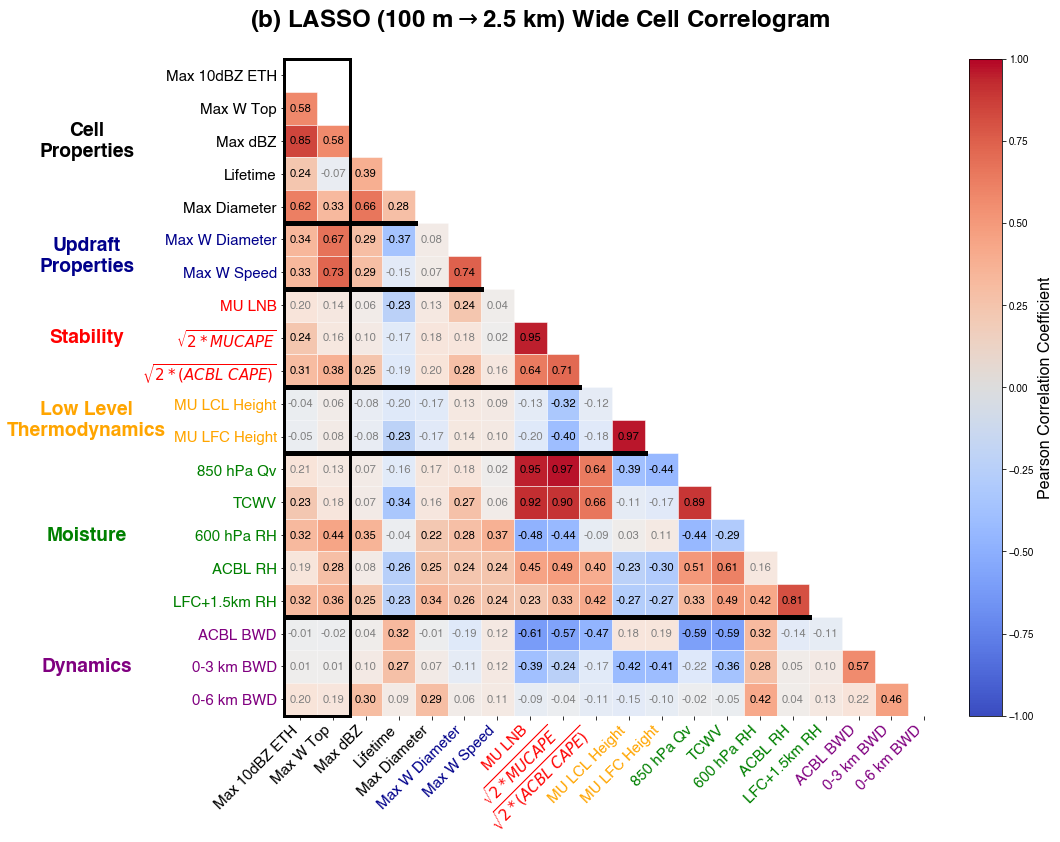

In [143]:
title = r'(b) LASSO (100 m$\rightarrow$2.5 km) Wide Cell Correlogram'
figname = f'{figdir}correlogram_widecells_pearson_sig_custom_d4.png'
cbar_label = 'Pearson Correlation Coefficient'

# Create the custom correlogram
fig, ax = custom_correlogram(
    corr_df_wide_pearson_d4, 
    p_df_wide_pearson_d4,
    var_groups=var_groups,
    group_colors=group_colors,
    group_names=group_names,
    title=title,
    figname=figname,
    figsize=(16, 14),
    fontsize=16,
    title_fontsize=24,
    title_pos=0.88,
    border_columns=2,
    cbar_label=cbar_label,
)

## Make Pandas Data Frame for Multi-Linear Regression (MLR)

### Narrow cells

In [75]:
# define new pandas data frames with standardized variables (variables values on a scale of # of standard deviations)
df_narrow_std_d2 = pd.DataFrame(columns = names)
df_narrow_std_d2['Max W Diameter'] = ((narrow_maxWdiam_d2 - np.nanmean(narrow_maxWdiam_d2)) / np.nanstd(narrow_maxWdiam_d2)).data
df_narrow_std_d2['Max W Speed'] = ((narrow_maxWspeed_d2 - np.nanmean(narrow_maxWspeed_d2)) / np.nanstd(narrow_maxWspeed_d2)).data
# df_narrow_std_d2['Max Diameter'] = ((narrow_maxdiam_d2 - np.nanmean(narrow_maxdiam_d2)) / np.nanstd(narrow_maxdiam_d2)).data
df_narrow_std_d2['Max 10dBZ ETH'] = ((narrow_maxETH10dbz_d2 - np.nanmean(narrow_maxETH10dbz_d2)) / np.nanstd(narrow_maxETH10dbz_d2)).data
df_narrow_std_d2['Max W Top'] = ((narrow_maxWtop_d2 - np.nanmean(narrow_maxWtop_d2)) / np.nanstd(narrow_maxWtop_d2)).data
df_narrow_std_d2['MU LNB'] = ((narrow_pELmu_d2 - np.nanmean(narrow_pELmu_d2)) / np.nanstd(narrow_pELmu_d2)).data
df_narrow_std_d2['$\sqrt{2*MUCAPE}$'] = ((np.sqrt(2*narrow_pCAPEmu_d2) - np.nanmean(np.sqrt(2*narrow_pCAPEmu_d2))) / np.nanstd(np.sqrt(2*narrow_pCAPEmu_d2))).data
df_narrow_std_d2['$\sqrt{2*(ACBL\ CAPE)}$'] = ((np.sqrt(2*narrow_pCAPEacbl_d2) - np.nanmean(np.sqrt(2*narrow_pCAPEacbl_d2))) / np.nanstd(np.sqrt(2*narrow_pCAPEacbl_d2))).data
# df_narrow_std_d2['$\sqrt{2*MUCIN}$'] = ((np.sqrt(2*narrow_pCINmu_d2) - np.nanmean(np.sqrt(2*narrow_pCINmu_d2))) / np.nanstd(np.sqrt(2*narrow_pCINmu_d2))).data
df_narrow_std_d2['MU LCL Height'] = ((narrow_LCLz_d2 - np.nanmean(narrow_LCLz_d2)) / np.nanstd(narrow_LCLz_d2)).data
df_narrow_std_d2['MU LFC Height'] = ((narrow_pLFCz_d2 - np.nanmean(narrow_pLFCz_d2)) / np.nanstd(narrow_pLFCz_d2)).data
df_narrow_std_d2['MU LCL Temp'] = ((narrow_LCLt_d2 - np.nanmean(narrow_LCLt_d2)) / np.nanstd(narrow_LCLt_d2)).data
df_narrow_std_d2['TCWV'] = ((narrow_PW_d2 - np.nanmean(narrow_PW_d2)) / np.nanstd(narrow_PW_d2)).data
df_narrow_std_d2['850 hPa Qv'] = ((narrow_Q850mb_d2 - np.nanmean(narrow_Q850mb_d2)) / np.nanstd(narrow_Q850mb_d2)).data
# df_narrow_std_d2['3km Qv'] = ((narrow_Q3km_d2 - np.nanmean(narrow_Q3km_d2)) / np.nanstd(narrow_Q3km_d2)).data
# df_narrow_std_d2['5km RH'] = ((narrow_RH5km_d2 - np.nanmean(narrow_RH5km_d2)) / np.nanstd(narrow_RH5km_d2)).data
df_narrow_std_d2['600 hPa RH'] = ((narrow_RH600mb_d2 - np.nanmean(narrow_RH600mb_d2)) / np.nanstd(narrow_RH600mb_d2)).data
# df_narrow_std_d2['500 hPa RH'] = ((narrow_RH500mb_d2 - np.nanmean(narrow_RH500mb_d2)) / np.nanstd(narrow_RH500mb_d2)).data
# df_narrow_std_d2['ACBL RH'] = ((narrow_RHacbl_d2 - np.nanmean(narrow_RHacbl_d2)) / np.nanstd(narrow_RHacbl_d2)).data
df_narrow_std_d2['LFC+1.5km RH'] = ((narrow_RHlfc1500_d2 - np.nanmean(narrow_RHlfc1500_d2)) / np.nanstd(narrow_RHlfc1500_d2)).data
df_narrow_std_d2['ACBL BWD'] = ((narrow_BWSacbl_d2 - np.nanmean(narrow_BWSacbl_d2)) / np.nanstd(narrow_BWSacbl_d2)).data
df_narrow_std_d2['0-3 km BWD'] = ((narrow_BWS03km_d2 - np.nanmean(narrow_BWS03km_d2)) / np.nanstd(narrow_BWS03km_d2)).data
df_narrow_std_d2['0-6 km BWD'] = ((narrow_BWS06km_d2 - np.nanmean(narrow_BWS06km_d2)) / np.nanstd(narrow_BWS06km_d2)).data

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/xarray/core/computation.py:825: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


In [76]:
# define new pandas data frames with standardized variables (variables values on a scale of # of standard deviations)
df_narrow_std_d3 = pd.DataFrame(columns = names)
df_narrow_std_d3['Max W Diameter'] = ((narrow_maxWdiam_d3 - np.nanmean(narrow_maxWdiam_d3)) / np.nanstd(narrow_maxWdiam_d3)).data
df_narrow_std_d3['Max W Speed'] = ((narrow_maxWspeed_d3 - np.nanmean(narrow_maxWspeed_d3)) / np.nanstd(narrow_maxWspeed_d3)).data
# df_narrow_std_d3['Max Diameter'] = ((narrow_maxdiam_d3 - np.nanmean(narrow_maxdiam_d3)) / np.nanstd(narrow_maxdiam_d3)).data
df_narrow_std_d3['Max 10dBZ ETH'] = ((narrow_maxETH10dbz_d3 - np.nanmean(narrow_maxETH10dbz_d3)) / np.nanstd(narrow_maxETH10dbz_d3)).data
df_narrow_std_d3['Max W Top'] = ((narrow_maxWtop_d3 - np.nanmean(narrow_maxWtop_d3)) / np.nanstd(narrow_maxWtop_d3)).data
df_narrow_std_d3['MU LNB'] = ((narrow_pELmu_d3 - np.nanmean(narrow_pELmu_d3)) / np.nanstd(narrow_pELmu_d3)).data
df_narrow_std_d3['$\sqrt{2*MUCAPE}$'] = ((np.sqrt(2*narrow_pCAPEmu_d3) - np.nanmean(np.sqrt(2*narrow_pCAPEmu_d3))) / np.nanstd(np.sqrt(2*narrow_pCAPEmu_d3))).data
df_narrow_std_d3['$\sqrt{2*(ACBL\ CAPE)}$'] = ((np.sqrt(2*narrow_pCAPEacbl_d3) - np.nanmean(np.sqrt(2*narrow_pCAPEacbl_d3))) / np.nanstd(np.sqrt(2*narrow_pCAPEacbl_d3))).data
# df_narrow_std_d3['$\sqrt{2*MUCIN}$'] = ((np.sqrt(2*narrow_pCINmu_d3) - np.nanmean(np.sqrt(2*narrow_pCINmu_d3))) / np.nanstd(np.sqrt(2*narrow_pCINmu_d3))).data
df_narrow_std_d3['MU LCL Height'] = ((narrow_LCLz_d3 - np.nanmean(narrow_LCLz_d3)) / np.nanstd(narrow_LCLz_d3)).data
df_narrow_std_d3['MU LFC Height'] = ((narrow_pLFCz_d3 - np.nanmean(narrow_pLFCz_d3)) / np.nanstd(narrow_pLFCz_d3)).data
df_narrow_std_d3['MU LCL Temp'] = ((narrow_LCLt_d3 - np.nanmean(narrow_LCLt_d3)) / np.nanstd(narrow_LCLt_d3)).data
df_narrow_std_d3['TCWV'] = ((narrow_PW_d3 - np.nanmean(narrow_PW_d3)) / np.nanstd(narrow_PW_d3)).data
df_narrow_std_d3['850 hPa Qv'] = ((narrow_Q850mb_d3 - np.nanmean(narrow_Q850mb_d3)) / np.nanstd(narrow_Q850mb_d3)).data
# df_narrow_std_d3['3km Qv'] = ((narrow_Q3km_d3 - np.nanmean(narrow_Q3km_d3)) / np.nanstd(narrow_Q3km_d3)).data
# df_narrow_std_d3['5km RH'] = ((narrow_RH5km_d3 - np.nanmean(narrow_RH5km_d3)) / np.nanstd(narrow_RH5km_d3)).data
df_narrow_std_d3['600 hPa RH'] = ((narrow_RH600mb_d3 - np.nanmean(narrow_RH600mb_d3)) / np.nanstd(narrow_RH600mb_d3)).data
# df_narrow_std_d3['500 hPa RH'] = ((narrow_RH500mb_d3 - np.nanmean(narrow_RH500mb_d3)) / np.nanstd(narrow_RH500mb_d3)).data
# df_narrow_std_d3['ACBL RH'] = ((narrow_RHacbl_d3 - np.nanmean(narrow_RHacbl_d3)) / np.nanstd(narrow_RHacbl_d3)).data
df_narrow_std_d3['LFC+1.5km RH'] = ((narrow_RHlfc1500_d3 - np.nanmean(narrow_RHlfc1500_d3)) / np.nanstd(narrow_RHlfc1500_d3)).data
df_narrow_std_d3['ACBL BWD'] = ((narrow_BWSacbl_d3 - np.nanmean(narrow_BWSacbl_d3)) / np.nanstd(narrow_BWSacbl_d3)).data
df_narrow_std_d3['0-3 km BWD'] = ((narrow_BWS03km_d3 - np.nanmean(narrow_BWS03km_d3)) / np.nanstd(narrow_BWS03km_d3)).data
df_narrow_std_d3['0-6 km BWD'] = ((narrow_BWS06km_d3 - np.nanmean(narrow_BWS06km_d3)) / np.nanstd(narrow_BWS06km_d3)).data

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/xarray/core/computation.py:825: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


In [77]:
# define new pandas data frames with standardized variables (variables values on a scale of # of standard deviations)
df_narrow_std_d4 = pd.DataFrame(columns = names)
df_narrow_std_d4['Max W Diameter'] = ((narrow_maxWdiam_d4 - np.nanmean(narrow_maxWdiam_d4)) / np.nanstd(narrow_maxWdiam_d4)).data
df_narrow_std_d4['Max W Speed'] = ((narrow_maxWspeed_d4 - np.nanmean(narrow_maxWspeed_d4)) / np.nanstd(narrow_maxWspeed_d4)).data
# df_narrow_std_d4['Max Diameter'] = ((narrow_maxdiam_d4 - np.nanmean(narrow_maxdiam_d4)) / np.nanstd(narrow_maxdiam_d4)).data
df_narrow_std_d4['Max 10dBZ ETH'] = ((narrow_maxETH10dbz_d4 - np.nanmean(narrow_maxETH10dbz_d4)) / np.nanstd(narrow_maxETH10dbz_d4)).data
df_narrow_std_d4['Max W Top'] = ((narrow_maxWtop_d4 - np.nanmean(narrow_maxWtop_d4)) / np.nanstd(narrow_maxWtop_d4)).data
df_narrow_std_d4['MU LNB'] = ((narrow_pELmu_d4 - np.nanmean(narrow_pELmu_d4)) / np.nanstd(narrow_pELmu_d4)).data
df_narrow_std_d4['$\sqrt{2*MUCAPE}$'] = ((np.sqrt(2*narrow_pCAPEmu_d4) - np.nanmean(np.sqrt(2*narrow_pCAPEmu_d4))) / np.nanstd(np.sqrt(2*narrow_pCAPEmu_d4))).data
df_narrow_std_d4['$\sqrt{2*(ACBL\ CAPE)}$'] = ((np.sqrt(2*narrow_pCAPEacbl_d4) - np.nanmean(np.sqrt(2*narrow_pCAPEacbl_d4))) / np.nanstd(np.sqrt(2*narrow_pCAPEacbl_d4))).data
# df_narrow_std_d4['$\sqrt{2*MUCIN}$'] = ((np.sqrt(2*narrow_pCINmu_d4) - np.nanmean(np.sqrt(2*narrow_pCINmu_d4))) / np.nanstd(np.sqrt(2*narrow_pCINmu_d4))).data
df_narrow_std_d4['MU LCL Height'] = ((narrow_LCLz_d4 - np.nanmean(narrow_LCLz_d4)) / np.nanstd(narrow_LCLz_d4)).data
df_narrow_std_d4['MU LFC Height'] = ((narrow_pLFCz_d4 - np.nanmean(narrow_pLFCz_d4)) / np.nanstd(narrow_pLFCz_d4)).data
df_narrow_std_d4['MU LCL Temp'] = ((narrow_LCLt_d4 - np.nanmean(narrow_LCLt_d4)) / np.nanstd(narrow_LCLt_d4)).data
df_narrow_std_d4['TCWV'] = ((narrow_PW_d4 - np.nanmean(narrow_PW_d4)) / np.nanstd(narrow_PW_d4)).data
df_narrow_std_d4['850 hPa Qv'] = ((narrow_Q850mb_d4 - np.nanmean(narrow_Q850mb_d4)) / np.nanstd(narrow_Q850mb_d4)).data
# df_narrow_std_d4['3km Qv'] = ((narrow_Q3km_d4 - np.nanmean(narrow_Q3km_d4)) / np.nanstd(narrow_Q3km_d4)).data
# df_narrow_std_d4['5km RH'] = ((narrow_RH5km_d4 - np.nanmean(narrow_RH5km_d4)) / np.nanstd(narrow_RH5km_d4)).data
df_narrow_std_d4['600 hPa RH'] = ((narrow_RH600mb_d4 - np.nanmean(narrow_RH600mb_d4)) / np.nanstd(narrow_RH600mb_d4)).data
# df_narrow_std_d4['500 hPa RH'] = ((narrow_RH500mb_d4 - np.nanmean(narrow_RH500mb_d4)) / np.nanstd(narrow_RH500mb_d4)).data
# df_narrow_std_d4['ACBL RH'] = ((narrow_RHacbl_d4 - np.nanmean(narrow_RHacbl_d4)) / np.nanstd(narrow_RHacbl_d4)).data
df_narrow_std_d4['LFC+1.5km RH'] = ((narrow_RHlfc1500_d4 - np.nanmean(narrow_RHlfc1500_d4)) / np.nanstd(narrow_RHlfc1500_d4)).data
df_narrow_std_d4['ACBL BWD'] = ((narrow_BWSacbl_d4 - np.nanmean(narrow_BWSacbl_d4)) / np.nanstd(narrow_BWSacbl_d4)).data
df_narrow_std_d4['0-3 km BWD'] = ((narrow_BWS03km_d4 - np.nanmean(narrow_BWS03km_d4)) / np.nanstd(narrow_BWS03km_d4)).data
df_narrow_std_d4['0-6 km BWD'] = ((narrow_BWS06km_d4 - np.nanmean(narrow_BWS06km_d4)) / np.nanstd(narrow_BWS06km_d4)).data

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/xarray/core/computation.py:825: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


### Wide cells

In [78]:
# define new pandas data frames with standardized variables (variables values on a scale of # of standard deviations)
df_wide_std_d2 = pd.DataFrame(columns = names)
df_wide_std_d2['Max W Diameter'] = ((wide_maxWdiam_d2 - np.nanmean(wide_maxWdiam_d2)) / np.nanstd(wide_maxWdiam_d2)).data
df_wide_std_d2['Max W Speed'] = ((wide_maxWspeed_d2 - np.nanmean(wide_maxWspeed_d2)) / np.nanstd(wide_maxWspeed_d2)).data
# df_wide_std_d2['Max Diameter'] = ((wide_maxdiam_d2 - np.nanmean(wide_maxdiam_d2)) / np.nanstd(wide_maxdiam_d2)).data
df_wide_std_d2['Max 10dBZ ETH'] = ((wide_maxETH10dbz_d2 - np.nanmean(wide_maxETH10dbz_d2)) / np.nanstd(wide_maxETH10dbz_d2)).data
df_wide_std_d2['Max W Top'] = ((wide_maxWtop_d2 - np.nanmean(wide_maxWtop_d2)) / np.nanstd(wide_maxWtop_d2)).data
df_wide_std_d2['MU LNB'] = ((wide_pELmu_d2 - np.nanmean(wide_pELmu_d2)) / np.nanstd(wide_pELmu_d2)).data
df_wide_std_d2['$\sqrt{2*MUCAPE}$'] = ((np.sqrt(2*wide_pCAPEmu_d2) - np.nanmean(np.sqrt(2*wide_pCAPEmu_d2))) / np.nanstd(np.sqrt(2*wide_pCAPEmu_d2))).data
df_wide_std_d2['$\sqrt{2*(ACBL\ CAPE)}$'] = ((np.sqrt(2*wide_pCAPEacbl_d2) - np.nanmean(np.sqrt(2*wide_pCAPEacbl_d2))) / np.nanstd(np.sqrt(2*wide_pCAPEacbl_d2))).data
# df_wide_std_d2['$\sqrt{2*MUCIN}$'] = ((np.sqrt(2*wide_pCINmu_d2) - np.nanmean(np.sqrt(2*wide_pCINmu_d2))) / np.nanstd(np.sqrt(2*wide_pCINmu_d2))).data
df_wide_std_d2['MU LCL Height'] = ((wide_LCLz_d2 - np.nanmean(wide_LCLz_d2)) / np.nanstd(wide_LCLz_d2)).data
df_wide_std_d2['MU LFC Height'] = ((wide_pLFCz_d2 - np.nanmean(wide_pLFCz_d2)) / np.nanstd(wide_pLFCz_d2)).data
df_wide_std_d2['MU LCL Temp'] = ((wide_LCLt_d2 - np.nanmean(wide_LCLt_d2)) / np.nanstd(wide_LCLt_d2)).data
df_wide_std_d2['TCWV'] = ((wide_PW_d2 - np.nanmean(wide_PW_d2)) / np.nanstd(wide_PW_d2)).data
df_wide_std_d2['850 hPa Qv'] = ((wide_Q850mb_d2 - np.nanmean(wide_Q850mb_d2)) / np.nanstd(wide_Q850mb_d2)).data
# df_wide_std_d2['3km Qv'] = ((wide_Q3km_d2 - np.nanmean(wide_Q3km_d2)) / np.nanstd(wide_Q3km_d2)).data
# df_wide_std_d2['5km RH'] = ((wide_RH5km_d2 - np.nanmean(wide_RH5km_d2)) / np.nanstd(wide_RH5km_d2)).data
df_wide_std_d2['600 hPa RH'] = ((wide_RH600mb_d2 - np.nanmean(wide_RH600mb_d2)) / np.nanstd(wide_RH600mb_d2)).data
# df_wide_std_d2['500 hPa RH'] = ((wide_RH500mb_d2 - np.nanmean(wide_RH500mb_d2)) / np.nanstd(wide_RH500mb_d2)).data
# df_wide_std_d2['ACBL RH'] = ((wide_RHacbl_d2 - np.nanmean(wide_RHacbl_d2)) / np.nanstd(wide_RHacbl_d2)).data
df_wide_std_d2['LFC+1.5km RH'] = ((wide_RHlfc1500_d2 - np.nanmean(wide_RHlfc1500_d2)) / np.nanstd(wide_RHlfc1500_d2)).data
df_wide_std_d2['ACBL BWD'] = ((wide_BWSacbl_d2 - np.nanmean(wide_BWSacbl_d2)) / np.nanstd(wide_BWSacbl_d2)).data
df_wide_std_d2['0-3 km BWD'] = ((wide_BWS03km_d2 - np.nanmean(wide_BWS03km_d2)) / np.nanstd(wide_BWS03km_d2)).data
df_wide_std_d2['0-6 km BWD'] = ((wide_BWS06km_d2 - np.nanmean(wide_BWS06km_d2)) / np.nanstd(wide_BWS06km_d2)).data

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/xarray/core/computation.py:825: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


In [79]:
# define new pandas data frames with standardized variables (variables values on a scale of # of standard deviations)
df_wide_std_d3 = pd.DataFrame(columns = names)
df_wide_std_d3['Max W Diameter'] = ((wide_maxWdiam_d3 - np.nanmean(wide_maxWdiam_d3)) / np.nanstd(wide_maxWdiam_d3)).data
df_wide_std_d3['Max W Speed'] = ((wide_maxWspeed_d3 - np.nanmean(wide_maxWspeed_d3)) / np.nanstd(wide_maxWspeed_d3)).data
# df_wide_std_d3['Max Diameter'] = ((wide_maxdiam_d3 - np.nanmean(wide_maxdiam_d3)) / np.nanstd(wide_maxdiam_d3)).data
df_wide_std_d3['Max 10dBZ ETH'] = ((wide_maxETH10dbz_d3 - np.nanmean(wide_maxETH10dbz_d3)) / np.nanstd(wide_maxETH10dbz_d3)).data
df_wide_std_d3['Max W Top'] = ((wide_maxWtop_d3 - np.nanmean(wide_maxWtop_d3)) / np.nanstd(wide_maxWtop_d3)).data
df_wide_std_d3['MU LNB'] = ((wide_pELmu_d3 - np.nanmean(wide_pELmu_d3)) / np.nanstd(wide_pELmu_d3)).data
df_wide_std_d3['$\sqrt{2*MUCAPE}$'] = ((np.sqrt(2*wide_pCAPEmu_d3) - np.nanmean(np.sqrt(2*wide_pCAPEmu_d3))) / np.nanstd(np.sqrt(2*wide_pCAPEmu_d3))).data
df_wide_std_d3['$\sqrt{2*(ACBL\ CAPE)}$'] = ((np.sqrt(2*wide_pCAPEacbl_d3) - np.nanmean(np.sqrt(2*wide_pCAPEacbl_d3))) / np.nanstd(np.sqrt(2*wide_pCAPEacbl_d3))).data
# df_wide_std_d3['$\sqrt{2*MUCIN}$'] = ((np.sqrt(2*wide_pCINmu_d3) - np.nanmean(np.sqrt(2*wide_pCINmu_d3))) / np.nanstd(np.sqrt(2*wide_pCINmu_d3))).data
df_wide_std_d3['MU LCL Height'] = ((wide_LCLz_d3 - np.nanmean(wide_LCLz_d3)) / np.nanstd(wide_LCLz_d3)).data
df_wide_std_d3['MU LFC Height'] = ((wide_pLFCz_d3 - np.nanmean(wide_pLFCz_d3)) / np.nanstd(wide_pLFCz_d3)).data
df_wide_std_d3['MU LCL Temp'] = ((wide_LCLt_d3 - np.nanmean(wide_LCLt_d3)) / np.nanstd(wide_LCLt_d3)).data
df_wide_std_d3['TCWV'] = ((wide_PW_d3 - np.nanmean(wide_PW_d3)) / np.nanstd(wide_PW_d3)).data
df_wide_std_d3['850 hPa Qv'] = ((wide_Q850mb_d3 - np.nanmean(wide_Q850mb_d3)) / np.nanstd(wide_Q850mb_d3)).data
# df_wide_std_d3['3km Qv'] = ((wide_Q3km_d3 - np.nanmean(wide_Q3km_d3)) / np.nanstd(wide_Q3km_d3)).data
# df_wide_std_d3['5km RH'] = ((wide_RH5km_d3 - np.nanmean(wide_RH5km_d3)) / np.nanstd(wide_RH5km_d3)).data
df_wide_std_d3['600 hPa RH'] = ((wide_RH600mb_d3 - np.nanmean(wide_RH600mb_d3)) / np.nanstd(wide_RH600mb_d3)).data
# df_wide_std_d3['500 hPa RH'] = ((wide_RH500mb_d3 - np.nanmean(wide_RH500mb_d3)) / np.nanstd(wide_RH500mb_d3)).data
# df_wide_std_d3['ACBL RH'] = ((wide_RHacbl_d3 - np.nanmean(wide_RHacbl_d3)) / np.nanstd(wide_RHacbl_d3)).data
df_wide_std_d3['LFC+1.5km RH'] = ((wide_RHlfc1500_d3 - np.nanmean(wide_RHlfc1500_d3)) / np.nanstd(wide_RHlfc1500_d3)).data
df_wide_std_d3['ACBL BWD'] = ((wide_BWSacbl_d3 - np.nanmean(wide_BWSacbl_d3)) / np.nanstd(wide_BWSacbl_d3)).data
df_wide_std_d3['0-3 km BWD'] = ((wide_BWS03km_d3 - np.nanmean(wide_BWS03km_d3)) / np.nanstd(wide_BWS03km_d3)).data
df_wide_std_d3['0-6 km BWD'] = ((wide_BWS06km_d3 - np.nanmean(wide_BWS06km_d3)) / np.nanstd(wide_BWS06km_d3)).data

In [80]:
# define new pandas data frames with standardized variables (variables values on a scale of # of standard deviations)
df_wide_std_d4 = pd.DataFrame(columns = names)
df_wide_std_d4['Max W Diameter'] = ((wide_maxWdiam_d4 - np.nanmean(wide_maxWdiam_d4)) / np.nanstd(wide_maxWdiam_d4)).data
df_wide_std_d4['Max W Speed'] = ((wide_maxWspeed_d4 - np.nanmean(wide_maxWspeed_d4)) / np.nanstd(wide_maxWspeed_d4)).data
# df_wide_std_d4['Max Diameter'] = ((wide_maxdiam_d4 - np.nanmean(wide_maxdiam_d4)) / np.nanstd(wide_maxdiam_d4)).data
df_wide_std_d4['Max 10dBZ ETH'] = ((wide_maxETH10dbz_d4 - np.nanmean(wide_maxETH10dbz_d4)) / np.nanstd(wide_maxETH10dbz_d4)).data
df_wide_std_d4['Max W Top'] = ((wide_maxWtop_d4 - np.nanmean(wide_maxWtop_d4)) / np.nanstd(wide_maxWtop_d4)).data
df_wide_std_d4['MU LNB'] = ((wide_pELmu_d4 - np.nanmean(wide_pELmu_d4)) / np.nanstd(wide_pELmu_d4)).data
df_wide_std_d4['$\sqrt{2*MUCAPE}$'] = ((np.sqrt(2*wide_pCAPEmu_d4) - np.nanmean(np.sqrt(2*wide_pCAPEmu_d4))) / np.nanstd(np.sqrt(2*wide_pCAPEmu_d4))).data
df_wide_std_d4['$\sqrt{2*(ACBL\ CAPE)}$'] = ((np.sqrt(2*wide_pCAPEacbl_d4) - np.nanmean(np.sqrt(2*wide_pCAPEacbl_d4))) / np.nanstd(np.sqrt(2*wide_pCAPEacbl_d4))).data
# df_wide_std_d4['$\sqrt{2*MUCIN}$'] = ((np.sqrt(2*wide_pCINmu_d4) - np.nanmean(np.sqrt(2*wide_pCINmu_d4))) / np.nanstd(np.sqrt(2*wide_pCINmu_d4))).data
df_wide_std_d4['MU LCL Height'] = ((wide_LCLz_d4 - np.nanmean(wide_LCLz_d4)) / np.nanstd(wide_LCLz_d4)).data
df_wide_std_d4['MU LFC Height'] = ((wide_pLFCz_d4 - np.nanmean(wide_pLFCz_d4)) / np.nanstd(wide_pLFCz_d4)).data
df_wide_std_d4['MU LCL Temp'] = ((wide_LCLt_d4 - np.nanmean(wide_LCLt_d4)) / np.nanstd(wide_LCLt_d4)).data
df_wide_std_d4['TCWV'] = ((wide_PW_d4 - np.nanmean(wide_PW_d4)) / np.nanstd(wide_PW_d4)).data
df_wide_std_d4['850 hPa Qv'] = ((wide_Q850mb_d4 - np.nanmean(wide_Q850mb_d4)) / np.nanstd(wide_Q850mb_d4)).data
# df_wide_std_d4['3km Qv'] = ((wide_Q3km_d4 - np.nanmean(wide_Q3km_d4)) / np.nanstd(wide_Q3km_d4)).data
# df_wide_std_d4['5km RH'] = ((wide_RH5km_d4 - np.nanmean(wide_RH5km_d4)) / np.nanstd(wide_RH5km_d4)).data
df_wide_std_d4['600 hPa RH'] = ((wide_RH600mb_d4 - np.nanmean(wide_RH600mb_d4)) / np.nanstd(wide_RH600mb_d4)).data
# df_wide_std_d4['500 hPa RH'] = ((wide_RH500mb_d4 - np.nanmean(wide_RH500mb_d4)) / np.nanstd(wide_RH500mb_d4)).data
# df_wide_std_d4['ACBL RH'] = ((wide_RHacbl_d4 - np.nanmean(wide_RHacbl_d4)) / np.nanstd(wide_RHacbl_d4)).data
df_wide_std_d4['LFC+1.5km RH'] = ((wide_RHlfc1500_d4 - np.nanmean(wide_RHlfc1500_d4)) / np.nanstd(wide_RHlfc1500_d4)).data
df_wide_std_d4['ACBL BWD'] = ((wide_BWSacbl_d4 - np.nanmean(wide_BWSacbl_d4)) / np.nanstd(wide_BWSacbl_d4)).data
df_wide_std_d4['0-3 km BWD'] = ((wide_BWS03km_d4 - np.nanmean(wide_BWS03km_d4)) / np.nanstd(wide_BWS03km_d4)).data
df_wide_std_d4['0-6 km BWD'] = ((wide_BWS06km_d4 - np.nanmean(wide_BWS06km_d4)) / np.nanstd(wide_BWS06km_d4)).data

# Calculate multivariate linear regression

## Prediction including using updraft speed, ACBL CAPE & RH

### Narrow cells ETH

In [81]:
names

['Max 10dBZ ETH',
 'Max W Top',
 'Max dBZ',
 'Lifetime',
 'Max Diameter',
 'Max W Diameter',
 'Max W Speed',
 'MU LNB',
 '$\\sqrt{2*MUCAPE}$',
 '$\\sqrt{2*(ACBL\\ CAPE)}$',
 'MU LCL Height',
 'MU LFC Height',
 '850 hPa Qv',
 'TCWV',
 '600 hPa RH',
 'ACBL RH',
 'LFC+1.5km RH',
 'ACBL BWD',
 '0-3 km BWD',
 '0-6 km BWD']

In [82]:
# Multivariate linear regression using reduced set of predictors including max diameter for narrow cells
# predictors_all = ['Max Diameter', 'MU LNB', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', '500 hPa RH', '0-6 km BWD']
# predictors_all = ['Max W Diameter', 'MU LNB', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', 'MU LFC Height', 'TCWV', '5km RH', 'LFC+1.5km RH', '0-6 km BWD']
# predictors_all = ['Max W Diameter', 'MU LNB', '$\sqrt{2*MUCAPE}$', '$\\sqrt{2*(ACBL\\ CAPE)}$', 'MU LCL Height', 'MU LFC Height', 'TCWV', '850 hPa Qv', '5km RH', 'LFC+1.5km RH', '0-6 km BWD']
# predictors_all = ['Max W Diameter', 'MU LNB', '$\sqrt{2*MUCAPE}$', '$\\sqrt{2*(ACBL\\ CAPE)}$', 'MU LCL Height', 'MU LFC Height', '850 hPa Qv', '600 hPa RH', 'LFC+1.5km RH', '0-6 km BWD']
# predictors_all = ['Max W Diameter', 'MU LNB', '$\sqrt{2*MUCAPE}$', '$\\sqrt{2*(ACBL\\ CAPE)}$', 'MU LCL Height', '600 hPa RH', 'LFC+1.5km RH', '0-6 km BWD']
# predictors_all = ['Max W Diameter', 'Max W Speed', '$\sqrt{2*MUCAPE}$', '$\\sqrt{2*(ACBL\\ CAPE)}$', 'MU LCL Height', '600 hPa RH', 'LFC+1.5km RH', '0-6 km BWD']
predictors_all = ['Max W Diameter', 'Max W Speed', '$\sqrt{2*MUCAPE}$', '$\\sqrt{2*(ACBL\\ CAPE)}$', 'MU LCL Height', '600 hPa RH', 'LFC+1.5km RH', '0-3 km BWD']
X = df_narrow_std_d2[predictors_all].to_numpy()
Y = df_narrow_std_d2['Max 10dBZ ETH'].to_numpy()
# Y = df_narrow_std_d2['Max W Top'].to_numpy()

lm_narrow_std_all_eth_d2 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
# #lm_narrow_std_all_eth = pg.linear_regression(X, Y, remove_na=True, weights=weights).round(3)
lm_narrow_std_all_eth_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.001,0.041,0.015,0.988,0.368,0.355,-0.079,0.080,NaN,NaN
1,x1,0.006,0.052,0.123,0.902,0.368,0.355,-0.096,0.109,0.018,4.904
2,x2,0.280,0.055,5.105,0.000,0.368,0.355,0.172,0.388,0.087,23.746
3,x3,-0.262,0.071,-3.711,0.000,0.368,0.355,-0.400,-0.123,0.054,14.722
4,x4,0.171,0.060,2.835,0.005,0.368,0.355,0.052,0.290,0.030,8.020
5,x5,0.133,0.058,2.281,0.023,0.368,0.355,0.018,0.247,0.040,10.780
6,x6,0.190,0.071,2.670,0.008,0.368,0.355,0.050,0.331,0.085,22.953
7,x7,0.144,0.068,2.116,0.035,0.368,0.355,0.010,0.277,0.048,13.102
8,x8,-0.089,0.049,-1.795,0.073,0.368,0.355,-0.186,0.008,0.007,1.774


In [83]:
# Multivariate linear regression using reduced set of predictors including max diameter for narrow cells
X = df_narrow_std_d3[predictors_all].to_numpy()
Y = df_narrow_std_d3['Max 10dBZ ETH'].to_numpy()
# Y = df_narrow_std_d3['Max W Top'].to_numpy()

lm_narrow_std_all_eth_d3 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_all_eth_d3

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.025,0.048,0.521,0.603,0.242,0.223,-0.070,0.120,NaN,NaN
1,x1,-0.001,0.069,-0.007,0.994,0.242,0.223,-0.137,0.136,0.017,7.237
2,x2,0.195,0.070,2.761,0.006,0.242,0.223,0.056,0.333,0.046,18.840
3,x3,-0.244,0.086,-2.835,0.005,0.242,0.223,-0.413,-0.075,0.021,8.735
4,x4,0.316,0.068,4.670,0.000,0.242,0.223,0.183,0.448,0.062,25.712
5,x5,0.079,0.069,1.139,0.255,0.242,0.223,-0.057,0.216,0.023,9.530
6,x6,0.033,0.095,0.348,0.728,0.242,0.223,-0.153,0.219,0.030,12.327
7,x7,0.143,0.090,1.589,0.113,0.242,0.223,-0.034,0.319,0.027,11.094
8,x8,-0.166,0.061,-2.731,0.007,0.242,0.223,-0.286,-0.046,0.016,6.524


In [84]:
# Multivariate linear regression using reduced set of predictors including max diameter for narrow cells
X = df_narrow_std_d4[predictors_all].to_numpy()
Y = df_narrow_std_d4['Max 10dBZ ETH'].to_numpy()
# Y = df_narrow_std_d4['Max W Top'].to_numpy()

lm_narrow_std_all_eth_d4 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_all_eth_d4

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.005,0.047,0.102,0.919,0.296,0.278,-0.088,0.097,NaN,NaN
1,x1,0.147,0.068,2.160,0.032,0.296,0.278,0.013,0.281,0.060,20.270
2,x2,0.188,0.068,2.775,0.006,0.296,0.278,0.055,0.320,0.074,25.154
3,x3,-0.200,0.088,-2.275,0.024,0.296,0.278,-0.373,-0.027,0.023,7.629
4,x4,0.339,0.072,4.682,0.000,0.296,0.278,0.197,0.482,0.052,17.679
5,x5,0.031,0.065,0.472,0.637,0.296,0.278,-0.098,0.159,0.011,3.820
6,x6,0.271,0.085,3.176,0.002,0.296,0.278,0.103,0.438,0.058,19.653
7,x7,-0.192,0.085,-2.258,0.025,0.296,0.278,-0.359,-0.025,0.016,5.285
8,x8,-0.023,0.055,-0.409,0.683,0.296,0.278,-0.132,0.086,0.002,0.510


### Wide cells ETH

In [85]:
# Multivariate linear regression using reduced set of predictors including max diameter for wide cells
X = df_wide_std_d2[predictors_all].to_numpy()
Y = df_wide_std_d2['Max 10dBZ ETH'].to_numpy()
# Y = df_wide_std_d2['Max W Top'].to_numpy()

lm_wide_std_all_eth_d2 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_all_eth_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.015,0.090,0.170,0.866,0.272,0.206,-0.164,0.194,NaN,NaN
1,x1,-0.023,0.107,-0.212,0.833,0.272,0.206,-0.236,0.191,0.003,1.248
2,x2,0.123,0.119,1.032,0.305,0.272,0.206,-0.114,0.359,0.028,10.258
3,x3,0.350,0.164,2.135,0.035,0.272,0.206,0.024,0.676,0.071,26.192
4,x4,0.122,0.132,0.929,0.355,0.272,0.206,-0.139,0.384,0.062,22.973
5,x5,0.167,0.113,1.479,0.143,0.272,0.206,-0.057,0.391,0.009,3.405
6,x6,0.059,0.152,0.384,0.702,0.272,0.206,-0.244,0.361,0.006,2.241
7,x7,0.007,0.143,0.051,0.959,0.272,0.206,-0.277,0.292,0.015,5.559
8,x8,0.338,0.104,3.249,0.002,0.272,0.206,0.131,0.545,0.076,28.125


In [86]:
# Multivariate linear regression using reduced set of predictors including max diameter for wide cells
X = df_wide_std_d3[predictors_all].to_numpy()
Y = df_wide_std_d3['Max 10dBZ ETH'].to_numpy()
# Y = df_wide_std_d3['Max W Top'].to_numpy()

lm_wide_std_all_eth_d3 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_all_eth_d3

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,-0.000,0.121,-0.000,1.000,0.34,0.223,-0.244,0.244,NaN,NaN
1,x1,0.177,0.159,1.110,0.273,0.34,0.223,-0.144,0.497,0.032,9.301
2,x2,0.076,0.180,0.424,0.673,0.34,0.223,-0.286,0.439,0.021,6.209
3,x3,0.322,0.238,1.353,0.183,0.34,0.223,-0.157,0.802,0.093,27.434
4,x4,0.376,0.186,2.019,0.049,0.34,0.223,0.001,0.751,0.145,42.628
5,x5,0.104,0.194,0.537,0.594,0.34,0.223,-0.286,0.495,0.009,2.518
6,x6,0.060,0.200,0.297,0.768,0.34,0.223,-0.344,0.463,0.009,2.714
7,x7,-0.310,0.184,-1.687,0.099,0.34,0.223,-0.681,0.060,0.027,7.802
8,x8,0.078,0.152,0.510,0.612,0.34,0.223,-0.229,0.384,0.005,1.394


In [87]:
# Multivariate linear regression using reduced set of predictors including max diameter for wide cells
X = df_wide_std_d4[predictors_all].to_numpy()
Y = df_wide_std_d4['Max 10dBZ ETH'].to_numpy()
# Y = df_wide_std_d4['Max W Top'].to_numpy()

lm_wide_std_all_eth_d4 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_all_eth_d4

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.099,0.000,1.000,0.309,0.23,-0.198,0.198,NaN,NaN
1,x1,0.025,0.163,0.155,0.877,0.309,0.23,-0.299,0.350,0.038,12.280
2,x2,0.119,0.160,0.744,0.459,0.309,0.23,-0.200,0.438,0.041,13.113
3,x3,0.501,0.207,2.423,0.018,0.309,0.23,0.089,0.913,0.056,18.143
4,x4,0.024,0.155,0.155,0.877,0.309,0.23,-0.286,0.334,0.037,11.991
5,x5,0.073,0.133,0.550,0.584,0.309,0.23,-0.192,0.338,0.003,0.955
6,x6,0.525,0.165,3.189,0.002,0.309,0.23,0.197,0.854,0.098,31.781
7,x7,-0.096,0.144,-0.668,0.506,0.309,0.23,-0.383,0.191,0.035,11.194
8,x8,0.015,0.128,0.116,0.908,0.309,0.23,-0.241,0.271,0.002,0.543


## Prediction with minimal set of variables (updraft width + environment)

### Narrow cells ETH

In [88]:
# Multivariate linear regression using minimum set of predictors including max diameter for narrow cells
# predictors_minset = ['Max W Diameter', 'Max W Speed', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', '600 hPa RH', '0-6 km BWD']
predictors_minset = ['Max W Diameter', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', '600 hPa RH', '0-3 km BWD']
# predictors_minset = ['Max W Diameter', '$\\sqrt{2*(ACBL\\ CAPE)}$', 'MU LCL Height', '600 hPa RH', '0-3 km BWD']
X = df_narrow_std_d2[predictors_minset].to_numpy()
Y = df_narrow_std_d2['Max 10dBZ ETH'].to_numpy()
# Y = df_narrow_std_d2['Max W Top'].to_numpy()

lm_narrow_std_minset_eth_d2 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_minset_eth_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.043,0.000,1.000,0.288,0.279,-0.084,0.084,NaN,NaN
1,x1,0.184,0.043,4.239,0.000,0.288,0.279,0.099,0.269,0.038,13.282
2,x2,-0.036,0.056,-0.649,0.517,0.288,0.279,-0.146,0.074,0.031,10.653
3,x3,0.220,0.059,3.718,0.000,0.288,0.279,0.103,0.336,0.042,14.543
4,x4,0.441,0.047,9.477,0.000,0.288,0.279,0.350,0.532,0.172,59.525
5,x5,-0.081,0.051,-1.575,0.116,0.288,0.279,-0.181,0.020,0.006,1.997


In [89]:
X = df_narrow_std_d3[predictors_minset].to_numpy()
Y = df_narrow_std_d3['Max 10dBZ ETH'].to_numpy()
# Y = df_narrow_std_d3['Max W Top'].to_numpy()

lm_narrow_std_minset_eth_d3 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_minset_eth_d3

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.050,0.000,1.000,0.151,0.138,-0.098,0.098,NaN,NaN
1,x1,0.177,0.052,3.395,0.001,0.151,0.138,0.074,0.279,0.043,28.281
2,x2,0.082,0.066,1.247,0.213,0.151,0.138,-0.047,0.211,0.005,3.561
3,x3,0.142,0.069,2.050,0.041,0.151,0.138,0.006,0.279,0.019,12.942
4,x4,0.310,0.062,5.029,0.000,0.151,0.138,0.189,0.431,0.074,49.240
5,x5,-0.129,0.063,-2.066,0.040,0.151,0.138,-0.252,-0.006,0.009,5.977


In [90]:
X = df_narrow_std_d4[predictors_minset].to_numpy()
Y = df_narrow_std_d4['Max 10dBZ ETH'].to_numpy()
# Y = df_narrow_std_d4['Max W Top'].to_numpy()

lm_narrow_std_minset_eth_d4 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_minset_eth_d4

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,-0.000,0.049,-0.000,1.000,0.217,0.205,-0.097,0.097,NaN,NaN
1,x1,0.309,0.054,5.751,0.000,0.217,0.205,0.203,0.414,0.115,53.034
2,x2,-0.006,0.064,-0.098,0.922,0.217,0.205,-0.133,0.120,0.005,2.512
3,x3,0.116,0.067,1.744,0.082,0.217,0.205,-0.015,0.247,0.012,5.528
4,x4,0.243,0.058,4.188,0.000,0.217,0.205,0.129,0.358,0.082,37.916
5,x5,-0.011,0.058,-0.184,0.854,0.217,0.205,-0.125,0.104,0.002,1.011


### Wide cells ETH

In [91]:
X = df_wide_std_d2[predictors_minset].to_numpy()
Y = df_wide_std_d2['Max 10dBZ ETH'].to_numpy()
# Y = df_wide_std_d2['Max W Top'].to_numpy()

lm_wide_std_minset_eth_d2 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_minset_eth_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.090,0.000,1.000,0.24,0.199,-0.180,0.180,NaN,NaN
1,x1,0.064,0.092,0.695,0.489,0.24,0.199,-0.119,0.247,0.008,3.334
2,x2,0.482,0.104,4.645,0.000,0.24,0.199,0.276,0.687,0.139,57.779
3,x3,0.235,0.105,2.228,0.028,0.24,0.199,0.026,0.444,0.016,6.581
4,x4,0.132,0.099,1.324,0.189,0.24,0.199,-0.066,0.329,0.013,5.214
5,x5,0.318,0.103,3.090,0.003,0.24,0.199,0.114,0.523,0.065,27.092


In [92]:
X = df_wide_std_d3[predictors_minset].to_numpy()
# Y = df_wide_std_d3['Max 10dBZ ETH'].to_numpy()
Y = df_wide_std_d3['Max W Top'].to_numpy()

lm_wide_std_minset_eth_d3 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_minset_eth_d3

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,-0.000,0.107,-0.000,1.000,0.452,0.395,-0.215,0.215,NaN,NaN
1,x1,0.394,0.115,3.430,0.001,0.452,0.395,0.163,0.624,0.189,41.748
2,x2,0.524,0.140,3.734,0.001,0.452,0.395,0.242,0.806,0.088,19.564
3,x3,0.449,0.151,2.968,0.005,0.452,0.395,0.145,0.754,0.067,14.884
4,x4,0.143,0.127,1.130,0.264,0.452,0.395,-0.112,0.399,0.056,12.287
5,x5,0.367,0.131,2.803,0.007,0.452,0.395,0.104,0.631,0.052,11.517


In [93]:
X = df_wide_std_d4[predictors_minset].to_numpy()
Y = df_wide_std_d4['Max 10dBZ ETH'].to_numpy()
# Y = df_wide_std_d4['Max W Top'].to_numpy()

lm_wide_std_minset_eth_d4 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_minset_eth_d4

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.098,0.000,1.000,0.299,0.251,-0.195,0.195,NaN,NaN
1,x1,0.114,0.113,1.010,0.316,0.299,0.251,-0.111,0.340,0.069,22.919
2,x2,0.466,0.134,3.472,0.001,0.299,0.251,0.198,0.733,0.093,31.013
3,x3,0.097,0.127,0.767,0.446,0.299,0.251,-0.155,0.349,0.005,1.617
4,x4,0.478,0.124,3.862,0.000,0.299,0.251,0.231,0.725,0.130,43.492
5,x5,0.041,0.122,0.334,0.739,0.299,0.251,-0.202,0.283,0.003,0.958


### Narrow cells W-top

In [94]:
X = df_narrow_std_d2[predictors_minset].to_numpy()
Y = df_narrow_std_d2['Max W Top'].to_numpy()

lm_narrow_std_minset_wtop_d2 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_minset_wtop_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,-0.000,0.039,-0.000,1.000,0.394,0.386,-0.077,0.077,NaN,NaN
1,x1,0.399,0.040,9.977,0.000,0.394,0.386,0.321,0.478,0.172,43.598
2,x2,0.006,0.052,0.122,0.903,0.394,0.386,-0.095,0.108,0.021,5.355
3,x3,0.222,0.055,4.066,0.000,0.394,0.386,0.114,0.329,0.031,7.911
4,x4,0.411,0.043,9.564,0.000,0.394,0.386,0.326,0.495,0.162,41.090
5,x5,0.008,0.047,0.161,0.873,0.394,0.386,-0.085,0.100,0.008,2.045


In [95]:
X = df_narrow_std_d3[predictors_minset].to_numpy()
Y = df_narrow_std_d3['Max W Top'].to_numpy()

lm_narrow_std_minset_wtop_d3 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_minset_wtop_d3

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.040,0.000,1.000,0.452,0.444,-0.079,0.079,NaN,NaN
1,x1,0.520,0.042,12.438,0.000,0.452,0.444,0.437,0.602,0.297,65.774
2,x2,0.062,0.053,1.176,0.241,0.452,0.444,-0.042,0.165,0.006,1.437
3,x3,0.145,0.056,2.605,0.010,0.452,0.444,0.036,0.255,0.014,3.091
4,x4,0.317,0.049,6.412,0.000,0.452,0.444,0.220,0.414,0.126,27.945
5,x5,-0.032,0.050,-0.628,0.530,0.452,0.444,-0.130,0.067,0.008,1.754


In [96]:
X = df_narrow_std_d4[predictors_minset].to_numpy()
Y = df_narrow_std_d4['Max W Top'].to_numpy()

lm_narrow_std_minset_wtop_d4 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_minset_wtop_d4

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.039,0.000,1.000,0.502,0.494,-0.077,0.077,NaN,NaN
1,x1,0.548,0.043,12.791,0.000,0.502,0.494,0.464,0.632,0.337,67.140
2,x2,0.077,0.051,1.505,0.133,0.502,0.494,-0.024,0.178,0.006,1.203
3,x3,0.200,0.053,3.763,0.000,0.502,0.494,0.095,0.304,0.022,4.344
4,x4,0.274,0.046,5.897,0.000,0.502,0.494,0.182,0.365,0.131,26.189
5,x5,0.039,0.046,0.835,0.404,0.502,0.494,-0.052,0.130,0.006,1.124


### Wide cells W-top

In [97]:
X = df_wide_std_d2[predictors_minset].to_numpy()
Y = df_wide_std_d2['Max W Top'].to_numpy()

lm_wide_std_minset_wtop_d2 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_minset_wtop_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.087,0.000,1.000,0.295,0.257,-0.173,0.173,NaN,NaN
1,x1,0.165,0.089,1.862,0.066,0.295,0.257,-0.011,0.341,0.038,12.717
2,x2,0.481,0.100,4.813,0.000,0.295,0.257,0.282,0.679,0.128,43.497
3,x3,0.239,0.101,2.352,0.021,0.295,0.257,0.037,0.440,0.016,5.571
4,x4,0.209,0.096,2.188,0.031,0.295,0.257,0.019,0.399,0.035,11.700
5,x5,0.326,0.099,3.290,0.001,0.295,0.257,0.129,0.523,0.078,26.515


In [98]:
X = df_wide_std_d3[predictors_minset].to_numpy()
Y = df_wide_std_d3['Max W Top'].to_numpy()

lm_wide_std_minset_wtop_d3 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_minset_wtop_d3

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,-0.000,0.107,-0.000,1.000,0.452,0.395,-0.215,0.215,NaN,NaN
1,x1,0.394,0.115,3.430,0.001,0.452,0.395,0.163,0.624,0.189,41.748
2,x2,0.524,0.140,3.734,0.001,0.452,0.395,0.242,0.806,0.088,19.564
3,x3,0.449,0.151,2.968,0.005,0.452,0.395,0.145,0.754,0.067,14.884
4,x4,0.143,0.127,1.130,0.264,0.452,0.395,-0.112,0.399,0.056,12.287
5,x5,0.367,0.131,2.803,0.007,0.452,0.395,0.104,0.631,0.052,11.517


In [99]:
X = df_wide_std_d4[predictors_minset].to_numpy()
Y = df_wide_std_d4['Max W Top'].to_numpy()

lm_wide_std_minset_wtop_d4 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_minset_wtop_d4

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.077,0.000,1.000,0.572,0.543,-0.153,0.153,NaN,NaN
1,x1,0.501,0.089,5.662,0.000,0.572,0.543,0.325,0.678,0.341,59.628
2,x2,0.297,0.105,2.835,0.006,0.572,0.543,0.088,0.506,0.052,9.131
3,x3,0.106,0.099,1.077,0.285,0.572,0.543,-0.091,0.304,0.007,1.295
4,x4,0.408,0.097,4.220,0.000,0.572,0.543,0.215,0.601,0.167,29.199
5,x5,0.069,0.095,0.725,0.471,0.572,0.543,-0.121,0.258,0.004,0.747


## Prediction using environmental variables only

### Narrow cells ETH

In [100]:
# Multivariate linear regression using reduced set of predictors including max diameter for narrow cells
# predictors_subset = ['MU LNB', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', '500 hPa RH', '0-6 km BWD']
# predictors_subset = ['MU LNB', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', 'MU LFC Height', 'TCWV', '5km RH', 'LFC+1.5km RH', '0-6 km BWD']
# predictors_subset = ['MU LNB', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', 'MU LFC Height', '5km RH', 'LFC+1.5km RH', '0-6 km BWD']
# predictors_subset = ['MU LNB', '$\sqrt{2*MUCAPE}$', '$\\sqrt{2*(ACBL\\ CAPE)}$', 'MU LCL Height', 'MU LFC Height', 'TCWV', '850 hPa Qv', '5km RH', 'LFC+1.5km RH', '0-6 km BWD']
# predictors_subset = ['MU LNB', '$\sqrt{2*MUCAPE}$', '$\\sqrt{2*(ACBL\\ CAPE)}$', 'MU LCL Height', '600 hPa RH', 'LFC+1.5km RH', '0-6 km BWD']
# predictors_envonly = ['MU LNB', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', '600 hPa RH', '0-6 km BWD']
# predictors_envonly = ['MU LNB', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', '600 hPa RH', '0-3 km BWD']
predictors_envonly = ['MU LNB', '$\\sqrt{2*(ACBL\\ CAPE)}$', 'MU LCL Height', '600 hPa RH', '0-3 km BWD']

X = df_narrow_std_d2[predictors_envonly].to_numpy()
Y = df_narrow_std_d2['Max 10dBZ ETH'].to_numpy()
# Y = df_narrow_std_d2['Max W Top'].to_numpy()

lm_narrow_std_envonly_eth_d2 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_envonly_eth_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.003,0.043,0.068,0.946,0.286,0.277,-0.082,0.087,NaN,NaN
1,x1,-0.162,0.061,-2.634,0.009,0.286,0.277,-0.282,-0.041,0.044,15.329
2,x2,0.235,0.055,4.266,0.000,0.286,0.277,0.126,0.343,0.046,16.228
3,x3,0.256,0.052,4.920,0.000,0.286,0.277,0.154,0.358,0.056,19.432
4,x4,0.338,0.055,6.161,0.000,0.286,0.277,0.230,0.446,0.135,47.128
5,x5,-0.036,0.052,-0.679,0.497,0.286,0.277,-0.138,0.067,0.005,1.884


In [101]:
# Multivariate linear regression using reduced set of predictors including max diameter for narrow cells
X = df_narrow_std_d3[predictors_envonly].to_numpy()
Y = df_narrow_std_d3['Max 10dBZ ETH'].to_numpy()
# Y = df_narrow_std_d3['Max W Top'].to_numpy()

lm_narrow_std_envonly_eth_d3 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_envonly_eth_d3

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.026,0.049,0.529,0.597,0.207,0.195,-0.071,0.123,NaN,NaN
1,x1,-0.195,0.067,-2.896,0.004,0.207,0.195,-0.328,-0.063,0.022,10.580
2,x2,0.371,0.060,6.210,0.000,0.207,0.195,0.254,0.489,0.091,43.902
3,x3,0.112,0.063,1.776,0.077,0.207,0.195,-0.012,0.236,0.025,12.135
4,x4,0.175,0.065,2.690,0.008,0.207,0.195,0.047,0.303,0.053,25.514
5,x5,-0.195,0.063,-3.083,0.002,0.207,0.195,-0.320,-0.071,0.016,7.869


In [102]:
# Multivariate linear regression using reduced set of predictors including max diameter for narrow cells
X = df_narrow_std_d4[predictors_envonly].to_numpy()
Y = df_narrow_std_d4['Max 10dBZ ETH'].to_numpy()
# Y = df_narrow_std_d4['Max W Top'].to_numpy()

lm_narrow_std_envonly_eth_d4 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_envonly_eth_d4

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.004,0.050,0.084,0.933,0.198,0.186,-0.094,0.103,NaN,NaN
1,x1,-0.154,0.074,-2.096,0.037,0.198,0.186,-0.299,-0.009,0.018,9.294
2,x2,0.329,0.066,4.997,0.000,0.198,0.186,0.199,0.459,0.072,36.326
3,x3,0.128,0.060,2.117,0.035,0.198,0.186,0.009,0.247,0.016,8.207
4,x4,0.251,0.060,4.175,0.000,0.198,0.186,0.133,0.370,0.089,44.861
5,x5,-0.025,0.060,-0.413,0.680,0.198,0.186,-0.143,0.093,0.003,1.313


### Wide cells ETH

In [103]:
# Multivariate linear regression using reduced set of predictors including max diameter for wide cells
X = df_wide_std_d2[predictors_envonly].to_numpy()
Y = df_wide_std_d2['Max 10dBZ ETH'].to_numpy()
# Y = df_wide_std_d2['Max W Top'].to_numpy()

lm_wide_std_envonly_eth_d2 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_envonly_eth_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.019,0.090,0.209,0.835,0.257,0.217,-0.159,0.196,NaN,NaN
1,x1,0.278,0.117,2.372,0.020,0.257,0.217,0.045,0.510,0.066,25.664
2,x2,0.236,0.106,2.217,0.029,0.257,0.217,0.025,0.447,0.089,34.683
3,x3,0.108,0.099,1.093,0.277,0.257,0.217,-0.088,0.305,0.005,2.014
4,x4,0.059,0.100,0.586,0.559,0.257,0.217,-0.140,0.257,0.007,2.602
5,x5,0.370,0.104,3.556,0.001,0.257,0.217,0.163,0.576,0.090,35.037


In [104]:
# Multivariate linear regression using reduced set of predictors including max diameter for wide cells
X = df_wide_std_d3[predictors_envonly].to_numpy()
Y = df_wide_std_d3['Max 10dBZ ETH'].to_numpy()
# Y = df_wide_std_d3['Max W Top'].to_numpy()

lm_wide_std_envonly_eth_d3 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_envonly_eth_d3

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.124,0.000,1.000,0.259,0.182,-0.250,0.250,NaN,NaN
1,x1,0.180,0.190,0.947,0.348,0.259,0.182,-0.202,0.562,0.079,30.617
2,x2,0.405,0.163,2.485,0.017,0.259,0.182,0.077,0.733,0.162,62.419
3,x3,0.129,0.156,0.829,0.411,0.259,0.182,-0.184,0.442,0.006,2.213
4,x4,-0.105,0.152,-0.690,0.493,0.259,0.182,-0.411,0.201,0.007,2.725
5,x5,0.102,0.154,0.664,0.510,0.259,0.182,-0.207,0.412,0.005,2.028


In [105]:
# Multivariate linear regression using reduced set of predictors including max diameter for wide cells
X = df_wide_std_d4[predictors_envonly].to_numpy()
Y = df_wide_std_d4['Max 10dBZ ETH'].to_numpy()
# Y = df_wide_std_d4['Max W Top'].to_numpy()

lm_wide_std_envonly_eth_d4 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_envonly_eth_d4

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.100,0.000,1.000,0.274,0.225,-0.199,0.199,NaN,NaN
1,x1,0.387,0.165,2.353,0.021,0.274,0.225,0.059,0.715,0.058,21.162
2,x2,0.119,0.136,0.872,0.386,0.274,0.225,-0.153,0.390,0.060,22.000
3,x3,0.031,0.118,0.265,0.791,0.274,0.225,-0.203,0.266,0.001,0.462
4,x4,0.503,0.120,4.192,0.000,0.274,0.225,0.264,0.742,0.151,55.241
5,x5,0.052,0.127,0.409,0.684,0.274,0.225,-0.202,0.306,0.003,1.135


### Narrow cell W-Top

In [106]:
X = df_narrow_std_d2[predictors_envonly].to_numpy()
Y = df_narrow_std_d2['Max W Top'].to_numpy()

lm_narrow_std_envonly_wtop_d2 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_envonly_wtop_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.007,0.042,0.161,0.872,0.307,0.298,-0.076,0.090,NaN,NaN
1,x1,-0.209,0.060,-3.457,0.001,0.307,0.298,-0.327,-0.090,0.051,16.610
2,x2,0.340,0.054,6.290,0.000,0.307,0.298,0.234,0.447,0.079,25.891
3,x3,0.256,0.051,5.004,0.000,0.307,0.298,0.156,0.357,0.044,14.329
4,x4,0.261,0.054,4.833,0.000,0.307,0.298,0.155,0.367,0.121,39.409
5,x5,0.093,0.051,1.815,0.070,0.307,0.298,-0.008,0.194,0.012,3.761


In [107]:
X = df_narrow_std_d3[predictors_envonly].to_numpy()
Y = df_narrow_std_d3['Max W Top'].to_numpy()

lm_narrow_std_envonly_wtop_d3 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_envonly_wtop_d3

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.019,0.048,0.392,0.695,0.258,0.247,-0.075,0.112,NaN,NaN
1,x1,-0.124,0.065,-1.893,0.059,0.258,0.247,-0.252,0.005,0.023,8.825
2,x2,0.314,0.058,5.416,0.000,0.258,0.247,0.200,0.428,0.087,33.742
3,x3,0.082,0.061,1.343,0.180,0.258,0.247,-0.038,0.202,0.014,5.571
4,x4,0.333,0.063,5.292,0.000,0.258,0.247,0.209,0.457,0.127,48.956
5,x5,-0.097,0.061,-1.584,0.114,0.258,0.247,-0.218,0.024,0.008,2.905


In [108]:
X = df_narrow_std_d4[predictors_envonly].to_numpy()
Y = df_narrow_std_d4['Max W Top'].to_numpy()

lm_narrow_std_envonly_wtop_d4 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_envonly_wtop_d4

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.003,0.046,0.062,0.951,0.311,0.3,-0.088,0.094,NaN,NaN
1,x1,-0.001,0.068,-0.020,0.984,0.311,0.3,-0.136,0.133,0.013,4.117
2,x2,0.322,0.061,5.273,0.000,0.311,0.3,0.202,0.442,0.099,31.805
3,x3,0.202,0.056,3.597,0.000,0.311,0.3,0.091,0.312,0.027,8.687
4,x4,0.391,0.056,6.996,0.000,0.311,0.3,0.281,0.501,0.166,53.320
5,x5,0.034,0.056,0.604,0.546,0.311,0.3,-0.076,0.143,0.006,2.071


### Wide cell W-Top

In [109]:
X = df_wide_std_d2[predictors_envonly].to_numpy()
Y = df_wide_std_d2['Max W Top'].to_numpy()

lm_wide_std_envonly_wtop_d2 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_envonly_wtop_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.018,0.088,0.203,0.840,0.291,0.252,-0.156,0.192,NaN,NaN
1,x1,0.247,0.114,2.164,0.033,0.291,0.252,0.020,0.475,0.051,17.622
2,x2,0.267,0.104,2.567,0.012,0.291,0.252,0.060,0.474,0.102,35.093
3,x3,0.110,0.097,1.136,0.259,0.291,0.252,-0.082,0.302,0.006,1.951
4,x4,0.138,0.098,1.413,0.161,0.291,0.252,-0.056,0.333,0.024,8.407
5,x5,0.386,0.102,3.796,0.000,0.291,0.252,0.184,0.588,0.107,36.927


In [110]:
X = df_wide_std_d3[predictors_envonly].to_numpy()
Y = df_wide_std_d3['Max W Top'].to_numpy()

lm_wide_std_envonly_wtop_d3 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_envonly_wtop_d3

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,-0.000,0.114,-0.000,1.000,0.372,0.306,-0.230,0.230,NaN,NaN
1,x1,0.270,0.175,1.545,0.129,0.372,0.306,-0.081,0.622,0.044,11.833
2,x2,0.338,0.150,2.250,0.029,0.372,0.306,0.036,0.640,0.137,36.780
3,x3,0.371,0.143,2.585,0.013,0.372,0.306,0.082,0.659,0.066,17.718
4,x4,0.181,0.140,1.290,0.203,0.372,0.306,-0.101,0.463,0.066,17.662
5,x5,0.372,0.142,2.627,0.012,0.372,0.306,0.087,0.657,0.060,16.007


In [111]:
X = df_wide_std_d4[predictors_envonly].to_numpy()
Y = df_wide_std_d4['Max W Top'].to_numpy()

lm_wide_std_envonly_wtop_d4 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_envonly_wtop_d4

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.090,0.000,1.000,0.415,0.375,-0.178,0.178,NaN,NaN
1,x1,0.294,0.148,1.992,0.050,0.415,0.375,-0.000,0.589,0.047,11.267
2,x2,0.275,0.122,2.247,0.028,0.415,0.375,0.031,0.519,0.115,27.639
3,x3,0.143,0.106,1.352,0.180,0.415,0.375,-0.068,0.353,0.010,2.389
4,x4,0.585,0.108,5.436,0.000,0.415,0.375,0.371,0.800,0.239,57.646
5,x5,0.068,0.114,0.597,0.552,0.415,0.375,-0.160,0.296,0.004,1.060


## Plot contributions to r<sup>2</sup> (all predictors)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/Narrow_Cell_All_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png


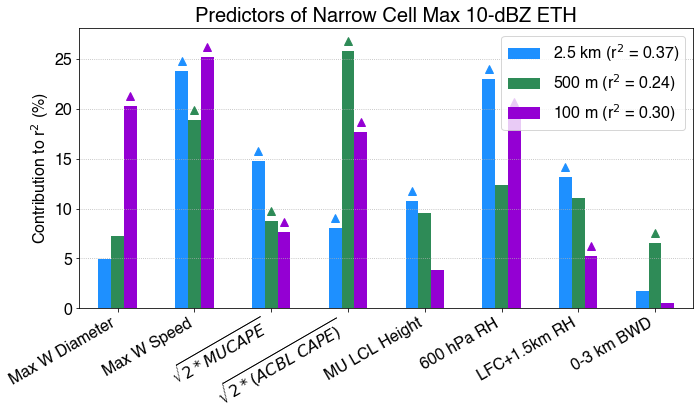

In [112]:
pval_thresh = 0.05

# Plot contributions to r**2 with r**2 values
relimp_perc_d2 = lm_narrow_std_all_eth_d2[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d3 = lm_narrow_std_all_eth_d3[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d4 = lm_narrow_std_all_eth_d4[['relimp_perc']].to_numpy()[1:].squeeze()

df = pd.DataFrame({f"2.5 km (r$^2$ = {lm_narrow_std_all_eth_d2['r2'][0]:.2f})": relimp_perc_d2,
                   f"500 m (r$^2$ = {lm_narrow_std_all_eth_d3['r2'][0]:.2f})": relimp_perc_d3,
                   f"100 m (r$^2$ = {lm_narrow_std_all_eth_d4['r2'][0]:.2f})": relimp_perc_d4,}, index=predictors_all)
# p-values
df_pval = pd.DataFrame({"2.5 km":lm_narrow_std_all_eth_d2['pval'].to_numpy()[1:].squeeze(),
                        "500 m":lm_narrow_std_all_eth_d3['pval'].to_numpy()[1:].squeeze(),
                        "100 m":lm_narrow_std_all_eth_d4['pval'].to_numpy()[1:].squeeze(),}, index=predictors_all)
color_dict = {f"2.5 km (r$^2$ = {lm_narrow_std_all_eth_d2['r2'][0]:.2f})": 'dodgerblue', 
              f"500 m (r$^2$ = {lm_narrow_std_all_eth_d3['r2'][0]:.2f})": 'seagreen',
              f"100 m (r$^2$ = {lm_narrow_std_all_eth_d4['r2'][0]:.2f})": 'darkviolet'}

fig, ax = plt.subplots(1,1, figsize=(10,6))
markersize = 8
df.plot.bar(ax=ax, rot=30, fontsize=16, color=color_dict)

# Loop through each container (corresponding to each column in the DataFrame)
for i, container in enumerate(ax.containers):
    column = df.columns[i]  # Get the column name for the current container

    # Iterate through each bar in the container
    for j, bar in enumerate(container):
        bar_x = bar.get_x() + bar.get_width() / 2  # Get the center x position of the bar
        bar_height = bar.get_height()  # Get the bar height
        bar_color = bar.get_facecolor()  # Get the color of the bar
        
        # Get the center x position of the bar
        bar_x = bar.get_x() + bar.get_width() / 2
        bar_height = bar.get_height()
        
        # Check the corresponding p-value
        if df_pval.iloc[j,i] < pval_thresh:
            ax.plot(bar_x, bar_height + 1, marker='^', markersize=markersize, color=bar_color)
        
ax.legend(fontsize=16)
ax.set_ylabel('Contribution to r$^2$ (%)', fontsize=16)
ax.set_title('Predictors of Narrow Cell Max 10-dBZ ETH', fontsize=20)
# ax.set_title('Predictors of Narrow Cell Max Updraft Top', fontsize=20)
# ax.set_ylim(0,35)
plt.xticks(horizontalalignment='right')
ax.grid(axis='y', ls=':')

fig.tight_layout()
figname = f'{figdir}Narrow_Cell_All_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png'
# figname = f'{figdir}Narrow_Cell_All_Predictor_Contributions_MaxWTop_d2_d3_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
print(figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/Wide_Cell_All_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png


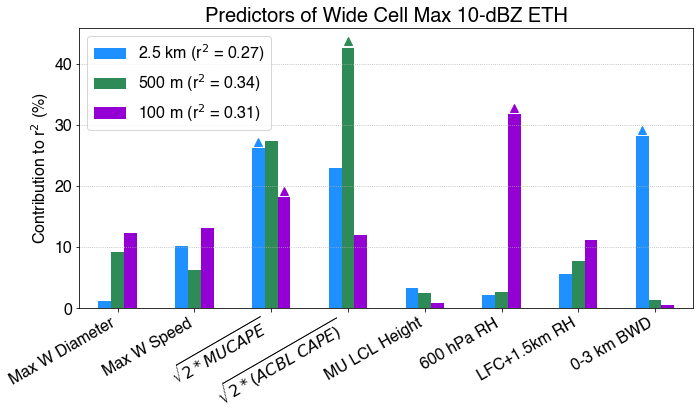

In [113]:
pval_thresh = 0.05

# Plot contributions to r**2 with r**2 values
relimp_perc_d2 = lm_wide_std_all_eth_d2[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d3 = lm_wide_std_all_eth_d3[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d4 = lm_wide_std_all_eth_d4[['relimp_perc']].to_numpy()[1:].squeeze()

df = pd.DataFrame({f"2.5 km (r$^2$ = {lm_wide_std_all_eth_d2['r2'][0]:.2f})": relimp_perc_d2,
                   f"500 m (r$^2$ = {lm_wide_std_all_eth_d3['r2'][0]:.2f})": relimp_perc_d3,
                   f"100 m (r$^2$ = {lm_wide_std_all_eth_d4['r2'][0]:.2f})": relimp_perc_d4,}, index=predictors_all)
# p-values
df_pval = pd.DataFrame({"2.5 km":lm_wide_std_all_eth_d2['pval'].to_numpy()[1:].squeeze(),
                        "500 m":lm_wide_std_all_eth_d3['pval'].to_numpy()[1:].squeeze(),
                        "100 m":lm_wide_std_all_eth_d4['pval'].to_numpy()[1:].squeeze(),}, index=predictors_all)
color_dict = {f"2.5 km (r$^2$ = {lm_wide_std_all_eth_d2['r2'][0]:.2f})": 'dodgerblue', 
              f"500 m (r$^2$ = {lm_wide_std_all_eth_d3['r2'][0]:.2f})": 'seagreen',
              f"100 m (r$^2$ = {lm_wide_std_all_eth_d4['r2'][0]:.2f})": 'darkviolet'}
fig, ax = plt.subplots(1,1, figsize=(10,6))
markersize = 8
df.plot.bar(ax=ax, rot=30, fontsize=16, color=color_dict)

# Loop through each container (corresponding to each column in the DataFrame)
for i, container in enumerate(ax.containers):
    column = df.columns[i]  # Get the column name for the current container

    # Iterate through each bar in the container
    for j, bar in enumerate(container):
        bar_x = bar.get_x() + bar.get_width() / 2  # Get the center x position of the bar
        bar_height = bar.get_height()  # Get the bar height
        bar_color = bar.get_facecolor()  # Get the color of the bar
        
        # Get the center x position of the bar
        bar_x = bar.get_x() + bar.get_width() / 2
        bar_height = bar.get_height()
        
        # Check the corresponding p-value
        if df_pval.iloc[j,i] < pval_thresh:
            ax.plot(bar_x, bar_height + 1, marker='^', markersize=markersize, color=bar_color)
            
ax.legend(fontsize=16)
ax.set_ylabel('Contribution to r$^2$ (%)', fontsize=16)
ax.set_title('Predictors of Wide Cell Max 10-dBZ ETH', fontsize=20)
# ax.set_title('Predictors of Wide Cell Max Updraft Top', fontsize=20)
# ax.set_ylim(0,60)
plt.xticks(horizontalalignment='right')
ax.grid(axis='y', ls=':')

fig.tight_layout()
figname = f'{figdir}Wide_Cell_All_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png'
# figname = f'{figdir}Wide_Cell_All_Predictor_Contributions_MaxWTop_d2_d3_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
print(figname)

## Plot contributions to r<sup>2</sup> for ETH (minimal set)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/Narrow_Cell_MinSet_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png


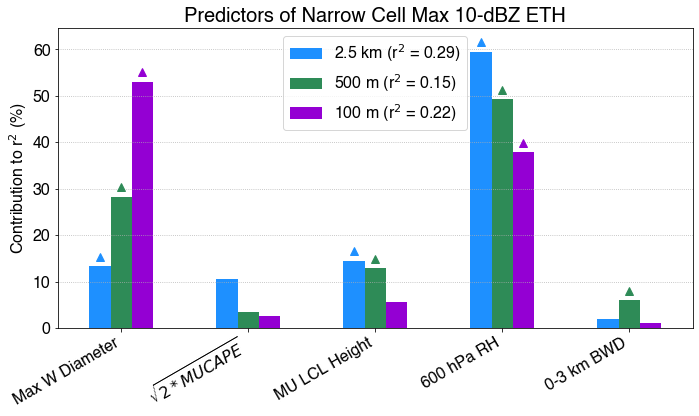

In [114]:
pval_thresh = 0.05

# Plot contributions to r**2 with r**2 values
relimp_perc_d2 = lm_narrow_std_minset_eth_d2[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d3 = lm_narrow_std_minset_eth_d3[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d4 = lm_narrow_std_minset_eth_d4[['relimp_perc']].to_numpy()[1:].squeeze()

df = pd.DataFrame({f"2.5 km (r$^2$ = {lm_narrow_std_minset_eth_d2['r2'][0]:.2f})": relimp_perc_d2,
                   f"500 m (r$^2$ = {lm_narrow_std_minset_eth_d3['r2'][0]:.2f})": relimp_perc_d3,
                   f"100 m (r$^2$ = {lm_narrow_std_minset_eth_d4['r2'][0]:.2f})": relimp_perc_d4,}, index=predictors_minset)
# p-values
df_pval = pd.DataFrame({"2.5 km":lm_narrow_std_minset_eth_d2['pval'].to_numpy()[1:].squeeze(),
                        "500 m":lm_narrow_std_minset_eth_d3['pval'].to_numpy()[1:].squeeze(),
                        "100 m":lm_narrow_std_minset_eth_d4['pval'].to_numpy()[1:].squeeze(),}, index=predictors_minset)
color_dict = {f"2.5 km (r$^2$ = {lm_narrow_std_minset_eth_d2['r2'][0]:.2f})": 'dodgerblue', 
              f"500 m (r$^2$ = {lm_narrow_std_minset_eth_d3['r2'][0]:.2f})": 'seagreen',
              f"100 m (r$^2$ = {lm_narrow_std_minset_eth_d4['r2'][0]:.2f})": 'darkviolet'}

fig, ax = plt.subplots(1,1, figsize=(10,6))
markersize = 8
df.plot.bar(ax=ax, rot=30, fontsize=16, color=color_dict)

# Loop through each container (corresponding to each column in the DataFrame)
for i, container in enumerate(ax.containers):
    column = df.columns[i]  # Get the column name for the current container

    # Iterate through each bar in the container
    for j, bar in enumerate(container):
        bar_x = bar.get_x() + bar.get_width() / 2  # Get the center x position of the bar
        bar_height = bar.get_height()  # Get the bar height
        bar_color = bar.get_facecolor()  # Get the color of the bar
        
        # Get the center x position of the bar
        bar_x = bar.get_x() + bar.get_width() / 2
        bar_height = bar.get_height()
        
        # Check the corresponding p-value
        if df_pval.iloc[j,i] < pval_thresh:
            ax.plot(bar_x, bar_height+2, marker='^', markersize=markersize, color=bar_color)
        
ax.legend(fontsize=16)
ax.set_ylabel('Contribution to r$^2$ (%)', fontsize=16)
ax.set_title('Predictors of Narrow Cell Max 10-dBZ ETH', fontsize=20)
# ax.set_title('Predictors of Narrow Cell Max Updraft Top', fontsize=20)
# ax.set_ylim(0,50)
plt.xticks(horizontalalignment='right')
ax.grid(axis='y', ls=':')

fig.tight_layout()
figname = f'{figdir}Narrow_Cell_MinSet_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png'
# figname = f'{figdir}Narrow_Cell_NoLNB_Predictor_Contributions_MaxWTop_d2_d3_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
print(figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/Wide_Cell_MinSet_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png


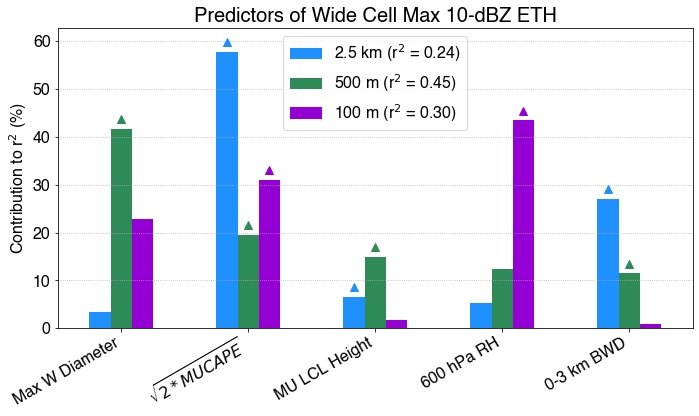

In [115]:
pval_thresh = 0.05

# Plot contributions to r**2 with r**2 values
relimp_perc_d2 = lm_wide_std_minset_eth_d2[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d3 = lm_wide_std_minset_eth_d3[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d4 = lm_wide_std_minset_eth_d4[['relimp_perc']].to_numpy()[1:].squeeze()

df = pd.DataFrame({f"2.5 km (r$^2$ = {lm_wide_std_minset_eth_d2['r2'][0]:.2f})": relimp_perc_d2,
                   f"500 m (r$^2$ = {lm_wide_std_minset_eth_d3['r2'][0]:.2f})": relimp_perc_d3,
                   f"100 m (r$^2$ = {lm_wide_std_minset_eth_d4['r2'][0]:.2f})": relimp_perc_d4,}, index=predictors_minset)
# p-values
df_pval = pd.DataFrame({"2.5 km":lm_wide_std_minset_eth_d2['pval'].to_numpy()[1:].squeeze(),
                        "500 m":lm_wide_std_minset_eth_d3['pval'].to_numpy()[1:].squeeze(),
                        "100 m":lm_wide_std_minset_eth_d4['pval'].to_numpy()[1:].squeeze(),}, index=predictors_minset)
color_dict = {f"2.5 km (r$^2$ = {lm_wide_std_minset_eth_d2['r2'][0]:.2f})": 'dodgerblue', 
              f"500 m (r$^2$ = {lm_wide_std_minset_eth_d3['r2'][0]:.2f})": 'seagreen',
              f"100 m (r$^2$ = {lm_wide_std_minset_eth_d4['r2'][0]:.2f})": 'darkviolet'}

fig, ax = plt.subplots(1,1, figsize=(10,6))
markersize = 8
df.plot.bar(ax=ax, rot=30, fontsize=16, color=color_dict)

# Loop through each container (corresponding to each column in the DataFrame)
for i, container in enumerate(ax.containers):
    column = df.columns[i]  # Get the column name for the current container

    # Iterate through each bar in the container
    for j, bar in enumerate(container):
        bar_x = bar.get_x() + bar.get_width() / 2  # Get the center x position of the bar
        bar_height = bar.get_height()  # Get the bar height
        bar_color = bar.get_facecolor()  # Get the color of the bar
        
        # Get the center x position of the bar
        bar_x = bar.get_x() + bar.get_width() / 2
        bar_height = bar.get_height()
        
        # Check the corresponding p-value
        if df_pval.iloc[j,i] < pval_thresh:
            ax.plot(bar_x, bar_height+2, marker='^', markersize=markersize, color=bar_color)
        
ax.legend(fontsize=16)
ax.set_ylabel('Contribution to r$^2$ (%)', fontsize=16)
ax.set_title('Predictors of Wide Cell Max 10-dBZ ETH', fontsize=20)
# ax.set_title('Predictors of Wide Cell Max Updraft Top', fontsize=20)
# ax.set_ylim(0,60)
plt.xticks(horizontalalignment='right')
ax.grid(axis='y', ls=':')

fig.tight_layout()
figname = f'{figdir}Wide_Cell_MinSet_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
print(figname)

## Plot contributions to r<sup>2</sup> for W-top (minimal set)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/Narrow_Cell_MinSet_Predictor_Contributions_MaxWTop_d2_d3_d4.png


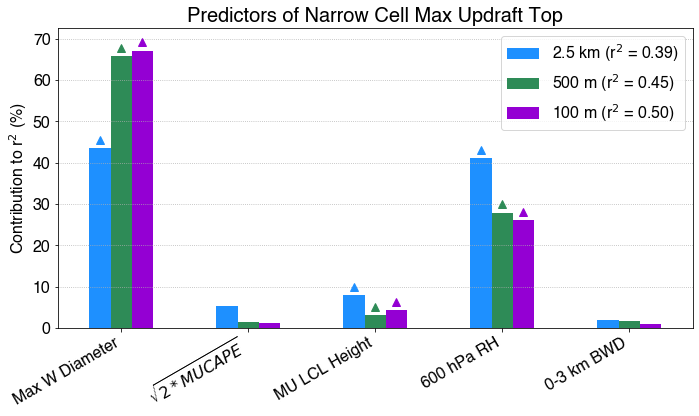

In [116]:
pval_thresh = 0.05

# Plot contributions to r**2 with r**2 values
relimp_perc_d2 = lm_narrow_std_minset_wtop_d2[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d3 = lm_narrow_std_minset_wtop_d3[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d4 = lm_narrow_std_minset_wtop_d4[['relimp_perc']].to_numpy()[1:].squeeze()

df = pd.DataFrame({f"2.5 km (r$^2$ = {lm_narrow_std_minset_wtop_d2['r2'][0]:.2f})": relimp_perc_d2,
                   f"500 m (r$^2$ = {lm_narrow_std_minset_wtop_d3['r2'][0]:.2f})": relimp_perc_d3,
                   f"100 m (r$^2$ = {lm_narrow_std_minset_wtop_d4['r2'][0]:.2f})": relimp_perc_d4,}, index=predictors_minset)
# p-values
df_pval = pd.DataFrame({"2.5 km":lm_narrow_std_minset_wtop_d2['pval'].to_numpy()[1:].squeeze(),
                        "500 m":lm_narrow_std_minset_wtop_d3['pval'].to_numpy()[1:].squeeze(),
                        "100 m":lm_narrow_std_minset_wtop_d4['pval'].to_numpy()[1:].squeeze(),}, index=predictors_minset)
color_dict = {f"2.5 km (r$^2$ = {lm_narrow_std_minset_wtop_d2['r2'][0]:.2f})": 'dodgerblue', 
              f"500 m (r$^2$ = {lm_narrow_std_minset_wtop_d3['r2'][0]:.2f})": 'seagreen',
              f"100 m (r$^2$ = {lm_narrow_std_minset_wtop_d4['r2'][0]:.2f})": 'darkviolet'}

fig, ax = plt.subplots(1,1, figsize=(10,6))
markersize = 8
df.plot.bar(ax=ax, rot=30, fontsize=16, color=color_dict)

# Loop through each container (corresponding to each column in the DataFrame)
for i, container in enumerate(ax.containers):
    column = df.columns[i]  # Get the column name for the current container

    # Iterate through each bar in the container
    for j, bar in enumerate(container):
        bar_x = bar.get_x() + bar.get_width() / 2  # Get the center x position of the bar
        bar_height = bar.get_height()  # Get the bar height
        bar_color = bar.get_facecolor()  # Get the color of the bar
        
        # Get the center x position of the bar
        bar_x = bar.get_x() + bar.get_width() / 2
        bar_height = bar.get_height()
        
        # Check the corresponding p-value
        if df_pval.iloc[j,i] < pval_thresh:
            ax.plot(bar_x, bar_height+2, marker='^', markersize=markersize, color=bar_color)
        
ax.legend(fontsize=16)
ax.set_ylabel('Contribution to r$^2$ (%)', fontsize=16)
# ax.set_title('Predictors of Narrow Cell Max 10-dBZ ETH', fontsize=20)
ax.set_title('Predictors of Narrow Cell Max Updraft Top', fontsize=20)
# ax.set_ylim(0,50)
plt.xticks(horizontalalignment='right')
ax.grid(axis='y', ls=':')

fig.tight_layout()
figname = f'{figdir}Narrow_Cell_MinSet_Predictor_Contributions_MaxWTop_d2_d3_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
print(figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/Wide_Cell_MinSet_Predictor_Contributions_MaxWTop_d2_d3_d4.png


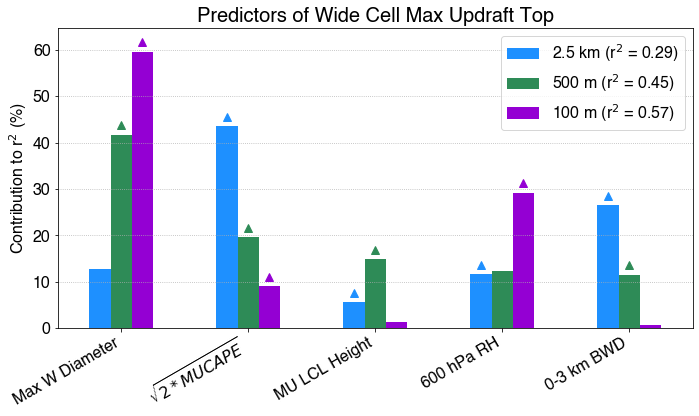

In [117]:
pval_thresh = 0.05

# Plot contributions to r**2 with r**2 values
relimp_perc_d2 = lm_wide_std_minset_wtop_d2[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d3 = lm_wide_std_minset_wtop_d3[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d4 = lm_wide_std_minset_wtop_d4[['relimp_perc']].to_numpy()[1:].squeeze()

df = pd.DataFrame({f"2.5 km (r$^2$ = {lm_wide_std_minset_wtop_d2['r2'][0]:.2f})": relimp_perc_d2,
                   f"500 m (r$^2$ = {lm_wide_std_minset_wtop_d3['r2'][0]:.2f})": relimp_perc_d3,
                   f"100 m (r$^2$ = {lm_wide_std_minset_wtop_d4['r2'][0]:.2f})": relimp_perc_d4,}, index=predictors_minset)
# p-values
df_pval = pd.DataFrame({"2.5 km":lm_wide_std_minset_wtop_d2['pval'].to_numpy()[1:].squeeze(),
                        "500 m":lm_wide_std_minset_wtop_d3['pval'].to_numpy()[1:].squeeze(),
                        "100 m":lm_wide_std_minset_wtop_d4['pval'].to_numpy()[1:].squeeze(),}, index=predictors_minset)

color_dict = {f"2.5 km (r$^2$ = {lm_wide_std_minset_wtop_d2['r2'][0]:.2f})": 'dodgerblue', 
              f"500 m (r$^2$ = {lm_wide_std_minset_wtop_d3['r2'][0]:.2f})": 'seagreen',
              f"100 m (r$^2$ = {lm_wide_std_minset_wtop_d4['r2'][0]:.2f})": 'darkviolet'}

fig, ax = plt.subplots(1,1, figsize=(10,6))
markersize = 8
df.plot.bar(ax=ax, rot=30, fontsize=16, color=color_dict)

# Loop through each container (corresponding to each column in the DataFrame)
for i, container in enumerate(ax.containers):
    column = df.columns[i]  # Get the column name for the current container

    # Iterate through each bar in the container
    for j, bar in enumerate(container):
        bar_x = bar.get_x() + bar.get_width() / 2  # Get the center x position of the bar
        bar_height = bar.get_height()  # Get the bar height
        bar_color = bar.get_facecolor()  # Get the color of the bar
        
        # Get the center x position of the bar
        bar_x = bar.get_x() + bar.get_width() / 2
        bar_height = bar.get_height()
        
        # Check the corresponding p-value
        if df_pval.iloc[j,i] < pval_thresh:
            ax.plot(bar_x, bar_height+2, marker='^', markersize=markersize, color=bar_color)
        
ax.legend(fontsize=16)
ax.set_ylabel('Contribution to r$^2$ (%)', fontsize=16)
# ax.set_title('Predictors of Wide Cell Max 10-dBZ ETH', fontsize=20)
ax.set_title('Predictors of Wide Cell Max Updraft Top', fontsize=20)
# ax.set_ylim(0,60)
plt.xticks(horizontalalignment='right')
ax.grid(axis='y', ls=':')

fig.tight_layout()
figname = f'{figdir}Wide_Cell_MinSet_Predictor_Contributions_MaxWTop_d2_d3_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
print(figname)

## Plot contributions to r<sup>2</sup> (environmental variables only)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/Narrow_Cell_EnvOnly_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png


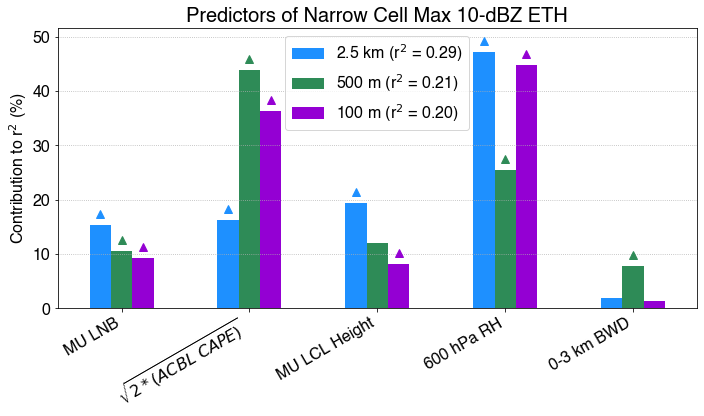

In [118]:
pval_thresh = 0.05

# Plot contributions to r**2 with r**2 values
relimp_perc_d2 = lm_narrow_std_envonly_eth_d2[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d3 = lm_narrow_std_envonly_eth_d3[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d4 = lm_narrow_std_envonly_eth_d4[['relimp_perc']].to_numpy()[1:].squeeze()

df = pd.DataFrame({f"2.5 km (r$^2$ = {lm_narrow_std_envonly_eth_d2['r2'][0]:.2f})": relimp_perc_d2,
                   f"500 m (r$^2$ = {lm_narrow_std_envonly_eth_d3['r2'][0]:.2f})": relimp_perc_d3,
                   f"100 m (r$^2$ = {lm_narrow_std_envonly_eth_d4['r2'][0]:.2f})": relimp_perc_d4,}, index=predictors_envonly)
# p-values
df_pval = pd.DataFrame({"2.5 km":lm_narrow_std_envonly_eth_d2['pval'].to_numpy()[1:].squeeze(),
                        "500 m":lm_narrow_std_envonly_eth_d3['pval'].to_numpy()[1:].squeeze(),
                        "100 m":lm_narrow_std_envonly_eth_d4['pval'].to_numpy()[1:].squeeze(),}, index=predictors_envonly)

color_dict = {f"2.5 km (r$^2$ = {lm_narrow_std_envonly_eth_d2['r2'][0]:.2f})": 'dodgerblue', 
              f"500 m (r$^2$ = {lm_narrow_std_envonly_eth_d3['r2'][0]:.2f})": 'seagreen',
              f"100 m (r$^2$ = {lm_narrow_std_envonly_eth_d4['r2'][0]:.2f})": 'darkviolet'}
fig, ax = plt.subplots(1,1, figsize=(10,6))
markersize = 8
df.plot.bar(ax=ax, rot=30, fontsize=16, color=color_dict)

# Loop through each container (corresponding to each column in the DataFrame)
for i, container in enumerate(ax.containers):
    column = df.columns[i]  # Get the column name for the current container

    # Iterate through each bar in the container
    for j, bar in enumerate(container):
        bar_x = bar.get_x() + bar.get_width() / 2  # Get the center x position of the bar
        bar_height = bar.get_height()  # Get the bar height
        bar_color = bar.get_facecolor()  # Get the color of the bar
        
        # Get the center x position of the bar
        bar_x = bar.get_x() + bar.get_width() / 2
        bar_height = bar.get_height()
        
        # Check the corresponding p-value
        if df_pval.iloc[j,i] < pval_thresh:
            ax.plot(bar_x, bar_height+2, marker='^', markersize=markersize, color=bar_color)
            
ax.legend(fontsize=16, ncol=1)
ax.set_ylabel('Contribution to r$^2$ (%)', fontsize=16)
ax.set_title('Predictors of Narrow Cell Max 10-dBZ ETH', fontsize=20)
# ax.set_title('Predictors of Narrow Cell Max Updraft Top', fontsize=20)
# ax.set_ylim(0,35)
plt.xticks(horizontalalignment='right')
ax.grid(axis='y', ls=':')

fig.tight_layout()
figname = f'{figdir}Narrow_Cell_EnvOnly_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png'
# figname = f'{figdir}Narrow_Cell_EnvOnly_Predictor_Contributions_MaxWTop_d2_d3_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
print(figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/Wide_Cell_EnvOnly_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png


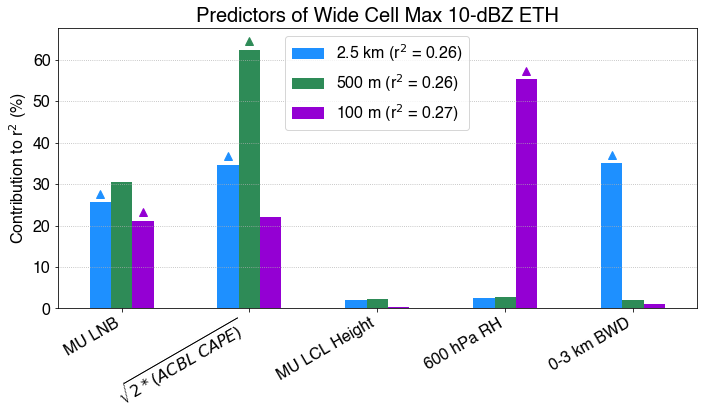

In [119]:
pval_thresh = 0.05

# Plot contributions to r**2 with r**2 values
relimp_perc_d2 = lm_wide_std_envonly_eth_d2[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d3 = lm_wide_std_envonly_eth_d3[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d4 = lm_wide_std_envonly_eth_d4[['relimp_perc']].to_numpy()[1:].squeeze()

# index = ['MU LNB', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', '500 hPa RH', '0-6 km BWD']
df = pd.DataFrame({f"2.5 km (r$^2$ = {lm_wide_std_envonly_eth_d2['r2'][0]:.2f})": relimp_perc_d2,
                   f"500 m (r$^2$ = {lm_wide_std_envonly_eth_d3['r2'][0]:.2f})": relimp_perc_d3,
                   f"100 m (r$^2$ = {lm_wide_std_envonly_eth_d4['r2'][0]:.2f})": relimp_perc_d4,}, index=predictors_envonly)
# p-values
df_pval = pd.DataFrame({"2.5 km":lm_wide_std_envonly_eth_d2['pval'].to_numpy()[1:].squeeze(),
                        "500 m":lm_wide_std_envonly_eth_d3['pval'].to_numpy()[1:].squeeze(),
                        "100 m":lm_wide_std_envonly_eth_d4['pval'].to_numpy()[1:].squeeze(),}, index=predictors_envonly)

color_dict = {f"2.5 km (r$^2$ = {lm_wide_std_envonly_eth_d2['r2'][0]:.2f})": 'dodgerblue', 
              f"500 m (r$^2$ = {lm_wide_std_envonly_eth_d3['r2'][0]:.2f})": 'seagreen',
              f"100 m (r$^2$ = {lm_wide_std_envonly_eth_d4['r2'][0]:.2f})": 'darkviolet'}

fig, ax = plt.subplots(1,1, figsize=(10,6))
markersize = 8
df.plot.bar(ax=ax, rot=30, fontsize=16, color=color_dict)

# Loop through each container (corresponding to each column in the DataFrame)
for i, container in enumerate(ax.containers):
    column = df.columns[i]  # Get the column name for the current container

    # Iterate through each bar in the container
    for j, bar in enumerate(container):
        bar_x = bar.get_x() + bar.get_width() / 2  # Get the center x position of the bar
        bar_height = bar.get_height()  # Get the bar height
        bar_color = bar.get_facecolor()  # Get the color of the bar
        
        # Get the center x position of the bar
        bar_x = bar.get_x() + bar.get_width() / 2
        bar_height = bar.get_height()
        
        # Check the corresponding p-value
        if df_pval.iloc[j,i] < pval_thresh:
            ax.plot(bar_x, bar_height+2, marker='^', markersize=markersize, color=bar_color)
            
ax.legend(fontsize=16)
ax.set_ylabel('Contribution to r$^2$ (%)', fontsize=16)
ax.set_title('Predictors of Wide Cell Max 10-dBZ ETH', fontsize=20)
# ax.set_title('Predictors of Wide Cell Max Updraft Top', fontsize=20)
# ax.set_ylim(0,60)
plt.xticks(horizontalalignment='right')
ax.grid(axis='y', ls=':')

fig.tight_layout()
figname = f'{figdir}Wide_Cell_EnvOnly_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png'
# figname = f'{figdir}Wide_Cell_EnvOnly_Predictor_Contributions_MaxWTop_d2_d3_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
print(figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/Narrow_Cell_EnvOnly_Predictor_Contributions_MaxWTop_d2_d3_d4.png


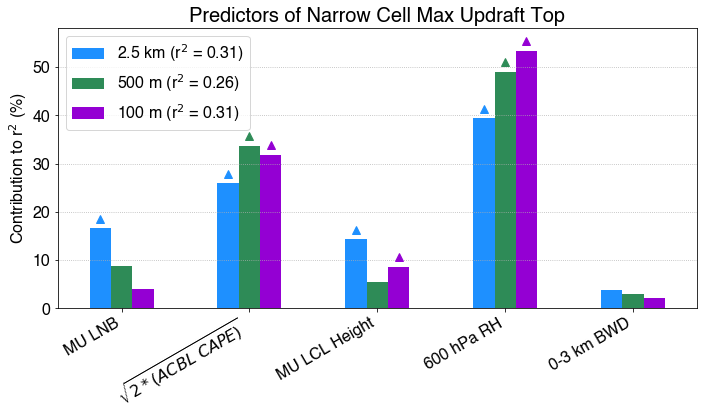

In [120]:
pval_thresh = 0.05

# Plot contributions to r**2 with r**2 values
relimp_perc_d2 = lm_narrow_std_envonly_wtop_d2[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d3 = lm_narrow_std_envonly_wtop_d3[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d4 = lm_narrow_std_envonly_wtop_d4[['relimp_perc']].to_numpy()[1:].squeeze()

df = pd.DataFrame({f"2.5 km (r$^2$ = {lm_narrow_std_envonly_wtop_d2['r2'][0]:.2f})": relimp_perc_d2,
                   f"500 m (r$^2$ = {lm_narrow_std_envonly_wtop_d3['r2'][0]:.2f})": relimp_perc_d3,
                   f"100 m (r$^2$ = {lm_narrow_std_envonly_wtop_d4['r2'][0]:.2f})": relimp_perc_d4,}, index=predictors_envonly)
# p-values
df_pval = pd.DataFrame({"2.5 km":lm_narrow_std_envonly_wtop_d2['pval'].to_numpy()[1:].squeeze(),
                        "500 m":lm_narrow_std_envonly_wtop_d3['pval'].to_numpy()[1:].squeeze(),
                        "100 m":lm_narrow_std_envonly_wtop_d4['pval'].to_numpy()[1:].squeeze(),}, index=predictors_envonly)

color_dict = {f"2.5 km (r$^2$ = {lm_narrow_std_envonly_wtop_d2['r2'][0]:.2f})": 'dodgerblue', 
              f"500 m (r$^2$ = {lm_narrow_std_envonly_wtop_d3['r2'][0]:.2f})": 'seagreen',
              f"100 m (r$^2$ = {lm_narrow_std_envonly_wtop_d4['r2'][0]:.2f})": 'darkviolet'}
fig, ax = plt.subplots(1,1, figsize=(10,6))
markersize = 8
df.plot.bar(ax=ax, rot=30, fontsize=16, color=color_dict)

# Loop through each container (corresponding to each column in the DataFrame)
for i, container in enumerate(ax.containers):
    column = df.columns[i]  # Get the column name for the current container

    # Iterate through each bar in the container
    for j, bar in enumerate(container):
        bar_x = bar.get_x() + bar.get_width() / 2  # Get the center x position of the bar
        bar_height = bar.get_height()  # Get the bar height
        bar_color = bar.get_facecolor()  # Get the color of the bar
        
        # Get the center x position of the bar
        bar_x = bar.get_x() + bar.get_width() / 2
        bar_height = bar.get_height()
        
        # Check the corresponding p-value
        if df_pval.iloc[j,i] < pval_thresh:
            ax.plot(bar_x, bar_height+2, marker='^', markersize=markersize, color=bar_color)
            
ax.legend(fontsize=16, ncol=1)
ax.set_ylabel('Contribution to r$^2$ (%)', fontsize=16)
ax.set_title('Predictors of Narrow Cell Max Updraft Top', fontsize=20)
# ax.set_ylim(0,35)
plt.xticks(horizontalalignment='right')
ax.grid(axis='y', ls=':')

fig.tight_layout()
figname = f'{figdir}Narrow_Cell_EnvOnly_Predictor_Contributions_MaxWTop_d2_d3_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
print(figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/Wide_Cell_EnvOnly_Predictor_Contributions_MaxWTop_d2_d3_d4.png


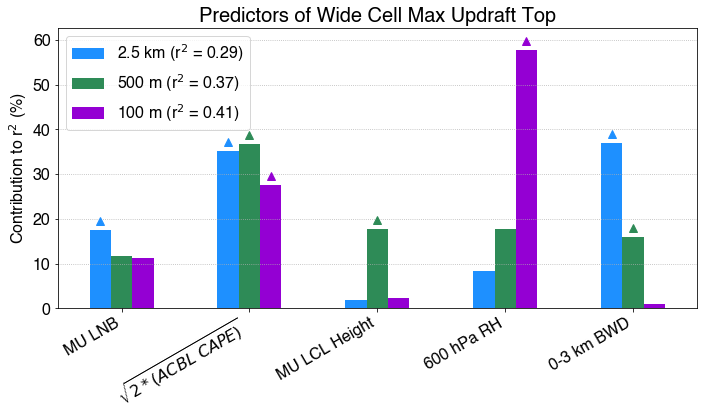

In [121]:
pval_thresh = 0.05

# Plot contributions to r**2 with r**2 values
relimp_perc_d2 = lm_wide_std_envonly_wtop_d2[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d3 = lm_wide_std_envonly_wtop_d3[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d4 = lm_wide_std_envonly_wtop_d4[['relimp_perc']].to_numpy()[1:].squeeze()

# index = ['MU LNB', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', '500 hPa RH', '0-6 km BWD']
df = pd.DataFrame({f"2.5 km (r$^2$ = {lm_wide_std_envonly_wtop_d2['r2'][0]:.2f})": relimp_perc_d2,
                   f"500 m (r$^2$ = {lm_wide_std_envonly_wtop_d3['r2'][0]:.2f})": relimp_perc_d3,
                   f"100 m (r$^2$ = {lm_wide_std_envonly_wtop_d4['r2'][0]:.2f})": relimp_perc_d4,}, index=predictors_envonly)
# p-values
df_pval = pd.DataFrame({"2.5 km":lm_wide_std_envonly_wtop_d2['pval'].to_numpy()[1:].squeeze(),
                        "500 m":lm_wide_std_envonly_wtop_d3['pval'].to_numpy()[1:].squeeze(),
                        "100 m":lm_wide_std_envonly_wtop_d4['pval'].to_numpy()[1:].squeeze(),}, index=predictors_envonly)

color_dict = {f"2.5 km (r$^2$ = {lm_wide_std_envonly_wtop_d2['r2'][0]:.2f})": 'dodgerblue', 
              f"500 m (r$^2$ = {lm_wide_std_envonly_wtop_d3['r2'][0]:.2f})": 'seagreen',
              f"100 m (r$^2$ = {lm_wide_std_envonly_wtop_d4['r2'][0]:.2f})": 'darkviolet'}

fig, ax = plt.subplots(1,1, figsize=(10,6))
markersize = 8
df.plot.bar(ax=ax, rot=30, fontsize=16, color=color_dict)

# Loop through each container (corresponding to each column in the DataFrame)
for i, container in enumerate(ax.containers):
    column = df.columns[i]  # Get the column name for the current container

    # Iterate through each bar in the container
    for j, bar in enumerate(container):
        bar_x = bar.get_x() + bar.get_width() / 2  # Get the center x position of the bar
        bar_height = bar.get_height()  # Get the bar height
        bar_color = bar.get_facecolor()  # Get the color of the bar
        
        # Get the center x position of the bar
        bar_x = bar.get_x() + bar.get_width() / 2
        bar_height = bar.get_height()
        
        # Check the corresponding p-value
        if df_pval.iloc[j,i] < pval_thresh:
            ax.plot(bar_x, bar_height+2, marker='^', markersize=markersize, color=bar_color)
            
ax.legend(fontsize=16)
ax.set_ylabel('Contribution to r$^2$ (%)', fontsize=16)
ax.set_title('Predictors of Wide Cell Max Updraft Top', fontsize=20)
# ax.set_ylim(0,60)
plt.xticks(horizontalalignment='right')
ax.grid(axis='y', ls=':')

fig.tight_layout()
figname = f'{figdir}Wide_Cell_EnvOnly_Predictor_Contributions_MaxWTop_d2_d3_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
print(figname)

## Function to plot MLR coefficients & error bars

In [122]:
def plot_coef_errbar(x_n_dict, y_n_dict, err_n_dict, x_w_dict, y_w_dict, err_w_dict, 
                     errbar_lw=3, markersize=None, fontsize=None, suptitle=None,
                     xticklabels=None, xlims=None, ylims=None, yticks=None, ylabel=None, labels=None, legend_loc=None,
                     xlabel_list=None, xlabel_pos=None, x_divide=None, xtick1_rot=30, xtick2_rot=30, xtick1_ha='right', xtick2_ha='center',
                     figsize=None, figname=None, dpi=300):
    
    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    fig, ax = plt.subplots(1,1, figsize=figsize, dpi=dpi)

    lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}

    # Plot narrow cells
    ax.plot(x_n_dict['d2'], y_n_dict['d2'], 'D', markersize=markersize, color=lcolors['d2'], label=labels['d2'])
    ax.plot(x_n_dict['d3'], y_n_dict['d3'], 'D', markersize=markersize, color=lcolors['d3'], label=labels['d3'])
    ax.plot(x_n_dict['d4'], y_n_dict['d4'], 'D', markersize=markersize, color=lcolors['d4'], label=labels['d4'])
    for ii in range(len(x_n_dict['d2'])):
        ax.plot([x_n_dict['d2'][ii],x_n_dict['d2'][ii]], [err_n_dict['d2'][0][ii],err_n_dict['d2'][1][ii]], lw=errbar_lw, color=lcolors['d2'])
        ax.plot([x_n_dict['d3'][ii],x_n_dict['d3'][ii]], [err_n_dict['d3'][0][ii],err_n_dict['d3'][1][ii]], lw=errbar_lw, color=lcolors['d3'])
        ax.plot([x_n_dict['d4'][ii],x_n_dict['d4'][ii]], [err_n_dict['d4'][0][ii],err_n_dict['d4'][1][ii]], lw=errbar_lw, color=lcolors['d4'])
    # Plot wide cells
    ax.plot(x_w_dict['d2'], y_w_dict['d2'], 'D', markersize=markersize, color=lcolors['d2'])
    ax.plot(x_w_dict['d3'], y_w_dict['d3'], 'D', markersize=markersize, color=lcolors['d3'])
    ax.plot(x_w_dict['d4'], y_w_dict['d4'], 'D', markersize=markersize, color=lcolors['d4'])
    for ii in range(len(x_w_dict['d2'])):
        ax.plot([x_w_dict['d2'][ii],x_w_dict['d2'][ii]], [err_w_dict['d2'][0][ii],err_w_dict['d2'][1][ii]], lw=errbar_lw, color=lcolors['d2'])
        ax.plot([x_w_dict['d3'][ii],x_w_dict['d3'][ii]], [err_w_dict['d3'][0][ii],err_w_dict['d3'][1][ii]], lw=errbar_lw, color=lcolors['d3'])
        ax.plot([x_w_dict['d4'][ii],x_w_dict['d4'][ii]], [err_w_dict['d4'][0][ii],err_w_dict['d4'][1][ii]], lw=errbar_lw, color=lcolors['d4'])

    # Plot vertical divide lines
    if x_divide is not None:
        for ii in range(len(x_divide)):
            ax.axvline(x=x_divide[ii], color='k', lw=1)
    
    # Set axes
    ax.axhline(y=0, color='k')
    ax.set_xlim(xlims[0], xlims[1])
    if ylims is not None: ax.set_ylim(ylims[0], ylims[1])
    if yticks is not None: ax.set_yticks(yticks)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', ls='--')
    ax.legend(loc=legend_loc)
    
    # Label xaxis
    ax.tick_params('x', length=6)
    xticks = np.arange(1, len(xticklabels)+1)
    plt.xticks(ticks=xticks, labels=xticklabels, rotation=xtick1_rot, ha=xtick1_ha)
    
    # Secondary xaxis for variable names
    secax = ax.secondary_xaxis('top')
    secax.tick_params('x', length=6)
    secax.set_xticks(ticks=xlabel_pos)
    secax.set_xticklabels(xlabel_list)
    secax.xaxis.set_tick_params(rotation=xtick2_rot)
    # Set horizontal alignment for all tick labels to 'right'
    plt.setp(secax.get_xticklabels(), ha=xtick2_ha)

    # Suptitle
    if suptitle is not None:
        fig.suptitle(suptitle, fontsize=fontsize+4, weight='bold', y=0.95)
    
    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=dpi, facecolor='w')
    return fig

## Convert Pandas tables to numpy arrays for plotting

In [123]:
lm_wide_std_all_eth_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.015,0.090,0.170,0.866,0.272,0.206,-0.164,0.194,NaN,NaN
1,x1,-0.023,0.107,-0.212,0.833,0.272,0.206,-0.236,0.191,0.003,1.248
2,x2,0.123,0.119,1.032,0.305,0.272,0.206,-0.114,0.359,0.028,10.258
3,x3,0.350,0.164,2.135,0.035,0.272,0.206,0.024,0.676,0.071,26.192
4,x4,0.122,0.132,0.929,0.355,0.272,0.206,-0.139,0.384,0.062,22.973
5,x5,0.167,0.113,1.479,0.143,0.272,0.206,-0.057,0.391,0.009,3.405
6,x6,0.059,0.152,0.384,0.702,0.272,0.206,-0.244,0.361,0.006,2.241
7,x7,0.007,0.143,0.051,0.959,0.272,0.206,-0.277,0.292,0.015,5.559
8,x8,0.338,0.104,3.249,0.002,0.272,0.206,0.131,0.545,0.076,28.125


In [124]:
# Coefficient
narrow_stdcoef_all_eth_d2 = lm_narrow_std_all_eth_d2[['coef']].to_numpy()[1:].squeeze()
n_predictor_all = len(narrow_stdcoef_all_eth_d2)
# Coefficient Confidence Intervals
narrow_stdcoefCI_all_eth_d2 = np.full((2, n_predictor_all), np.NaN)
narrow_stdcoefCI_all_eth_d2[0,:] = lm_narrow_std_all_eth_d2[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_all_eth_d2[1,:] = lm_narrow_std_all_eth_d2[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_all_eth_d2 = lm_wide_std_all_eth_d2[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_all_eth_d2 = np.full((2, n_predictor_all), np.NaN)
wide_stdcoefCI_all_eth_d2[0,:] = lm_wide_std_all_eth_d2[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_all_eth_d2[1,:] = lm_wide_std_all_eth_d2[['CI[97.5%]']].to_numpy()[1:].squeeze()

narrow_stdcoef_all_eth_d3 = lm_narrow_std_all_eth_d3[['coef']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_all_eth_d3 = np.full((2, n_predictor_all), np.NaN)
narrow_stdcoefCI_all_eth_d3[0,:] = lm_narrow_std_all_eth_d3[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_all_eth_d3[1,:] = lm_narrow_std_all_eth_d3[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_all_eth_d3 = lm_wide_std_all_eth_d3[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_all_eth_d3 = np.full((2, n_predictor_all), np.NaN)
wide_stdcoefCI_all_eth_d3[0,:] = lm_wide_std_all_eth_d3[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_all_eth_d3[1,:] = lm_wide_std_all_eth_d3[['CI[97.5%]']].to_numpy()[1:].squeeze()

narrow_stdcoef_all_eth_d4 = lm_narrow_std_all_eth_d4[['coef']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_all_eth_d4 = np.full((2, n_predictor_all), np.NaN)
narrow_stdcoefCI_all_eth_d4[0,:] = lm_narrow_std_all_eth_d4[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_all_eth_d4[1,:] = lm_narrow_std_all_eth_d4[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_all_eth_d4 = lm_wide_std_all_eth_d4[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_all_eth_d4 = np.full((2, n_predictor_all), np.NaN)
wide_stdcoefCI_all_eth_d4[0,:] = lm_wide_std_all_eth_d4[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_all_eth_d4[1,:] = lm_wide_std_all_eth_d4[['CI[97.5%]']].to_numpy()[1:].squeeze()

# Make narrow predictor x positions
x_n_d2 = np.arange(1, 2*n_predictor_all, 2)-0.2
x_n_d3 = np.arange(1, 2*n_predictor_all, 2)
x_n_d4 = np.arange(1, 2*n_predictor_all, 2)+0.2
print(x_n_d2, x_n_d3, x_n_d4)

# Make wide predictor x positions
x_w_d2 = np.arange(2, 2*n_predictor_all+1, 2)-0.2
x_w_d3 = np.arange(2, 2*n_predictor_all+1, 2)
x_w_d4 = np.arange(2, 2*n_predictor_all+1, 2)+0.2
print(x_w_d2, x_w_d3, x_w_d4)

[ 0.8  2.8  4.8  6.8  8.8 10.8 12.8 14.8] [ 1  3  5  7  9 11 13 15] [ 1.2  3.2  5.2  7.2  9.2 11.2 13.2 15.2]
[ 1.8  3.8  5.8  7.8  9.8 11.8 13.8 15.8] [ 2  4  6  8 10 12 14 16] [ 2.2  4.2  6.2  8.2 10.2 12.2 14.2 16.2]


/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/MLR_ETH_Standardized_Coefficients_All.png


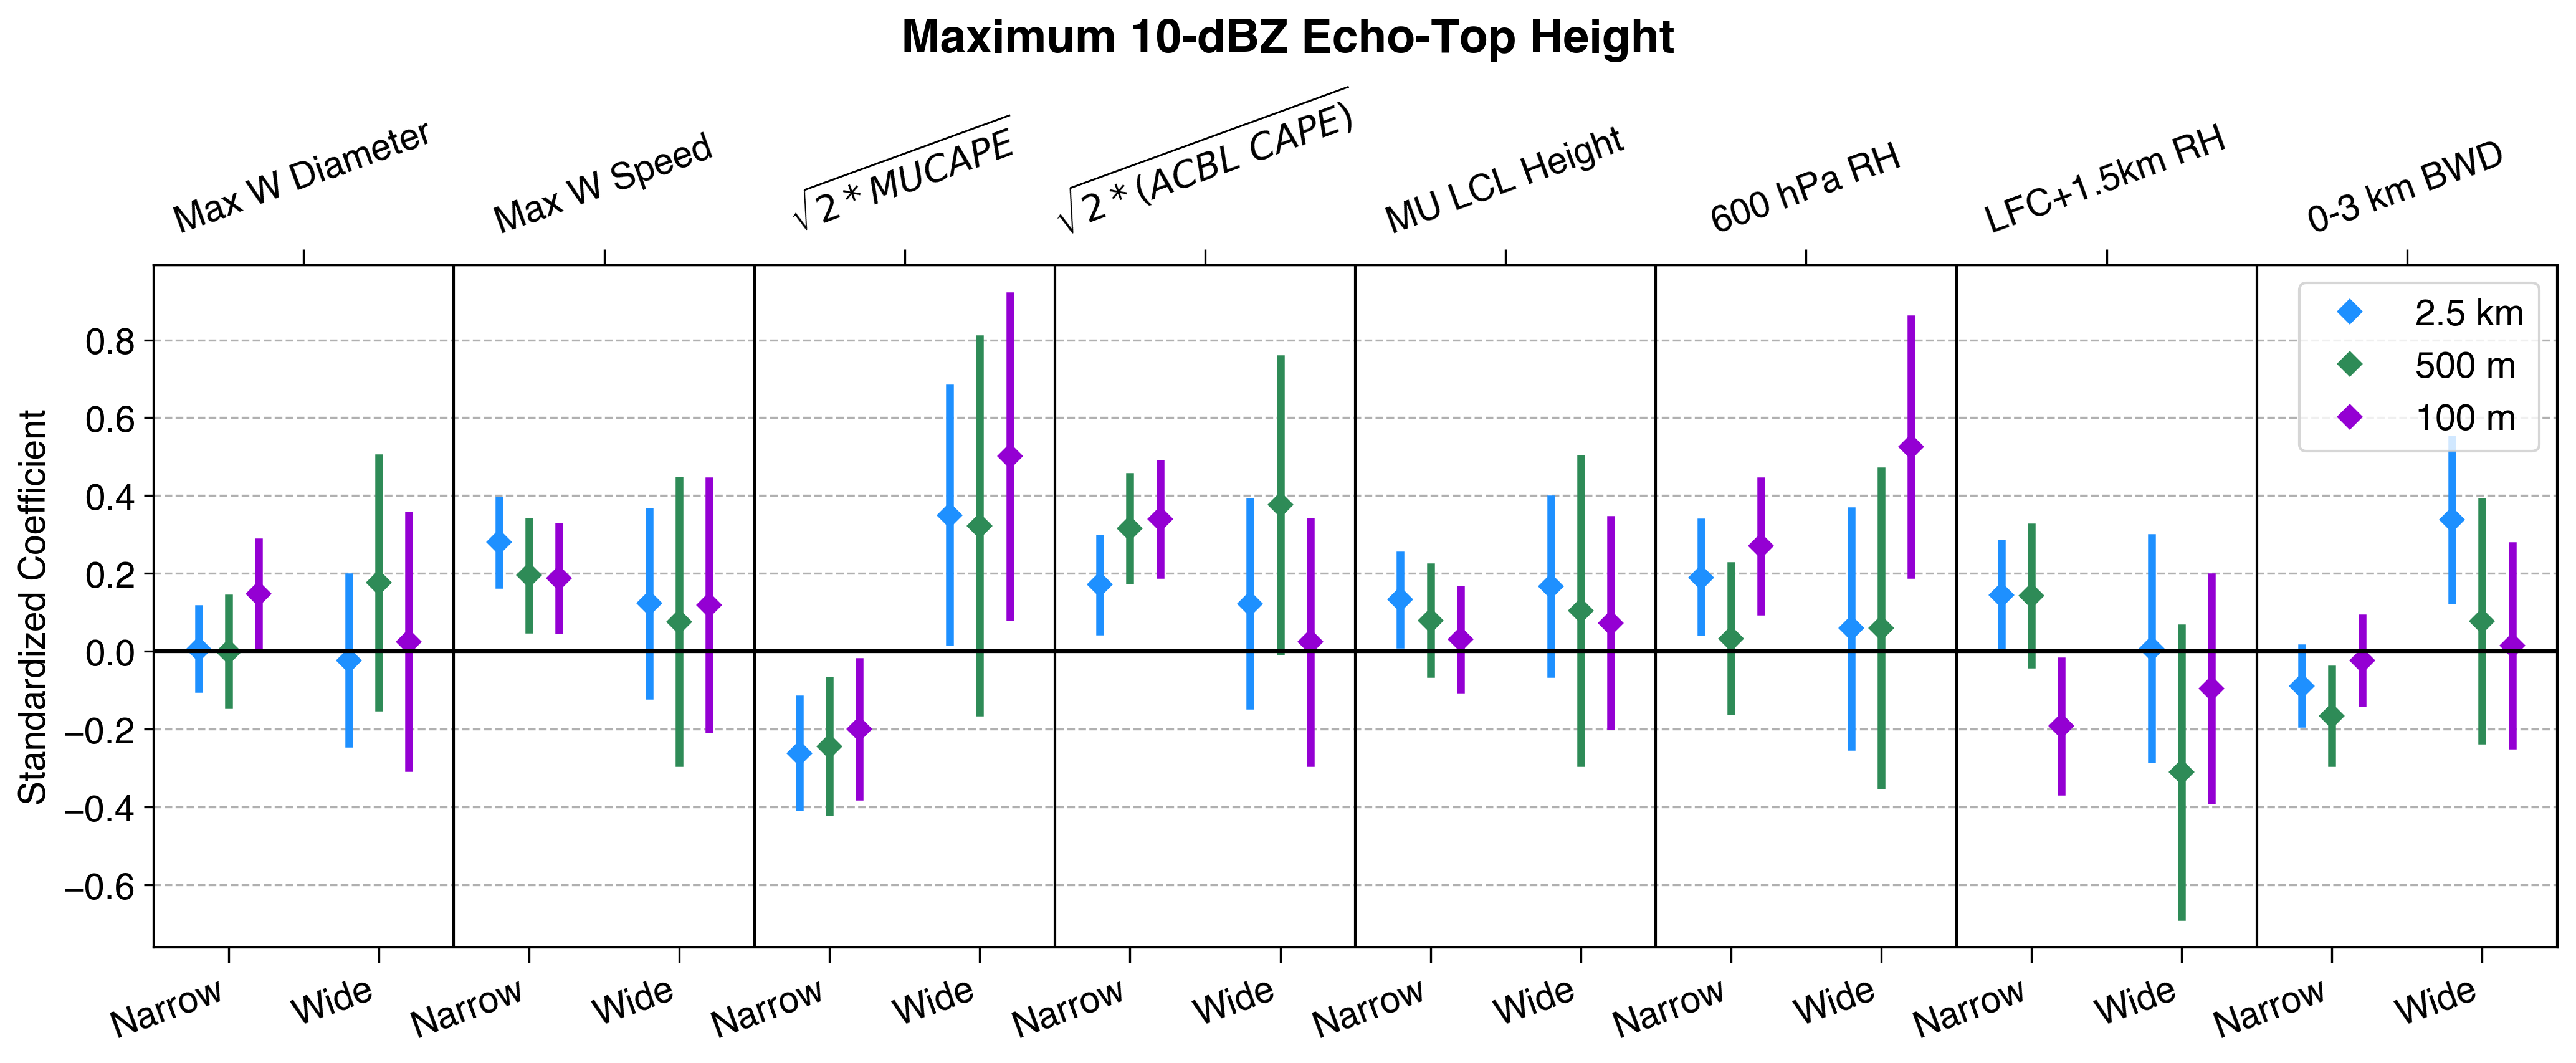

In [125]:
x_n_dict = {'d2':x_n_d2, 'd3':x_n_d3, 'd4':x_n_d4}
y_n_dict = {'d2':narrow_stdcoef_all_eth_d2, 'd3':narrow_stdcoef_all_eth_d3, 'd4':narrow_stdcoef_all_eth_d4}
err_n_dict = {'d2':narrow_stdcoefCI_all_eth_d2, 'd3':narrow_stdcoefCI_all_eth_d3, 'd4':narrow_stdcoefCI_all_eth_d4}
x_w_dict = {'d2':x_w_d2, 'd3':x_w_d3, 'd4':x_w_d4}
y_w_dict = {'d2':wide_stdcoef_all_eth_d2, 'd3':wide_stdcoef_all_eth_d3, 'd4':wide_stdcoef_all_eth_d4}
err_w_dict = {'d2':wide_stdcoefCI_all_eth_d2, 'd3':wide_stdcoefCI_all_eth_d3, 'd4':wide_stdcoefCI_all_eth_d4}
x_divide = np.arange(0, 2*n_predictor_all+1, 2)+0.5
xticklabels = ['Narrow','Wide']*n_predictor_all
xlabel_list = predictors_all
xlabel_pos = (x_divide[:-1] + x_divide[1:])/2
xlims = (np.min(x_divide), np.max(x_divide))
ylims = None
yticks = None
# ylims = (-1.8, 1.5)
# yticks = np.arange(-1.8, 1.51, 0.3)
ylabel = 'Standardized Coefficient'
labels = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}
legend_loc = 'upper right'
markersize = 6
errbar_lw = 3
xtick1_rot = 20
xtick2_rot = 20
fontsize = 14
figsize = (14,6)
suptitle = 'Maximum 10-dBZ Echo-Top Height'
figname = f'{figdir}MLR_ETH_Standardized_Coefficients_All.png'
# figname = f'{figdir}MLR_WTop_Standardized_Coefficients_All.png'
print(figname)
fig = plot_coef_errbar(x_n_dict, y_n_dict, err_n_dict, x_w_dict, y_w_dict, err_w_dict, 
                       errbar_lw=errbar_lw, markersize=markersize, fontsize=fontsize, suptitle=suptitle,
                       xticklabels=xticklabels, xlims=xlims, ylims=ylims, yticks=yticks, ylabel=ylabel, labels=labels, legend_loc=legend_loc,
                       xlabel_list=xlabel_list, xlabel_pos=xlabel_pos, x_divide=x_divide, xtick1_rot=xtick1_rot, xtick2_rot=xtick2_rot,
                       figname=figname, figsize=figsize, dpi=300)

In [126]:
# Coefficient
narrow_stdcoef_minset_eth_d2 = lm_narrow_std_minset_eth_d2[['coef']].to_numpy()[1:].squeeze()
n_predictor_minset = len(narrow_stdcoef_minset_eth_d2)
# Coefficient Confidence Intervals
narrow_stdcoefCI_minset_eth_d2 = np.full((2, n_predictor_minset), np.NaN)
narrow_stdcoefCI_minset_eth_d2[0,:] = lm_narrow_std_minset_eth_d2[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_minset_eth_d2[1,:] = lm_narrow_std_minset_eth_d2[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_minset_eth_d2 = lm_wide_std_minset_eth_d2[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_minset_eth_d2 = np.full((2, n_predictor_minset), np.NaN)
wide_stdcoefCI_minset_eth_d2[0,:] = lm_wide_std_minset_eth_d2[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_minset_eth_d2[1,:] = lm_wide_std_minset_eth_d2[['CI[97.5%]']].to_numpy()[1:].squeeze()

narrow_stdcoef_minset_eth_d3 = lm_narrow_std_minset_eth_d3[['coef']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_minset_eth_d3 = np.full((2, n_predictor_minset), np.NaN)
narrow_stdcoefCI_minset_eth_d3[0,:] = lm_narrow_std_minset_eth_d3[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_minset_eth_d3[1,:] = lm_narrow_std_minset_eth_d3[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_minset_eth_d3 = lm_wide_std_minset_eth_d3[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_minset_eth_d3 = np.full((2, n_predictor_minset), np.NaN)
wide_stdcoefCI_minset_eth_d3[0,:] = lm_wide_std_minset_eth_d3[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_minset_eth_d3[1,:] = lm_wide_std_minset_eth_d3[['CI[97.5%]']].to_numpy()[1:].squeeze()

narrow_stdcoef_minset_eth_d4 = lm_narrow_std_minset_eth_d4[['coef']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_minset_eth_d4 = np.full((2, n_predictor_minset), np.NaN)
narrow_stdcoefCI_minset_eth_d4[0,:] = lm_narrow_std_minset_eth_d4[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_minset_eth_d4[1,:] = lm_narrow_std_minset_eth_d4[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_minset_eth_d4 = lm_wide_std_minset_eth_d4[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_minset_eth_d4 = np.full((2, n_predictor_minset), np.NaN)
wide_stdcoefCI_minset_eth_d4[0,:] = lm_wide_std_minset_eth_d4[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_minset_eth_d4[1,:] = lm_wide_std_minset_eth_d4[['CI[97.5%]']].to_numpy()[1:].squeeze()

# Make narrow predictor x positions
x_n_d2 = np.arange(1, 2*n_predictor_minset, 2)-0.2
x_n_d3 = np.arange(1, 2*n_predictor_minset, 2)
x_n_d4 = np.arange(1, 2*n_predictor_minset, 2)+0.2
print(x_n_d2, x_n_d3, x_n_d4)

# Make wide predictor x positions
x_w_d2 = np.arange(2, 2*n_predictor_minset+1, 2)-0.2
x_w_d3 = np.arange(2, 2*n_predictor_minset+1, 2)
x_w_d4 = np.arange(2, 2*n_predictor_minset+1, 2)+0.2
print(x_w_d2, x_w_d3, x_w_d4)

[0.8 2.8 4.8 6.8 8.8] [1 3 5 7 9] [1.2 3.2 5.2 7.2 9.2]
[1.8 3.8 5.8 7.8 9.8] [ 2  4  6  8 10] [ 2.2  4.2  6.2  8.2 10.2]


/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/MLR_ETH_Standardized_Coefficients_MinSet.png


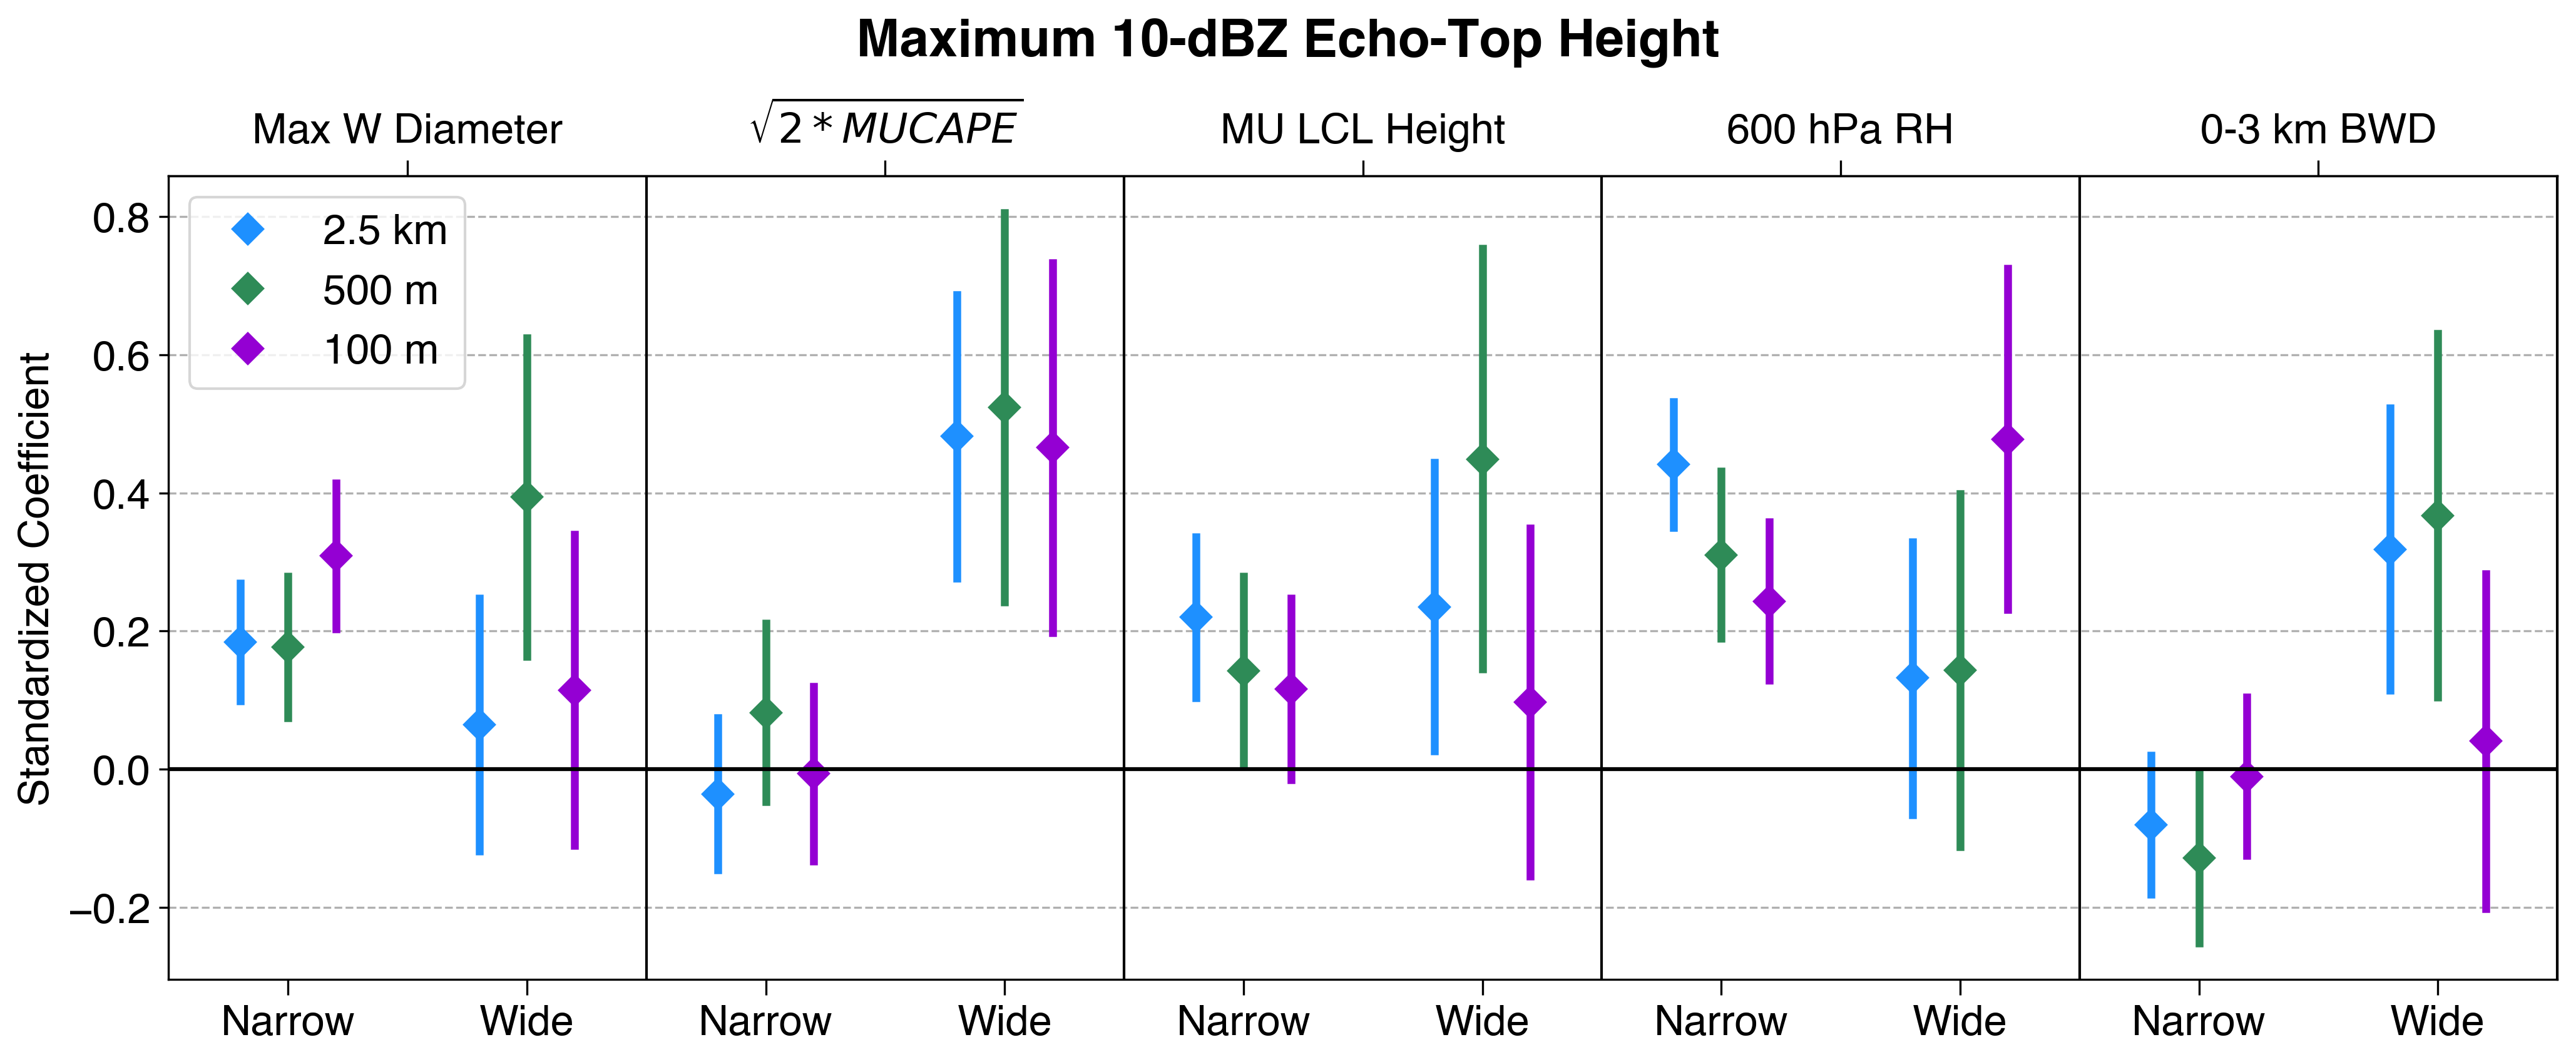

In [127]:
x_n_dict = {'d2':x_n_d2, 'd3':x_n_d3, 'd4':x_n_d4}
y_n_dict = {'d2':narrow_stdcoef_minset_eth_d2, 'd3':narrow_stdcoef_minset_eth_d3, 'd4':narrow_stdcoef_minset_eth_d4}
err_n_dict = {'d2':narrow_stdcoefCI_minset_eth_d2, 'd3':narrow_stdcoefCI_minset_eth_d3, 'd4':narrow_stdcoefCI_minset_eth_d4}
x_w_dict = {'d2':x_w_d2, 'd3':x_w_d3, 'd4':x_w_d4}
y_w_dict = {'d2':wide_stdcoef_minset_eth_d2, 'd3':wide_stdcoef_minset_eth_d3, 'd4':wide_stdcoef_minset_eth_d4}
err_w_dict = {'d2':wide_stdcoefCI_minset_eth_d2, 'd3':wide_stdcoefCI_minset_eth_d3, 'd4':wide_stdcoefCI_minset_eth_d4}
x_divide = np.arange(0, 2*n_predictor_minset+1, 2)+0.5
xticklabels = ['Narrow','Wide']*n_predictor_minset
xlabel_list = predictors_minset
xlabel_pos = (x_divide[:-1] + x_divide[1:])/2
xlims = (np.min(x_divide), np.max(x_divide))
ylims = None
yticks = None
# ylims = (-1.8, 1.5)
# yticks = np.arange(-1.8, 1.51, 0.3)
ylabel = 'Standardized Coefficient'
labels = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}
legend_loc = 'upper left'
markersize = 8
errbar_lw = 3
xtick1_rot = 0
xtick2_rot = 0
xtick1_ha = 'center'
xtick2_ha = 'center'
fontsize = 16
figsize = (14,6)
suptitle = 'Maximum 10-dBZ Echo-Top Height'
figname = f'{figdir}MLR_ETH_Standardized_Coefficients_MinSet.png'
# figname = f'{figdir}MLR_WTop_Standardized_Coefficients_NoLNB.png'
print(figname)
fig = plot_coef_errbar(x_n_dict, y_n_dict, err_n_dict, x_w_dict, y_w_dict, err_w_dict, 
                       errbar_lw=errbar_lw, markersize=markersize, fontsize=fontsize, suptitle=suptitle,
                       xticklabels=xticklabels, xlims=xlims, ylims=ylims, yticks=yticks, ylabel=ylabel, labels=labels, legend_loc=legend_loc,
                       xlabel_list=xlabel_list, xlabel_pos=xlabel_pos, x_divide=x_divide, xtick1_rot=xtick1_rot, xtick2_rot=xtick2_rot, xtick1_ha=xtick1_ha, xtick2_ha=xtick2_ha,
                       figname=figname, figsize=figsize, dpi=300)

In [128]:
# Coefficient
narrow_stdcoef_minset_wtop_d2 = lm_narrow_std_minset_wtop_d2[['coef']].to_numpy()[1:].squeeze()
n_predictor_minset = len(narrow_stdcoef_minset_wtop_d2)
# Coefficient Confidence Intervals
narrow_stdcoefCI_minset_wtop_d2 = np.full((2, n_predictor_minset), np.NaN)
narrow_stdcoefCI_minset_wtop_d2[0,:] = lm_narrow_std_minset_wtop_d2[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_minset_wtop_d2[1,:] = lm_narrow_std_minset_wtop_d2[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_minset_wtop_d2 = lm_wide_std_minset_wtop_d2[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_minset_wtop_d2 = np.full((2, n_predictor_minset), np.NaN)
wide_stdcoefCI_minset_wtop_d2[0,:] = lm_wide_std_minset_wtop_d2[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_minset_wtop_d2[1,:] = lm_wide_std_minset_wtop_d2[['CI[97.5%]']].to_numpy()[1:].squeeze()

narrow_stdcoef_minset_wtop_d3 = lm_narrow_std_minset_wtop_d3[['coef']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_minset_wtop_d3 = np.full((2, n_predictor_minset), np.NaN)
narrow_stdcoefCI_minset_wtop_d3[0,:] = lm_narrow_std_minset_wtop_d3[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_minset_wtop_d3[1,:] = lm_narrow_std_minset_wtop_d3[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_minset_wtop_d3 = lm_wide_std_minset_wtop_d3[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_minset_wtop_d3 = np.full((2, n_predictor_minset), np.NaN)
wide_stdcoefCI_minset_wtop_d3[0,:] = lm_wide_std_minset_wtop_d3[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_minset_wtop_d3[1,:] = lm_wide_std_minset_wtop_d3[['CI[97.5%]']].to_numpy()[1:].squeeze()

narrow_stdcoef_minset_wtop_d4 = lm_narrow_std_minset_wtop_d4[['coef']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_minset_wtop_d4 = np.full((2, n_predictor_minset), np.NaN)
narrow_stdcoefCI_minset_wtop_d4[0,:] = lm_narrow_std_minset_wtop_d4[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_minset_wtop_d4[1,:] = lm_narrow_std_minset_wtop_d4[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_minset_wtop_d4 = lm_wide_std_minset_wtop_d4[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_minset_wtop_d4 = np.full((2, n_predictor_minset), np.NaN)
wide_stdcoefCI_minset_wtop_d4[0,:] = lm_wide_std_minset_wtop_d4[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_minset_wtop_d4[1,:] = lm_wide_std_minset_wtop_d4[['CI[97.5%]']].to_numpy()[1:].squeeze()

# Make narrow predictor x positions
x_n_d2 = np.arange(1, 2*n_predictor_minset, 2)-0.2
x_n_d3 = np.arange(1, 2*n_predictor_minset, 2)
x_n_d4 = np.arange(1, 2*n_predictor_minset, 2)+0.2
print(x_n_d2, x_n_d3, x_n_d4)

# Make wide predictor x positions
x_w_d2 = np.arange(2, 2*n_predictor_minset+1, 2)-0.2
x_w_d3 = np.arange(2, 2*n_predictor_minset+1, 2)
x_w_d4 = np.arange(2, 2*n_predictor_minset+1, 2)+0.2
print(x_w_d2, x_w_d3, x_w_d4)

[0.8 2.8 4.8 6.8 8.8] [1 3 5 7 9] [1.2 3.2 5.2 7.2 9.2]
[1.8 3.8 5.8 7.8 9.8] [ 2  4  6  8 10] [ 2.2  4.2  6.2  8.2 10.2]


/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/MLR_WTop_Standardized_Coefficients_MinSet.png


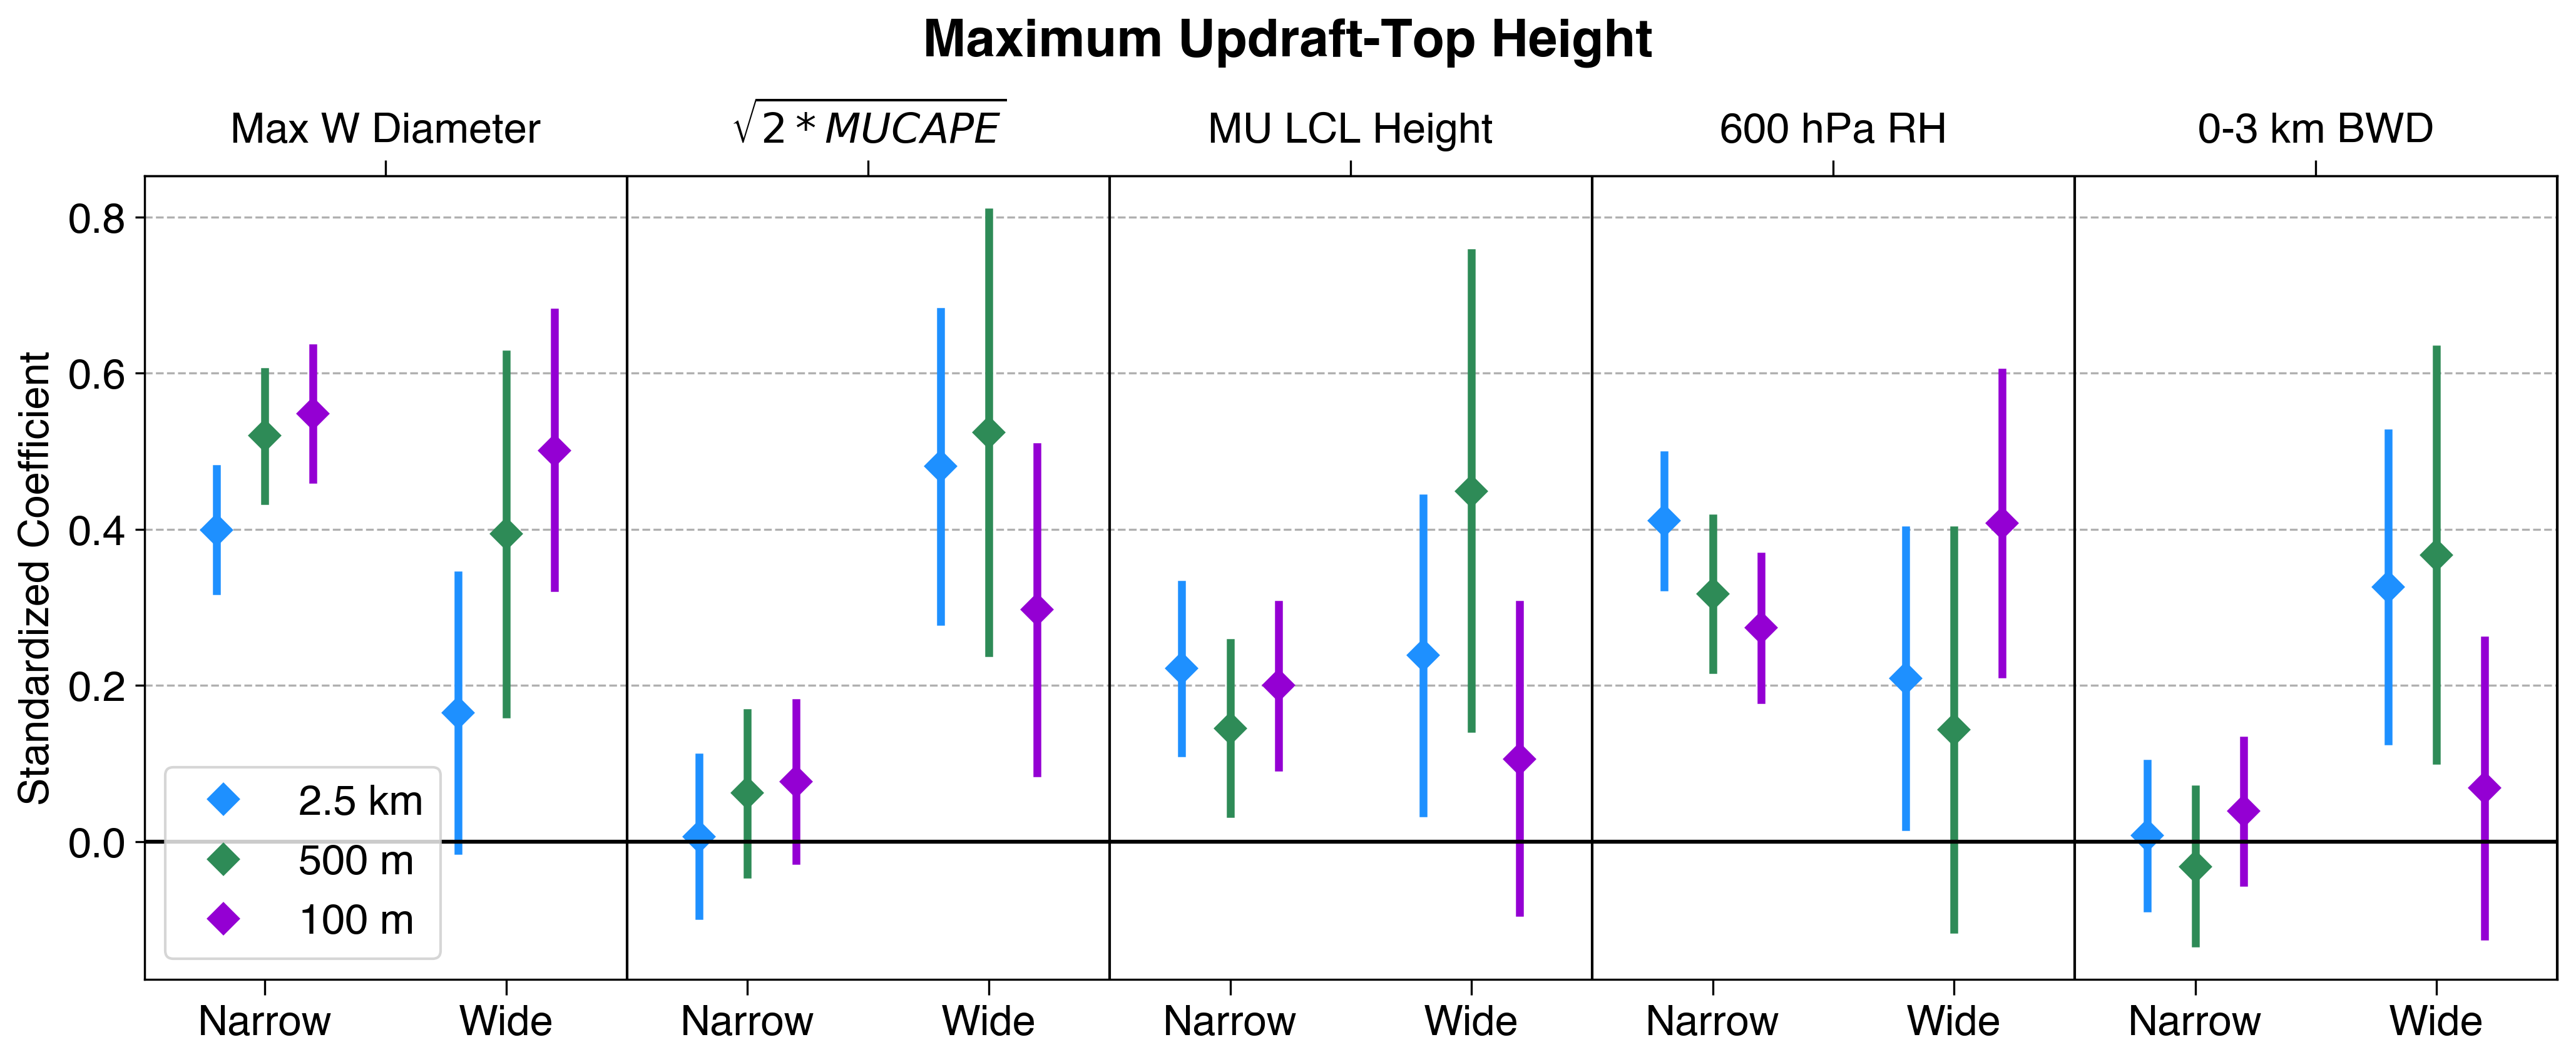

In [129]:
x_n_dict = {'d2':x_n_d2, 'd3':x_n_d3, 'd4':x_n_d4}
y_n_dict = {'d2':narrow_stdcoef_minset_wtop_d2, 'd3':narrow_stdcoef_minset_wtop_d3, 'd4':narrow_stdcoef_minset_wtop_d4}
err_n_dict = {'d2':narrow_stdcoefCI_minset_wtop_d2, 'd3':narrow_stdcoefCI_minset_wtop_d3, 'd4':narrow_stdcoefCI_minset_wtop_d4}
x_w_dict = {'d2':x_w_d2, 'd3':x_w_d3, 'd4':x_w_d4}
y_w_dict = {'d2':wide_stdcoef_minset_wtop_d2, 'd3':wide_stdcoef_minset_wtop_d3, 'd4':wide_stdcoef_minset_wtop_d4}
err_w_dict = {'d2':wide_stdcoefCI_minset_wtop_d2, 'd3':wide_stdcoefCI_minset_wtop_d3, 'd4':wide_stdcoefCI_minset_wtop_d4}
x_divide = np.arange(0, 2*n_predictor_minset+1, 2)+0.5
xticklabels = ['Narrow','Wide']*n_predictor_minset
xlabel_list = predictors_minset
xlabel_pos = (x_divide[:-1] + x_divide[1:])/2
xlims = (np.min(x_divide), np.max(x_divide))
ylims = None
yticks = None
# ylims = (-1.8, 1.5)
# yticks = np.arange(-1.8, 1.51, 0.3)
ylabel = 'Standardized Coefficient'
labels = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}
legend_loc = 'lower left'
markersize = 8
errbar_lw = 3
xtick1_rot = 0
xtick2_rot = 0
xtick1_ha = 'center'
xtick2_ha = 'center'
fontsize = 16
# figsize = (14,5)
figsize = (14,6)
suptitle = 'Maximum Updraft-Top Height'
figname = f'{figdir}MLR_WTop_Standardized_Coefficients_MinSet.png'
# figname = f'{figdir}MLR_WTop_Standardized_Coefficients_NoLNB.png'
print(figname)
fig = plot_coef_errbar(x_n_dict, y_n_dict, err_n_dict, x_w_dict, y_w_dict, err_w_dict, 
                       errbar_lw=errbar_lw, markersize=markersize, fontsize=fontsize, suptitle=suptitle,
                       xticklabels=xticklabels, xlims=xlims, ylims=ylims, yticks=yticks, ylabel=ylabel, labels=labels, legend_loc=legend_loc,
                       xlabel_list=xlabel_list, xlabel_pos=xlabel_pos, x_divide=x_divide, xtick1_rot=xtick1_rot, xtick2_rot=xtick2_rot, xtick1_ha=xtick1_ha, xtick2_ha=xtick2_ha,
                       figname=figname, figsize=figsize, dpi=300)

In [130]:
# Coefficient
narrow_stdcoef_envonly_eth_d2 = lm_narrow_std_envonly_eth_d2[['coef']].to_numpy()[1:].squeeze()
n_predictor_envonly = len(narrow_stdcoef_envonly_eth_d2)
# Coefficient Confidence Intervals
narrow_stdcoefCI_envonly_eth_d2 = np.full((2, n_predictor_envonly), np.NaN)
narrow_stdcoefCI_envonly_eth_d2[0,:] = lm_narrow_std_envonly_eth_d2[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_envonly_eth_d2[1,:] = lm_narrow_std_envonly_eth_d2[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_envonly_eth_d2 = lm_wide_std_envonly_eth_d2[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_envonly_eth_d2 = np.full((2, n_predictor_envonly), np.NaN)
wide_stdcoefCI_envonly_eth_d2[0,:] = lm_wide_std_envonly_eth_d2[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_envonly_eth_d2[1,:] = lm_wide_std_envonly_eth_d2[['CI[97.5%]']].to_numpy()[1:].squeeze()

narrow_stdcoef_envonly_eth_d3 = lm_narrow_std_envonly_eth_d3[['coef']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_envonly_eth_d3 = np.full((2, n_predictor_envonly), np.NaN)
narrow_stdcoefCI_envonly_eth_d3[0,:] = lm_narrow_std_envonly_eth_d3[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_envonly_eth_d3[1,:] = lm_narrow_std_envonly_eth_d3[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_envonly_eth_d3 = lm_wide_std_envonly_eth_d3[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_envonly_eth_d3 = np.full((2, n_predictor_envonly), np.NaN)
wide_stdcoefCI_envonly_eth_d3[0,:] = lm_wide_std_envonly_eth_d3[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_envonly_eth_d3[1,:] = lm_wide_std_envonly_eth_d3[['CI[97.5%]']].to_numpy()[1:].squeeze()

narrow_stdcoef_envonly_eth_d4 = lm_narrow_std_envonly_eth_d4[['coef']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_envonly_eth_d4 = np.full((2, n_predictor_envonly), np.NaN)
narrow_stdcoefCI_envonly_eth_d4[0,:] = lm_narrow_std_envonly_eth_d4[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_envonly_eth_d4[1,:] = lm_narrow_std_envonly_eth_d4[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_envonly_eth_d4 = lm_wide_std_envonly_eth_d4[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_envonly_eth_d4 = np.full((2, n_predictor_envonly), np.NaN)
wide_stdcoefCI_envonly_eth_d4[0,:] = lm_wide_std_envonly_eth_d4[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_envonly_eth_d4[1,:] = lm_wide_std_envonly_eth_d4[['CI[97.5%]']].to_numpy()[1:].squeeze()

# Make narrow predictor x positions
x_n_d2 = np.arange(1, 2*n_predictor_envonly, 2)-0.2
x_n_d3 = np.arange(1, 2*n_predictor_envonly, 2)
x_n_d4 = np.arange(1, 2*n_predictor_envonly, 2)+0.2
print(x_n_d2, x_n_d3, x_n_d4)

# Make wide predictor x positions
x_w_d2 = np.arange(2, 2*n_predictor_envonly+1, 2)-0.2
x_w_d3 = np.arange(2, 2*n_predictor_envonly+1, 2)
x_w_d4 = np.arange(2, 2*n_predictor_envonly+1, 2)+0.2
print(x_w_d2, x_w_d3, x_w_d4)

[0.8 2.8 4.8 6.8 8.8] [1 3 5 7 9] [1.2 3.2 5.2 7.2 9.2]
[1.8 3.8 5.8 7.8 9.8] [ 2  4  6  8 10] [ 2.2  4.2  6.2  8.2 10.2]


/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/MLR_ETH_Standardized_Coefficients_EnvOnlys.png


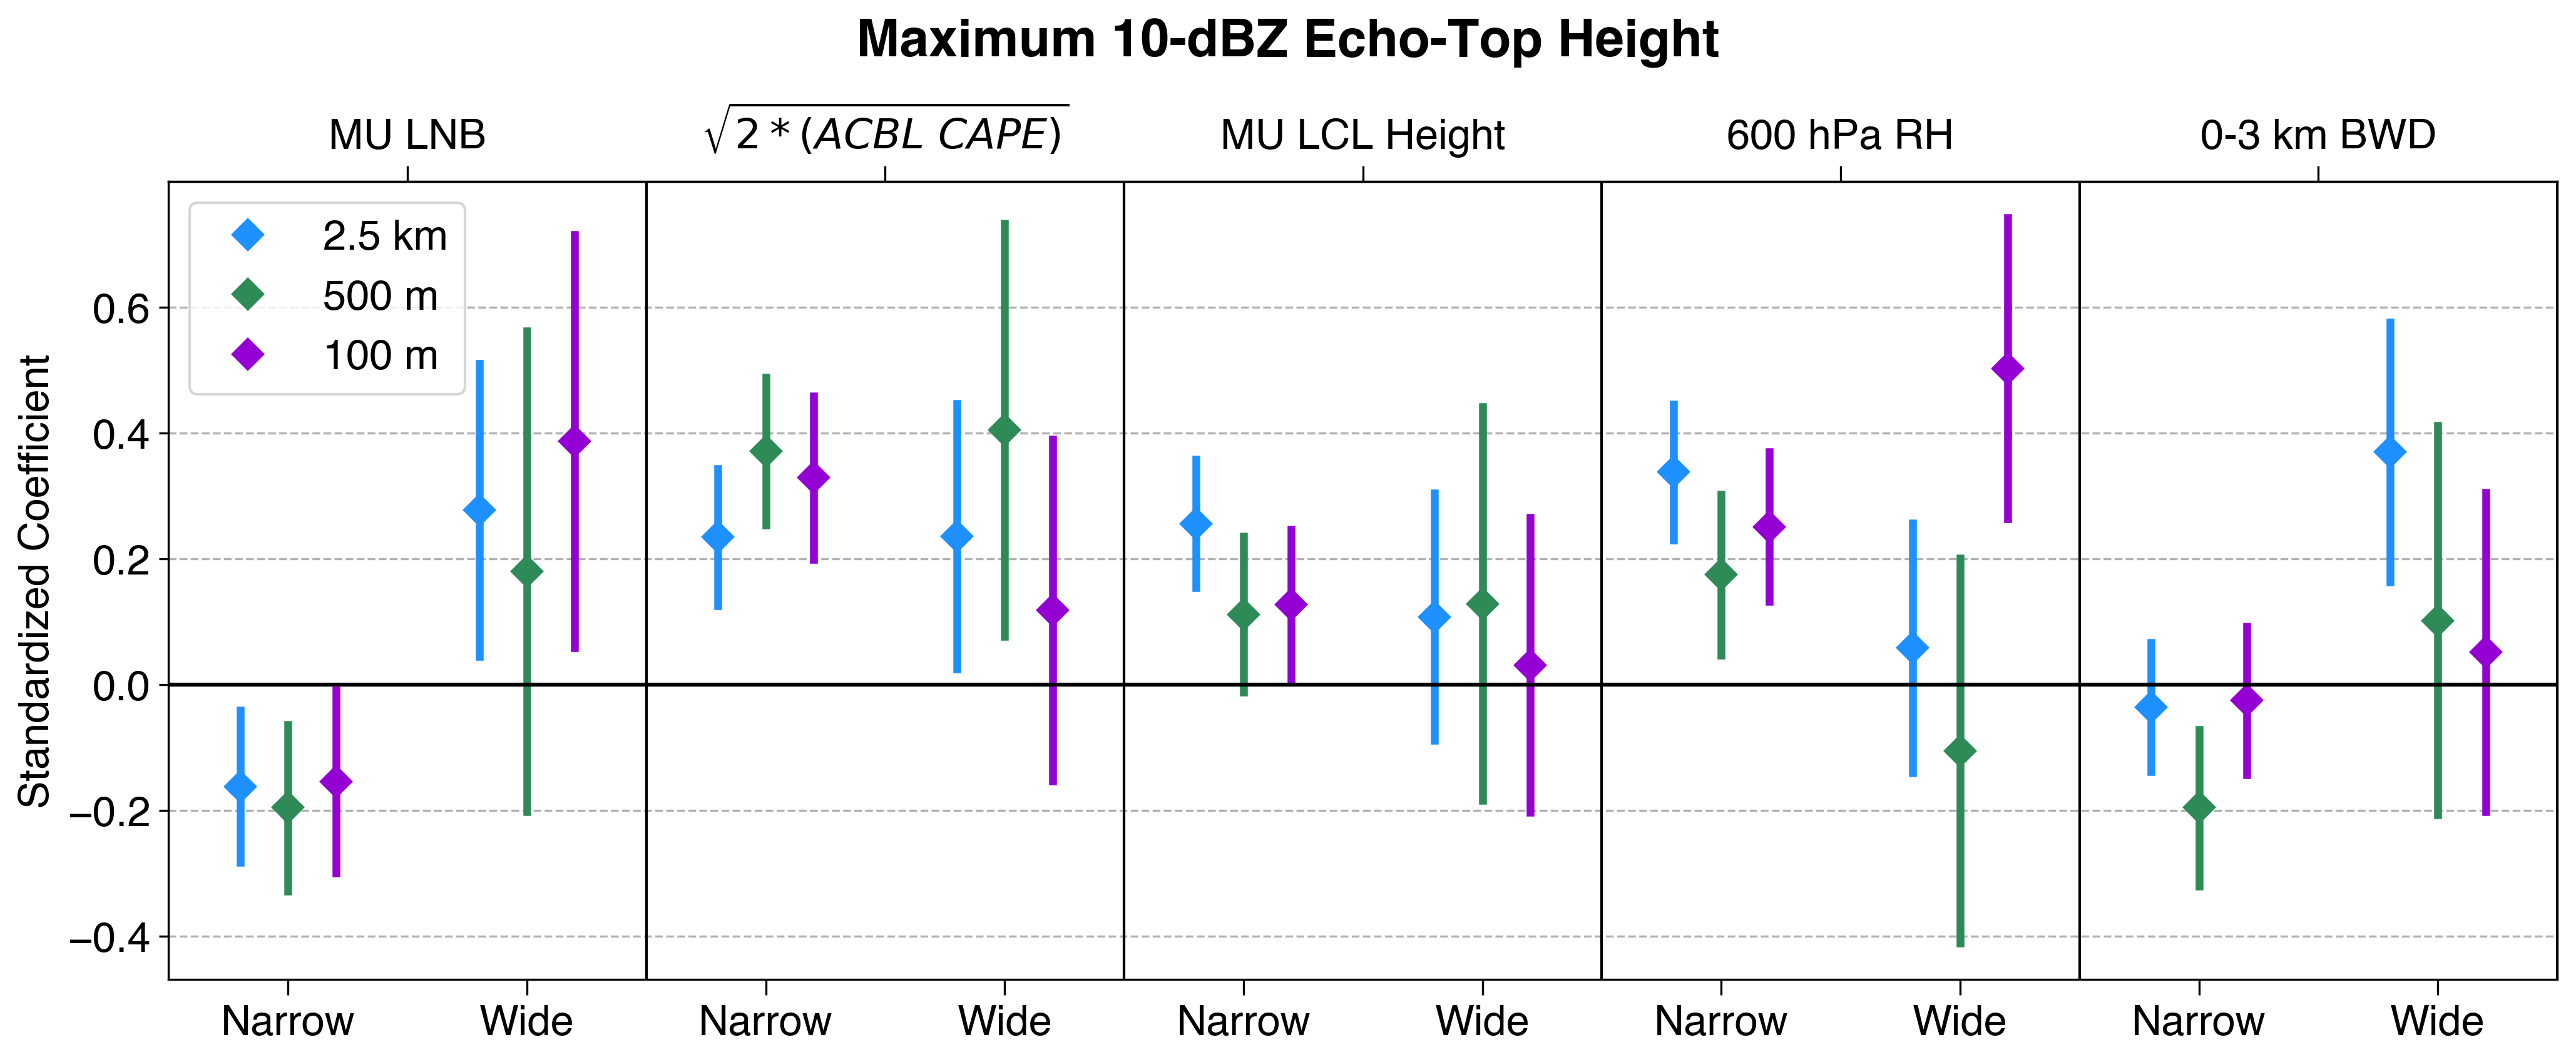

In [131]:
x_n_dict = {'d2':x_n_d2, 'd3':x_n_d3, 'd4':x_n_d4}
y_n_dict = {'d2':narrow_stdcoef_envonly_eth_d2, 'd3':narrow_stdcoef_envonly_eth_d3, 'd4':narrow_stdcoef_envonly_eth_d4}
err_n_dict = {'d2':narrow_stdcoefCI_envonly_eth_d2, 'd3':narrow_stdcoefCI_envonly_eth_d3, 'd4':narrow_stdcoefCI_envonly_eth_d4}
x_w_dict = {'d2':x_w_d2, 'd3':x_w_d3, 'd4':x_w_d4}
y_w_dict = {'d2':wide_stdcoef_envonly_eth_d2, 'd3':wide_stdcoef_envonly_eth_d3, 'd4':wide_stdcoef_envonly_eth_d4}
err_w_dict = {'d2':wide_stdcoefCI_envonly_eth_d2, 'd3':wide_stdcoefCI_envonly_eth_d3, 'd4':wide_stdcoefCI_envonly_eth_d4}
x_divide = np.arange(0, 2*n_predictor_envonly+1, 2)+0.5
xticklabels = ['Narrow','Wide']*n_predictor_envonly
xlabel_list = predictors_envonly
xlabel_pos = (x_divide[:-1] + x_divide[1:])/2
xlims = (np.min(x_divide), np.max(x_divide))
ylims = None
yticks = None
# ylims = (-1.8, 1.5)
# yticks = np.arange(-1.8, 1.51, 0.3)
ylabel = 'Standardized Coefficient'
labels = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}
legend_loc = 'upper left'
markersize = 8
errbar_lw = 3
xtick1_rot = 0
xtick2_rot = 0
xtick1_ha = 'center'
xtick2_ha = 'center'
fontsize = 16
figsize = (14,6)
suptitle = 'Maximum 10-dBZ Echo-Top Height'
figname = f'{figdir}MLR_ETH_Standardized_Coefficients_EnvOnlys.png'
# figname = f'{figdir}MLR_WTop_Standardized_Coefficients_EnvOnlys.png'
print(figname)
fig = plot_coef_errbar(x_n_dict, y_n_dict, err_n_dict, x_w_dict, y_w_dict, err_w_dict, 
                       errbar_lw=errbar_lw, markersize=markersize, fontsize=fontsize, suptitle=suptitle,
                       xticklabels=xticklabels, xlims=xlims, ylims=ylims, yticks=yticks, ylabel=ylabel, labels=labels, legend_loc=legend_loc,
                       xlabel_list=xlabel_list, xlabel_pos=xlabel_pos, x_divide=x_divide, xtick1_rot=xtick1_rot, xtick2_rot=xtick2_rot, xtick1_ha=xtick1_ha, xtick2_ha=xtick2_ha,
                       figname=figname, figsize=figsize, dpi=300)

In [132]:
# Coefficient
narrow_stdcoef_envonly_wtop_d2 = lm_narrow_std_envonly_wtop_d2[['coef']].to_numpy()[1:].squeeze()
n_predictor_envonly = len(narrow_stdcoef_envonly_wtop_d2)
# Coefficient Confidence Intervals
narrow_stdcoefCI_envonly_wtop_d2 = np.full((2, n_predictor_envonly), np.NaN)
narrow_stdcoefCI_envonly_wtop_d2[0,:] = lm_narrow_std_envonly_wtop_d2[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_envonly_wtop_d2[1,:] = lm_narrow_std_envonly_wtop_d2[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_envonly_wtop_d2 = lm_wide_std_envonly_wtop_d2[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_envonly_wtop_d2 = np.full((2, n_predictor_envonly), np.NaN)
wide_stdcoefCI_envonly_wtop_d2[0,:] = lm_wide_std_envonly_wtop_d2[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_envonly_wtop_d2[1,:] = lm_wide_std_envonly_wtop_d2[['CI[97.5%]']].to_numpy()[1:].squeeze()

narrow_stdcoef_envonly_wtop_d3 = lm_narrow_std_envonly_wtop_d3[['coef']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_envonly_wtop_d3 = np.full((2, n_predictor_envonly), np.NaN)
narrow_stdcoefCI_envonly_wtop_d3[0,:] = lm_narrow_std_envonly_wtop_d3[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_envonly_wtop_d3[1,:] = lm_narrow_std_envonly_wtop_d3[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_envonly_wtop_d3 = lm_wide_std_envonly_wtop_d3[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_envonly_wtop_d3 = np.full((2, n_predictor_envonly), np.NaN)
wide_stdcoefCI_envonly_wtop_d3[0,:] = lm_wide_std_envonly_wtop_d3[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_envonly_wtop_d3[1,:] = lm_wide_std_envonly_wtop_d3[['CI[97.5%]']].to_numpy()[1:].squeeze()

narrow_stdcoef_envonly_wtop_d4 = lm_narrow_std_envonly_wtop_d4[['coef']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_envonly_wtop_d4 = np.full((2, n_predictor_envonly), np.NaN)
narrow_stdcoefCI_envonly_wtop_d4[0,:] = lm_narrow_std_envonly_wtop_d4[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_envonly_wtop_d4[1,:] = lm_narrow_std_envonly_wtop_d4[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_envonly_wtop_d4 = lm_wide_std_envonly_wtop_d4[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_envonly_wtop_d4 = np.full((2, n_predictor_envonly), np.NaN)
wide_stdcoefCI_envonly_wtop_d4[0,:] = lm_wide_std_envonly_wtop_d4[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_envonly_wtop_d4[1,:] = lm_wide_std_envonly_wtop_d4[['CI[97.5%]']].to_numpy()[1:].squeeze()

# Make narrow predictor x positions
x_n_d2 = np.arange(1, 2*n_predictor_envonly, 2)-0.2
x_n_d3 = np.arange(1, 2*n_predictor_envonly, 2)
x_n_d4 = np.arange(1, 2*n_predictor_envonly, 2)+0.2
print(x_n_d2, x_n_d3, x_n_d4)

# Make wide predictor x positions
x_w_d2 = np.arange(2, 2*n_predictor_envonly+1, 2)-0.2
x_w_d3 = np.arange(2, 2*n_predictor_envonly+1, 2)
x_w_d4 = np.arange(2, 2*n_predictor_envonly+1, 2)+0.2
print(x_w_d2, x_w_d3, x_w_d4)

[0.8 2.8 4.8 6.8 8.8] [1 3 5 7 9] [1.2 3.2 5.2 7.2 9.2]
[1.8 3.8 5.8 7.8 9.8] [ 2  4  6  8 10] [ 2.2  4.2  6.2  8.2 10.2]


/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/MLR_WTop_Standardized_Coefficients_EnvOnlys.png


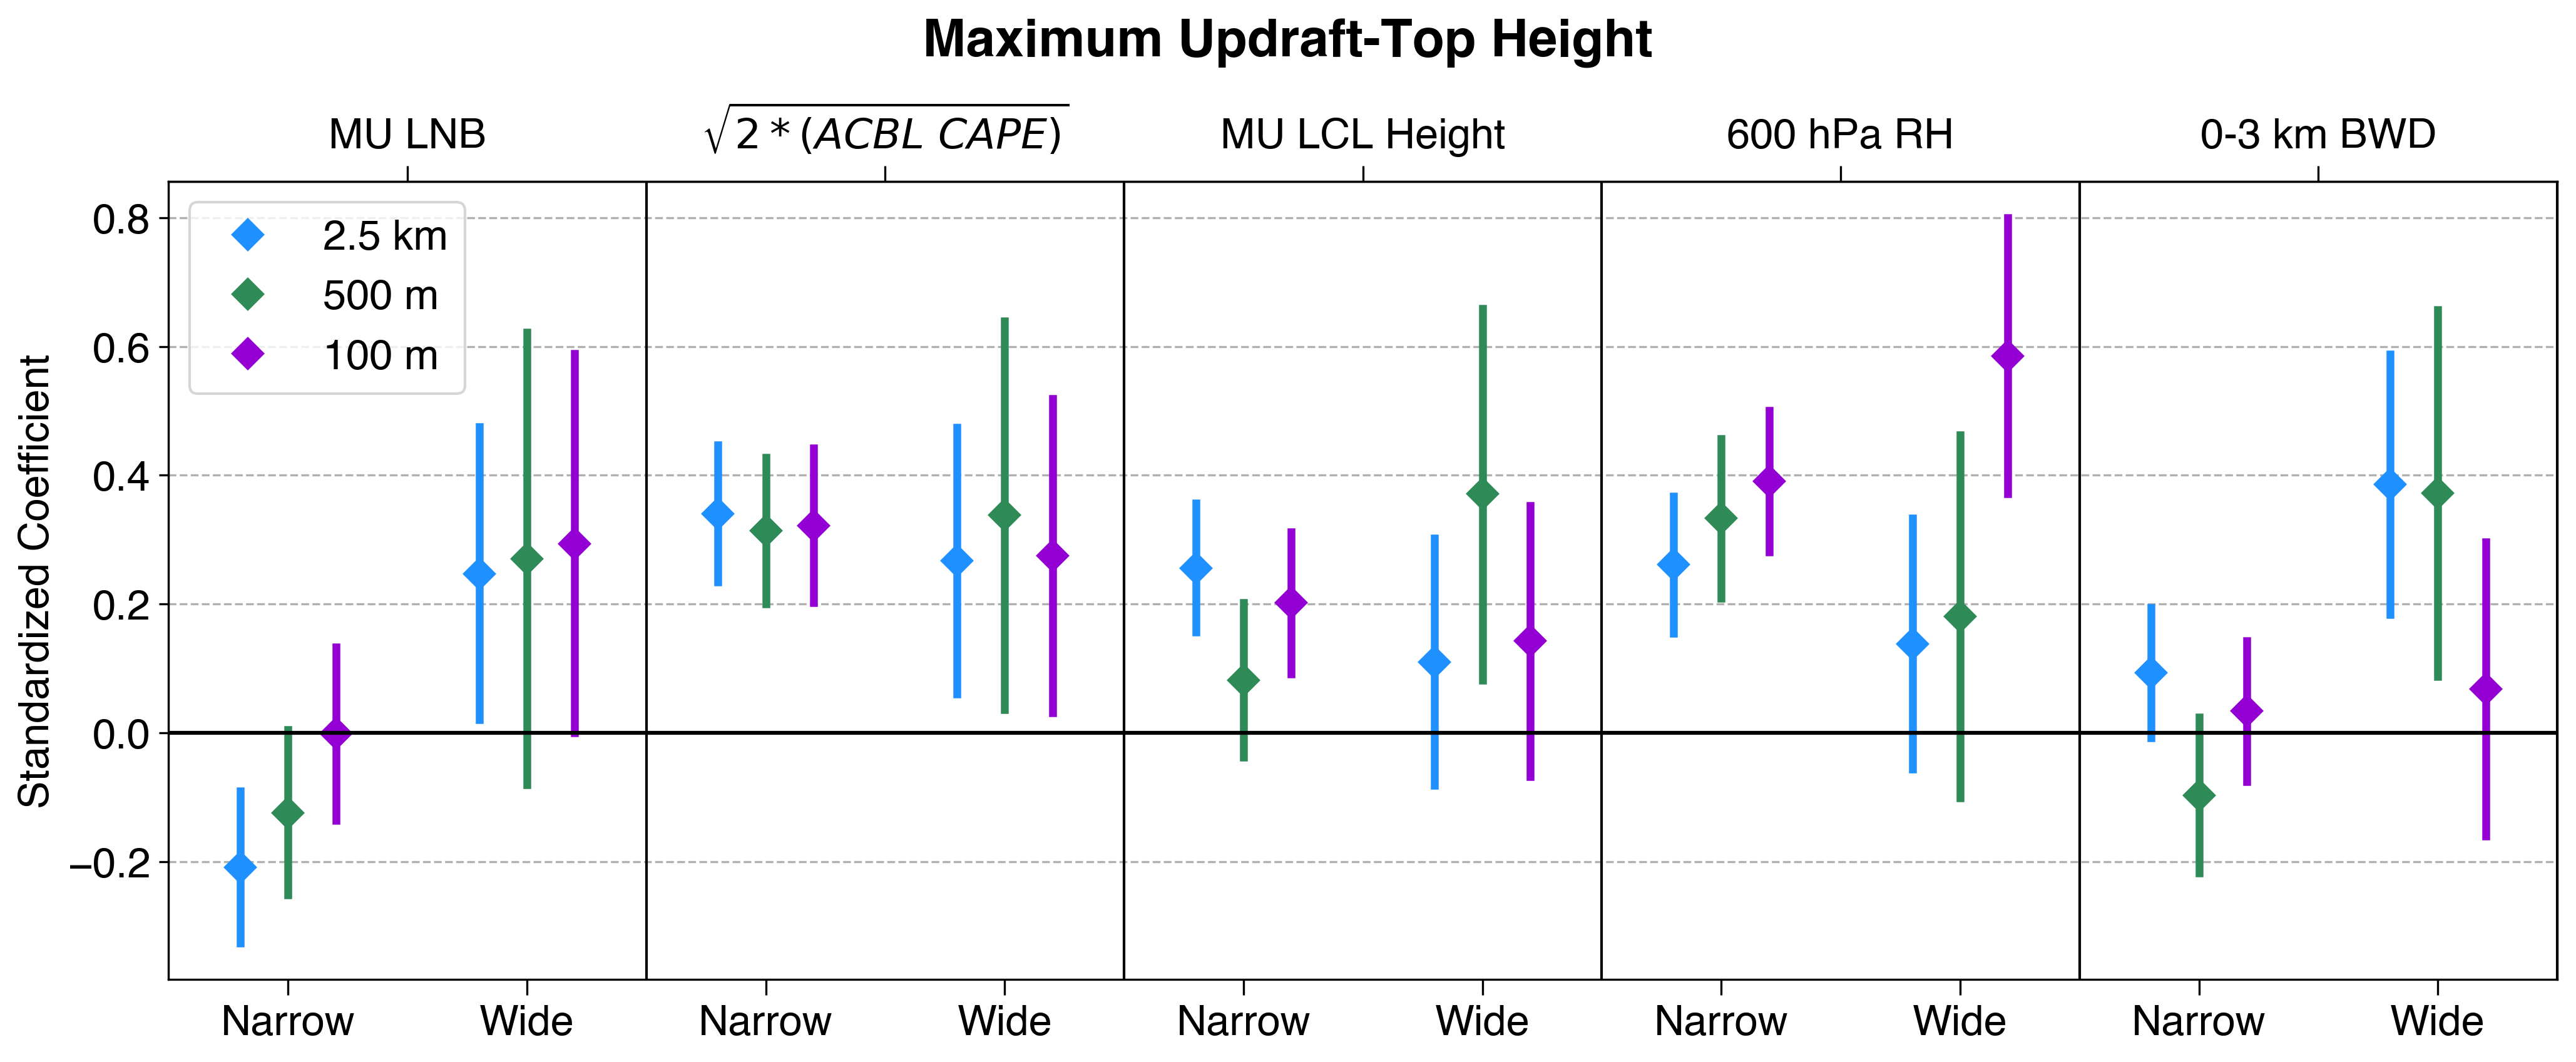

In [133]:
x_n_dict = {'d2':x_n_d2, 'd3':x_n_d3, 'd4':x_n_d4}
y_n_dict = {'d2':narrow_stdcoef_envonly_wtop_d2, 'd3':narrow_stdcoef_envonly_wtop_d3, 'd4':narrow_stdcoef_envonly_wtop_d4}
err_n_dict = {'d2':narrow_stdcoefCI_envonly_wtop_d2, 'd3':narrow_stdcoefCI_envonly_wtop_d3, 'd4':narrow_stdcoefCI_envonly_wtop_d4}
x_w_dict = {'d2':x_w_d2, 'd3':x_w_d3, 'd4':x_w_d4}
y_w_dict = {'d2':wide_stdcoef_envonly_wtop_d2, 'd3':wide_stdcoef_envonly_wtop_d3, 'd4':wide_stdcoef_envonly_wtop_d4}
err_w_dict = {'d2':wide_stdcoefCI_envonly_wtop_d2, 'd3':wide_stdcoefCI_envonly_wtop_d3, 'd4':wide_stdcoefCI_envonly_wtop_d4}
x_divide = np.arange(0, 2*n_predictor_envonly+1, 2)+0.5
xticklabels = ['Narrow','Wide']*n_predictor_envonly
xlabel_list = predictors_envonly
xlabel_pos = (x_divide[:-1] + x_divide[1:])/2
xlims = (np.min(x_divide), np.max(x_divide))
ylims = None
yticks = None
# ylims = (-1.8, 1.5)
# yticks = np.arange(-1.8, 1.51, 0.3)
ylabel = 'Standardized Coefficient'
labels = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}
legend_loc = 'upper left'
markersize = 8
errbar_lw = 3
xtick1_rot = 0
xtick2_rot = 0
xtick1_ha = 'center'
xtick2_ha = 'center'
fontsize = 16
figsize = (14,6)
suptitle = 'Maximum Updraft-Top Height'
figname = f'{figdir}MLR_WTop_Standardized_Coefficients_EnvOnlys.png'
print(figname)
fig = plot_coef_errbar(x_n_dict, y_n_dict, err_n_dict, x_w_dict, y_w_dict, err_w_dict, 
                       errbar_lw=errbar_lw, markersize=markersize, fontsize=fontsize, suptitle=suptitle,
                       xticklabels=xticklabels, xlims=xlims, ylims=ylims, yticks=yticks, ylabel=ylabel, labels=labels, legend_loc=legend_loc,
                       xlabel_list=xlabel_list, xlabel_pos=xlabel_pos, x_divide=x_divide, xtick1_rot=xtick1_rot, xtick2_rot=xtick2_rot, xtick1_ha=xtick1_ha, xtick2_ha=xtick2_ha,
                       figname=figname, figsize=figsize, dpi=300)

## Compute predicted values from MLR

In [134]:
def calc_mlr_predict(df_std, df, coef_std, predictors, predictand_name):
    """
    Calculate predicted values from MLR
    
    Args:
        df_std: Pandas DataFrame
            DataFrame with standardized predictor variables.
        df: Pandas DataFrame
            DataFrame with original predictor variables.
        coef_std: array-like
            Standardized coefficients from MLR.
        predictors: list
            A list containing the names of predictors. Length must match coef_std.
        predictand_name: string
            Name of the predictand.        
        
    Returns:
        predicted: array-like
            Predicted values from MLR.
    """
    # Check if length of predictors is the same with coef_std
    if len(predictors) != len(coef_std):
        print(f"WARNING: length of predictors does NOT match length of coef_std!")
        
    # Make an array to store predicted values
    predicted_std = np.full(df.shape[0], 0, dtype=float)
    # Loop over each predictor
    for ii, var in enumerate(predictors):
        # Sum(coeficient[i] * standardized_value[i])
        predicted_std[:] += coef_std[ii] * df_std[var].values

    # Convert standardized values back to actual values
    predicted = np.nanstd(df[predictand_name]) * predicted_std + np.nanmean(df[predictand_name])
    
    return predicted

In [135]:
predictand_name = 'Max 10dBZ ETH'
# predictand_name = 'Max W Top'
narrow_minset_eth_predicted_d2 = calc_mlr_predict(df_narrow_std_d2, df_narrow_d2, narrow_stdcoef_minset_eth_d2, predictors_minset, predictand_name)
wide_minset_eth_predicted_d2 = calc_mlr_predict(df_wide_std_d2, df_wide_d2, wide_stdcoef_minset_eth_d2, predictors_minset, predictand_name)

narrow_minset_eth_predicted_d3 = calc_mlr_predict(df_narrow_std_d3, df_narrow_d3, narrow_stdcoef_minset_eth_d3, predictors_minset, predictand_name)
wide_minset_eth_predicted_d3 = calc_mlr_predict(df_wide_std_d3, df_wide_d3, wide_stdcoef_minset_eth_d3, predictors_minset, predictand_name)

narrow_minset_eth_predicted_d4 = calc_mlr_predict(df_narrow_std_d4, df_narrow_d4, narrow_stdcoef_minset_eth_d4, predictors_minset, predictand_name)
wide_minset_eth_predicted_d4 = calc_mlr_predict(df_wide_std_d4, df_wide_d4, wide_stdcoef_minset_eth_d4, predictors_minset, predictand_name)

In [136]:
predictand_name = 'Max 10dBZ ETH'
# predictand_name = 'Max W Top'
narrow_all_eth_predicted_d2 = calc_mlr_predict(df_narrow_std_d2, df_narrow_d2, narrow_stdcoef_all_eth_d2, predictors_all, predictand_name)
wide_all_eth_predicted_d2 = calc_mlr_predict(df_wide_std_d2, df_wide_d2, wide_stdcoef_all_eth_d2, predictors_all, predictand_name)

narrow_all_eth_predicted_d3 = calc_mlr_predict(df_narrow_std_d3, df_narrow_d3, narrow_stdcoef_all_eth_d3, predictors_all, predictand_name)
wide_all_eth_predicted_d3 = calc_mlr_predict(df_wide_std_d3, df_wide_d3, wide_stdcoef_all_eth_d3, predictors_all, predictand_name)

narrow_all_eth_predicted_d4 = calc_mlr_predict(df_narrow_std_d4, df_narrow_d4, narrow_stdcoef_all_eth_d4, predictors_all, predictand_name)
wide_all_eth_predicted_d4 = calc_mlr_predict(df_wide_std_d4, df_wide_d4, wide_stdcoef_all_eth_d4, predictors_all, predictand_name)

## Function to plot nrow x ncol heatmaps

In [137]:
def mxn_heatmap(nrow, ncol, x_arr, y_arr, bins_hist=None, bin_range=None, cmaps=None, cbar_labels=None, kde_levels=None, kde_colors=None, 
                wspace=None, hspace=None, xticks=None, yticks=None, vmin=None, vmax=None, suptitle=None,
                xlims=None, ylims=None, xlabels=None, ylabels=None, titles=None, fontsize=None, figsize=None, figname=None, dpi=None):
    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    
    # scatter_kws = {'s':16, 'color':'k'}
    # line_kws = {'color':'r', 'linewidth':4}
    # vmin, vmax = 0, 10

    fig = plt.figure(figsize=figsize, dpi=dpi)
    # Setup two columns (left: plots, right: colorbar)
    gs0 = gridspec.GridSpec(1, 2, figure=fig, height_ratios=[1], width_ratios=[1,0.02], wspace=0.05)
    # Setup panels to the left
    h_ratios = list(np.repeat(1,nrow))
    w_ratios = list(np.repeat(1,ncol))
    gs = gridspec.GridSpecFromSubplotSpec(nrow, ncol, subplot_spec=gs0[0], height_ratios=h_ratios, width_ratios=w_ratios, wspace=wspace, hspace=hspace)
    # Colorbar axis
    cax = plt.subplot(gs0[1])

    # Loop over rows and columns
    for row in range(nrow):
        for col in range(ncol):
            xx = x_arr[row][col]
            yy = y_arr[row][col]
            ax = plt.subplot(gs[row, col])
            pcm = sns.histplot(x=xx, y=yy,  bins=bins_hist, stat='percent',
                               cbar=True, ax=ax, cbar_ax=cax, cmap=cmaps, cbar_kws={'label':cbar_labels}, vmin=vmin, vmax=vmax)
            
            ax.set_xlim(xlims[0], xlims[1])
            ax.set_ylim(ylims[0], ylims[1])
            ax.set_xlabel(xlabels[row][col])
            ax.set_ylabel(ylabels[row][col])
            ax.grid(ls=':')
            ax.set_title(titles[row][col], loc='left')
            ax.set_xticks(xticks)
            ax.set_yticks(yticks)
            # Plot 1-to-1 line
            ax.plot((xlims[0],xlims[1]),(ylims[0],ylims[1]), color='k')
            
    if suptitle is not None:
        fig.suptitle(suptitle)
    fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='w')
    return fig

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/Predicted_vs_Actual_ETH_MinSet.png


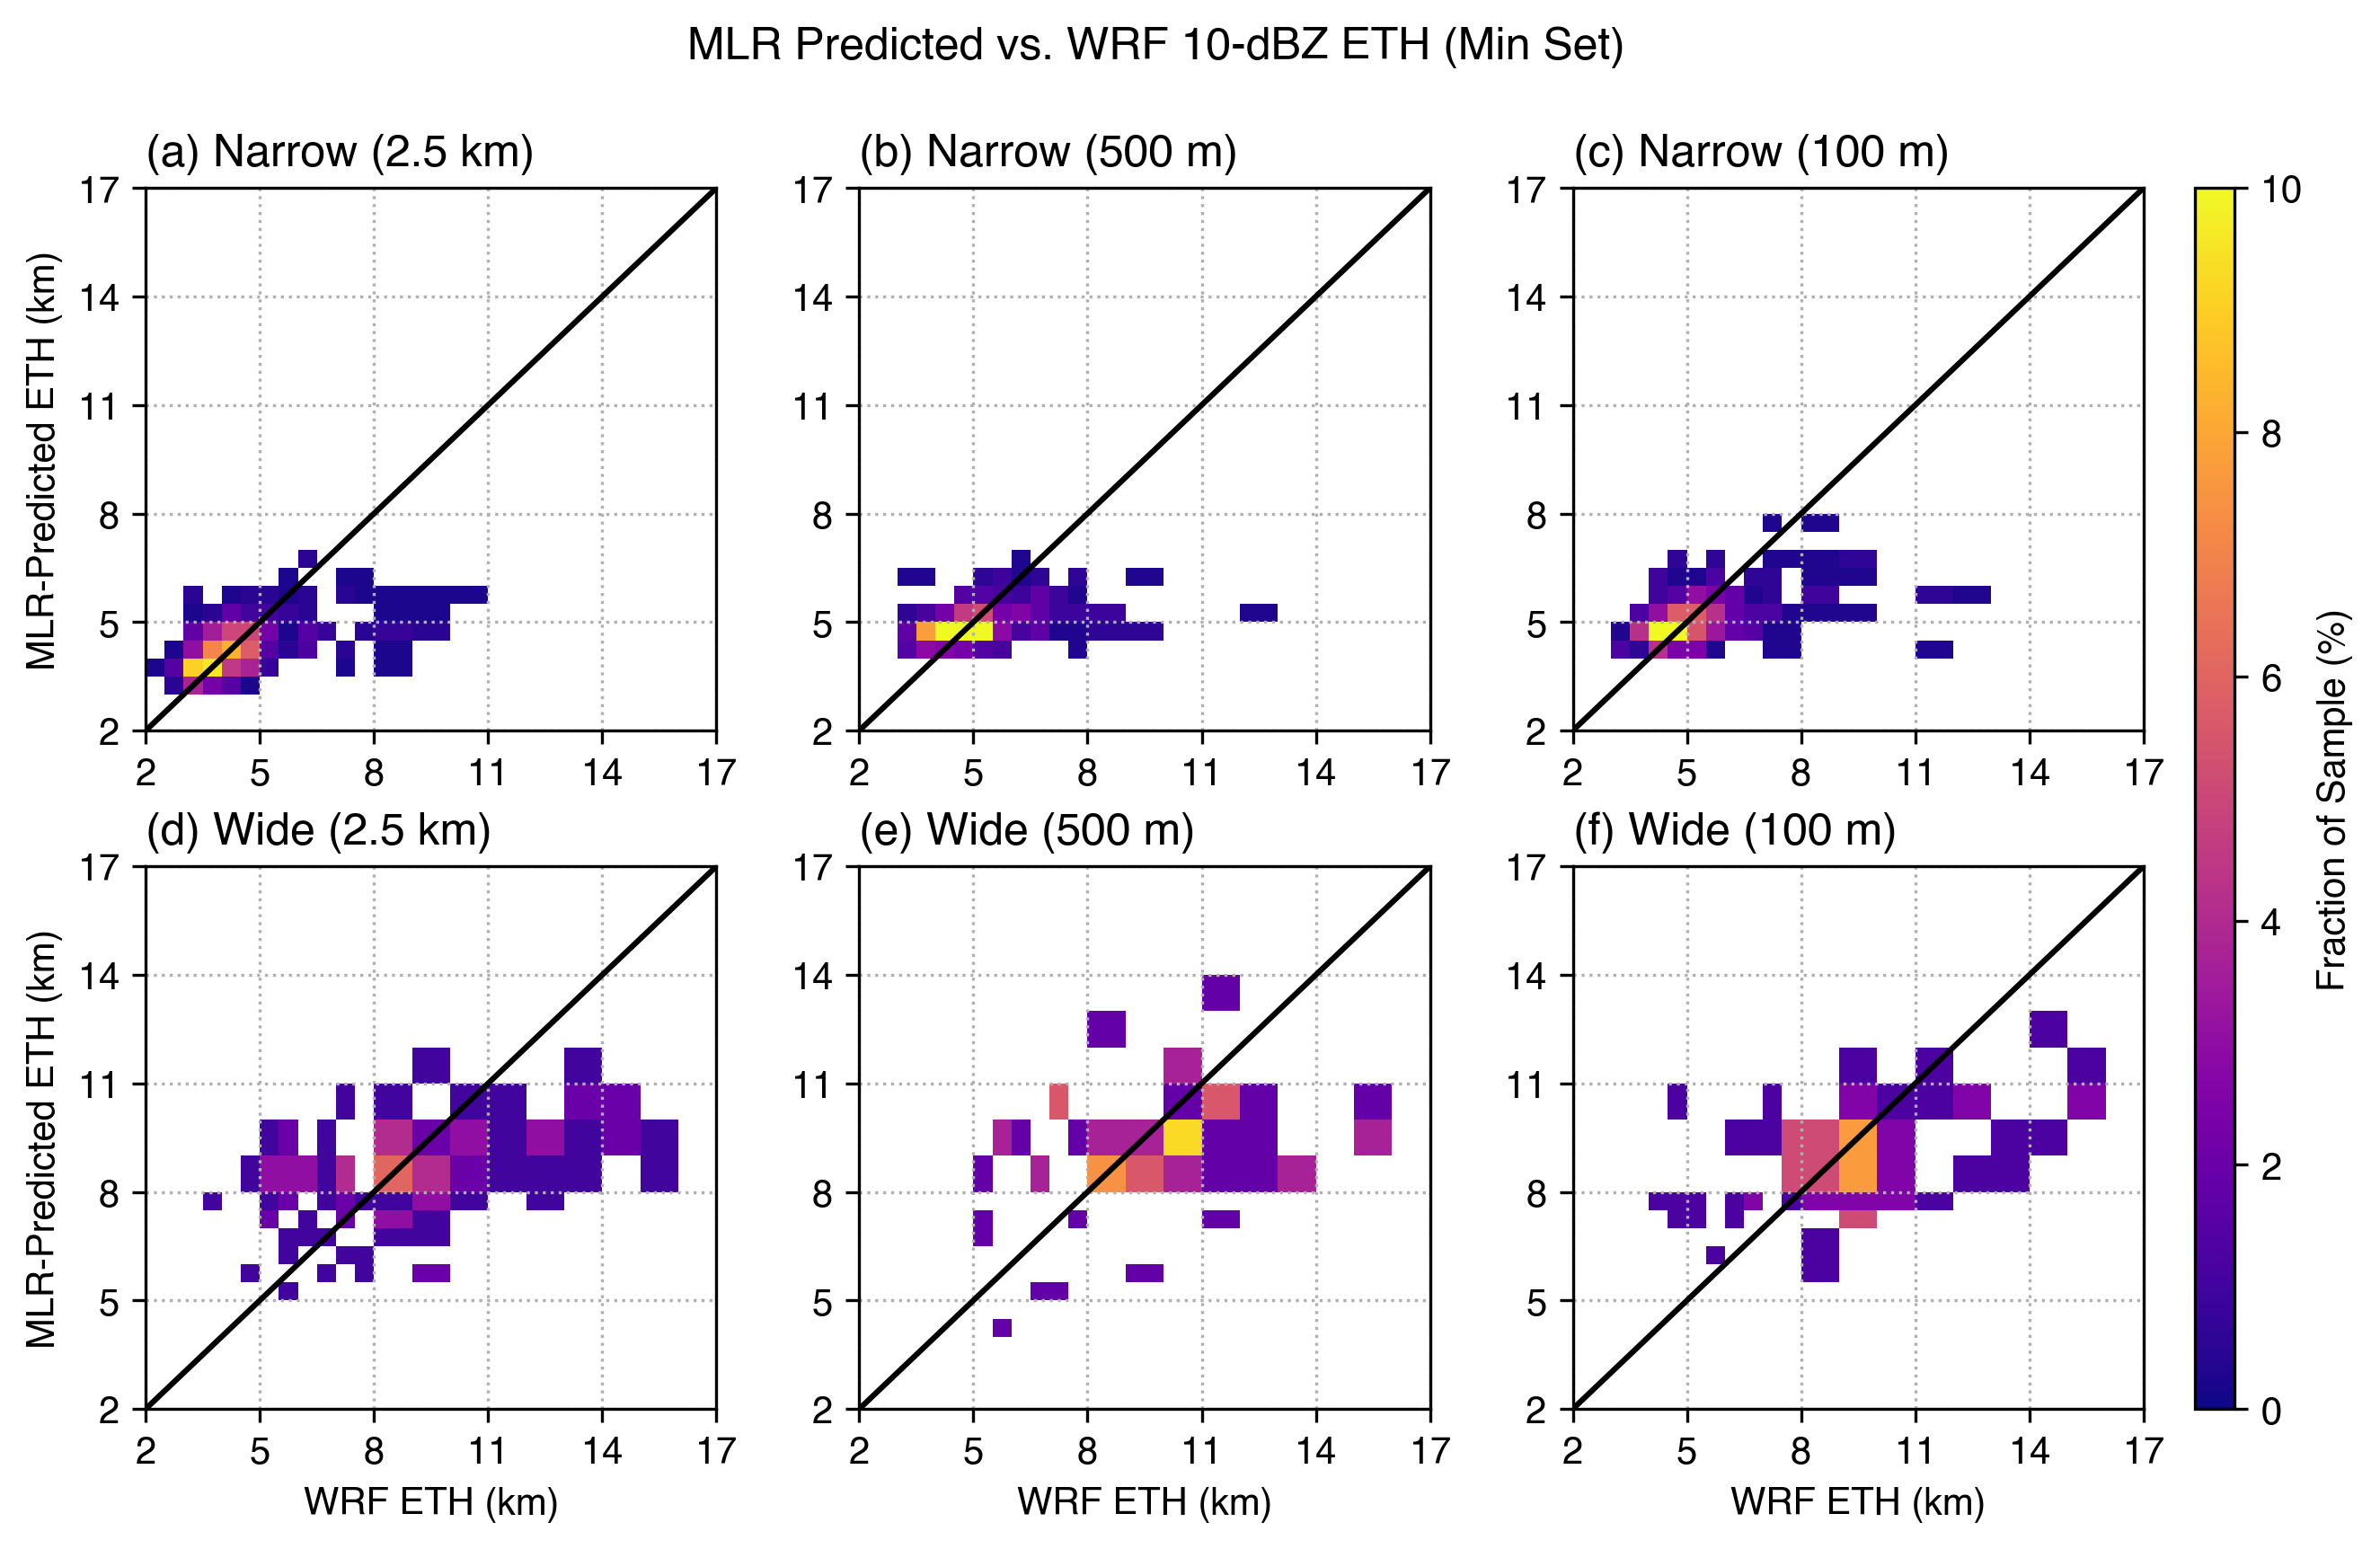

In [138]:
ETH_bins = [np.hstack((np.arange(0,8.1,0.5), np.arange(8,16.1,1)))]*2

suptitle = 'MLR Predicted vs. WRF 10-dBZ ETH (Min Set)'
x_arr = [
    [df_narrow_d2['Max 10dBZ ETH'], df_narrow_d3['Max 10dBZ ETH'], df_narrow_d4['Max 10dBZ ETH']],
    [df_wide_d2['Max 10dBZ ETH'], df_wide_d3['Max 10dBZ ETH'], df_wide_d4['Max 10dBZ ETH']],
]
# suptitle = 'MLR Predicted vs. WRF Updraft Top (NoLNB)'
# x_arr = [
#     [df_narrow_d2['Max W Top'], df_narrow_d3['Max W Top'], df_narrow_d4['Max W Top']],
#     [df_wide_d2['Max W Top'], df_wide_d3['Max W Top'], df_wide_d4['Max W Top']],
# ]
y_arr = [
    [narrow_minset_eth_predicted_d2, narrow_minset_eth_predicted_d3, narrow_minset_eth_predicted_d4],
    [wide_minset_eth_predicted_d2, wide_minset_eth_predicted_d3, wide_minset_eth_predicted_d4],
]
nrow = len(x_arr)
ncol = len(x_arr[0])

# Axes, labels
xlims = (2,17)
ylims = (2,17)
xticks = np.arange(xlims[0], xlims[1]+0.1, 3)
yticks = np.arange(ylims[0], ylims[1]+0.1, 3)
xlabels = [['']*ncol,['WRF ETH (km)']*ncol]
ylabels = [['MLR-Predicted ETH (km)','','']]*nrow
# xlabels = [['']*ncol,['WRF Updraft Top (km)']*ncol]
# ylabels = [['MLR-Predicted Updraft Top (km)','','']]*nrow
titles = [['(a) Narrow (2.5 km)', '(b) Narrow (500 m)', '(c) Narrow (100 m)'],
          ['(d) Wide (2.5 km)', '(e) Wide (500 m)', '(f) Wide (100 m)']]
cbar_labels = 'Fraction of Sample (%)'
cmaps = 'plasma'
vmin, vmax = 0, 10
# Figure
fontsize = 10
figsize = (10,6)
figname = f'{figdir}Predicted_vs_Actual_ETH_MinSet.png'
# figname = f'{figdir}Predicted_vs_Actual_WTop_NoLNB.png'
wspace = 0.25
hspace = 0.25
dpi = 300
print(figname)
fig = mxn_heatmap(nrow, ncol, x_arr, y_arr, bins_hist=ETH_bins, cmaps=cmaps, cbar_labels=cbar_labels,
                  wspace=wspace, hspace=hspace, xticks=xticks, yticks=yticks, vmin=vmin, vmax=vmax, suptitle=suptitle,
                  xlims=xlims, ylims=ylims, xlabels=xlabels, ylabels=ylabels, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_regrid2.5km/Predicted_vs_Actual_ETH_All.png


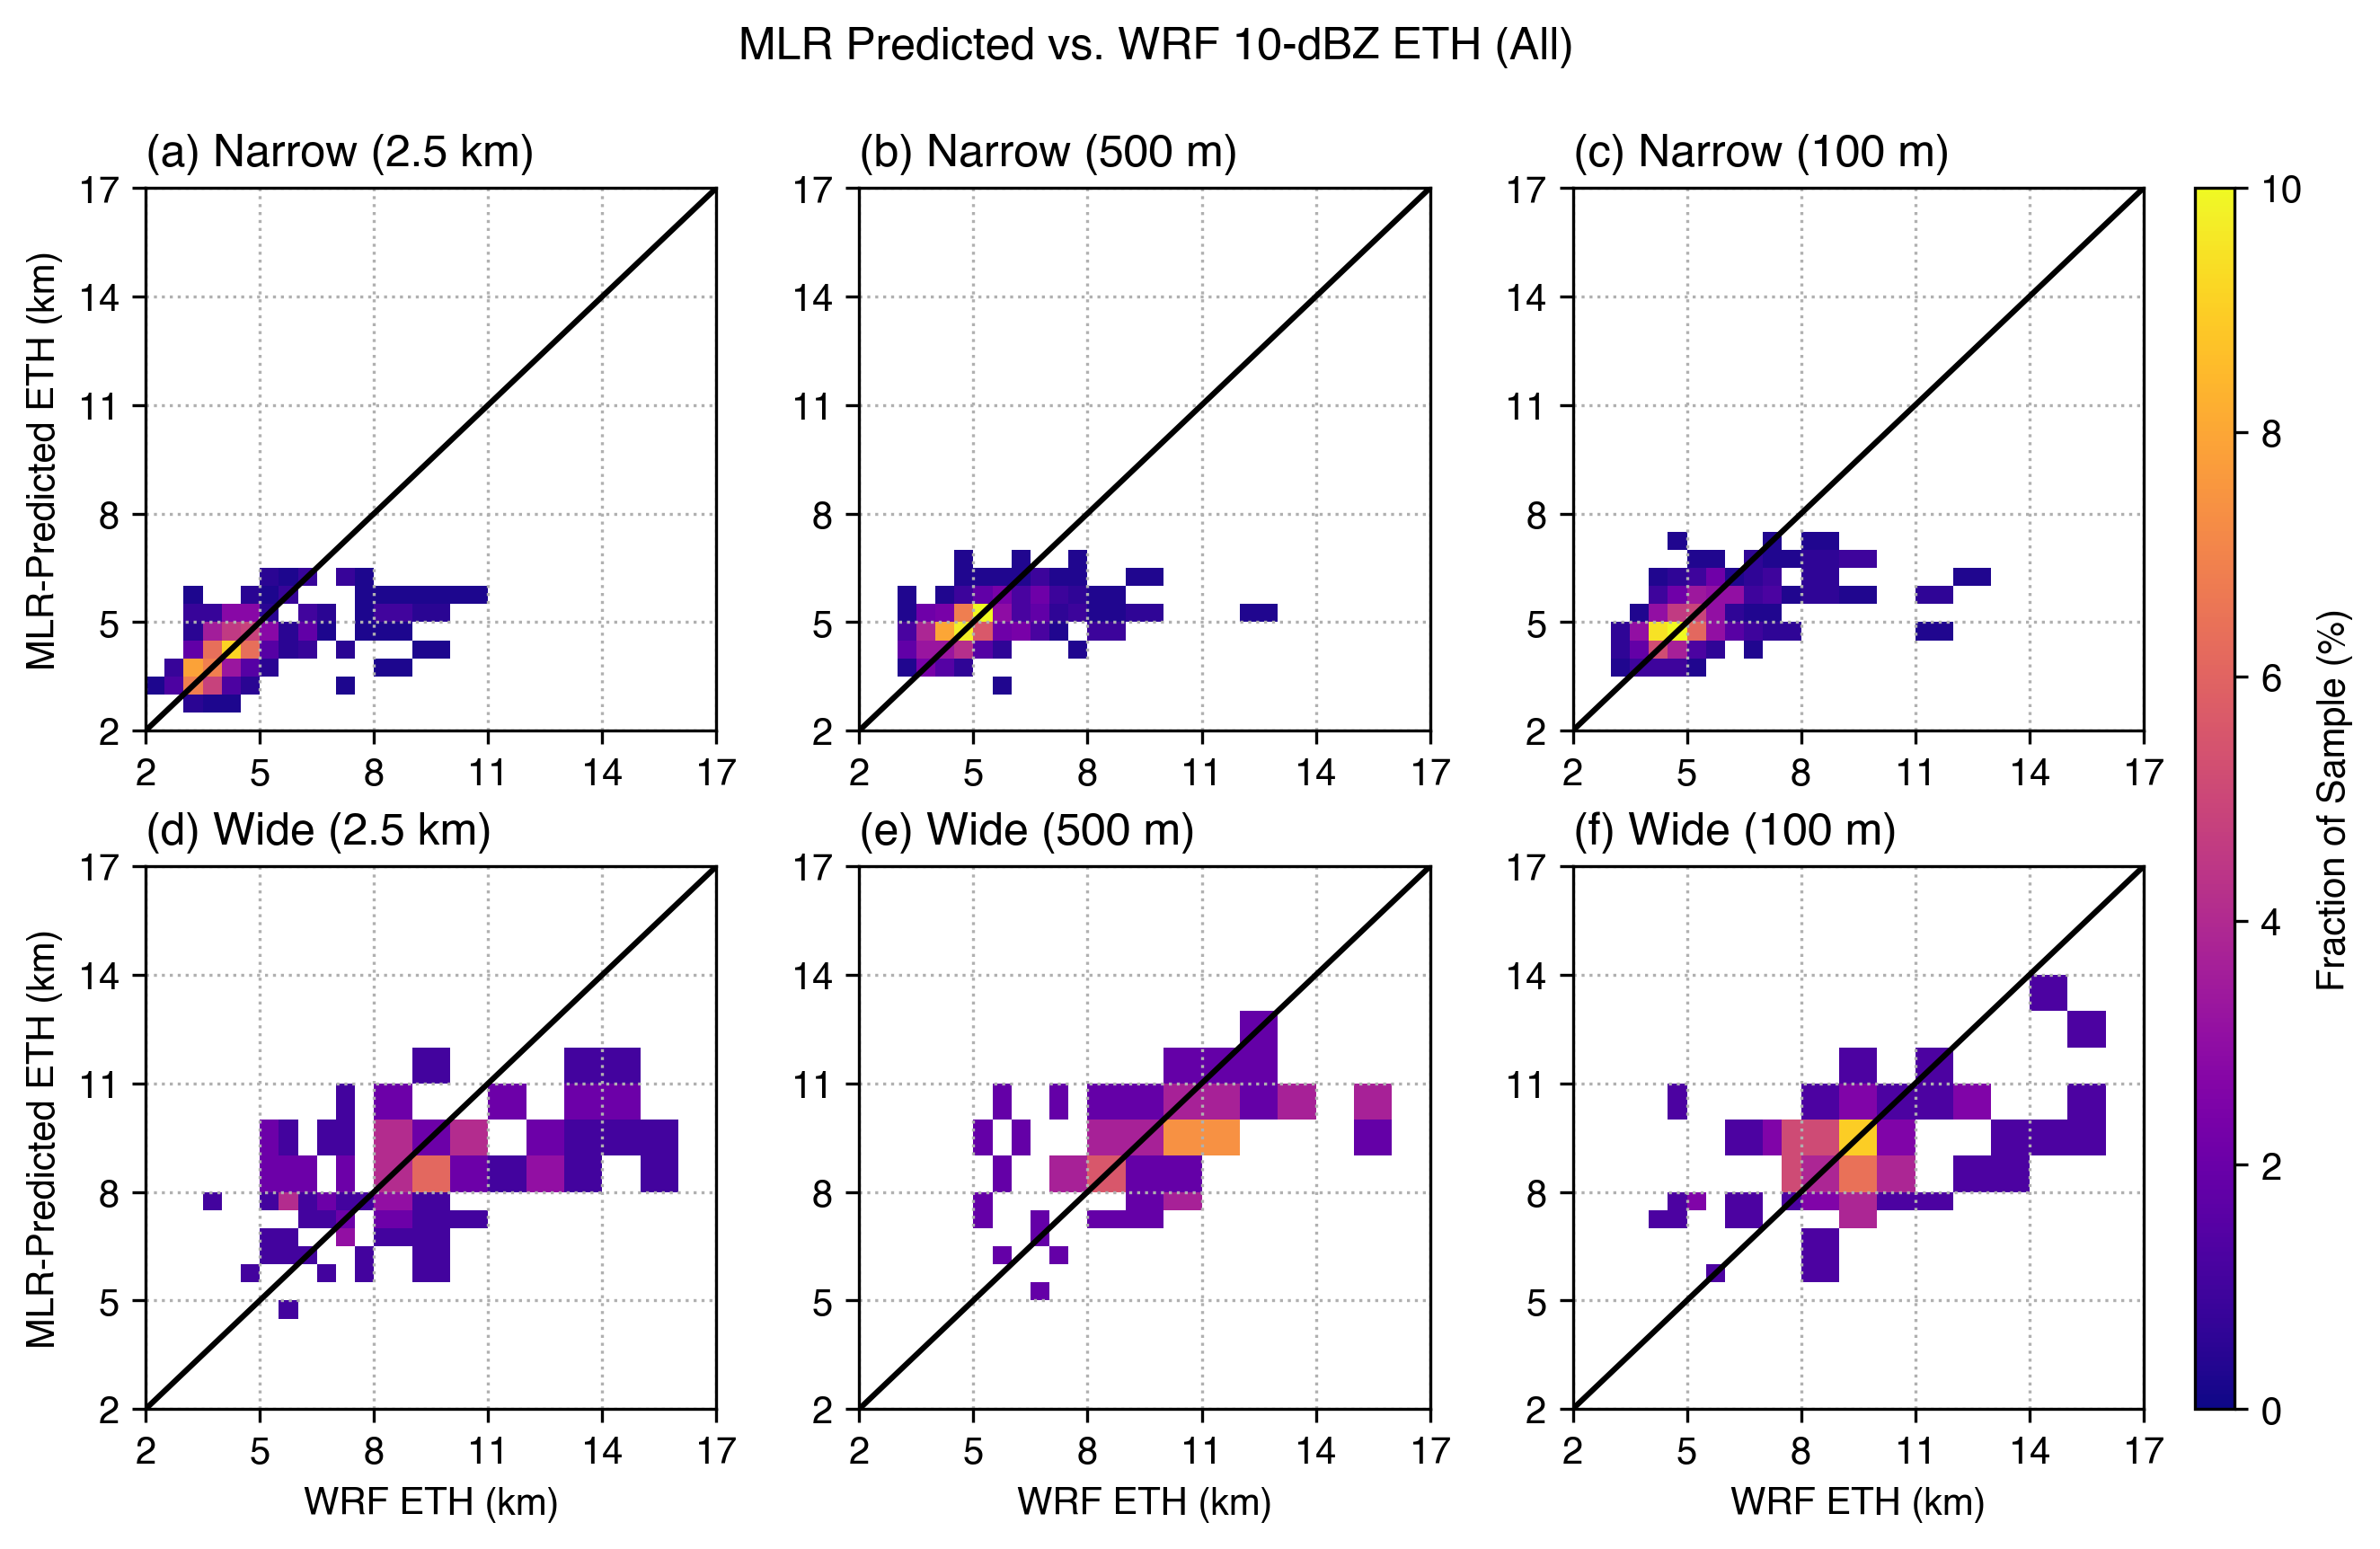

In [139]:
ETH_bins = [np.hstack((np.arange(0,8.1,0.5), np.arange(8,16.1,1)))]*2

suptitle = 'MLR Predicted vs. WRF 10-dBZ ETH (All)'
x_arr = [
    [df_narrow_d2['Max 10dBZ ETH'], df_narrow_d3['Max 10dBZ ETH'], df_narrow_d4['Max 10dBZ ETH']],
    [df_wide_d2['Max 10dBZ ETH'], df_wide_d3['Max 10dBZ ETH'], df_wide_d4['Max 10dBZ ETH']],
]
# suptitle = 'MLR Predicted vs. WRF Updraft Top (All)'
# x_arr = [
#     [df_narrow_d2['Max W Top'], df_narrow_d3['Max W Top'], df_narrow_d4['Max W Top']],
#     [df_wide_d2['Max W Top'], df_wide_d3['Max W Top'], df_wide_d4['Max W Top']],
# ]
y_arr = [
    [narrow_all_eth_predicted_d2, narrow_all_eth_predicted_d3, narrow_all_eth_predicted_d4],
    [wide_all_eth_predicted_d2, wide_all_eth_predicted_d3, wide_all_eth_predicted_d4],
]
nrow = len(x_arr)
ncol = len(x_arr[0])

# Axes, labels
xlims = (2,17)
ylims = (2,17)
xticks = np.arange(xlims[0], xlims[1]+0.1, 3)
yticks = np.arange(ylims[0], ylims[1]+0.1, 3)
xlabels = [['']*ncol,['WRF ETH (km)']*ncol]
ylabels = [['MLR-Predicted ETH (km)','','']]*nrow
# xlabels = [['']*ncol,['WRF Updraft Top (km)']*ncol]
# ylabels = [['MLR-Predicted Updraft Top (km)','','']]*nrow
titles = [['(a) Narrow (2.5 km)', '(b) Narrow (500 m)', '(c) Narrow (100 m)'],
          ['(d) Wide (2.5 km)', '(e) Wide (500 m)', '(f) Wide (100 m)']]
cbar_labels = 'Fraction of Sample (%)'
cmaps = 'plasma'
vmin, vmax = 0, 10
# Figure
fontsize = 10
figsize = (10,6)
figname = f'{figdir}Predicted_vs_Actual_ETH_All.png'
# figname = f'{figdir}Predicted_vs_Actual_WTop_All.png'
wspace = 0.25
hspace = 0.25
dpi = 300
print(figname)
fig = mxn_heatmap(nrow, ncol, x_arr, y_arr, bins_hist=ETH_bins, cmaps=cmaps, cbar_labels=cbar_labels,
                  wspace=wspace, hspace=hspace, xticks=xticks, yticks=yticks, vmin=vmin, vmax=vmax, suptitle=suptitle,
                  xlims=xlims, ylims=ylims, xlabels=xlabels, ylabels=ylabels, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)